<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Project Objectives**

## **Project Objectives and Executive Summary**

The objective of this project is to develop an ensemble-based machine-learning model to predict the short-horizon direction of Bitcoin perpetual-futures returns and to assess whether the resulting statistical signal can be translated into economically meaningful trades.

The BTCUSDT perpetual-futures contract was selected as the underlying instrument because it closely represents the actively traded BTC market, trades continuously throughout the year, provides a substantial history of high-frequency market data and supports a particularly diverse predictor set. In addition to price and volume information, the study incorporates derivatives-market activity, futures term structure, cross-exchange conditions, on-chain investor behaviour and broader financial-market variables.

Rather than fixing the prediction horizon in advance, the project begins by examining forward log returns over 1, 4, 6, 8, 12 and 24 hours. The modelling horizon is treated as part of the research problem and is selected only after exploratory analysis of return behaviour, class balance and the practical implications of each candidate horizon.

The primary model-selection criterion is ROC-AUC, which evaluates the ability of each classifier to rank positive returns above negative returns independently of a particular classification threshold. Balanced accuracy, the F1 score, confusion matrices and full classification reports are also considered to assess the behaviour of the selected models across both return directions.

The practical objective is to determine whether the resulting predictions provide directional classification performance above a naïve benchmark and can generate economically useful trading signals after accounting for turnover and transaction costs.


## **(I) Problem Definition**

## **(I) Problem Definition**

This project investigates whether diverse information from Bitcoin spot markets, derivatives markets, on-chain activity and broader financial markets, combined through machine-learning ensemble classification, can produce statistically reliable and economically useful forecasts of short-horizon BTCUSDT perpetual-futures direction.

The project distinguishes between two related but separate questions:

1. whether the ensemble model possesses out-of-sample directional forecasting ability; and
2. whether this forecasting ability remains economically viable after accounting for turnover, transaction costs and changing market conditions.

A model may therefore demonstrate statistical predictability without producing a viable trading strategy.

The prediction target is constructed from the hourly closing price of the Binance USD-margined BTCUSDT perpetual-futures contract. Let \(F_t\) denote the BTCUSDT perpetual-futures closing price observed at time \(t\). The forward log return over a horizon \(h\) is defined as

$$
r_{t,t+h}^{\mathrm{perp}}
=
\log\left(\frac{F_{t+h}}{F_t}\right).
$$

The corresponding binary directional target is

$$
y_{t,h}
=
\begin{cases}
1, & \text{if } r_{t,t+h}^{\mathrm{perp}} > 0, \\
0, & \text{if } r_{t,t+h}^{\mathrm{perp}} < 0.
\end{cases}
$$

The project initially considers forecast horizons of 1, 4, 6, 8, 12 and 24 hours. The final modelling horizon is selected only after examining the exploratory data analysis, forward-return behaviour and class balance within the training sample.

Predictive performance is evaluated using metrics suited to a noisy binary-classification problem, including:

* ROC-AUC;
* balanced accuracy;
* precision and recall;
* confusion matrices; and
* the stability of performance through time.

The statistical evaluation is supplemented by an economic assessment in which model probabilities are converted into trading signals. Strategy performance is evaluated using cumulative returns, Sharpe ratio, turnover and maximum drawdown after applying transaction-cost assumptions.


In [1]:
# Install packages
!pip install -q yfinance
!pip -q install arch
!pip -q install boruta
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 21.1 MB/s eta 0:00:00


In [2]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf

# Operational packages
import os, io, sys, zipfile
import time
import requests
import importlib
from datetime import datetime
from pathlib import Path
from google.colab import userdata
import json
import joblib

# stat packages
from arch import arch_model

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

# load the api keys
gn_api = userdata.get("gn_api")

Mounted at /content/drive


## **(II) Data Extraction, Quality Control and Point-in-Time Alignment**

Bitcoin perpetual-futures returns may be influenced by several related areas of market activity. These can be grouped broadly into the following categories:

- **Price, volume and cross-exchange trading activity** – BTC and ETH perpetual-futures prices, spot prices, traded volume, taker flow and price differences across Binance, Coinbase and OKX;
- **Derivatives positioning and market stress** – perpetual premium, funding rates, open interest, estimated leverage and long and short liquidations;
- **Futures and options-market structure** – Deribit perpetual and dated futures, contract maturity, trading activity, futures basis and term-structure information;
- **On-chain valuation and investor behaviour** – MVRV, supply in profit, exchange flows, holder positioning, realised losses and network activity;
- **Broader financial-market conditions** – the US dollar, US equities, equity-market volatility and the US 10-year Treasury yield.

Not every possible driver is suitable for a short-horizon directional-classification model, and some events that materially affect Bitcoin prices are irregular and difficult to quantify.

The analysis therefore focuses on data that are available from reproducible public or subscription-based sources, have sufficient historical coverage and can be aligned to the information that would reasonably have been available at each prediction timestamp.

Data are extracted from 1 January 2019 where possible to provide sufficient history for rolling-feature warm-up. The final modelling period begins on 1 January 2020, when coverage across the principal market, derivatives and on-chain datasets becomes sufficiently complete. The resulting sample extends to 30 June 2026 and covers several materially different Bitcoin market regimes.
</br>

### **Data Sources**

| Source | Data extracted | Primary role |
|---|---|---|
| Binance USD-margined futures | BTCUSDT and ETHUSDT hourly OHLCV, trade counts and taker-buy volume | Prediction target, price, momentum, volume and cross-crypto information |
| Binance derivatives endpoints | BTC perpetual premium index and funding rate | Perpetual basis, funding and positioning conditions |
| Coinbase Exchange | BTC-USD hourly spot close | Cross-exchange spot reference |
| OKX | BTC-USDT perpetual hourly close | Cross-exchange perpetual reference |
| Glassnode | On-chain valuation, holder behaviour, exchange activity, open interest, leverage, liquidations and options indicators | On-chain and derivatives-market predictors |
| Deribit | BTC perpetual and dated-futures prices, volume, notional and contract expiry information | Futures basis, maturity and term-structure predictors |
| Yahoo Finance | US Dollar Index, S&P 500, VIX and US 10-year Treasury yield | Cross-asset and macro-financial conditions |

Features are not constructed during extraction. Each source is first extracted, checked for coverage and timestamp integrity, cleaned where necessary and aligned according to its publication timing. Feature engineering is undertaken only after the source datasets have been merged and divided chronologically into training and test partitions.
</br>

### **Point-in-Time Alignment Policy**

Point-in-time alignment is applied separately for each data source according to its timestamp convention, publication timing and data frequency. The following source-level rules are applied during extraction and quality control so that the files entering the final hourly merge are already aligned to the information available at each modelling timestamp.

| Data source / family | General PIT lag |
|---|---:|
| Glassnode — 1-hour resolution endpoints | \(T+2\) hours |
| Glassnode — 24-hour resolution endpoints | \(T+2\) days |
| Deribit hourly futures data | \(T+1\) hour |
| Cross-asset market data | \(T+1\) day |
| CEX hourly market data | \(T+0\) |

### a) **Glassnode**

Glassnode provides the principal on-chain and derivatives-positioning dataset. Nineteen endpoints are extracted from 1 January 2019 where available to support later rolling-feature warm-up. The selected series cover valuation, holder behaviour, exchange activity, leverage, liquidations, options conditions and network activity.

| Endpoint name | Glassnode metric | Resolution | Theme |
|---|---|---:|---|
| `mvrv_z` | MVRV Z-Score | 1h | Valuation |
| `sth_mvrv` | Short-term-holder MVRV | 1h | Holder valuation |
| `lth_mvrv` | Long-term-holder MVRV | 1h | Holder valuation |
| `real_loss_sth` | Realised loss by short-term holders | 1h | Holder stress |
| `pct_supply_profit` | Percentage of supply in profit | 1h | Profitability |
| `exch_net_pos_chg` | Exchange net-position change | 1h | Exchange flows |
| `xfer_vol_exch_net` | Net transfer volume to exchanges | 1h | Exchange flows |
| `sth_xfer_to_exch` | STH transfer volume to exchanges | 1h | Holder flows |
| `oi_perp` | Perpetual-futures open interest | 1h | Derivatives positioning |
| `leverage_ratio` | Estimated futures leverage ratio | 1h | Leverage |
| `liq_long` | Long-liquidation volume | 1h | Market stress |
| `liq_short` | Short-liquidation volume | 1h | Market stress |
| `opt_skew_1w` | One-week 25-delta options skew | 1h | Options sentiment |
| `opt_skew_1m` | One-month 25-delta options skew | 1h | Options sentiment |
| `atm_iv_1m` | One-month ATM implied volatility | 1h | Options volatility |
| `active_addr` | Active-address count | 1h | Network activity |
| `supply_active_1w1m` | Supply active between one week and one month | 1h | Coin activity |
| `hodler_net_pos` | HODLer net-position change | 1h | Holder positioning |
| `inv_loss_seller` | Supply held by loss sellers | 24h | Investor behaviour |

**i) Data Extraction**

In [5]:
# data extraction from glassnode - on-chain metrics
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

# Data extraction window
start_date = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",            "endpoint": "market/mvrv_z_score",                              "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",              "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum","interval": "1h", "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",    "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",          "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month","interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                            "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",            "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {"a": "BTC", "i": item["interval"], "s": start_unix, "api_key": gn_api}

    # extracting glassnode endpoints with currency label
    if item["currency"] is not None:
        params["c"] = item["currency"]

    response = requests.get(f"https://api.glassnode.com/v1/metrics/{item['endpoint']}", params=params)
    response.raise_for_status()
    series = pd.DataFrame(response.json())

    # extracting glassnode endpoints with no metric keys
    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        # extracting glassnode endpoints with metric keys
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    series = series.set_index("timestamp")[[item["name"]]]

    glassnode_series.append(series)

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")

df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480741.577275
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


**ii) Data Quality Check**


In [6]:
# Glassnode data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_glassnode.shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"Duplicate timestamps: {df_glassnode.index.duplicated().sum()}")

glassnode_check_cols = ["pct_supply_profit", "oi_perp", "liq_long", "liq_short", "opt_skew_1w", "opt_skew_1m", "atm_iv_1m", "inv_loss_seller"]

gn_nan_summary = []

for col in glassnode_check_cols:
    series = df_glassnode[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    gn_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

gn_nan_summary = pd.DataFrame(gn_nan_summary).set_index("series")

print(f"Total missing values across checked endpoints: {int(gn_nan_summary['missing_count'].sum())}")
print(f"Endpoints with internal NaN values: {int(gn_nan_summary['has_internal_nan'].sum())}")

gn_nan_summary

Shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked endpoints: 75814
Endpoints with internal NaN values: 2


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
pct_supply_profit,168,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,168,True
oi_perp,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_long,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_short,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1w,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
atm_iv_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
inv_loss_seller,62974,2019-01-01 00:00:00+00:00,2026-06-30 00:00:00+00:00,65689,62951,True


Observations from this data quality check:

*   oi_perp, liq_long, liq_short, opt_skew_1w, opt_skew_1m, atm_iv_1m - has start date later than 2019-01-01 data extraction date. This will be addressed at final data merge, where realistic common start date will be determined
*   inv_loss_seller - this is a 24h resolution endpoint, likely internal nan will be resolved after aligning on horizon post data cleaning
*   pct_supply_profit - further investigation required, 168 missing internal missing bars could be significant

**iii) Data Cleaning**


**Endpoint: inv_loss_seller**

This is a native 24 hour resolution endpoint, internal nan examination are required based on the endpoint's original resolution first.

In [7]:
# Native 24-hour series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Check spacing between consecutive observations
daily_spacing = inv_loss_daily.index.to_series().diff()

print("Observation count:", len(inv_loss_daily))
print("First valid timestamp:", inv_loss_daily.index.min())
print("Last valid timestamp:", inv_loss_daily.index.max())

# check for gaps in data series
irregular_spacing = daily_spacing[daily_spacing.ne(pd.Timedelta(days=1)) & daily_spacing.notna()]

if irregular_spacing.empty:
    print("All native observations are spaced exactly 24 hours apart.")
else:
    print("Irregular native-frequency spacing detected:")
    print(irregular_spacing)

Observation count: 2738
First valid timestamp: 2019-01-01 00:00:00+00:00
Last valid timestamp: 2026-06-30 00:00:00+00:00
All native observations are spaced exactly 24 hours apart.


We can determine there is no missing data within this series, however, for this endpoint to be able to merge with other 1 hour resolution based endpoint, clean up is still required by applying point-in-time alignment policy and forward filling empty cells.

In [8]:
# Separate and PIT-align the daily inverse-loss endpoint
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()
inv_loss_daily_lagged = inv_loss_daily.shift(2)
inv_loss_daily_1h_pit_aligned = inv_loss_daily_lagged.reindex(df_glassnode.index).ffill().to_frame("inv_loss_seller")

# Remove the daily endpoint from the native 1-hour Glassnode dataset
df_glassnode = df_glassnode.drop(columns=["inv_loss_seller"])

# Save the native hourly endpoints and the separately PIT-aligned daily endpoint
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")
inv_loss_daily_1h_pit_aligned.to_csv("inv_loss_daily_1h_pit_aligned.csv", index_label="timestamp")

# Validation
assert "inv_loss_seller" not in df_glassnode.columns
assert inv_loss_daily_1h_pit_aligned.columns.tolist() == ["inv_loss_seller"]
assert inv_loss_daily_1h_pit_aligned.index.equals(df_glassnode.index)
assert not inv_loss_daily_1h_pit_aligned.index.duplicated().any()

print(f"Native hourly Glassnode shape: {df_glassnode.shape}")
print(f"Inverse-loss hourly shape: {inv_loss_daily_1h_pit_aligned.shape}")
print(f"Inverse-loss missing values after conversion: {inv_loss_daily_1h_pit_aligned['inv_loss_seller'].isna().sum()}")

Native hourly Glassnode shape: (65712, 18)
Inverse-loss hourly shape: (65712, 1)
Inverse-loss missing values after conversion: 48


**Endpoint: pct_supply_profit**

Audit is suggesting there are 168 bars missing, which aggregates to roughly 7 calendar days. Initial diagnose required to understand the pattern of this missing data.

In [9]:
# Audit missing timestamps within Percent Supply in Profit
col = "pct_supply_profit"
pct_supply_missing_timestamps = df_glassnode.index[df_glassnode[col].isna()]

print(f"Missing bars: {len(pct_supply_missing_timestamps)}")
display(pd.DataFrame({"missing_timestamp": pct_supply_missing_timestamps}))

Missing bars: 168


,missing_timestamp
0,2026-03-29 00:00:00+00:00
1,2026-03-29 01:00:00+00:00
2,2026-03-29 02:00:00+00:00
3,2026-03-29 03:00:00+00:00
4,2026-03-29 04:00:00+00:00
...,...
163,2026-04-04 19:00:00+00:00
164,2026-04-04 20:00:00+00:00
165,2026-04-04 21:00:00+00:00
166,2026-04-04 22:00:00+00:00


The missing-value pattern consists of one continuous 168-hour vendor outage from 29 March to 4 April 2026.

- A simple forward fill is not applied automatically because the gap spans seven calendar days. Carrying the last observed hourly value across the entire interval could materially distort the series.
- Linear interpolation is also rejected at this stage because the shape of the underlying relationship is not known and the method would use future observations, introducing look-ahead bias.

Alternative reconstruction methods are therefore investigated using related economic series. Because this endpoint measures the proportion of Bitcoin supply held in profit, the first diagnostic compares it with BTC price to determine whether a sufficiently stable relationship exists to support proxy-based reconstruction.

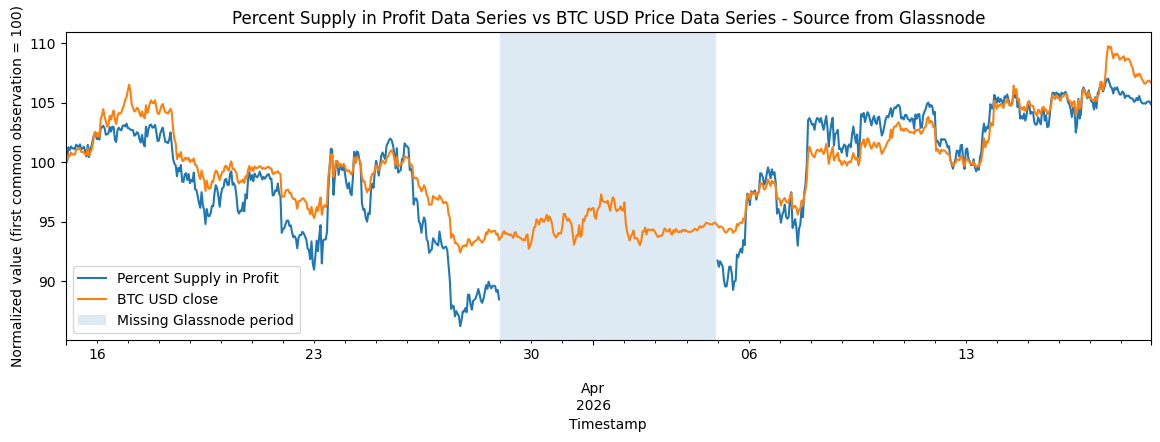

In [10]:
# Comparison window around the missing timestamps
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode for comparison
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine and normalize the two series
comparison = pd.concat([df_glassnode["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common = comparison.dropna()
normalized = comparison.divide(common.iloc[0]).multiply(100)

# Plot
ax = normalized.plot(figsize=(14, 4), title="Percent Supply in Profit Data Series vs BTC USD Price Data Series - Source from Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Missing Glassnode period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit", "BTC USD close", "Missing Glassnode period"])
plt.show()

The Percent Supply in Profit series and BTC price both fluctuate materially around the missing interval, there are no stable trend to justfiy just a direct mirroring. Alternative rebuild methods are required.

**Endpoint calculation methodology and proposed treatment**

Glassnode’s `supply/profit_relative` metric is calculated as the amount of BTC supply currently in profit divided by circulating supply. Further investigation identified the root cause of the seven-day outage as the unavailability of the hourly `supply/profit_sum` numerator. This established that the missing hourly observations could not be reconstructed directly from the available endpoint components.

The same `supply/profit_relative` metric remained fully populated at 24-hour resolution during the affected week. The daily series is therefore used to reconstruct the missing interval at daily resolution before it is expanded to the hourly index. This preserves the broad movement of the metric while sacrificing intraday variation during the reconstructed period.

In [12]:
# Reconstruct Percent Supply in Profit using the complete 24-hour version
pct_supply_col = "pct_supply_profit"
pct_supply_missing_mask = df_glassnode[pct_supply_col].isna()
pct_supply_original = df_glassnode[pct_supply_col].copy()

params = {"a": "BTC", "i": "24h", "s": int(df_glassnode.index.min().timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/supply/profit_relative", params=params)
response.raise_for_status()

pct_supply_daily = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": pct_supply_col})
pct_supply_daily["timestamp"] = pd.to_datetime(pct_supply_daily["timestamp"], unit="s", utc=True)
pct_supply_daily = pct_supply_daily.set_index("timestamp")[[pct_supply_col]].sort_index()
pct_supply_daily = pct_supply_daily.loc[~pct_supply_daily.index.duplicated(keep="first")]
pct_supply_daily = pct_supply_daily.loc[df_glassnode.index.min().floor("D"):df_glassnode.index.max().ceil("D")]

# Expand the daily series to the hourly index
pct_supply_daily_1h = pct_supply_daily.reindex(df_glassnode.index).ffill()

# Replace only the missing hourly observations
pct_supply_profit_1h_clean = pct_supply_original.to_frame()
pct_supply_profit_1h_clean.loc[pct_supply_missing_mask, pct_supply_col] = pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col]
pct_supply_profit_1h_clean["daily_patch_flag"] = pct_supply_missing_mask.astype(int)

pct_supply_profit_1h_clean.to_csv("pct_supply_profit_1h_clean.csv", index_label="timestamp")

print(f"Native hourly missing bars: {pct_supply_missing_mask.sum()}")
print(f"Hourly bars patched: {pct_supply_profit_1h_clean['daily_patch_flag'].sum()}")
print(f"Missing values after reconstruction: {pct_supply_profit_1h_clean[pct_supply_col].isna().sum()}")
print("Saved reconstructed series to: pct_supply_profit_1h_clean.csv")

Native hourly missing bars: 168
Hourly bars patched: 168
Missing values after reconstruction: 0
Saved reconstructed series to: pct_supply_profit_1h_clean.csv


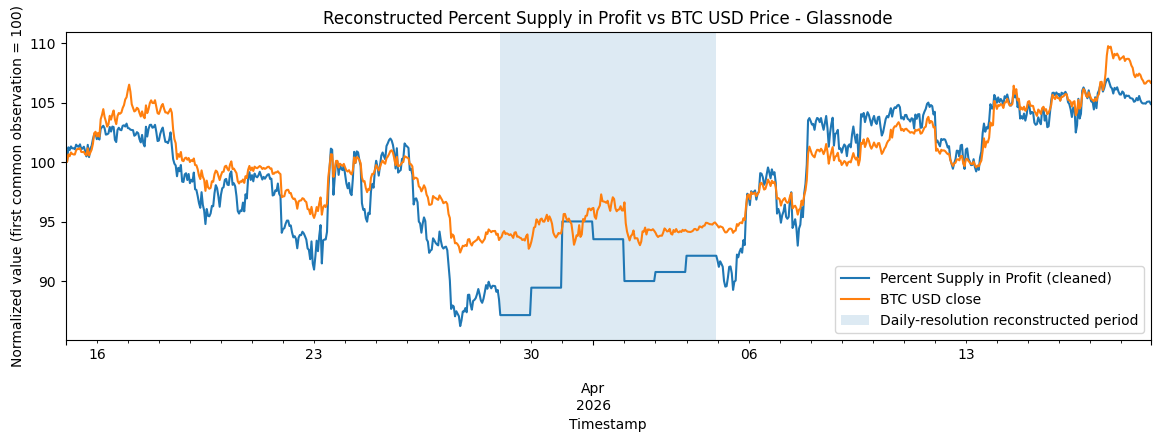

In [13]:
# Plot the reconstructed Percent Supply in Profit series against BTC price
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine the cleaned series with BTC price and normalize both to 100
comparison_clean = pd.concat([pct_supply_profit_1h_clean["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common_start = comparison_clean.dropna().iloc[0]
normalized_clean = comparison_clean.divide(common_start).multiply(100)

# Plot and retain the shaded reconstructed interval
ax = normalized_clean.plot(figsize=(14, 4), title="Reconstructed Percent Supply in Profit vs BTC USD Price - Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Daily-resolution reconstructed period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit (cleaned)", "BTC USD close", "Daily-resolution reconstructed period"])
plt.show()

**iv) Merging all Glassnode Endpoints in a Point-In-Time Aligned Data File**


In [15]:
# Load the cleaned native-timestamp Glassnode files
glassnode_raw = pd.read_csv("raw_glassnode.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
pct_supply_clean = pd.read_csv("pct_supply_profit_1h_clean.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
inv_loss_pit = pd.read_csv("inv_loss_daily_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

# Standardize all indices to UTC
glassnode_raw.index = pd.to_datetime(glassnode_raw.index, utc=True)
pct_supply_clean.index = pd.to_datetime(pct_supply_clean.index, utc=True)
inv_loss_pit.index = pd.to_datetime(inv_loss_pit.index, utc=True)

# Remove separately treated endpoints from the raw Glassnode file
glassnode_raw = glassnode_raw.drop(columns=["pct_supply_profit", "inv_loss_seller"], errors="ignore")

# Retain only the reconstructed Percent Supply in Profit values
pct_supply_clean = pct_supply_clean[["pct_supply_profit"]]

# Validate indices before combining
assert glassnode_raw.index.equals(pct_supply_clean.index), "Glassnode and Percent Supply in Profit indices do not match."
assert glassnode_raw.index.equals(inv_loss_pit.index), "Glassnode and inverse-loss indices do not match."
assert not glassnode_raw.index.duplicated().any(), "Duplicate timestamps found in raw Glassnode data."
assert not pct_supply_clean.index.duplicated().any(), "Duplicate timestamps found in Percent Supply in Profit data."
assert not inv_loss_pit.index.duplicated().any(), "Duplicate timestamps found in inverse-loss data."

# Merge the cleaned Percent Supply in Profit series into the native hourly Glassnode dataset
glassnode_1h_clean = glassnode_raw.join(pct_supply_clean, how="left")

# Apply the two-hour PIT lag to all completed 1-hour Glassnode endpoints
glassnode_1h_pit_aligned = glassnode_1h_clean.shift(2)

# Merge the separately two-day-lagged and hourly-expanded inverse-loss endpoint
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(inv_loss_pit[["inv_loss_seller"]], how="left")

# Final validation
assert glassnode_1h_pit_aligned.index.is_monotonic_increasing, "Final Glassnode index is not sorted."
assert not glassnode_1h_pit_aligned.index.duplicated().any(), "Duplicate timestamps found in final Glassnode data."
assert "pct_supply_profit" in glassnode_1h_pit_aligned.columns, "Percent Supply in Profit is missing."
assert "inv_loss_seller" in glassnode_1h_pit_aligned.columns, "Inverse Loss Seller is missing."
assert glassnode_1h_pit_aligned.columns.duplicated().sum() == 0, "Duplicate column names found."

# Save the final PIT-aligned Glassnode dataset
glassnode_1h_pit_aligned.to_csv("glassnode_1h_pit_aligned.csv", index_label="timestamp")

print(f"Final shape: {glassnode_1h_pit_aligned.shape}")
print(f"Date range: {glassnode_1h_pit_aligned.index.min()} to {glassnode_1h_pit_aligned.index.max()}")
print(f"Duplicate timestamps: {glassnode_1h_pit_aligned.index.duplicated().sum()}")
print(f"Duplicate columns: {glassnode_1h_pit_aligned.columns.duplicated().sum()}")
print("Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv")

Final shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicate columns: 0
Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv


### **b) US Dollar Index, S&P500 Index, VIX, 10 Year US Treasury Yield**

Yahoo Finance is used to extract a compact set of broader financial-market indicators that may influence Bitcoin through risk appetite, liquidity conditions, interest rates and US dollar strength.

| Internal name | Yahoo Finance series | Market interpretation |
|---|---|---|
| `dxy` | US Dollar Index | Broad USD strength |
| `spx` | S&P 500 Index | Equity-market risk appetite |
| `vix` | CBOE Volatility Index | Equity-market stress and implied volatility |
| `us10y` | US 10-Year Treasury Yield | Long-term interest-rate conditions |

The series are extracted from 1 January 2019 where available to provide sufficient history for later rolling-feature warm-up.

**i) Data Extraction**

In [16]:
# extract cross asset data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

cross_asset_tickers = {
    "DX-Y.NYB": "dxy",
    "^GSPC": "spx",
    "^VIX": "vix",
    "^TNX": "us10y"}

df_cross_asset = (yf.download(list(cross_asset_tickers),
     start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False)["Close"]
    .rename(columns=cross_asset_tickers)
    .sort_index())

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_csv("raw_cross_asset.csv", index_label="timestamp")
df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


**ii) Data Quality Check**

In [17]:
# Cross-asset data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset.index.duplicated().sum()}")

cross_asset_check_cols = ["dxy", "spx", "vix", "us10y"]
cross_asset_nan_summary = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    cross_asset_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

cross_asset_nan_summary = pd.DataFrame(cross_asset_nan_summary).set_index("series")
print(f"Total missing values across checked series: {int(cross_asset_nan_summary['missing_count'].sum())}")
print(f"Series with internal NaN values: {int(cross_asset_nan_summary['has_internal_nan'].sum())}")

cross_asset_nan_summary

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked series: 9
Series with internal NaN values: 4


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
dxy,1,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,1,True
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2,True
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True


iii) Data Cleaning


Examining the NaN profile, determine if simple ffill is appropriate given small gaps in the data


In [18]:
# Isolate every internal NaN timestamp for each investigated cross-asset series
cross_asset_internal_nan_dates = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]
    missing_dates = active_series.index[active_series.isna()]

    for missing_date in missing_dates:
        cross_asset_internal_nan_dates.append({
            "series": col,
            "missing_timestamp": missing_date
        })

cross_asset_internal_nan_dates = pd.DataFrame(cross_asset_internal_nan_dates)
if not cross_asset_internal_nan_dates.empty:
    cross_asset_internal_nan_dates = cross_asset_internal_nan_dates.sort_values(["series", "missing_timestamp"]).reset_index(drop=True)

cross_asset_internal_nan_dates

,series,missing_timestamp
0,dxy,2026-05-25 00:00:00+00:00
1,spx,2025-01-09 00:00:00+00:00
2,spx,2025-05-26 00:00:00+00:00
3,spx,2026-05-25 00:00:00+00:00
4,us10y,2025-01-09 00:00:00+00:00
5,us10y,2025-05-26 00:00:00+00:00
6,us10y,2026-05-25 00:00:00+00:00
7,vix,2025-01-09 00:00:00+00:00
8,vix,2025-05-26 00:00:00+00:00


Missing data are all evolved around 2 specific dates where stock market closes. Simple forward fill applied to missing data.

In [19]:
# Forward-fill internal missing values in the native daily cross-asset series
df_cross_asset = df_cross_asset.ffill()
print(f"Missing values after forward-fill: {df_cross_asset.isna().sum().sum()}")

Missing values after forward-fill: 0


**iv) Creating Point-In-Time Aligned Data File**

In [20]:
# Apply the T+1-calendar-day PIT lag and expand the daily series to an hourly spine
df_cross_asset_pit_daily = df_cross_asset.copy()
df_cross_asset_pit_daily.index = df_cross_asset_pit_daily.index + pd.Timedelta(days=1)

cross_asset_hourly_index = pd.date_range(
    start=df_cross_asset_pit_daily.index.min(),
    end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"),
    freq="1h")

df_cross_asset_1h_pit = df_cross_asset_pit_daily.reindex(cross_asset_hourly_index).ffill()
df_cross_asset_1h_pit.index.name = "timestamp"

print(f"Shape: {df_cross_asset_1h_pit.shape}")
print(f"Date range: {df_cross_asset_1h_pit.index.min()} to {df_cross_asset_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_cross_asset_1h_pit.isna().sum().sum())}")

df_cross_asset_1h_pit.to_csv("cross_asset_1h_pit_aligned.csv", index_label="timestamp")
df_cross_asset_1h_pit.head()

Shape: (65664, 4)
Date range: 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


Ticker,dxy,spx,us10y,vix
timestamp,,,,
2019-01-03 00:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 01:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 02:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 03:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 04:00:00+00:00,96.82,2510.030029,2.661,23.219999


### **c) Centralised-Exchange (CEX) Data**

Centralised exchanges, including Binance, OKX and Coinbase, provide the core traded-market information used in this study, including prices, trading activity, perpetual premium and funding rates that may influence BTCUSDT perpetual-futures direction. These data are publicly available from the respective exchanges and their archives.

| Source | Data extracted | Primary role |
|---|---|---|
| Binance USD-margined futures | BTCUSDT and ETHUSDT hourly OHLCV, quote volume, trade counts and taker-buy volume | Prediction target, price, momentum, volume, order flow and cross-crypto conditions |
| Binance derivatives endpoints | BTCUSDT perpetual premium-index OHLC and funding rate | Perpetual basis, funding and positioning conditions |
| Coinbase Exchange | BTC-USD hourly spot close | Cross-exchange spot-price reference |
| OKX | BTC-USDT perpetual hourly close | Cross-exchange perpetual-price reference |

The market series are extracted from 1 January 2019 where available and retained at their native frequency before timestamp, coverage and missing-value checks are performed.

**i) Binance K-line data**

**Data Extraction**

In [21]:
# Binance USD-M perpetual-futures kline extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")
kline_columns = ["open_time", "open", "high", "low", "close", "volume", "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]
binance_kline_data = {}

for endpoint in binance_kline_endpoints:
    monthly_frames = []
    months = pd.period_range(start=endpoint["start_month"], end="2026-06", freq="M")

    for month in months:
        month = str(month)
        url = f"https://data.binance.vision/data/futures/um/monthly/klines/{endpoint['symbol']}/{endpoint['interval']}/{endpoint['symbol']}-{endpoint['interval']}-{month}.zip"
        response = requests.get(url, timeout=30)

        if response.status_code == 404:
            print(f"No archive found: {endpoint['symbol']} {month}")
            continue

        response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            with archive.open(archive.namelist()[0]) as file:
                monthly_frames.append(pd.read_csv(file, header=None, names=kline_columns))

    if not monthly_frames:
        raise ValueError(f"No kline data returned for {endpoint['symbol']}")

    asset_data = pd.concat(monthly_frames, ignore_index=True)
    open_time_numeric = pd.to_numeric(asset_data["open_time"], errors="coerce")
    open_time_ms = open_time_numeric.where(open_time_numeric < 1e14, open_time_numeric / 1000)
    asset_data["timestamp"] = pd.to_datetime(open_time_ms, unit="ms", utc=True, errors="coerce")

    invalid_timestamp_rows = int(asset_data["timestamp"].isna().sum())
    asset_data = asset_data.dropna(subset=["timestamp"])
    asset_data = asset_data.loc[asset_data["timestamp"] < analysis_end]
    asset_data = asset_data.drop(columns=["open_time", "close_time", "ignore"])

    duplicate_rows = int(asset_data.duplicated().sum())
    asset_data = asset_data.drop_duplicates()
    asset_data = asset_data.set_index("timestamp").sort_index()

    duplicated_timestamp_rows = int(asset_data.index.duplicated(keep=False).sum())
    asset_data = asset_data.loc[~asset_data.index.duplicated(keep=False)]
    asset_data = asset_data.apply(pd.to_numeric, errors="coerce")
    asset_data.columns = [f"{endpoint['name']}_{col}" for col in asset_data.columns]

    print(f"{endpoint['symbol']} invalid timestamp rows removed: {invalid_timestamp_rows}")
    print(f"{endpoint['symbol']} exact duplicate rows removed: {duplicate_rows}")
    print(f"{endpoint['symbol']} duplicated timestamp rows removed: {duplicated_timestamp_rows}")

    binance_kline_data[endpoint["name"]] = asset_data

df_binance_klines = pd.concat([binance_kline_data["btc"], binance_kline_data["eth"]], axis=1).sort_index()
df_binance_klines.to_csv("raw_binance_klines.csv", index_label="timestamp")
df_binance_klines.head()

No archive found: BTCUSDT 2019-09
No archive found: BTCUSDT 2019-10
No archive found: BTCUSDT 2019-11
No archive found: BTCUSDT 2019-12
BTCUSDT invalid timestamp rows removed: 54
BTCUSDT exact duplicate rows removed: 0
BTCUSDT duplicated timestamp rows removed: 0
No archive found: ETHUSDT 2019-11
No archive found: ETHUSDT 2019-12
ETHUSDT invalid timestamp rows removed: 54
ETHUSDT exact duplicate rows removed: 0
ETHUSDT duplicated timestamp rows removed: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume
timestamp,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,129.12,128.62,128.82,14947.691,1.925644e+06,1249,7707.625,9.928838e+05
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,130.61,128.76,130.57,34755.256,4.514484e+06,3116,19928.267,2.588555e+06
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,130.97,130.30,130.80,21864.946,2.857378e+06,1807,10299.172,1.345962e+06
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,130.82,129.88,130.09,16823.171,2.190835e+06,1448,7580.536,9.869013e+05
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,130.63,130.09,130.15,11357.239,1.480319e+06,1065,5204.925,6.783015e+05


**Data Quality Check**


In [22]:
# Binance kline data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"Duplicate timestamps: {df_binance_klines.index.duplicated().sum()}")

binance_kline_check_cols = df_binance_klines.columns.tolist()
binance_kline_nan_summary = []

for col in binance_kline_check_cols:
    series = df_binance_klines[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_kline_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

binance_kline_nan_summary = pd.DataFrame(binance_kline_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(binance_kline_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_kline_nan_summary['has_internal_nan'].sum())}")

binance_kline_nan_summary

Shape: (56952, 18)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_num_trades,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


No data cleaning work required.

**ii) Binance perpetual premium-index data**


Binance premium-index data could not be retrieved reliably from the public archive. An alternative public API was available, but access from Google Colab was blocked by an HTTP 451 geographic/IP restriction. The extraction was therefore implemented as a standalone reproducible Python module and run once from an unrestricted local network. The resulting raw CSV was versioned and frozen for the submitted analysis, while the notebook retains the extraction code and validates the saved file’s schema, coverage, timestamp continuity and integrity before use.

In [24]:
# Load the Binance BTC perpetual premium-index series
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"
os.chdir(raw_data_dir)

df_binance_premium = pd.read_csv("raw_binance_perp_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium.index = pd.to_datetime(df_binance_premium.index, utc=True)

df_binance_premium = df_binance_premium.loc[(df_binance_premium.index >= pd.Timestamp("2020-01-01 00:00:00", tz="UTC")) & (df_binance_premium.index < analysis_end)]
premium_cols = ["btc_perp_premium_open", "btc_perp_premium_high", "btc_perp_premium_low", "btc_perp_premium_close"]

df_binance_premium = df_binance_premium[premium_cols].apply(pd.to_numeric, errors="coerce")
df_binance_premium.head()

,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close
timestamp,,,,
2020-01-01 00:00:00+00:00,-0.000777,-0.000443,-0.001206,-0.000809
2020-01-01 01:00:00+00:00,-0.000818,-0.000100,-0.001015,-0.000801
2020-01-01 02:00:00+00:00,-0.000445,-0.000445,-0.001063,-0.000554
2020-01-01 03:00:00+00:00,-0.000412,-0.000295,-0.001005,-0.000627
2020-01-01 04:00:00+00:00,-0.000523,-0.000296,-0.000887,-0.000517


**Data Quality Check**

In [25]:
# Binance premium-index data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"Duplicate timestamps: {df_binance_premium.index.duplicated().sum()}")

binance_premium_check_cols = df_binance_premium.columns.tolist()
binance_premium_nan_summary = []

for col in binance_premium_check_cols:
    series = df_binance_premium[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_premium_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_premium_nan_summary = pd.DataFrame(binance_premium_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_premium_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_premium_nan_summary['has_internal_nan'].sum())}")

binance_premium_nan_summary

Shape: (56951, 4)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_perp_premium_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False


In [26]:
# Check for missing hourly timestamps in the Binance premium-index series
premium_expected_index = pd.date_range(start=df_binance_premium.index.min(), end=df_binance_premium.index.max(), freq="h")
premium_missing_timestamps = premium_expected_index.difference(df_binance_premium.index)

print(f"Missing hourly timestamps: {len(premium_missing_timestamps)}")
premium_missing_timestamps

Missing hourly timestamps: 1


DatetimeIndex(['2020-12-01 23:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')

**Data Cleaning**

In [27]:
# Forward-fill the single missing Binance premium-index hour
premium_full_index = pd.date_range(start=df_binance_premium.index.min(), end=analysis_end - pd.Timedelta(hours=1), freq="h")

df_binance_premium = df_binance_premium.reindex(premium_full_index)
df_binance_premium.index.name = "timestamp"

missing_before = int(df_binance_premium.isna().all(axis=1).sum())
df_binance_premium = df_binance_premium.ffill(limit=1)
missing_after = int(df_binance_premium.isna().all(axis=1).sum())

print(f"Missing premium rows before forward-fill: {missing_before}")
print(f"Missing premium rows after forward-fill: {missing_after}")

Missing premium rows before forward-fill: 1
Missing premium rows after forward-fill: 0


In [28]:
# save file to csv
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

**iii) Binance Funding Rate Endpoint**

**Data Extraction**

In [29]:
# Binance BTC funding-rate extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_funding_endpoint = {"name": "btc_funding", "symbol": "BTCUSDT", "start_month": "2019-09"}
funding_monthly_frames = []
funding_months = pd.period_range(start=binance_funding_endpoint["start_month"], end="2026-06", freq="M")

for month in funding_months:
    month = str(month)
    url = f"https://data.binance.vision/data/futures/um/monthly/fundingRate/{binance_funding_endpoint['symbol']}/{binance_funding_endpoint['symbol']}-fundingRate-{month}.zip"
    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: {binance_funding_endpoint['symbol']} funding {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        with archive.open(archive.namelist()[0]) as file:
            funding_monthly_frames.append(pd.read_csv(file))

if not funding_monthly_frames: raise ValueError("No Binance BTC funding-rate data returned")

df_binance_funding = pd.concat(funding_monthly_frames, ignore_index=True)
df_binance_funding.columns = [str(col).strip() for col in df_binance_funding.columns]
df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_binance_funding["timestamp"].isna().sum())
df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])
df_binance_funding = df_binance_funding.loc[df_binance_funding["timestamp"] < analysis_end]
df_binance_funding = df_binance_funding.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_binance_funding.index.duplicated(keep=False).sum())
df_binance_funding = df_binance_funding.loc[~df_binance_funding.index.duplicated(keep=False)]

df_binance_funding = df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"})
df_binance_funding["btc_funding"] = pd.to_numeric(df_binance_funding["btc_funding"], errors="coerce")

print(f"BTC funding invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"BTC funding duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_binance_funding.to_csv("raw_binance_funding.csv", index_label="timestamp")
df_binance_funding.head()

No archive found: BTCUSDT funding 2019-09
No archive found: BTCUSDT funding 2019-10
No archive found: BTCUSDT funding 2019-11
No archive found: BTCUSDT funding 2019-12
BTC funding invalid timestamp rows removed: 0
BTC funding duplicated timestamp rows removed: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


**Data Quality Check**

In [30]:
# Binance funding-rate data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding.index.duplicated().sum()}")

binance_funding_check_cols = df_binance_funding.columns.tolist()
binance_funding_nan_summary = []

for col in binance_funding_check_cols:
    series = df_binance_funding[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_funding_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

binance_funding_nan_summary = pd.DataFrame(binance_funding_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(binance_funding_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_funding_nan_summary['has_internal_nan'].sum())}")

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**Data Cleaning**

While there are no missing values in the data series, there are odd index display which requires data cleaning



In [31]:
# Find funding timestamps that are not exactly aligned to the hour
funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [32]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [33]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC, check for mis-aligned timestamps
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


**Creating Point-In-Time Aligned Data File**

BTC funding rate settles every 8 hours, as such we need to transform this series into a point-in-time aligned data towards the one hour resolution level.



In [34]:
# Expand the T+0 Binance funding-rate series from its native 8-hour cadence to an hourly spine

funding_hourly_index = pd.date_range(start=df_binance_funding.index.min(), end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"), freq="1h")

df_binance_funding_1h_pit = df_binance_funding.reindex(funding_hourly_index).ffill()
df_binance_funding_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_funding_1h_pit.shape}")
print(f"Date range: {df_binance_funding_1h_pit.index.min()} to {df_binance_funding_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_binance_funding_1h_pit.isna().sum().sum())}")

df_binance_funding_1h_pit.to_csv("binance_funding_1h_pit_aligned.csv", index_label="timestamp")

Shape: (56952, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


**Merge all binance endpoint into a single csv file**

In [35]:
# Load the completed Binance source files for the final source-level merge
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_binance_klines_merge = pd.read_csv("raw_binance_klines.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium_merge = pd.read_csv("raw_binance_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_funding_merge = pd.read_csv("binance_funding_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

for df in [df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge]:
    df.index = pd.to_datetime(df.index, utc=True)

df_binance_1h_pit = pd.concat([df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge], axis=1).sort_index()
df_binance_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_1h_pit.shape}")
print(f"Date range: {df_binance_1h_pit.index.min()} to {df_binance_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_1h_pit.index.duplicated().sum()}")
print(f"Total missing values: {int(df_binance_1h_pit.isna().sum().sum())}")

df_binance_1h_pit.to_csv("binance_1h_pit_aligned.csv", index_label="timestamp")
df_binance_1h_pit.head()

Shape: (56952, 23)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,...,14947.691,1.925644e+06,1249,7707.625,9.928838e+05,-0.000777,-0.000443,-0.001206,-0.000809,-0.000124
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,...,34755.256,4.514484e+06,3116,19928.267,2.588555e+06,-0.000818,-0.000100,-0.001015,-0.000801,-0.000124
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,...,21864.946,2.857378e+06,1807,10299.172,1.345962e+06,-0.000445,-0.000445,-0.001063,-0.000554,-0.000124
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,...,16823.171,2.190835e+06,1448,7580.536,9.869013e+05,-0.000412,-0.000295,-0.001005,-0.000627,-0.000124
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,...,11357.239,1.480319e+06,1065,5204.925,6.783015e+05,-0.000523,-0.000296,-0.000887,-0.000517,-0.000124


**iv) Coinbase BTC USD spot price** </br>

**Data extraction**

In [36]:
# Coinbase BTC-USD hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

coinbase_endpoint = {
    "name": "coinbase_btc_close",
    "url": "https://api.exchange.coinbase.com/products/BTC-USD/candles",
    "granularity": 3600,
    "start": "2019-01-01",
    "end": "2026-07-01"}

coinbase_rows = []
start_time = pd.Timestamp(coinbase_endpoint["start"], tz="UTC")
end_time = pd.Timestamp(coinbase_endpoint["end"], tz="UTC")

while start_time < end_time:
    window_end = min(start_time + pd.Timedelta(hours=300), end_time)
    params = {"granularity": coinbase_endpoint["granularity"], "start": start_time.isoformat(), "end": window_end.isoformat()}
    response = requests.get(coinbase_endpoint["url"], params=params, headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()
    data = response.json()

    if not isinstance(data, list): raise ValueError(f"Coinbase returned an unexpected response: {data}")
    coinbase_rows.extend(data)
    start_time = window_end
    time.sleep(0.1)

df_coinbase = pd.DataFrame(coinbase_rows, columns=["timestamp", "low", "high", "open", "close", "volume"])
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_coinbase["timestamp"].isna().sum())
df_coinbase = df_coinbase.dropna(subset=["timestamp"])
df_coinbase = df_coinbase.loc[df_coinbase["timestamp"] < end_time]
df_coinbase = df_coinbase.set_index("timestamp").sort_index()

exact_duplicate_rows = int(df_coinbase.duplicated().sum())
df_coinbase = df_coinbase.drop_duplicates()

duplicate_timestamp_rows = int(df_coinbase.index.duplicated(keep=False).sum())
df_coinbase = df_coinbase.loc[~df_coinbase.index.duplicated(keep=False)]

df_coinbase = df_coinbase[["close"]].rename(columns={"close": coinbase_endpoint["name"]})
df_coinbase["coinbase_btc_close"] = pd.to_numeric(df_coinbase["coinbase_btc_close"], errors="coerce")
df_coinbase.index.name = "timestamp"

print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_coinbase.to_csv("coinbase_1h_pit_aligned.csv", index_label="timestamp")
df_coinbase.head()

Invalid timestamp rows removed: 0
Exact duplicate rows removed: 219
Duplicated timestamp rows removed: 0


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


**Data Quality Check**


In [37]:
# Coinbase data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"Duplicate timestamps: {df_coinbase.index.duplicated().sum()}")

coinbase_check_cols = df_coinbase.columns.tolist()
coinbase_nan_summary = []

for col in coinbase_check_cols:
    series = df_coinbase[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    coinbase_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

coinbase_nan_summary = pd.DataFrame(coinbase_nan_summary).set_index("series")
print(f"Total missing values across checked fields: {int(coinbase_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(coinbase_nan_summary['has_internal_nan'].sum())}")

Shape: (65693, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**v) OKX BTC-USDT Perpetual Hourly Data**

**Data Extraction**

In [38]:
# OKX BTC-USDT perpetual hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

okx_endpoint = {"name": "okx_btc_close", "instrument": "BTC-USDT-SWAP", "bar": "1H", "url": "https://www.okx.com/api/v5/market/history-candles", "limit": 300}
okx_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
okx_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

okx_rows = []
after = None

while True:
    params = {"instId": okx_endpoint["instrument"], "bar": okx_endpoint["bar"], "limit": okx_endpoint["limit"]}

    if after is not None: params["after"] = after
    response = requests.get(okx_endpoint["url"], params=params, timeout=30)
    response.raise_for_status()
    body = response.json()

    if body.get("code") != "0": raise ValueError(f"OKX returned code {body.get('code')}: {body.get('msg')}")
    data = body.get("data", [])

    if not data: break
    okx_rows.extend(data)
    oldest_timestamp_ms = min(int(row[0]) for row in data)
    oldest_timestamp = pd.to_datetime(oldest_timestamp_ms, unit="ms", utc=True)

    if oldest_timestamp <= okx_start_time: break

    if after is not None and oldest_timestamp_ms >= int(after):
        print("OKX pagination stopped because the cursor did not move backward.")
        break

    after = oldest_timestamp_ms
    time.sleep(0.1)

if not okx_rows: raise ValueError("No OKX BTC hourly candle data returned")

okx_columns = ["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"]
df_okx = pd.DataFrame(okx_rows, columns=okx_columns)

exact_duplicate_rows = int(df_okx.duplicated().sum())
df_okx = df_okx.drop_duplicates()

df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_okx["timestamp"].isna().sum())
df_okx = df_okx.dropna(subset=["timestamp"])

unconfirmed_rows = int((df_okx["confirm"].astype(str) != "1").sum())
df_okx = df_okx.loc[df_okx["confirm"].astype(str) == "1"]
df_okx = df_okx.loc[(df_okx["timestamp"] >= okx_start_time) & (df_okx["timestamp"] <= okx_end_time)]
df_okx = df_okx.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_okx.index.duplicated(keep=False).sum())
df_okx = df_okx.loc[~df_okx.index.duplicated(keep=False)]

df_okx = df_okx[["close"]].rename(columns={"close": okx_endpoint["name"]})
df_okx["okx_btc_close"] = pd.to_numeric(df_okx["okx_btc_close"], errors="coerce")
df_okx.index.name = "timestamp"

print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Unconfirmed rows removed: {unconfirmed_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_okx.to_csv("okx_1h_pit_aligned.csv", index_label="timestamp")
df_okx.head()

Exact duplicate rows removed: 0
Invalid timestamp rows removed: 0
Unconfirmed rows removed: 1
Duplicated timestamp rows removed: 0


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


**Data Quality Check**

In [39]:
# OKX data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"Duplicate timestamps: {df_okx.index.duplicated().sum()}")

okx_check_cols = df_okx.columns.tolist()
okx_nan_summary = []

for col in okx_check_cols:
    series = df_okx[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    okx_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

okx_nan_summary = pd.DataFrame(okx_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(okx_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(okx_nan_summary['has_internal_nan'].sum())}")

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


**vi) Deribit endpoints**

Deribit is a major cryptocurrency derivatives exchange and provides the contract-level futures data used to examine Bitcoin term structure. The extraction covers the BTC perpetual contract and a changing set of dated quarterly futures, including hourly prices, volume, notional activity and expiry information. These data are retained as a panel because several contracts coexist at each timestamp and the active contract set changes through time.

**Data Extraction**

In [40]:
# Deribit BTC perpetual and quarterly futures extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

deribit_endpoint = {"name": "deribit_btc_futures", "url": "https://www.deribit.com/api/v2/public/get_tradingview_chart_data", "resolution": "60"}
deribit_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
deribit_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

def last_friday(year, month):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

    while month_end.dayofweek != 4:
        month_end -= pd.Timedelta(days=1)

    return month_end

deribit_instruments = [{
    "instrument_name": "BTC-PERPETUAL",
    "instrument_family": "perpetual",
    "settlement_period": "perpetual",
    "expiration_timestamp_ms": pd.NA,
    "expiration_timestamp": pd.NaT
}]

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:
        expiry_date = last_friday(year, month)
        expiry_timestamp = pd.Timestamp(year=year, month=month, day=expiry_date.day, hour=8, tz="UTC")
        instrument_name = f"BTC-{expiry_timestamp.day}{expiry_timestamp.strftime('%b').upper()}{expiry_timestamp.strftime('%y')}"

        deribit_instruments.append({
            "instrument_name": instrument_name,
            "instrument_family": "quarterly",
            "settlement_period": "month",
            "expiration_timestamp_ms": int(expiry_timestamp.timestamp() * 1000),
            "expiration_timestamp": expiry_timestamp
        })

df_deribit_instruments = pd.DataFrame(deribit_instruments)

print(f"Deribit candidate instruments: {len(df_deribit_instruments)}")
display(df_deribit_instruments.head())

deribit_frames = []
deribit_unavailable_instruments = []

for instrument in deribit_instruments:
    instrument_name = instrument["instrument_name"]
    expiration_timestamp = instrument["expiration_timestamp"]
    instrument_end_time = min(deribit_end_time, expiration_timestamp) if pd.notna(expiration_timestamp) else deribit_end_time

    if instrument_end_time < deribit_start_time:
        continue

    window_start = deribit_start_time
    instrument_returned_data = False
    instrument_request_failed = False

    while window_start < instrument_end_time:
        window_end = min(window_start + pd.Timedelta(days=30), instrument_end_time)

        params = {
            "instrument_name": instrument_name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": deribit_endpoint["resolution"]}

        response = requests.get(deribit_endpoint["url"], params=params, timeout=30)

        if response.status_code == 400:
            instrument_request_failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            instrument_request_failed = True
            break

        result = body.get("result", {})
        ticks = result.get("ticks", [])

        if result.get("status") == "ok" and ticks:
            candle_count = len(ticks)

            candle_frame = pd.DataFrame({
                "timestamp_ms": ticks,
                "open": result.get("open", [None] * candle_count),
                "high": result.get("high", [None] * candle_count),
                "low": result.get("low", [None] * candle_count),
                "close": result.get("close", [None] * candle_count),
                "volume": result.get("volume", [None] * candle_count),
                "cost": result.get("cost", [None] * candle_count)
            })

            candle_frame["instrument_name"] = instrument_name
            candle_frame["instrument_family"] = instrument["instrument_family"]
            candle_frame["settlement_period"] = instrument["settlement_period"]
            candle_frame["expiration_timestamp_ms"] = instrument["expiration_timestamp_ms"]
            candle_frame["expiration_timestamp"] = instrument["expiration_timestamp"]

            deribit_frames.append(candle_frame)
            instrument_returned_data = True

        window_start = window_end
        time.sleep(0.1)

    if instrument_request_failed or not instrument_returned_data:
        deribit_unavailable_instruments.append(instrument_name)

if not deribit_frames:
    raise ValueError("No Deribit BTC futures candle data returned")

print(f"Deribit instruments returning data: {len(deribit_instruments) - len(deribit_unavailable_instruments)}")
print(f"Deribit candidate instruments without returned data: {len(deribit_unavailable_instruments)}")

if deribit_unavailable_instruments:
    print(deribit_unavailable_instruments)

df_deribit_futures = pd.concat(deribit_frames, ignore_index=True)

df_deribit_futures["timestamp"] = pd.to_datetime(pd.to_numeric(df_deribit_futures["timestamp_ms"], errors="coerce"), unit="ms", utc=True, errors="coerce")
df_deribit_futures["expiration_timestamp"] = pd.to_datetime(df_deribit_futures["expiration_timestamp"], utc=True, errors="coerce")

deribit_numeric_cols = ["open", "high", "low", "close", "volume", "cost"]
df_deribit_futures[deribit_numeric_cols] = df_deribit_futures[deribit_numeric_cols].apply(pd.to_numeric, errors="coerce")

df_deribit_futures = df_deribit_futures.loc[(df_deribit_futures["timestamp"] >= deribit_start_time) & (df_deribit_futures["timestamp"] <= deribit_end_time)]
df_deribit_futures = df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

df_deribit_futures.to_csv("raw_deribit_btc_futures.csv", index=False)
df_deribit_futures.head()

Deribit candidate instruments: 37


,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp
0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT
1,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00
2,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00
3,BTC-27SEP19,quarterly,month,1569571200000,2019-09-27 08:00:00+00:00
4,BTC-27DEC19,quarterly,month,1577433600000,2019-12-27 08:00:00+00:00


Deribit instruments returning data: 35
Deribit candidate instruments without returned data: 2
['BTC-24SEP27', 'BTC-31DEC27']


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


**Data Quality Check**

In [41]:
# Deribit data quality checks: panel structure, duplicates, invalid timestamps, post-expiry rows and missing values
print(f"Shape: {df_deribit_futures.shape}")
print(f"Date range: {df_deribit_futures['timestamp'].min()} to {df_deribit_futures['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures['instrument_name'].nunique()}")

exact_duplicate_rows = int(df_deribit_futures.duplicated().sum())
invalid_timestamp_rows = int(df_deribit_futures["timestamp"].isna().sum())

duplicate_contract_timestamp_rows = int(
    df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False).sum()
)

post_expiry_mask = (
    df_deribit_futures["expiration_timestamp"].notna()
    & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"])
)

post_expiry_rows = int(post_expiry_mask.sum())

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Invalid timestamp rows: {invalid_timestamp_rows}")
print(f"Duplicated instrument-timestamp rows: {duplicate_contract_timestamp_rows}")
print(f"Post-expiry rows: {post_expiry_rows}")

deribit_check_cols = ["open", "high", "low", "close", "volume", "cost"]
deribit_nan_summary = []

for col in deribit_check_cols:
    series = df_deribit_futures[col]
    first_valid = df_deribit_futures.loc[series.notna(), "timestamp"].min()
    last_valid = df_deribit_futures.loc[series.notna(), "timestamp"].max()

    deribit_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "has_missing_values": bool(series.isna().any())
    })

deribit_nan_summary = pd.DataFrame(deribit_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(deribit_nan_summary['missing_count'].sum())}")
print(f"Fields with missing values: {int(deribit_nan_summary['has_missing_values'].sum())}")

Shape: (298630, 13)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Instruments: 35
Exact duplicate rows: 415
Invalid timestamp rows: 0
Duplicated instrument-timestamp rows: 830
Post-expiry rows: 0
Total missing values across checked fields: 0
Fields with missing values: 0


In [42]:
# Check missing hourly timestamps within each Deribit contract's active observed period
deribit_missing_summary = []
deribit_missing_timestamps = []

for instrument_name, instrument_data in df_deribit_futures.groupby("instrument_name"):
    instrument_data = instrument_data.sort_values("timestamp")
    first_timestamp = instrument_data["timestamp"].min()
    last_timestamp = instrument_data["timestamp"].max()
    expected_index = pd.date_range(start=first_timestamp, end=last_timestamp, freq="1h")
    observed_index = pd.DatetimeIndex(instrument_data["timestamp"])
    missing_index = expected_index.difference(observed_index)

    deribit_missing_summary.append({
        "instrument_name": instrument_name,
        "first_timestamp": first_timestamp,
        "last_timestamp": last_timestamp,
        "observed_rows": len(instrument_data),
        "expected_rows": len(expected_index),
        "missing_hour_count": len(missing_index),
        "has_missing_hours": bool(len(missing_index))})

    for missing_timestamp in missing_index:
        deribit_missing_timestamps.append({
            "instrument_name": instrument_name,
            "missing_timestamp": missing_timestamp})

deribit_missing_summary = pd.DataFrame(deribit_missing_summary).set_index("instrument_name").sort_index()
deribit_missing_timestamps = pd.DataFrame(deribit_missing_timestamps)

print(f"Contracts with missing hours: {int(deribit_missing_summary['has_missing_hours'].sum())}")
print(f"Total missing contract-hours: {int(deribit_missing_summary['missing_hour_count'].sum())}")

Contracts with missing hours: 0
Total missing contract-hours: 0


**Data Cleaning**

Removing duplicated rows from the Deribit contract panels

In [44]:
# Remove exact duplicate rows from the Deribit contract panel
rows_before = len(df_deribit_futures)
df_deribit_futures = df_deribit_futures.drop_duplicates().sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
rows_after = len(df_deribit_futures)

print(f"Exact duplicate rows removed: {rows_before - rows_after}")
print(f"Remaining duplicated instrument-timestamp rows: {df_deribit_futures.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Cleaned shape: {df_deribit_futures.shape}")
df_deribit_futures.to_csv("deribit_btc_futures_clean.csv", index=False)

Exact duplicate rows removed: 0
Remaining duplicated instrument-timestamp rows: 0
Cleaned shape: (298215, 13)


**Creating Point-In-Time Aligned Data File**


In [45]:
# Apply the T+1-hour PIT lag to the cleaned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = df_deribit_futures.copy()
df_deribit_futures_pit["timestamp"] = df_deribit_futures_pit["timestamp"] + pd.Timedelta(hours=1)
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Missing values in market fields: {int(df_deribit_futures_pit[['open', 'high', 'low', 'close', 'volume', 'cost']].isna().sum().sum())}")

df_deribit_futures_pit.to_csv("deribit_btc_futures_pit_aligned.csv", index=False)
df_deribit_futures_pit.head()

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Duplicated instrument-timestamp rows: 0
Missing values in market fields: 0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 01:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 02:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 02:00:00+00:00


## **(III) Raw Data Merge & Data Set Partitioning**


The completed point-in-time-aligned source files are combined into a common hourly modelling dataset. The Deribit contract panel is retained separately because multiple futures contracts coexist at each timestamp and will later be converted into fixed-dimensional features.

The merged dataset is audited for timestamp integrity, duplicate columns and internal missing values before the modelling period, prediction targets and chronological train-test partitions are defined.

### **a) Load Cleaned Raw Data**

**i) Loading Deribit data - cleaned and point-in-time aligned**

In [46]:
# Load the PIT-aligned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = pd.read_csv("deribit_btc_futures_pit_aligned.csv", parse_dates=["timestamp", "expiration_timestamp"])
df_deribit_futures_pit["timestamp"] = pd.to_datetime(df_deribit_futures_pit["timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit["expiration_timestamp"] = pd.to_datetime(df_deribit_futures_pit["expiration_timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Invalid timestamps: {df_deribit_futures_pit['timestamp'].isna().sum()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(['timestamp', 'instrument_name']).sum()}")

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Invalid timestamps: 0
Duplicated instrument-timestamp rows: 0


**ii) Loading Glassnode, yfinance, CEX data - cleaned and point-in-time aligned**

In [47]:
# Load the completed PIT-aligned hourly source files
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

hourly_source_files = {
    "binance": "binance_1h_pit_aligned.csv",
    "coinbase": "coinbase_1h_pit_aligned.csv",
    "okx": "okx_1h_pit_aligned.csv",
    "glassnode": "glassnode_1h_pit_aligned.csv",
    "cross_asset": "cross_asset_1h_pit_aligned.csv"}

hourly_sources = {}

for source_name, filename in hourly_source_files.items():
    source_df = pd.read_csv(filename, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
    source_df.index = pd.to_datetime(source_df.index, utc=True)
    source_df.index.name = "timestamp"
    hourly_sources[source_name] = source_df

    print(f"{source_name}: {source_df.shape} | {source_df.index.min()} to {source_df.index.max()} | duplicates: {source_df.index.duplicated().sum()}")

binance: (56952, 23) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
coinbase: (65693, 1) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
cross_asset: (65664, 4) | 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0


### **b) Merge Hourly Data Sources**

The fixed-dimensional hourly source files are merged on their common UTC timestamp index. The Deribit contract panel remains separate.

In [48]:
# Merge all finalized PIT-aligned one-row-per-hour source files
df_merged_1h_pit = pd.concat([
    hourly_sources["binance"],
    hourly_sources["coinbase"],
    hourly_sources["okx"],
    hourly_sources["glassnode"],
    hourly_sources["cross_asset"]], axis=1, join="outer").sort_index()

df_merged_1h_pit.index.name = "timestamp"
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **c) Post-Merge Data Audit**

In [49]:
# Check merged PIT-aligned column names, timestamp structure and missing-value ranges
print(f"Shape: {df_merged_1h_pit.shape}")
print(f"Date range: {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_merged_1h_pit.index.duplicated().sum()}")

duplicated_column_names = df_merged_1h_pit.columns[df_merged_1h_pit.columns.duplicated(keep=False)]
print(f"Duplicated merged column names: {duplicated_column_names.tolist()}")

merged_nan_summary = []

for col_position, column_name in enumerate(df_merged_1h_pit.columns):
    series = df_merged_1h_pit.iloc[:, col_position]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    merged_nan_summary.append({
        "column_position": col_position,
        "series": column_name,
        "missing_count": int(series.isna().sum()),
        "missing_pct": float(series.isna().mean() * 100),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())})

merged_nan_summary = pd.DataFrame(merged_nan_summary).set_index("column_position")
merged_nan_summary = merged_nan_summary.sort_values(["internal_nan_count", "missing_count"], ascending=False)

print(f"Columns with internal NaN values: {int(merged_nan_summary['has_internal_nan'].sum())}")
print(f"Total internal NaN values: {int(merged_nan_summary['internal_nan_count'].sum())}")

with pd.option_context("display.max_rows", None):
    display(merged_nan_summary)

Shape: (65712, 48)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicated merged column names: []
Columns with internal NaN values: 1
Total internal NaN values: 19


,series,missing_count,missing_pct,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
column_position,,,,,,,,
23,coinbase_btc_close,19,0.028914,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,19,True
0,btc_open,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
1,btc_high,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
2,btc_low,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
3,btc_close,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
4,btc_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
5,btc_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
6,btc_num_trades,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
7,btc_taker_buy_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


The merged dataset is checked for duplicate timestamps, duplicate column names, coverage differences and internal missing values introduced by alignment to the common hourly index.

### **d) Post-Merge Data Quality Control**

Coinbase contained no null values within the observations returned by the API, but alignment to the complete hourly master index revealed 19 absent timestamps which requires further investigation.

In [51]:
# Isolate Coinbase rows with missing hourly close values
coinbase_nan_rows = df_merged_1h_pit.loc[df_merged_1h_pit["coinbase_btc_close"].isna(), ["coinbase_btc_close"]]
print(f"Coinbase missing rows: {len(coinbase_nan_rows)}")
coinbase_nan_rows

Coinbase missing rows: 19


,coinbase_btc_close
timestamp,
2019-04-11 13:00:00+00:00,NaN
2019-06-20 15:00:00+00:00,NaN
2019-10-31 20:00:00+00:00,NaN
2020-01-30 17:00:00+00:00,NaN
2020-09-04 23:00:00+00:00,NaN
2020-10-20 20:00:00+00:00,NaN
2023-03-04 18:00:00+00:00,NaN
2023-03-04 19:00:00+00:00,NaN
2023-03-04 20:00:00+00:00,NaN


These gaps were isolated and short, with a maximum duration of five hours. The missing observations were therefore treated using a bounded forward-fill of at most five hours. This is a causal treatment because each missing value is replaced only with the most recently observed price, avoiding the use of future information. The limit prevents stale prices from being propagated through any materially longer outage.

In [52]:
# Forward-fill internal Coinbase hourly gaps
coinbase_missing_before = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())
df_merged_1h_pit["coinbase_btc_close"] = df_merged_1h_pit["coinbase_btc_close"].ffill(limit=5)
coinbase_missing_after = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())

print(f"Coinbase missing values before forward-fill: {coinbase_missing_before}")
print(f"Coinbase missing values after forward-fill: {coinbase_missing_after}")

Coinbase missing values before forward-fill: 19
Coinbase missing values after forward-fill: 0


**Save all the merged, cleaned point in time aligned file**

In [53]:
df_merged_1h_pit.to_csv("df_merged_1h_pit_aligned.csv", index_label="timestamp")
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **e) Train/Test Split and Data Partition**

The final modelling period begins on 1 January 2020, when coverage across the principal market, derivatives and on-chain datasets becomes sufficiently complete. The period extends to 30 June 2026 and spans several materially different Bitcoin regimes, including the COVID-19 shock, the 2020 and 2024 halving cycles, the 2020–2021 expansion, the 2022 deleveraging cycle, the Terra–Luna and FTX collapses, the subsequent recovery and the spot-ETF era.

Forward log returns are created for the six candidate horizons before the data are divided chronologically into training and test samples. A 24-hour purge, equal to the longest candidate forecast horizon, is placed between the two partitions to prevent forward-return labels near the boundary from overlapping the test period.

**i) Set the Modelling Period from 1 January 2020**

In [54]:
# Load the finalized PIT-aligned hourly dataset and define the modelling period
merged_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data/df_merged_1h_pit_aligned.csv"
df_merged_1h_pit = pd.read_csv(merged_filepath, parse_dates=["timestamp"])
df_merged_1h_pit["timestamp"] = pd.to_datetime(df_merged_1h_pit["timestamp"], utc=True)

model_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
model_end_exclusive = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

df_model = df_merged_1h_pit.loc[(df_merged_1h_pit["timestamp"] >= model_start) & (df_merged_1h_pit["timestamp"] < model_end_exclusive)].copy()
df_model = df_model.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df_model.shape}")
print(f"Model period: {df_model['timestamp'].min()} to {df_model['timestamp'].max()}")
print(f"Duplicate timestamps: {df_model['timestamp'].duplicated().sum()}")
df_model.head()

Shape: (56952, 49)
Model period: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0


,timestamp,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
0,2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688.0,996.198,7.149371e+06,...,56.370404,35663.0,914402.460343,67836.430362,0.566500,584681.071171,96.389999,3230.780029,1.919,13.78
1,2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635.0,2340.878,1.686029e+07,...,56.359585,19676.0,913497.024339,68074.168011,0.563163,584681.071171,96.389999,3230.780029,1.919,13.78
2,2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120.0,1774.145,1.281847e+07,...,56.701741,31702.0,912980.597888,68116.832643,0.559747,584681.071171,96.389999,3230.780029,1.919,13.78
3,2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143.0,1245.065,8.996219e+06,...,56.566660,27746.0,912959.046096,68030.985756,0.569033,584681.071171,96.389999,3230.780029,1.919,13.78
4,2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966.0,586.864,4.236084e+06,...,56.484484,33691.0,911383.975577,67992.998860,0.579686,584681.071171,96.389999,3230.780029,1.919,13.78


**ii) Creating Forward Log Return Targets Across Horizons**

Forward log returns over 1, 4, 6, 8, 12 and 24 hours are created as candidate short-horizon targets. The final modelling horizon is not fixed in advance and will be selected using findings from the training-sample EDA.

In [55]:
# Create forward log return targets from the finalized PIT-aligned modelling dataset
target_horizons = [1, 4, 6, 8, 12, 24]
df_targets = df_model[["timestamp", "btc_close"]].copy()

for horizon in target_horizons:
    df_targets[f"fwd_logret_{horizon}h"] = np.log(df_targets["btc_close"].shift(-horizon) / df_targets["btc_close"])

target_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv"
df_targets.to_csv(target_filepath, index=False)

print(f"Shape: {df_targets.shape}")
print(f"Date range: {df_targets['timestamp'].min()} to {df_targets['timestamp'].max()}")
print(f"Saved to: {target_filepath}")
df_targets.head()

Shape: (56952, 8)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv


,timestamp,btc_close,fwd_logret_1h,fwd_logret_4h,fwd_logret_6h,fwd_logret_8h,fwd_logret_12h,fwd_logret_24h
0,2020-01-01 00:00:00+00:00,7171.55,0.005380,0.005882,0.006872,0.003298,0.006833,0.005110
1,2020-01-01 01:00:00+00:00,7210.24,0.003841,0.001396,-0.000691,-0.003583,0.000735,-0.002988
2,2020-01-01 02:00:00+00:00,7237.99,-0.002260,-0.002350,-0.005924,-0.005645,-0.002932,-0.009918
3,2020-01-01 03:00:00+00:00,7221.65,-0.001079,-0.002272,-0.005164,-0.004024,0.001085,-0.013152
4,2020-01-01 04:00:00+00:00,7213.86,0.000894,-0.002584,-0.002305,0.000950,0.003881,-0.010381


**iii) Create the Chronological 80/20 Train-Test Split**

The modelling dataset is divided chronologically into 80% training data and 20% test data. The test partition is kept untouched until feature engineering, feature selection, model tuning and ensemble design have been completed using the training sample.

A 24-hour purge is applied at the end of the training partition, equal to the longest candidate forecast horizon, to prevent target overlap across the train-test boundary.

In [56]:
# Chronological 80/20 train-test split
split_row = int(len(df_model) * 0.80)

X_train = df_model.iloc[:split_row].copy()
X_test = df_model.iloc[split_row:].copy()

targets_train = df_targets.iloc[:split_row].copy()
targets_test = df_targets.iloc[split_row:].copy()

print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training period: 2020-01-01 00:00:00+00:00 to 2025-03-13 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows: 45,561
Test rows: 11,391


In [57]:
# Apply a 24-hour purge between the training and test sets, then save
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

purge_hours = max(target_horizons)

X_train_purged = X_train.iloc[:-purge_hours].copy()
targets_train_purged = targets_train.iloc[:-purge_hours].copy()

X_train_purged.to_csv("X_train_1h.csv", index=False)
X_test.to_csv("X_test_1h.csv", index=False)

targets_train_purged.to_csv("targets_train_1h.csv", index=False)
targets_test.to_csv("targets_test_1h.csv", index=False)

print(f"Purge period: {purge_hours} hours")
print(f"Training period: {X_train_purged['timestamp'].min()} to {X_train_purged['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows after purge: {len(X_train_purged):,}")
print(f"Test rows: {len(X_test):,}")

Purge period: 24 hours
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows after purge: 45,537
Test rows: 11,391


In [58]:
# Partition and save the PIT-aligned Deribit panel using the purged train-test boundaries
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

train_start = X_train_purged["timestamp"].min()
train_end = X_train_purged["timestamp"].max()
test_start = X_test["timestamp"].min()
test_end = X_test["timestamp"].max()

deribit_train_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(train_start, train_end)].copy()

deribit_test_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(test_start, test_end)].copy()

deribit_train_panel.to_csv("deribit_train_panel.csv", index=False)
deribit_test_panel.to_csv("deribit_test_panel.csv", index=False)

print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit test period: {deribit_test_panel['timestamp'].min()} to {deribit_test_panel['timestamp'].max()}")
print(f"Deribit training rows: {len(deribit_train_panel):,}")
print(f"Deribit test rows: {len(deribit_test_panel):,}")
print(f"Boundary gap: {test_start - train_end}")

Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit training rows: 214,352
Deribit test rows: 56,961
Boundary gap: 1 days 01:00:00


## **(IV) EDA**

The exploratory data analysis is conducted exclusively on the purged training partition, while the test sample remains untouched until feature engineering, feature selection, model tuning and ensemble design have been completed.

The analysis examines the structure, coverage and statistical properties of the raw predictors and candidate targets, including sparsity, skewness, excess kurtosis, class balance, temporal behaviour and cross-variable dependence. Its purpose is to identify non-stationarity, heavy-tailed or event-driven variables, redundant measurements and characteristics requiring transformation during feature engineering, while also informing the selection of the final prediction horizon.

The analysis is divided into two parts. The fixed-dimensional hourly dataset is examined first, followed by the Deribit futures panel, which is analysed separately because multiple contracts with different maturities coexist at each timestamp.

### **Part I — Hourly Modelling Dataset EDA**

This part analyses the fixed-dimensional hourly matrix, where each row represents one timestamp and each column represents a stable candidate predictor.

**a) Training Data Structure**

In [59]:
# Load the purged training partitions used for all EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

X_train = pd.read_csv("X_train_1h.csv", parse_dates=["timestamp"])
targets_train = pd.read_csv("targets_train_1h.csv", parse_dates=["timestamp"])

X_train["timestamp"] = pd.to_datetime(X_train["timestamp"], utc=True)
targets_train["timestamp"] = pd.to_datetime(targets_train["timestamp"], utc=True)

assert X_train["timestamp"].equals(targets_train["timestamp"])
assert X_train["timestamp"].is_monotonic_increasing
assert X_train["timestamp"].duplicated().sum() == 0

print(f"Training predictors: {X_train.shape}")
print(f"Training targets: {targets_train.shape}")
print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")

Training predictors: (45537, 49)
Training targets: (45537, 8)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


**b) Descriptive Statistics**

In [60]:
# Descriptive statistics for raw predictor variables
pd.options.display.float_format = "{:,.4f}".format

X_train_numeric = X_train.drop(columns="timestamp")
X_train_desc = X_train_numeric.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
X_train_desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
btc_open,"45,537.0000","38,487.6378","23,616.5541","4,062.9500","6,640.9128","8,899.9980","20,022.6000","34,218.2400","55,389.9700","92,985.5200","101,744.3240","108,331.9000"
btc_high,"45,537.0000","38,662.4950","23,715.3290","4,598.0000","6,688.8912","8,939.9980","20,120.7000","34,430.0000","55,817.0000","93,516.0000","102,117.6880","110,000.0000"
btc_low,"45,537.0000","38,306.1456","23,515.2872","3,621.8100","6,598.4128","8,859.6920","19,930.0000","33,978.6000","55,007.1800","92,400.9600","101,436.0760","107,800.3000"
btc_close,"45,537.0000","38,489.2921","23,617.0016","4,062.8900","6,640.9148","8,900.0000","20,023.7000","34,218.2500","55,397.0400","92,985.5400","101,743.7200","108,332.0000"
btc_volume,"45,537.0000","15,174.0481","16,558.5944",0.0000,"1,761.4335","2,898.1668","5,904.8750","10,126.4860","18,181.0060","43,855.1222","81,862.7683","355,275.4470"
btc_quote_volume,"45,537.0000","535,770,211.5394","614,024,423.5451",0.0000,"24,183,656.4050","46,148,264.1758","177,840,034.1190","359,923,526.0200","665,366,875.9554","1,625,954,349.3330","2,946,744,255.6432","14,348,725,952.1598"
btc_num_trades,"45,537.0000","133,241.8644","129,822.7948",0.0000,"6,954.8800","16,108.8000","54,808.0000","97,497.0000","167,721.0000","372,120.4000","629,940.8800","2,304,598.0000"
btc_taker_buy_volume,"45,537.0000","7,563.0882","8,291.6264",0.0000,832.6760,"1,406.1158","2,922.3340","5,036.4980","9,065.5770","21,786.7390","41,187.6116","183,487.6200"
btc_taker_buy_quote_volume,"45,537.0000","266,521,219.0370","305,782,533.4011",0.0000,"11,824,172.2174","22,952,179.9136","87,352,530.2132","179,098,869.3767","331,941,701.0438","808,534,315.8046","1,469,894,498.3335","7,216,176,344.6724"
eth_open,"45,537.0000","2,013.8690","1,142.6666",95.7300,134.3800,201.9640,"1,274.4000","1,895.4100","2,929.5600","3,866.1160","4,404.4536","4,852.0000"


The 1st and 99th percentiles are included to provide a more informative view of distribution tails than the minimum and maximum alone. Comparing these percentiles with the median and interquartile range helps identify skewed or heavy-tailed variables that may require robust scaling or nonlinear transformation during feature engineering.

**c) Additional Distribution Diagnostics for Raw Predictors**

The descriptive statistics provide a high-level view of the data but do not fully capture zero-value concentration, skewness or excess kurtosis. These additional diagnostics help identify sparse, asymmetric and heavy-tailed variables that may not be adequately described by the mean and standard deviation alone. The findings will inform later choices around transformation, scaling and event-indicator construction.

In [61]:
# Additional diagnostics for raw predictor variables
X_train_diag = pd.DataFrame(index=X_train_numeric.columns)

X_train_diag["missing_count"] = X_train_numeric.isna().sum()
X_train_diag["coverage_pct"] = X_train_numeric.notna().mean() * 100
X_train_diag["unique_count"] = X_train_numeric.nunique()
X_train_diag["zero_pct"] = X_train_numeric.eq(0).sum().div(X_train_numeric.notna().sum()).mul(100)
X_train_diag["skewness"] = X_train_numeric.skew()
X_train_diag["excess_kurtosis"] = X_train_numeric.kurt()

# Show predictors with material distributional irregularities
distribution_flags = X_train_diag.loc[
    (X_train_diag["skewness"].abs() > 5)
    | (X_train_diag["excess_kurtosis"] > 50)
    | (X_train_diag["zero_pct"] > 1)].sort_values("excess_kurtosis", ascending=False)

distribution_flags

,missing_count,coverage_pct,unique_count,zero_pct,skewness,excess_kurtosis
liq_long,0,100.0000,31679,12.8928,68.5445,"7,474.3432"
liq_short,0,100.0000,31629,10.8527,35.8477,"2,398.3956"
btc_perp_premium_low,0,100.0000,40262,0.9399,-21.1048,977.4281
btc_perp_premium_high,0,100.0000,40372,1.5109,15.5536,622.0119
real_loss_sth,0,100.0000,45378,0.3514,13.3686,295.0119
btc_perp_premium_close,0,100.0000,38611,0.7466,0.9144,169.7372
sth_xfer_to_exch,0,100.0000,45394,0.3162,7.8996,160.5961
xfer_vol_exch_net,0,100.0000,45394,0.3162,1.0033,158.2826
btc_perp_premium_open,0,100.0000,38567,0.8213,-0.2797,105.7545


The diagnostics confirm that liquidation variables are extremely skewed, heavy-tailed and zero-inflated, while premium-index and selected on-chain variables also exhibit pronounced tail behaviour. These variables are therefore better treated as event-driven or stress indicators and will require nonlinear transformation or indicator construction during feature engineering.

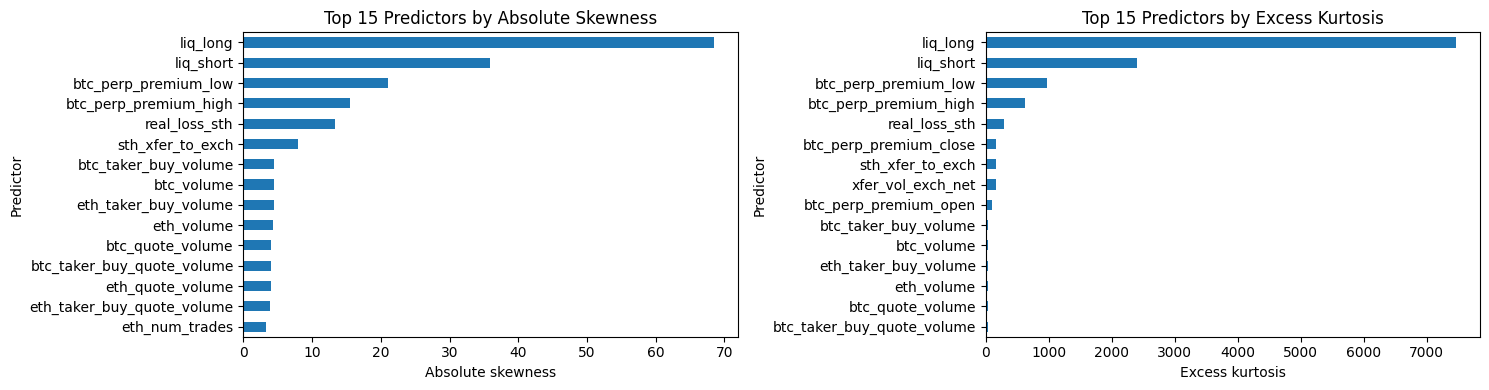

In [62]:
# Predictors with the most extreme skewness and kurtosis
n_show = 15
skew_plot = X_train_diag["skewness"].abs().nlargest(n_show).sort_values()
kurt_plot = X_train_diag["excess_kurtosis"].nlargest(n_show).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

skew_plot.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"Top {n_show} Predictors by Absolute Skewness")
axes[0].set_xlabel("Absolute skewness")
axes[0].set_ylabel("Predictor")

kurt_plot.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Top {n_show} Predictors by Excess Kurtosis")
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_ylabel("Predictor")

plt.tight_layout()
plt.show()

Liquidation variables show the most extreme skewness and excess kurtosis, followed by selected premium-index and on-chain variables. These series will require nonlinear transformation or event-based treatment during feature engineering.

**d) Zero-Inflated and Event-Driven Variables**

Zero-value concentration is examined because some predictors are inactive for long periods and only become non-zero during specific market events. In such cases, the occurrence of an event may carry different information from its magnitude, which may justify separate indicator and intensity features.

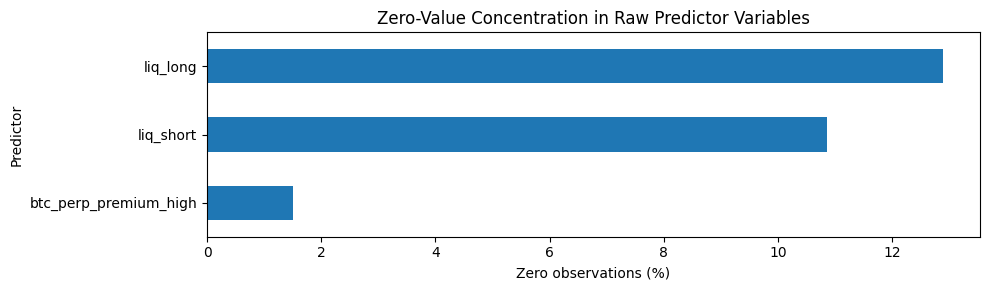

In [63]:
# Predictors with a material concentration of zero values
zero_threshold = 1.0
zero_plot = X_train_diag.loc[X_train_diag["zero_pct"] >= zero_threshold, "zero_pct"].sort_values()

if zero_plot.empty:
    print(f"No raw predictors have zero values in at least {zero_threshold:.0f}% of observed rows.")
else:
    plt.figure(figsize=(10, max(3, len(zero_plot) * 0.35)))
    zero_plot.plot(kind="barh")
    plt.title("Zero-Value Concentration in Raw Predictor Variables")
    plt.xlabel("Zero observations (%)")
    plt.ylabel("Predictor")
    plt.tight_layout()
    plt.show()

Liquidation variables are clearly zero-inflated and episodic, with non-zero observations concentrated around periods of market stress. Feature engineering should therefore consider both a binary liquidation-event indicator and a transformed measure of liquidation magnitude. The smaller zero concentration in the premium-index high is less material.

**e) Target Variable Analysis Across Candidate Horizons**

The prediction horizon is treated as part of the research problem rather than fixed in advance. Forward log returns over 1, 4, 6, 8, 12 and 24 hours are therefore examined using the training sample before a final modelling target is selected.

The EDA compares the distribution and class balance of each candidate target. This provides an initial view of how return dispersion, tail behaviour and directional balance change across horizons. The final horizon will be selected later using the full training-sample evidence, including these distributional findings and feature–target signal strength.

In [64]:
# Candidate target distributions and class balance
target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

target_data = targets_train[target_cols]
target_summary = target_data.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

target_summary["negative_count"] = target_data.le(0).sum()
target_summary["positive_count"] = target_data.gt(0).sum()
target_summary["positive_pct"] = target_data.gt(0).sum().div(target_data.notna().sum()).mul(100)
target_summary["negative_pct"] = target_data.le(0).sum().div(target_data.notna().sum()).mul(100)

target_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,negative_count,positive_count,positive_pct,negative_pct
fwd_logret_1h,"45,537.0000",0.0001,0.0070,-0.2071,-0.0207,-0.0095,-0.0024,0.0001,0.0026,0.0097,0.0200,0.1508,22351,23186,50.9168,49.0832
fwd_logret_4h,"45,537.0000",0.0002,0.0138,-0.3593,-0.0409,-0.0201,-0.0047,0.0002,0.0052,0.0205,0.0401,0.1867,22190,23347,51.2704,48.7296
fwd_logret_6h,"45,537.0000",0.0003,0.0167,-0.3956,-0.0490,-0.0247,-0.0058,0.0003,0.0067,0.0253,0.0479,0.2797,22143,23394,51.3736,48.6264
fwd_logret_8h,"45,537.0000",0.0004,0.0192,-0.4083,-0.0564,-0.0284,-0.0068,0.0004,0.0079,0.0296,0.0557,0.3178,22035,23502,51.6108,48.3892
fwd_logret_12h,"45,537.0000",0.0006,0.0234,-0.3880,-0.0687,-0.0350,-0.0087,0.0005,0.0102,0.0367,0.0672,0.3204,21972,23565,51.7491,48.2509
fwd_logret_24h,"45,537.0000",0.0013,0.0337,-0.6416,-0.0968,-0.0499,-0.0132,0.0011,0.0163,0.0533,0.0936,0.2993,21581,23956,52.6078,47.3922


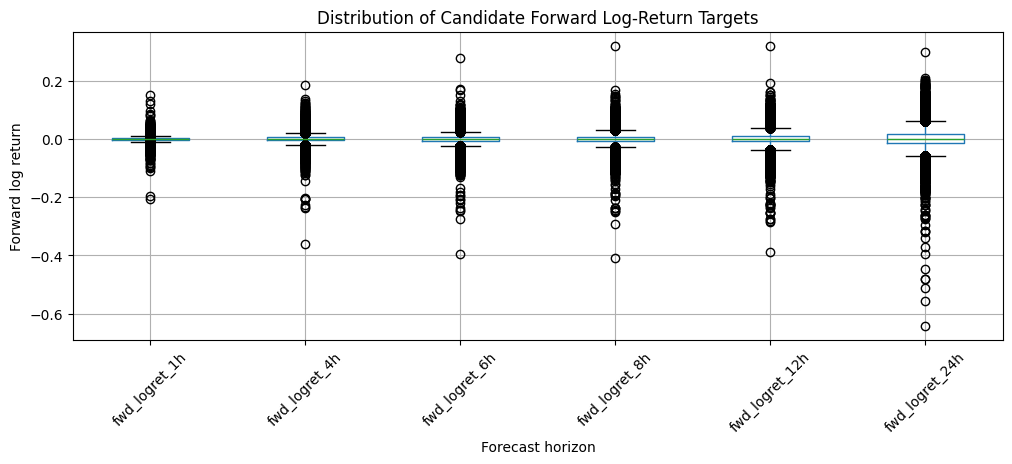

In [65]:
# Boxplots of candidate forward log-return targets
ax = target_data.boxplot(figsize=(12, 4), showfliers=True)

ax.set_title("Distribution of Candidate Forward Log-Return Targets")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forward log return")

plt.xticks(rotation=45)
plt.show()

The candidate return distributions remain centred close to zero, while dispersion and tail magnitude increase with the forecast horizon. Longer horizons therefore capture larger cumulative BTC price movements, whereas the shortest horizons remain more tightly concentrated around zero and may be more exposed to market noise.

These results describe the economic behaviour of the targets but do not by themselves identify the most predictable horizon. Final horizon selection will also consider the strength and stability of the relationships between the engineered features and each candidate target.

**f) Temporal Behaviour and Regime Variation**

Full-sample statistics may conceal changes in market conditions through time. The following diagnostics examine selected price, volatility, derivatives and positioning variables to identify volatility clustering, episodic dislocations and changing relationships that may require rolling, standardised or regime-sensitive features.

i) BTC Rolling 24-Hour Log Return and Realised Volatility

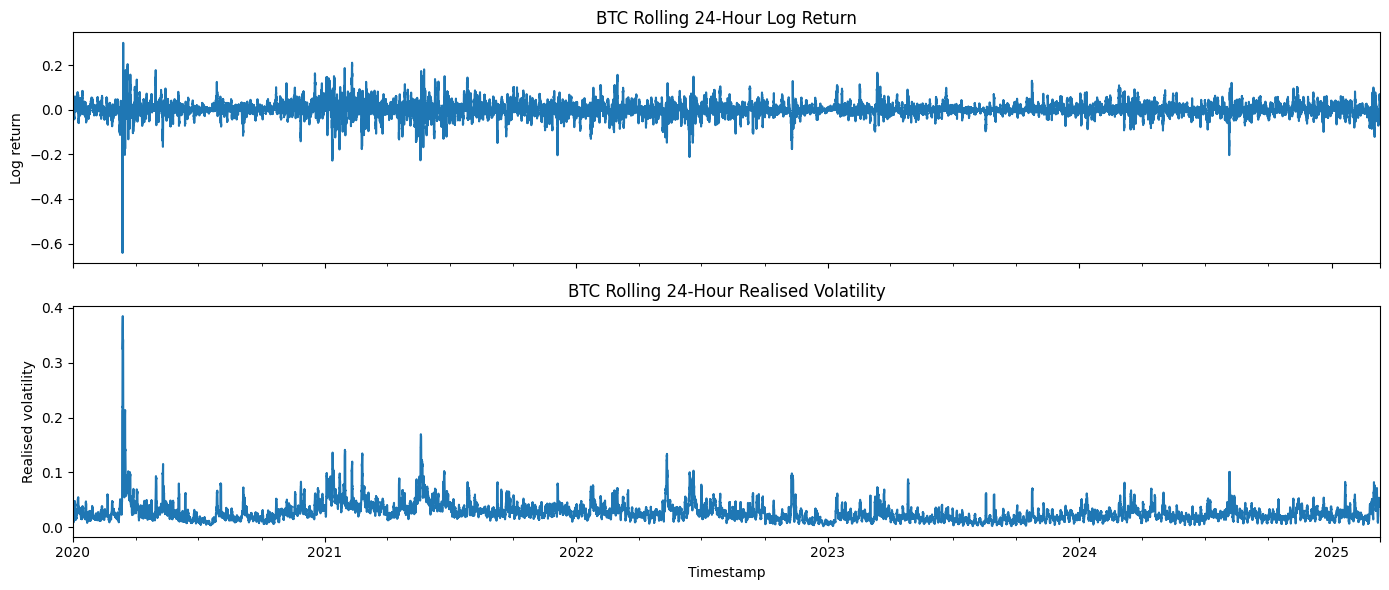

In [66]:
# BTC rolling 24-hour return and realised volatility
temporal_df = X_train.set_index("timestamp").copy()

temporal_df["btc_logret_1h"] = np.log(temporal_df["btc_close"] / temporal_df["btc_close"].shift(1))
temporal_df["btc_logret_24h"] = temporal_df["btc_logret_1h"].rolling(24).sum()
temporal_df["btc_realised_vol_24h"] = np.sqrt(temporal_df["btc_logret_1h"].pow(2).rolling(24).sum())
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

temporal_df["btc_logret_24h"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("BTC Rolling 24-Hour Log Return")
axes[0].set_ylabel("Log return")

temporal_df["btc_realised_vol_24h"].plot(ax=axes[1])
axes[1].set_title("BTC Rolling 24-Hour Realised Volatility")
axes[1].set_ylabel("Realised volatility")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The series show clear volatility clustering, with high-volatility periods accompanied by a wider range of positive and negative 24-hour returns. Realised volatility measures total price variation rather than directional movement, supporting its treatment as a market-state variable rather than a directional signal.

ii) BTC Perpetual Premium and Funding at 8-Hour Settlement Intervals

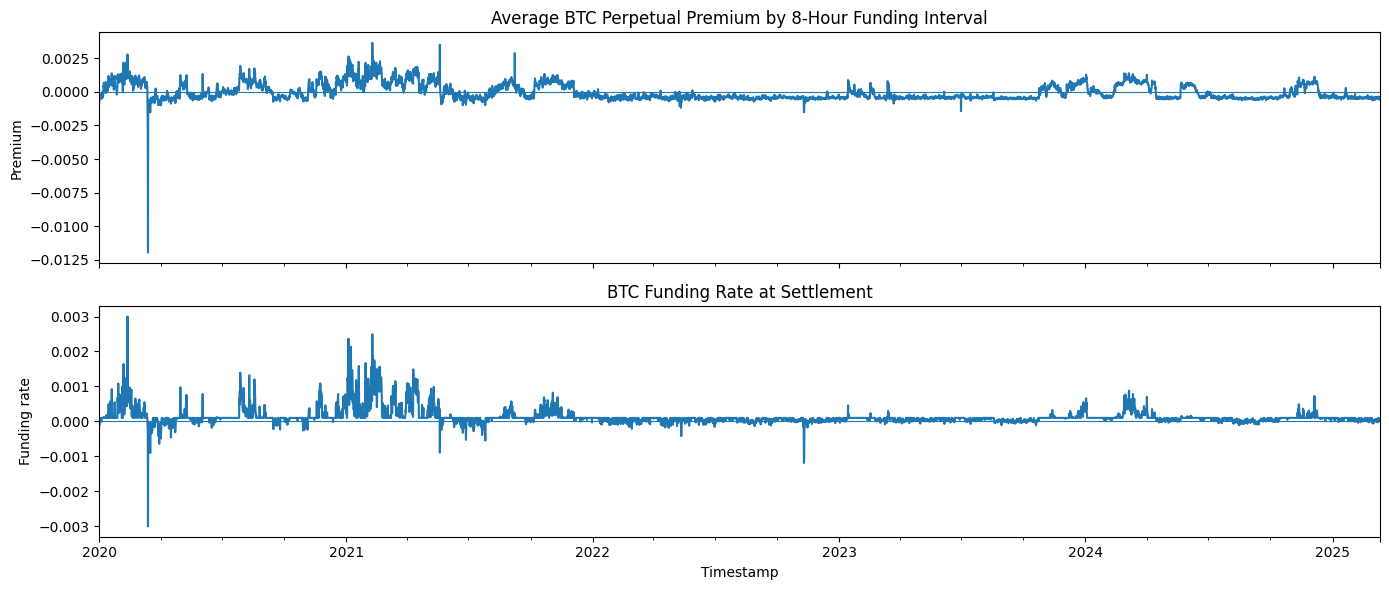

In [67]:
# BTC perpetual premium and funding at 8-hour settlement intervals
premium_funding_8h = temporal_df[["btc_perp_premium_close", "btc_funding"]].resample("8h", origin="start_day", closed="right", label="right").agg({
    "btc_perp_premium_close": "mean",
    "btc_funding": "last"})

premium_funding_8h = premium_funding_8h.dropna(subset=["btc_funding"])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

premium_funding_8h["btc_perp_premium_close"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Average BTC Perpetual Premium by 8-Hour Funding Interval")
axes[0].set_ylabel("Premium")

premium_funding_8h["btc_funding"].plot(ax=axes[1])
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("BTC Funding Rate at Settlement")
axes[1].set_ylabel("Funding rate")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

Premium and funding generally move in the same direction, while their largest joint movements occur during unusually crowded or stressed market conditions. Their levels, changes and relative divergence are therefore retained as candidates for feature engineering.

iii) Rolling Standardised Open Interest and Leverage Ratio

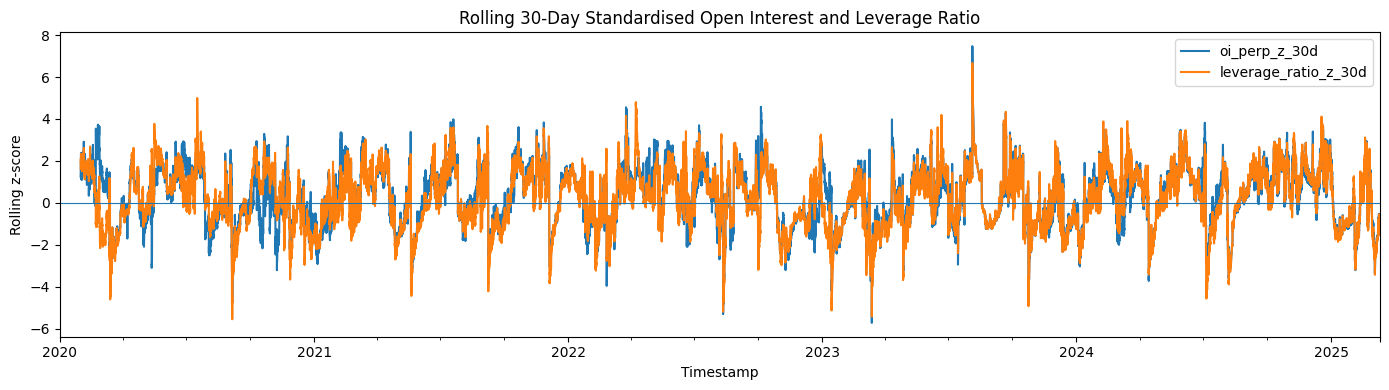

In [68]:
# Rolling 30-day standardisation of open interest and leverage ratio
rolling_window = 24 * 30

oi_mean = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).mean()
oi_std = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).std()

lev_mean = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).mean()
lev_std = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).std()

temporal_df["oi_perp_z_30d"] = (temporal_df["oi_perp"] - oi_mean) / oi_std.replace(0, np.nan)
temporal_df["leverage_ratio_z_30d"] = (temporal_df["leverage_ratio"] - lev_mean) / lev_std.replace(0, np.nan)

ax = temporal_df[["oi_perp_z_30d", "leverage_ratio_z_30d"]].plot(figsize=(14, 4))

ax.axhline(0, linewidth=0.8)
ax.set_title("Rolling 30-Day Standardised Open Interest and Leverage Ratio")
ax.set_ylabel("Rolling z-score")
ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

Rolling standardisation places open interest and leverage on a comparable scale relative to their recent histories. Although the measures often move together, temporary divergences indicate that growth in market participation does not always imply an equivalent change in leverage intensity. Both are therefore retained for separate feature construction and later redundancy testing.

Only selected raw variables are plotted because many levels are not directly comparable or informative before transformation. The remaining predictors will be examined during feature engineering using changes, returns, logarithmic transformations, rolling standardisation and relative spreads.

### **Part II — Deribit Futures Panel EDA**

Deribit futures data have a different structure from the fixed-dimensional hourly dataset. At each timestamp, several contracts with different expiry dates coexist, and the set of active instruments changes through time.

Individual contracts cannot therefore be merged directly into the hourly modelling matrix. Their availability is temporary, and their economic meaning changes as time to expiry declines. The Deribit panel is instead analysed separately and later converted into fixed-dimensional, point-in-time features during feature engineering.

Despite this structural complexity, the panel provides important information on futures maturity, liquidity, contract rolls, basis and term-structure conditions. The following analysis examines these characteristics and determines how the panel should be transformed for modelling.

a) **Contract Maturity and Roll Behaviour**

This subsection examines the maturity structure of the Deribit panel, including the number of active contracts, their remaining time to expiry and the timing of front-contract rolls. The perpetual contract is treated separately because it has no fixed maturity.

i) Load Deribit Data Panel

In [69]:
# Load Deribit training panel for EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"; os.chdir(data_dir)

deribit_train_panel = pd.read_csv("deribit_train_panel.csv", parse_dates=["timestamp", "expiration_timestamp"])
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True, errors="coerce")
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

deribit_train_panel["is_perpetual"] = deribit_train_panel["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit_train_panel["observation_timestamp"] = deribit_train_panel["timestamp"] - pd.Timedelta(hours=1)
deribit_train_panel["days_to_expiry"] = (deribit_train_panel["expiration_timestamp"] - deribit_train_panel["observation_timestamp"]).dt.total_seconds() / 86400

dated_mask = ~deribit_train_panel["is_perpetual"]

assert deribit_train_panel["timestamp"].notna().all()
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any()
assert deribit_train_panel.loc[dated_mask, "expiration_timestamp"].notna().all()
assert deribit_train_panel.loc[dated_mask, "days_to_expiry"].ge(0).all()

print("Deribit training shape:", deribit_train_panel.shape)
print("Training period:", deribit_train_panel["timestamp"].min(), "to", deribit_train_panel["timestamp"].max())
print("Instruments:", deribit_train_panel["instrument_name"].nunique())
print("Perpetual rows:", deribit_train_panel["is_perpetual"].sum())
print("Dated futures rows:", dated_mask.sum())
print("Minimum dated time to expiry:", deribit_train_panel.loc[dated_mask, "days_to_expiry"].min())

deribit_train_panel.head()

Deribit training shape: (214352, 16)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Instruments: 25
Perpetual rows: 45537
Dated futures rows: 168815
Minimum dated time to expiry: 0.0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp,is_perpetual,observation_timestamp,days_to_expiry
0,1577833200000,"7,440.5000","7,447.5000","7,426.5000","7,433.0000",9.9284,"73,830.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,177.3750
1,1577833200000,"7,292.0000","7,292.0000","7,274.0000","7,280.0000",26.5040,"193,000.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,86.3750
2,1577833200000,"7,178.5000","7,186.0000","7,164.0000","7,169.5000",301.1300,"2,161,100.0000",BTC-PERPETUAL,perpetual,perpetual,NaN,NaT,2020-01-01 00:00:00+00:00,True,2019-12-31 23:00:00+00:00,NaN
3,1577836800000,"7,433.0000","7,433.0000","7,414.0000","7,418.5000",9.6024,"71,270.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,177.3333
4,1577836800000,"7,277.0000","7,277.0000","7,265.5000","7,265.5000",17.7270,"128,870.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,86.3333


The panel contains one perpetual contract and a changing set of dated futures. The following summary examines contract availability and maturity coverage through time.

ii) Summarize active contracts and maturity coverage by timestamp

In [70]:
# Summarise active contracts and maturity coverage by timestamp
deribit_maturity_summary = deribit_train_panel.groupby("timestamp").agg(
    active_contracts=("instrument_name", "nunique"),
    active_perpetuals=("is_perpetual", "sum"),
    active_dated_futures=("is_perpetual", lambda x: (~x).sum()),
    min_days_to_expiry=("days_to_expiry", "min"),
    max_days_to_expiry=("days_to_expiry", "max"))

deribit_maturity_summary.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).round(2)

,active_contracts,active_perpetuals,active_dated_futures,min_days_to_expiry,max_days_to_expiry
count,"45,537.0000","45,537.0000","45,537.0000","45,537.0000","45,537.0000"
mean,4.7100,1.0000,3.7100,45.9000,292.9900
std,0.5600,0.0000,0.5600,26.2600,55.3400
min,3.0000,1.0000,2.0000,0.0000,116.0400
1%,3.0000,1.0000,2.0000,0.9200,135.0100
25%,5.0000,1.0000,4.0000,23.3300,273.5400
50%,5.0000,1.0000,4.0000,45.9200,304.9600
75%,5.0000,1.0000,4.0000,68.5000,334.5800
99%,5.0000,1.0000,4.0000,90.7100,366.2800
max,6.0000,1.0000,5.0000,97.9600,371.0000


A typical timestamp contains one perpetual contract and four dated futures. The nearest dated contract has a median time to expiry of approximately 46 days, while the longest available maturity is typically around 305 days. The panel therefore covers the front of the futures curve to roughly one year and supports the construction of roll-aware term-structure features.

iii) Identify the Front Dated Future and Contract Roll Dates

In [71]:
# Identify the front dated future and contract roll dates
deribit_dated = deribit_train_panel.loc[~deribit_train_panel["is_perpetual"]].copy()
deribit_dated = deribit_dated.sort_values(["timestamp", "days_to_expiry", "instrument_name"])

deribit_front = deribit_dated.groupby("timestamp", as_index=False).first()
deribit_front = deribit_front[["timestamp", "instrument_name", "days_to_expiry", "close", "volume", "cost"]]

deribit_front["previous_instrument"] = deribit_front["instrument_name"].shift()
deribit_front["is_roll"] = deribit_front["instrument_name"].ne(deribit_front["previous_instrument"])
deribit_front.loc[deribit_front.index[0], "is_roll"] = False

deribit_rolls = deribit_front.loc[
    deribit_front["is_roll"],
    ["timestamp", "previous_instrument", "instrument_name", "days_to_expiry"]
].reset_index(drop=True)

roll_spacing_days = deribit_rolls["timestamp"].diff().dt.total_seconds().div(86400)

print("Front-contract observations:", len(deribit_front))
print("Front-contract changes:", len(deribit_rolls))
print("Median days between rolls:", roll_spacing_days.median())

deribit_rolls

Front-contract observations: 45537
Front-contract changes: 20
Median days between rolls: 91.0


,timestamp,previous_instrument,instrument_name,days_to_expiry
0,2020-03-27 10:00:00+00:00,BTC-27MAR20,BTC-26JUN20,90.9583
1,2020-06-26 10:00:00+00:00,BTC-26JUN20,BTC-25SEP20,90.9583
2,2020-09-25 10:00:00+00:00,BTC-25SEP20,BTC-25DEC20,90.9583
3,2020-12-25 10:00:00+00:00,BTC-25DEC20,BTC-26MAR21,90.9583
4,2021-03-26 10:00:00+00:00,BTC-26MAR21,BTC-25JUN21,90.9583
5,2021-06-25 10:00:00+00:00,BTC-25JUN21,BTC-24SEP21,90.9583
6,2021-09-24 10:00:00+00:00,BTC-24SEP21,BTC-31DEC21,97.9583
7,2021-12-31 10:00:00+00:00,BTC-31DEC21,BTC-25MAR22,83.9583
8,2022-03-25 10:00:00+00:00,BTC-25MAR22,BTC-24JUN22,90.9583
9,2022-06-24 10:00:00+00:00,BTC-24JUN22,BTC-30SEP22,97.9583


The changing front contract confirms that a continuous front-futures series must be constructed explicitly rather than linked by fixed instrument name.

**b) Liquidity and Data Reliability**

This subsection examines trading activity across perpetual and dated futures to assess whether the contracts are sufficiently liquid and reliable for feature construction. The analysis considers inactive observations, differences across contract types and whether liquidity declines with maturity.

i) Compares structural liquidity characteristics for perpetual and dated futures

In [72]:
# Summarise trading activity and inactive observations
deribit_train_panel["contract_type"] = np.where(deribit_train_panel["is_perpetual"], "Perpetual", "Dated futures")
deribit_train_panel["zero_volume"] = deribit_train_panel["volume"].eq(0)
deribit_train_panel["zero_cost"] = deribit_train_panel["cost"].eq(0)
deribit_train_panel["negative_volume"] = deribit_train_panel["volume"].lt(0)
deribit_train_panel["negative_cost"] = deribit_train_panel["cost"].lt(0)
deribit_train_panel["flat_candle"] = deribit_train_panel[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_liquidity_summary = deribit_train_panel.groupby("contract_type").agg(
    observations=("instrument_name", "size"),
    instruments=("instrument_name", "nunique"),
    missing_volume=("volume", lambda x: x.isna().sum()),
    missing_cost=("cost", lambda x: x.isna().sum()),
    negative_volume=("negative_volume", "sum"),
    negative_cost=("negative_cost", "sum"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_liquidity_summary[pct_cols] = deribit_liquidity_summary[pct_cols].mul(100)

deribit_liquidity_summary.round(2)

,observations,instruments,missing_volume,missing_cost,negative_volume,negative_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct,median_volume,median_cost,mean_cost
contract_type,,,,,,,,,,,,
Dated futures,168815,24,0,0,0,0,3.6800,3.6800,6.3400,4.8800,"180,940.0000","803,456.0500"
Perpetual,45537,1,0,0,0,0,0.0100,0.0100,0.0200,370.0700,"11,787,750.0000","21,431,112.8100"


There are no missing or negative volume and cost observations. The perpetual contract is highly active, with few zero-activity or flat-candle observations. Dated futures are less liquid but remain usable for term-structure analysis, subject to liquidity screening or weighting during feature construction.

ii) Compare dated-futures liquidity across maturity buckets

This section groups dated futures by time to expiry to assess whether liquidity deteriorates materially at longer maturities.

In [73]:
# Compare dated-futures liquidity across maturity buckets
maturity_bins = [0, 30, 90, 180, np.inf]
maturity_labels = ["0–30 days", "31–90 days", "91–180 days", "181+ days"]

deribit_dated["maturity_bucket"] = pd.cut(
    deribit_dated["days_to_expiry"],
    bins=maturity_bins,
    labels=maturity_labels,
    include_lowest=True)

deribit_dated["zero_volume"] = deribit_dated["volume"].eq(0)
deribit_dated["zero_cost"] = deribit_dated["cost"].eq(0)
deribit_dated["flat_candle"] = deribit_dated[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_maturity_liquidity = deribit_dated.groupby("maturity_bucket", observed=True).agg(
    observations=("instrument_name", "size"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_maturity_liquidity[pct_cols] = deribit_maturity_liquidity[pct_cols].mul(100)

deribit_maturity_liquidity.round(2)

,observations,median_volume,median_cost,mean_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct
maturity_bucket,,,,,,,
0–30 days,14756,30.8100,"977,285.0000","2,159,923.8200",0.2000,0.2000,0.2400
31–90 days,30153,21.1600,"683,780.0000","1,664,919.4800",0.1000,0.1000,0.2500
91–180 days,44889,8.5400,"287,240.0000","765,148.8900",0.5100,0.5100,1.1900
181+ days,79017,1.0600,"41,730.0000","243,169.3500",7.4900,7.4900,12.7400


Liquidity declines with maturity, particularly beyond 180 days. Far-dated contracts should therefore be excluded, down-weighted or used only within liquidity-aware term-structure features.

**c) Futures Basis and Term-Structure Behaviour**

Dated-futures prices are compared with BTC spot to calculate percentage basis. The nearest two contracts are then used to examine the slope and shape of the front futures curve.

i) Construct the Front Futures Curve Slope

In [74]:
# Rebuild dated-futures basis and construct the front futures curve slope
btc_spot = X_train[["timestamp", "btc_close"]].copy()
btc_spot["timestamp"] = pd.to_datetime(btc_spot["timestamp"], utc=True)
btc_spot = btc_spot.rename(columns={"timestamp": "observation_timestamp"})

deribit_basis = deribit_dated.merge(btc_spot, on="observation_timestamp", how="left", validate="many_to_one")
deribit_basis = deribit_basis.dropna(subset=["btc_close"]).copy()
deribit_basis["basis_pct"] = 100 * (deribit_basis["close"] / deribit_basis["btc_close"] - 1)

curve_cols = ["timestamp", "instrument_name", "days_to_expiry", "basis_pct"]
curve_ranked = deribit_basis[curve_cols].sort_values(["timestamp", "days_to_expiry", "instrument_name"]).copy()
curve_ranked["maturity_rank"] = curve_ranked.groupby("timestamp").cumcount() + 1
curve_ranked = curve_ranked.loc[curve_ranked["maturity_rank"].le(2)].copy()

front_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(1), curve_cols].copy()
second_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(2), curve_cols].copy()

front_contract = front_contract.rename(columns={"instrument_name": "front_instrument", "days_to_expiry": "front_days", "basis_pct": "front_basis_pct"})
second_contract = second_contract.rename(columns={"instrument_name": "second_instrument", "days_to_expiry": "second_days", "basis_pct": "second_basis_pct"})

front_curve = front_contract.merge(second_contract, on="timestamp", how="inner", validate="one_to_one")
front_curve["curve_slope_pct"] = front_curve["second_basis_pct"] - front_curve["front_basis_pct"]
front_curve["curve_state"] = np.where(front_curve["curve_slope_pct"].ge(0), "Upward sloping", "Inverted")

front_curve_summary = pd.Series({
    "observations": len(front_curve),
    "median_front_basis_pct": front_curve["front_basis_pct"].median(),
    "median_second_basis_pct": front_curve["second_basis_pct"].median(),
    "median_curve_slope_pct": front_curve["curve_slope_pct"].median(),
    "upward_sloping_pct": 100 * front_curve["curve_state"].eq("Upward sloping").mean(),
    "inverted_pct": 100 * front_curve["curve_state"].eq("Inverted").mean()})

front_curve_summary.to_frame("value").T.round(2)

,observations,median_front_basis_pct,median_second_basis_pct,median_curve_slope_pct,upward_sloping_pct,inverted_pct
value,"45,536.0000",0.7700,2.7900,1.8500,96.3800,3.6200


The front futures curve is upward sloping in 96.4% of observations and inverted in only 3.6%. Curve inversion is therefore an uncommon condition and is retained as a candidate stress indicator.

**d) Implications for Deribit Feature Engineering**

Deribit contracts should be converted into fixed, roll-aware and point-in-time features rather than used directly by instrument name. Feature construction should prioritise the perpetual and nearer-dated contracts, with far-dated observations excluded or liquidity-weighted.

Candidate features include front-contract basis, curve slope, curve inversion, changes in curve slope, days to expiry and trading activity. These measures will be constructed from contracts available at each timestamp before alignment with the hourly modelling matrix.

**Part III — Insights from the EDA Process**

The EDA identified substantial differences in scale, distribution, sparsity and temporal behaviour across the raw predictors. Most variables will therefore enter the modelling matrix through returns, changes, rolling standardisation, relative spreads, nonlinear transformations or event indicators.

Deribit data will be converted separately into fixed roll-aware features. The next stage constructs and audits the engineered feature matrix before horizon selection and feature-selection analysis.

## **(V) Feature Engineering & Prediction Horizon Selection**

## **Part 1 - Feature Engineering**

### **Part I — Feature Engineering**

Feature engineering converts the cleaned source series into economically interpretable predictors using the findings from the EDA. Raw levels are transformed where appropriate into returns, changes, slopes, rolling standardisations, relative spreads and event indicators so that direction, magnitude, velocity and changing market conditions are represented more clearly.

The features are designed to capture BTC trend and volatility, derivatives positioning, cross-exchange conditions, futures term structure, on-chain behaviour and broader financial-market conditions. Deribit contracts are converted separately into fixed, roll-aware features before being aligned with the hourly modelling matrix.

All features are constructed using current and historical information only. The complete candidate matrix is then audited before the six forward-return horizons are compared using training data.

In [76]:
# Load training inputs for feature engineering
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train = pd.read_csv(DATA_PATH / "X_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
targets_train = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"]).sort_index()
deribit_train_panel = pd.read_csv(DATA_PATH / "deribit_train_panel.csv")

X_train.index = pd.to_datetime(X_train.index, utc=True)
targets_train.index = pd.to_datetime(targets_train.index, utc=True)

deribit_train_panel = deribit_train_panel.drop(columns=deribit_train_panel.filter(regex=r"^Unnamed:").columns)
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True)
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

X_train_engineered = pd.DataFrame(index=X_train.index)

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

print(f"Training data: {X_train.shape} | {X_train.index.min()} to {X_train.index.max()}")
print(f"Targets: {targets_train.shape} | {len(target_cols)} candidate horizons")
print(f"Deribit panel: {deribit_train_panel.shape} | {deribit_train_panel['instrument_name'].nunique()} instruments")
print(f"Initial engineered matrix: {X_train_engineered.shape}")

Training data: (45537, 48) | 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Targets: (45537, 7) | 6 candidate horizons
Deribit panel: (214352, 13) | 25 instruments
Initial engineered matrix: (45537, 0)


### **a) BTC Price, Trend and Momentum**

Trend and momentum are measured using log returns, rolling log-price slopes and changes in trend speed across 4-, 8- and 24-hour windows. Trend-quality statistics are calculated only over 8 and 24 hours, while acceleration compares consecutive non-overlapping return periods.

In [77]:
# a) BTC Price, Trend and Momentum

btc_close = pd.to_numeric(X_train["btc_close"], errors="coerce")
btc_log_price = np.log(btc_close)
btc_trend_features = pd.DataFrame(index=X_train.index)

# Log returns
btc_trend_features["btc_ret_1h"] = btc_log_price.diff(1)
btc_trend_features["btc_ret_4h"] = btc_log_price.diff(4)
btc_trend_features["btc_ret_24h"] = btc_log_price.diff(24)

# Rolling log-price regression
def rolling_logprice_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)
    sum_y = log_price.rolling(window).sum()
    sum_y2 = log_price.pow(2).rolling(window).sum()
    sum_xy = log_price.rolling(window).apply(lambda y: np.dot(y, x), raw=True)
    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt((residual_ss / (window - 2)) / sxx)
    slope_tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)
    return slope, slope_tstat, r2

slope_4h, _, _ = rolling_logprice_regression(btc_log_price, 4)
slope_8h, slope_tstat_8h, trend_r2_8h = rolling_logprice_regression(btc_log_price, 8)
slope_24h, slope_tstat_24h, trend_r2_24h = rolling_logprice_regression(btc_log_price, 24)

# Trend direction and quality
btc_trend_features["btc_logprice_slope_4h"] = slope_4h
btc_trend_features["btc_logprice_slope_8h"] = slope_8h
btc_trend_features["btc_logprice_slope_24h"] = slope_24h
btc_trend_features["btc_slope_tstat_8h"] = slope_tstat_8h
btc_trend_features["btc_slope_tstat_24h"] = slope_tstat_24h
btc_trend_features["btc_trend_r2_8h"] = trend_r2_8h
btc_trend_features["btc_trend_r2_24h"] = trend_r2_24h

# Fast-versus-slow trend
btc_trend_features["btc_slope_spread_4h_24h"] = slope_4h - slope_24h
btc_trend_features["btc_slope_spread_8h_24h"] = slope_8h - slope_24h

# Return acceleration
btc_ret_8h = btc_log_price.diff(8)
btc_trend_features["btc_return_acceleration_4h"] = btc_trend_features["btc_ret_4h"] - btc_trend_features["btc_ret_4h"].shift(4)
btc_trend_features["btc_return_acceleration_8h"] = btc_ret_8h - btc_ret_8h.shift(8)

btc_trend_features = btc_trend_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(btc_trend_features)

print(f"Features added: {btc_trend_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_trend_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": btc_trend_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_trend_features.isna().sum()}))

Features added: 14
Engineered matrix: (45537, 14)
Longest warm-up: 24 rows


,first_valid,warmup_rows
btc_ret_1h,2020-01-01 01:00:00+00:00,1
btc_ret_4h,2020-01-01 04:00:00+00:00,4
btc_ret_24h,2020-01-02 00:00:00+00:00,24
btc_logprice_slope_4h,2020-01-01 03:00:00+00:00,3
btc_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
btc_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_slope_tstat_8h,2020-01-01 07:00:00+00:00,7
btc_slope_tstat_24h,2020-01-01 23:00:00+00:00,23
btc_trend_r2_8h,2020-01-01 07:00:00+00:00,7
btc_trend_r2_24h,2020-01-01 23:00:00+00:00,23


### **b) BTC Volatility, Asymmetry and Regimes**

These are features created to describe the magnitude, direction and persistence of BTC risk rather than price direction alone. Realised volatility measures recent return variation, downside-variance shares distinguish negative from total volatility, and drawdown features capture the depth of recent price weakness.

Volatility-of-volatility, the Hurst exponent and the EGARCH regime measure are added to identify changing market conditions, including unstable volatility, trend persistence and periods of unusually high or low conditional risk.

In [78]:
# b) BTC Volatility, Asymmetry and Regimes

btc_volatility_features = pd.DataFrame(index=X_train.index)

btc_ret_1h = btc_trend_features["btc_ret_1h"]
btc_squared_return = btc_ret_1h.pow(2)
btc_downside_squared_return = btc_ret_1h.clip(upper=0).pow(2)

# Realised volatility
for window in [4, 8, 24]:
    rolling_variance = btc_squared_return.rolling(window).sum()
    btc_volatility_features[f"btc_rv_{window}h"] = np.sqrt(rolling_variance)

# Downside variance share
for window in [8, 24]:
    downside_variance = btc_downside_squared_return.rolling(window).sum()
    total_variance = btc_squared_return.rolling(window).sum().replace(0, np.nan)
    btc_volatility_features[f"btc_downside_variance_share_{window}h"] = (downside_variance / total_variance).clip(0, 1)

# Volatility instability and drawdown
btc_volatility_features["btc_vol_of_vol_24h"] = btc_volatility_features["btc_rv_4h"].rolling(24).std()
btc_volatility_features["btc_drawdown_8h"] = btc_close / btc_close.rolling(8).max() - 1
btc_volatility_features["btc_drawdown_24h"] = btc_close / btc_close.rolling(24).max() - 1

drawdown_8h_limit = btc_volatility_features["btc_drawdown_8h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_24h_limit = btc_volatility_features["btc_drawdown_24h"].rolling(720, min_periods=168).quantile(0.05).shift(1)

drawdown_ready = drawdown_8h_limit.notna() & drawdown_24h_limit.notna()
drawdown_extreme = (btc_volatility_features["btc_drawdown_8h"] < drawdown_8h_limit) | (btc_volatility_features["btc_drawdown_24h"] < drawdown_24h_limit)

btc_volatility_features["btc_drawdown_extreme_flag"] = drawdown_extreme.astype(float).where(drawdown_ready)

# Rolling Hurst exponent
hurst_window = 168
hurst_update_frequency = 24
hurst_scales = np.array([1, 2, 4, 8, 12, 24])

def estimate_hurst(return_window):
    scale_values = []
    variance_values = []

    for scale in hurst_scales:
        usable_length = len(return_window) // scale * scale
        aggregated_returns = return_window[-usable_length:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated_returns, ddof=1)

        if np.isfinite(variance) and variance > 0:
            scale_values.append(np.log(scale))
            variance_values.append(np.log(variance))

    return np.polyfit(scale_values, variance_values, 1)[0] / 2 if len(scale_values) >= 3 else np.nan

btc_hurst = pd.Series(np.nan, index=X_train.index)

for position in range(hurst_window, len(X_train), hurst_update_frequency):
    return_window = btc_ret_1h.iloc[position - hurst_window + 1:position + 1]

    if return_window.notna().all():
        btc_hurst.iloc[position] = estimate_hurst(return_window.to_numpy())

btc_volatility_features["btc_hurst_168h"] = btc_hurst.ffill()

# Causal EGARCH volatility
egarch_window = 4320
egarch_refit_frequency = 24
egarch_returns = btc_ret_1h * 100
egarch_conditional_vol = pd.Series(np.nan, index=X_train.index)

for position in range(egarch_window, len(X_train), egarch_refit_frequency):
    estimation_start = position - egarch_window + 1
    segment_end = min(position + egarch_refit_frequency, len(X_train))

    estimation_sample = egarch_returns.iloc[estimation_start:position + 1].dropna()
    filtering_sample = egarch_returns.iloc[estimation_start:segment_end].dropna()

    if len(estimation_sample) != egarch_window:
        continue

    model = arch_model(estimation_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    fitted_model = model.fit(disp="off", show_warning=False)

    filtering_model = arch_model(filtering_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    filtered_model = filtering_model.fix(fitted_model.params)

    segment_index = X_train.index[position:segment_end]
    egarch_conditional_vol.loc[segment_index] = filtered_model.conditional_volatility.reindex(segment_index) / 100

egarch_mean = egarch_conditional_vol.rolling(720).mean().shift(1)
egarch_std = egarch_conditional_vol.rolling(720).std().shift(1)

btc_volatility_features["btc_egarch_conditional_vol"] = egarch_conditional_vol
btc_volatility_features["btc_egarch_vol_regime"] = (egarch_conditional_vol - egarch_mean) / egarch_std.replace(0, np.nan)

btc_volatility_features = btc_volatility_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(btc_volatility_features)

print(f"Features added: {btc_volatility_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_volatility_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": btc_volatility_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_volatility_features.isna().sum()}))

Features added: 12
Engineered matrix: (45537, 26)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_rv_4h,2020-01-01 04:00:00+00:00,4
btc_rv_8h,2020-01-01 08:00:00+00:00,8
btc_rv_24h,2020-01-02 00:00:00+00:00,24
btc_downside_variance_share_8h,2020-01-01 08:00:00+00:00,8
btc_downside_variance_share_24h,2020-01-02 00:00:00+00:00,24
btc_vol_of_vol_24h,2020-01-02 03:00:00+00:00,27
btc_drawdown_8h,2020-01-01 07:00:00+00:00,7
btc_drawdown_24h,2020-01-01 23:00:00+00:00,23
btc_drawdown_extreme_flag,2020-01-08 23:00:00+00:00,191
btc_hurst_168h,2020-01-08 00:00:00+00:00,168


### **c) Premium, Funding and CEX Microstructure**

These features are created to capture short-horizon conditions in the perpetual-futures and spot markets. Premium and funding describe the cost and direction of leveraged positioning, while their changes, standardised levels and divergence may indicate crowded or stressed conditions.

Binance volume and taker flow measure trading intensity and buying pressure, while the Coinbase–Binance price spread captures temporary cross-exchange dislocations.

In [79]:
# c) Premium, Funding and CEX Microstructure
cex_microstructure_features = pd.DataFrame(index=X_train.index)

premium = pd.to_numeric(X_train["btc_perp_premium_close"], errors="coerce")
funding = pd.to_numeric(X_train["btc_funding"], errors="coerce").ffill()
btc_volume = pd.to_numeric(X_train["btc_volume"], errors="coerce")
btc_taker_buy_volume = pd.to_numeric(X_train["btc_taker_buy_volume"], errors="coerce")
coinbase_close = pd.to_numeric(X_train["coinbase_btc_close"], errors="coerce")

# Premium
premium_mean = premium.rolling(168).mean()
premium_std = premium.rolling(168).std()
premium_zscore = (premium - premium_mean) / premium_std.replace(0, np.nan)

cex_microstructure_features["premium_level"] = premium
cex_microstructure_features["premium_change_4h"] = premium.diff(4)
cex_microstructure_features["premium_zscore_168h"] = premium_zscore

# Funding
funding_mean = funding.rolling(168).mean()
funding_std = funding.rolling(168).std()
funding_zscore = (funding - funding_mean) / funding_std.replace(0, np.nan)

cex_microstructure_features["funding_rate"] = funding
cex_microstructure_features["funding_change_8h"] = funding.diff(8)
cex_microstructure_features["funding_zscore_168h"] = funding_zscore
cex_microstructure_features["hours_since_funding"] = X_train.index.hour % 8

# Premium-funding dislocation
premium_funding_divergence = premium_zscore - funding_zscore
premium_funding_disagreement = (premium * funding < 0).astype(float).where(premium.notna() & funding.notna())

cex_microstructure_features["premium_funding_divergence"] = premium_funding_divergence
cex_microstructure_features["premium_funding_abs_divergence"] = premium_funding_divergence.abs()
cex_microstructure_features["premium_funding_disagreement"] = premium_funding_disagreement

divergence_limit = premium_funding_divergence.abs().rolling(720, min_periods=168).quantile(0.95).shift(1)
cex_microstructure_features["premium_funding_extreme_flag"] = (premium_funding_divergence.abs() > divergence_limit).astype(float).where(divergence_limit.notna())

# Binance volume and taker flow
btc_log_volume = np.log1p(btc_volume.clip(lower=0))
btc_taker_buy_share = (btc_taker_buy_volume / btc_volume.replace(0, np.nan)).fillna(0.5).clip(0, 1)

cex_microstructure_features["binance_volume_log_change_4h"] = btc_log_volume.diff(4)
cex_microstructure_features["binance_taker_buy_share"] = btc_taker_buy_share
cex_microstructure_features["binance_taker_buy_share_change_4h"] = btc_taker_buy_share.diff(4)

# Coinbase-Binance price spread
coinbase_binance_spread = coinbase_close / btc_close - 1
spread_mean = coinbase_binance_spread.rolling(168).mean()
spread_std = coinbase_binance_spread.rolling(168).std()
spread_zscore = (coinbase_binance_spread - spread_mean) / spread_std.replace(0, np.nan)

cex_microstructure_features["coinbase_binance_price_spread"] = coinbase_binance_spread
cex_microstructure_features["coinbase_binance_spread_zscore_168h"] = spread_zscore

cex_microstructure_features = cex_microstructure_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(cex_microstructure_features)

print(f"Features added: {cex_microstructure_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {cex_microstructure_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": cex_microstructure_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": cex_microstructure_features.isna().sum()}))

Features added: 16
Engineered matrix: (45537, 42)
Longest warm-up: 2,666 rows


,first_valid,warmup_rows
premium_level,2020-01-01 00:00:00+00:00,0
premium_change_4h,2020-01-01 04:00:00+00:00,4
premium_zscore_168h,2020-01-07 23:00:00+00:00,167
funding_rate,2020-01-01 00:00:00+00:00,0
funding_change_8h,2020-01-01 08:00:00+00:00,8
funding_zscore_168h,2020-01-07 23:00:00+00:00,2666
hours_since_funding,2020-01-01 00:00:00+00:00,0
premium_funding_divergence,2020-01-07 23:00:00+00:00,2666
premium_funding_abs_divergence,2020-01-07 23:00:00+00:00,2666
premium_funding_disagreement,2020-01-01 00:00:00+00:00,0


### **d) ETH and Cross-Crypto Features**


ETH is included as a cross-crypto market reference because its price behaviour often reflects broader digital-asset conditions beyond BTC alone. The features capture ETH trend over 8- and 24-hour windows and compare short-term BTC and ETH slopes to identify relative strength or divergence between the two assets.

In [80]:
# d) ETH and Cross-Crypto Features
eth_close = pd.to_numeric(X_train["eth_close"], errors="coerce")
eth_log_price = np.log(eth_close)

eth_features = pd.DataFrame(index=X_train.index)

eth_slope_8h, _, _ = rolling_logprice_regression(eth_log_price, 8)
eth_slope_24h, _, _ = rolling_logprice_regression(eth_log_price, 24)

eth_features["eth_logprice_slope_8h"] = eth_slope_8h
eth_features["eth_logprice_slope_24h"] = eth_slope_24h
eth_features["btc_eth_slope_spread_8h"] = btc_trend_features["btc_logprice_slope_8h"] - eth_slope_8h

eth_features = eth_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(eth_features)

print(f"Features added: {eth_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {eth_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": eth_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": eth_features.isna().sum()}))

Features added: 3
Engineered matrix: (45537, 45)
Longest warm-up: 23 rows


,first_valid,warmup_rows
eth_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
eth_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_eth_slope_spread_8h,2020-01-01 07:00:00+00:00,7


### **e) Open Interest, Leverage and Liquidations**

These features are created to capture changes in derivatives positioning and market stress. Open interest measures the amount of outstanding futures exposure, while the leverage ratio indicates how aggressively that exposure is funded.

Rates of change, slopes and rolling z-scores are used to distinguish normal positioning from unusually crowded conditions. Long and short liquidations are transformed separately to capture episodic deleveraging pressure on each side of the market.

In [81]:
# e) Open Interest, Leverage and Liquidations
positioning_features = pd.DataFrame(index=X_train.index)

open_interest = pd.to_numeric(X_train["oi_perp"], errors="coerce")
leverage_ratio = pd.to_numeric(X_train["leverage_ratio"], errors="coerce")
long_liquidations = pd.to_numeric(X_train["liq_long"], errors="coerce")
short_liquidations = pd.to_numeric(X_train["liq_short"], errors="coerce")

open_interest_log = np.log(open_interest.where(open_interest > 0))
leverage_log = np.log(leverage_ratio.where(leverage_ratio > 0))

# Open interest
oi_mean = open_interest_log.rolling(168).mean()
oi_std = open_interest_log.rolling(168).std()
oi_zscore = (open_interest_log - oi_mean) / oi_std.replace(0, np.nan)
oi_slope_8h, _, _ = rolling_logprice_regression(open_interest_log, 8)

positioning_features["oi_log_roc_4h"] = open_interest_log.diff(4)
positioning_features["oi_log_roc_24h"] = open_interest_log.diff(24)
positioning_features["oi_slope_8h"] = oi_slope_8h
positioning_features["oi_zscore_168h"] = oi_zscore

# Leverage
leverage_mean = leverage_log.rolling(168).mean()
leverage_std = leverage_log.rolling(168).std()
leverage_zscore = (leverage_log - leverage_mean) / leverage_std.replace(0, np.nan)
leverage_slope_8h, _, _ = rolling_logprice_regression(leverage_log, 8)

positioning_features["leverage_log_roc_4h"] = leverage_log.diff(4)
positioning_features["leverage_log_roc_24h"] = leverage_log.diff(24)
positioning_features["leverage_slope_8h"] = leverage_slope_8h
positioning_features["leverage_zscore_168h"] = leverage_zscore

# Positioning divergence
positioning_features["oi_leverage_divergence"] = oi_zscore - leverage_zscore

# Liquidation pressure
long_liquidations = long_liquidations.fillna(0)
short_liquidations = short_liquidations.fillna(0)

positioning_features["long_liquidation_pressure"] = np.log1p(long_liquidations.clip(lower=0))
positioning_features["short_liquidation_pressure"] = np.log1p(short_liquidations.clip(lower=0))

positioning_features = positioning_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(positioning_features)

print(f"Features added: {positioning_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {positioning_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": positioning_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": positioning_features.isna().sum()}))

Features added: 11
Engineered matrix: (45537, 56)
Longest warm-up: 167 rows


,first_valid,warmup_rows
oi_log_roc_4h,2020-01-01 04:00:00+00:00,4
oi_log_roc_24h,2020-01-02 00:00:00+00:00,24
oi_slope_8h,2020-01-01 07:00:00+00:00,7
oi_zscore_168h,2020-01-07 23:00:00+00:00,167
leverage_log_roc_4h,2020-01-01 04:00:00+00:00,4
leverage_log_roc_24h,2020-01-02 00:00:00+00:00,24
leverage_slope_8h,2020-01-01 07:00:00+00:00,7
leverage_zscore_168h,2020-01-07 23:00:00+00:00,167
oi_leverage_divergence,2020-01-07 23:00:00+00:00,167
long_liquidation_pressure,2020-01-01 00:00:00+00:00,0


### **f) Deribit Term Structure and Liquidity**

This section converts the changing Deribit futures panel into fixed hourly features. These features capture front-contract basis, curve slope, inversion, contract rolls, time to expiry and the distribution of trading activity across perpetual and dated futures. Based on the EDA findings, liquidity-weighted measures prioritise contracts within 180 days of expiry.

In [82]:
# f) Deribit Term Structure and Liquidity
deribit = deribit_train_panel.copy()

deribit["timestamp"] = pd.to_datetime(deribit["timestamp"], utc=True)
deribit["expiration_timestamp"] = pd.to_datetime(deribit["expiration_timestamp"], utc=True, errors="coerce")
deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)

deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
deribit["volume"] = pd.to_numeric(deribit["volume"], errors="coerce").fillna(0).clip(lower=0)
deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)

deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400
deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

# Rank dated futures by maturity
perpetual = deribit[deribit["is_perpetual"]].copy()
dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])
dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
perpetual = perpetual.drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)

deribit_features = pd.DataFrame(index=X_train.index)

# Front futures curve
deribit_features["deribit_front_basis_pct"] = front["basis_pct"]
deribit_features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]
deribit_features["deribit_curve_slope_change_4h"] = deribit_features["deribit_curve_slope_pct"].diff(4)
deribit_features["deribit_curve_slope_change_24h"] = deribit_features["deribit_curve_slope_pct"].diff(24)
deribit_features["deribit_curve_inversion_flag"] = (deribit_features["deribit_curve_slope_pct"] < 0).astype(float)
deribit_features["deribit_front_days_to_expiry"] = front["days_to_expiry"]

front_contract = front["instrument_name"]
deribit_features["deribit_front_roll_flag"] = front_contract.ne(front_contract.shift()).astype(float)
deribit_features.loc[front_contract.first_valid_index(), "deribit_front_roll_flag"] = 0

# Contract activity
hourly_volume = deribit.groupby("timestamp")["volume"].sum().reindex(X_train.index).fillna(0)
hourly_notional = deribit.groupby("timestamp")["cost"].sum().reindex(X_train.index).fillna(0)

perpetual_volume = perpetual["volume"].fillna(0)
front_volume = front["volume"].fillna(0)
perpetual_notional = perpetual["cost"].fillna(0)
front_notional = front["cost"].fillna(0)

deribit_features["deribit_perpetual_volume_share"] = (perpetual_volume / hourly_volume.replace(0, np.nan)).fillna(0).clip(0, 1)
deribit_features["deribit_front_volume_share"] = (front_volume / hourly_volume.replace(0, np.nan)).fillna(0).clip(0, 1)
deribit_features["deribit_front_perpetual_activity_ratio"] = np.log1p(front_notional) - np.log1p(perpetual_notional)
deribit_features["deribit_total_log_notional"] = np.log1p(hourly_notional)

# Liquidity-weighted basis for contracts within 180 days
liquid_dated = dated[dated["days_to_expiry"].le(180)].copy()
liquid_dated["weighted_basis"] = liquid_dated["basis_pct"] * liquid_dated["cost"]

weighted_basis = liquid_dated.groupby("timestamp")["weighted_basis"].sum()
dated_notional = liquid_dated.groupby("timestamp")["cost"].sum()
liquidity_weighted_basis = weighted_basis / dated_notional.replace(0, np.nan)

deribit_features["deribit_liquidity_weighted_basis"] = liquidity_weighted_basis.reindex(X_train.index).ffill()

# Joint Binance-Deribit activity
binance_log_volume = np.log1p(pd.to_numeric(X_train["btc_volume"], errors="coerce").clip(lower=0))
binance_mean = binance_log_volume.rolling(168).mean()
binance_std = binance_log_volume.rolling(168).std()
binance_activity_z = (binance_log_volume - binance_mean) / binance_std.replace(0, np.nan)

deribit_notional = deribit_features["deribit_total_log_notional"]
deribit_mean = deribit_notional.rolling(168).mean()
deribit_std = deribit_notional.rolling(168).std()
deribit_activity_z = (deribit_notional - deribit_mean) / deribit_std.replace(0, np.nan)

market_activity_score = pd.concat([binance_activity_z, deribit_activity_z], axis=1).max(axis=1)
activity_limit = market_activity_score.rolling(720, min_periods=168).quantile(0.95).shift(1)

deribit_features["market_activity_spike_flag"] = (market_activity_score > activity_limit).astype(float).where(activity_limit.notna())

deribit_features = deribit_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(deribit_features)

print(f"Features added: {deribit_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {deribit_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": deribit_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": deribit_features.isna().sum()}))

Features added: 13
Engineered matrix: (45537, 69)
Longest warm-up: 335 rows


,first_valid,warmup_rows
deribit_front_basis_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_change_4h,2020-01-01 05:00:00+00:00,5
deribit_curve_slope_change_24h,2020-01-02 01:00:00+00:00,25
deribit_curve_inversion_flag,2020-01-01 00:00:00+00:00,0
deribit_front_days_to_expiry,2020-01-01 00:00:00+00:00,0
deribit_front_roll_flag,2020-01-01 00:00:00+00:00,0
deribit_perpetual_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_perpetual_activity_ratio,2020-01-01 00:00:00+00:00,0


###**g) On-Chain Valuation and Holder Behaviour**

These features capture BTC valuation conditions, differences between short- and long-term holders, the share of supply in profit, exchange positioning and loss-selling activity. Rolling changes, slopes, z-scores and signed-log transformations are appled to allow the series comparable and able to distinguish normal market conditions from unusual investor-stress events.

In [83]:
# g) On-Chain Valuation and Holder Behaviour
exchange_col = "exchange_net_position_change"
if exchange_col not in X_train.columns:
    exchange_col = "exch_net_pos_chg"

onchain_features = pd.DataFrame(index=X_train.index)

mvrv = pd.to_numeric(X_train["mvrv_z"], errors="coerce").ffill()
sth_mvrv = pd.to_numeric(X_train["sth_mvrv"], errors="coerce").ffill()
lth_mvrv = pd.to_numeric(X_train["lth_mvrv"], errors="coerce").ffill()
supply_profit = pd.to_numeric(X_train["pct_supply_profit"], errors="coerce").ffill()
exchange_position = pd.to_numeric(X_train[exchange_col], errors="coerce").fillna(0)
loss_seller = pd.to_numeric(X_train["inv_loss_seller"], errors="coerce").ffill()

# MVRV valuation
mvrv_slope_24h, _, _ = rolling_logprice_regression(mvrv, 24)
mvrv_mean = mvrv.rolling(168).mean()
mvrv_std = mvrv.rolling(168).std()
mvrv_zscore = (mvrv - mvrv_mean) / mvrv_std.replace(0, np.nan)

onchain_features["mvrv_slope_24h"] = mvrv_slope_24h
onchain_features["mvrv_zscore_168h"] = mvrv_zscore

# Short-term versus long-term holder valuation
sth_lth_spread = sth_mvrv - lth_mvrv

onchain_features["sth_lth_mvrv_spread"] = sth_lth_spread
onchain_features["sth_lth_mvrv_spread_change_24h"] = sth_lth_spread.diff(24)

# Supply in profit
supply_profit_mean = supply_profit.rolling(168).mean()
supply_profit_std = supply_profit.rolling(168).std()
supply_profit_zscore = (supply_profit - supply_profit_mean) / supply_profit_std.replace(0, np.nan)

onchain_features["pct_supply_profit_zscore_168h"] = supply_profit_zscore
onchain_features["pct_supply_profit_change_24h"] = supply_profit.diff(24)

# Exchange positioning
exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())
exchange_mean = exchange_signed_log.rolling(168).mean()
exchange_std = exchange_signed_log.rolling(168).std()
exchange_zscore = (exchange_signed_log - exchange_mean) / exchange_std.replace(0, np.nan)

onchain_features["exchange_net_position_signed_log"] = exchange_signed_log
onchain_features["exchange_net_position_zscore_168h"] = exchange_zscore

# Loss-seller event intensity
loss_seller_log = np.log1p(loss_seller.clip(lower=0))
loss_seller_limit = loss_seller_log.rolling(2160, min_periods=720).quantile(0.90).shift(1)

onchain_features["loss_seller_event_intensity"] = loss_seller_log.where(loss_seller_log > loss_seller_limit, 0)
onchain_features["loss_seller_event_intensity"] = onchain_features["loss_seller_event_intensity"].where(loss_seller_limit.notna())

onchain_features = onchain_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(onchain_features)

print(f"Features added: {onchain_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {onchain_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": onchain_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": onchain_features.isna().sum()}))

Features added: 9
Engineered matrix: (45537, 78)
Longest warm-up: 720 rows


,first_valid,warmup_rows
mvrv_slope_24h,2020-01-01 23:00:00+00:00,23
mvrv_zscore_168h,2020-01-07 23:00:00+00:00,167
sth_lth_mvrv_spread,2020-01-01 00:00:00+00:00,0
sth_lth_mvrv_spread_change_24h,2020-01-02 00:00:00+00:00,24
pct_supply_profit_zscore_168h,2020-01-07 23:00:00+00:00,167
pct_supply_profit_change_24h,2020-01-02 00:00:00+00:00,24
exchange_net_position_signed_log,2020-01-01 00:00:00+00:00,0
exchange_net_position_zscore_168h,2020-01-07 23:00:00+00:00,167
loss_seller_event_intensity,2020-01-31 00:00:00+00:00,720


###**h) Cross-Asset and Macro**

These features capture broader financial market conditions which may influence BTC price direction. They outline risk appetite, US dollar strength, interest rates and market stress. Daily changes are used for short-term cross-asset effects, while rolling z-scores describe whether Treasury yields and equity volatility are unusually high or low relative to recent history.

A composite risk-on measure combines equity strength with weaker dollar and volatility conditions, while the BTC–S&P 500 return spread captures relative performance between crypto and traditional risk assets.

In [84]:
# h) Cross-Asset and Macro
macro_features = pd.DataFrame(index=X_train.index)

spx = pd.to_numeric(X_train["spx"], errors="coerce").ffill()
dxy = pd.to_numeric(X_train["dxy"], errors="coerce").ffill()
us10y = pd.to_numeric(X_train["us10y"], errors="coerce").ffill()
vix = pd.to_numeric(X_train["vix"], errors="coerce").ffill()

# Daily changes
spx_ret_1d = np.log(spx).diff(24)
dxy_ret_1d = np.log(dxy).diff(24)
us10y_change_bps_1d = us10y.diff(24) * 10
vix_change_1d = vix.diff(24)

macro_features["spx_ret_1d"] = spx_ret_1d
macro_features["dxy_ret_1d"] = dxy_ret_1d
macro_features["us10y_change_bps_1d"] = us10y_change_bps_1d
macro_features["vix_change_1d"] = vix_change_1d

# 60-day regimes
macro_window = 1440

us10y_mean = us10y.rolling(macro_window).mean()
us10y_std = us10y.rolling(macro_window).std()
vix_mean = vix.rolling(macro_window).mean()
vix_std = vix.rolling(macro_window).std()

macro_features["us10y_zscore_60d"] = (us10y - us10y_mean) / us10y_std.replace(0, np.nan)
macro_features["vix_zscore_60d"] = (vix - vix_mean) / vix_std.replace(0, np.nan)

# Risk-on composite
spx_ret_mean = spx_ret_1d.rolling(macro_window).mean()
spx_ret_std = spx_ret_1d.rolling(macro_window).std()
dxy_ret_mean = dxy_ret_1d.rolling(macro_window).mean()
dxy_ret_std = dxy_ret_1d.rolling(macro_window).std()
vix_change_mean = vix_change_1d.rolling(macro_window).mean()
vix_change_std = vix_change_1d.rolling(macro_window).std()

spx_ret_z = (spx_ret_1d - spx_ret_mean) / spx_ret_std.replace(0, np.nan)
dxy_ret_z = (dxy_ret_1d - dxy_ret_mean) / dxy_ret_std.replace(0, np.nan)
vix_change_z = (vix_change_1d - vix_change_mean) / vix_change_std.replace(0, np.nan)

macro_features["risk_on_composite"] = (spx_ret_z - dxy_ret_z - vix_change_z) / 3
macro_features["btc_spx_return_spread"] = btc_trend_features["btc_ret_24h"] - spx_ret_1d

macro_features = macro_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(macro_features)

print(f"Features added: {macro_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {macro_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": macro_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": macro_features.isna().sum()}))

Features added: 8
Engineered matrix: (45537, 86)
Longest warm-up: 1,463 rows


,first_valid,warmup_rows
spx_ret_1d,2020-01-02 00:00:00+00:00,24
dxy_ret_1d,2020-01-02 00:00:00+00:00,24
us10y_change_bps_1d,2020-01-02 00:00:00+00:00,24
vix_change_1d,2020-01-02 00:00:00+00:00,24
us10y_zscore_60d,2020-02-29 23:00:00+00:00,1439
vix_zscore_60d,2020-02-29 23:00:00+00:00,1439
risk_on_composite,2020-03-01 23:00:00+00:00,1463
btc_spx_return_spread,2020-01-02 00:00:00+00:00,24


###**i) Calendar and Fixed UTC Activity**

These features capture recurring intraday and weekly patterns in BTC trading. Sine and cosine terms represent the continuous 24-hour cycle, while indicator variables identify weekends, funding times and broad periods of US and Europe–US market activity.

The activity windows are deliberately treated as fixed UTC proxies rather than formal exchange sessions:
- US activity: 13:00–21:59 UTC
- Europe–US overlap: 13:00–16:59 UTC
- funding hours: 00:00, 08:00 and 16:00 UTC


In [85]:
# i) Calendar and Fixed UTC Activity
calendar_features = pd.DataFrame(index=X_train.index)

utc_hour = X_train.index.hour
utc_weekday = X_train.index.dayofweek

# Cyclical time features
calendar_features["cal_hour_sin"] = np.sin(2 * np.pi * utc_hour / 24)
calendar_features["cal_hour_cos"] = np.cos(2 * np.pi * utc_hour / 24)
calendar_features["cal_weekend"] = (utc_weekday >= 5).astype(int)

# Fixed UTC activity windows
calendar_features["cal_us_activity_window"] = ((utc_hour >= 13) & (utc_hour < 22)).astype(int)
calendar_features["cal_eu_us_overlap_window"] = ((utc_hour >= 13) & (utc_hour < 17)).astype(int)
calendar_features["cal_funding_window"] = np.isin(utc_hour, [0, 8, 16]).astype(int)

X_train_engineered = X_train_engineered.join(calendar_features)

print(f"Features added: {calendar_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {calendar_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": calendar_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": calendar_features.isna().sum()}))

Features added: 6
Engineered matrix: (45537, 92)
Longest warm-up: 0 rows


,first_valid,warmup_rows
cal_hour_sin,2020-01-01 00:00:00+00:00,0
cal_hour_cos,2020-01-01 00:00:00+00:00,0
cal_weekend,2020-01-01 00:00:00+00:00,0
cal_us_activity_window,2020-01-01 00:00:00+00:00,0
cal_eu_us_overlap_window,2020-01-01 00:00:00+00:00,0
cal_funding_window,2020-01-01 00:00:00+00:00,0


###**j) Regime Interaction Features**

These features allow the effect of short-term BTC trend to vary across different market regimes. Trend measures are interacted with the Hurst exponent and EGARCH volatility regime so the model can distinguish similar price moves occurring under different levels of persistence and conditional risk.

In [86]:
# j) Regime Interaction Features
regime_interaction_features = pd.DataFrame(index=X_train.index)

btc_slope_4h = btc_trend_features["btc_logprice_slope_4h"]
btc_slope_tstat_8h = btc_trend_features["btc_slope_tstat_8h"]
btc_hurst = btc_volatility_features["btc_hurst_168h"]
btc_egarch_regime = btc_volatility_features["btc_egarch_vol_regime"]

regime_interaction_features["btc_slope_4h_x_hurst_centered"] = btc_slope_4h * (btc_hurst - 0.5)
regime_interaction_features["btc_slope_4h_x_egarch_regime"] = btc_slope_4h * btc_egarch_regime
regime_interaction_features["btc_slope_tstat_8h_x_egarch_regime"] = btc_slope_tstat_8h * btc_egarch_regime

regime_interaction_features = regime_interaction_features.replace([np.inf, -np.inf], np.nan)
X_train_engineered = X_train_engineered.join(regime_interaction_features)

print(f"Features added: {regime_interaction_features.shape[1]}")
print(f"Engineered matrix: {X_train_engineered.shape}")
print(f"Longest warm-up: {regime_interaction_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": regime_interaction_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": regime_interaction_features.isna().sum()}))

Features added: 3
Engineered matrix: (45537, 95)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_slope_4h_x_hurst_centered,2020-01-08 00:00:00+00:00,168
btc_slope_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040
btc_slope_tstat_8h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040


## **Final Matrix Audit**

The feature matrix is trimmed to the first timestamp at which all engineered features are available. A final audit then confirms the usable sample period, feature count, missing values and alignment with the target data before the modelling files are saved.

In [87]:
# k) Final Feature Matrix Audit and Backup

X_train_engineered = X_train_engineered.replace([np.inf, -np.inf], np.nan)

common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered_v2 = X_train_engineered.loc[common_start:].copy()
targets_train_v2 = targets_train.reindex(X_train_engineered_v2.index)

engineered_path = DATA_PATH / "X_train_engineered_v2.csv"
targets_path = DATA_PATH / "targets_train_engineered_v2.csv"
backup_path = DATA_PATH / "X_train_engineered_v2_backup.csv"
backup_targets_path = DATA_PATH / "targets_train_engineered_v2_backup.csv"

X_train_engineered_v2.to_csv(engineered_path, index_label="timestamp")
targets_train_v2.to_csv(targets_path, index_label="timestamp")
X_train_engineered_v2.to_csv(backup_path, index_label="timestamp")
targets_train_v2.to_csv(backup_targets_path, index_label="timestamp")

print(f"Full engineered matrix: {X_train_engineered.shape}")
print(f"Modelling-ready matrix: {X_train_engineered_v2.shape}")
print(f"Common modelling start: {common_start}")
print(f"Rows removed for warm-up: {len(X_train_engineered) - len(X_train_engineered_v2):,}")
print(f"Missing feature values: {X_train_engineered_v2.isna().sum().sum():,}")
print(f"Feature-target alignment: {X_train_engineered_v2.index.equals(targets_train_v2.index)}")
print(f"Saved: {engineered_path}")

Full engineered matrix: (45537, 95)
Modelling-ready matrix: (40497, 95)
Common modelling start: 2020-07-29 00:00:00+00:00
Rows removed for warm-up: 5,040
Missing feature values: 5,883
Feature-target alignment: True
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2.csv


##**Part II) Target-Horizon Evaluation and Selection**

The six candidate forward-return horizons are compared using the engineered training features. Horizon selection considers the strength and stability of feature–target relationships before the final classification target is defined.

**a) Load and Align Features and Candidate Targets**

In [88]:
# a) Load and align engineered features and candidate targets
X_ic = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
y_ic = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])

X_ic.index = pd.to_datetime(X_ic.index, utc=True)
y_ic.index = pd.to_datetime(y_ic.index, utc=True)

X_ic = X_ic.sort_index()
y_ic = y_ic.sort_index()

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
y_ic = y_ic.reindex(X_ic.index)[target_cols]

print(f"Features: {X_ic.shape}")
print(f"Targets: {y_ic.shape}")
print(f"Period: {X_ic.index.min()} to {X_ic.index.max()}")
print(f"Feature-target alignment: {X_ic.index.equals(y_ic.index)}")
print(f"Missing feature values: {X_ic.isna().sum().sum():,}")
print(f"Missing target values: {y_ic.isna().sum().sum():,}")

Features: (40497, 95)
Targets: (40497, 6)
Period: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Feature-target alignment: True
Missing feature values: 0
Missing target values: 0


**b) Compare Signal Strength Across Horizons**

Spearman information coefficient (IC) is used to measure the monotonic relationship between each engineered feature and each forward-return target. Monthly IC values are used because each month contains a sufficiently large number of hourly observations while still providing enough subperiods to assess temporal stability. IC/IR is calculated as the mean monthly IC divided by its monthly standard deviation.

The horizons are then compared using overall IC, monthly IC/IR and sign consistency, with greater emphasis placed on the strongest features within each horizon.

In [91]:
# b) Compare signal strength across horizons
ic_rows = []
monthly_ic_rows = []
month_labels = X_ic.index.tz_localize(None).to_period("M")

for target in target_cols:
    overall_ic = X_ic.corrwith(y_ic[target], method="spearman")

    for feature, value in overall_ic.items():
        ic_rows.append({"target": target, "feature": feature, "overall_ic": value})

    for month in month_labels.unique():
        month_mask = month_labels == month
        month_y = y_ic.loc[month_mask, target].dropna()

        if len(month_y) < 100:
            continue

        month_X = X_ic.loc[month_y.index]
        varying_features = month_X.columns[month_X.nunique() > 1]
        month_ic = month_X[varying_features].corrwith(month_y, method="spearman")

        for feature, value in month_ic.items():
            monthly_ic_rows.append({"target": target, "month": str(month), "feature": feature, "monthly_ic": value})

ic_results = pd.DataFrame(ic_rows)
monthly_ic = pd.DataFrame(monthly_ic_rows)

monthly_summary = monthly_ic.groupby(["target", "feature"])["monthly_ic"].agg(
    monthly_ic_mean="mean",
    monthly_ic_std="std",
    months="count").reset_index()

ic_ir_results = ic_results.merge(monthly_summary, on=["target", "feature"], how="left")
ic_ir_results["ic_ir"] = ic_ir_results["monthly_ic_mean"] / ic_ir_results["monthly_ic_std"].replace(0, np.nan)
ic_ir_results["abs_overall_ic"] = ic_ir_results["overall_ic"].abs()
ic_ir_results["abs_ic_ir"] = ic_ir_results["ic_ir"].abs()

monthly_ic = monthly_ic.merge(ic_results, on=["target", "feature"], how="left")
monthly_ic["sign_consistent"] = np.sign(monthly_ic["monthly_ic"]) == np.sign(monthly_ic["overall_ic"])

sign_consistency = monthly_ic.groupby(["target", "feature"])["sign_consistent"].mean().mul(100)
sign_consistency = sign_consistency.reset_index(name="sign_consistency_pct")

ic_ir_results = ic_ir_results.merge(sign_consistency, on=["target", "feature"], how="left")

horizon_summary = ic_ir_results.groupby("target").agg(
    median_abs_ic=("abs_overall_ic", "median"),
    median_abs_ic_ir=("abs_ic_ir", "median"),
    top10_median_abs_ic=("abs_overall_ic", lambda x: x.nlargest(10).median()),
    top10_median_abs_ic_ir=("abs_ic_ir", lambda x: x.nlargest(10).median()),
    median_sign_consistency=("sign_consistency_pct", "median")).reset_index()

horizon_summary = horizon_summary.sort_values("top10_median_abs_ic_ir", ascending=False)

display(horizon_summary.style.background_gradient(
        subset=["median_abs_ic", "median_abs_ic_ir", "top10_median_abs_ic", "top10_median_abs_ic_ir"],
        cmap="Blues").format({
          "median_abs_ic": "{:.4f}",
          "median_abs_ic_ir": "{:.4f}",
          "top10_median_abs_ic": "{:.4f}",
          "top10_median_abs_ic_ir": "{:.4f}",
          "median_sign_consistency": "{:.1f}%"}))

,target,median_abs_ic,median_abs_ic_ir,top10_median_abs_ic,top10_median_abs_ic_ir,median_sign_consistency
1,fwd_logret_1h,0.0096,0.3103,0.0554,2.0490,60.7%
3,fwd_logret_4h,0.0136,0.2976,0.0459,1.2743,62.5%
4,fwd_logret_6h,0.0128,0.2659,0.0432,0.9420,58.9%
5,fwd_logret_8h,0.0139,0.2494,0.0432,0.9038,57.1%
0,fwd_logret_12h,0.0135,0.2330,0.0473,0.8049,57.1%
2,fwd_logret_24h,0.0185,0.2408,0.0523,0.7702,57.1%


Higher values indicate stronger or more stable feature–target relationships. `median_abs_ic` and `median_abs_ic_ir` summarise the typical feature, while the top-10 measures focus on the strongest candidate signals available at each horizon. Sign consistency shows how often monthly IC retains the same direction as the full-sample IC.

The 1-hour horizon has the strongest top-feature IC/IR, but the 4-hour horizon retains comparable stability with a higher typical IC across the full feature set. Signal strength generally weakens beyond four hours, although the 24-hour horizon shows the highest median absolute IC because longer-horizon returns have greater dispersion.

In [92]:
# Save IC and IC/IR results
ic_ir_results.to_csv(DATA_PATH / "feature_ic_ir_by_target_horizon.csv", index=False)
monthly_ic.to_csv(DATA_PATH / "feature_monthly_ic_by_target_horizon.csv", index=False)
horizon_summary.to_csv(DATA_PATH / "feature_horizon_summary.csv", index=False)
print("Saved IC, monthly IC and horizon-summary results.")

Saved IC, monthly IC and horizon-summary results.


**c) Select the Final Prediction Horizon**

Although the 1-hour horizon has the strongest IC/IR among the best predictors, it is also more exposed to market noise, turnover and transaction costs. Its strongest signals are concentrated mainly in closely related short-term price and trend features.

The 4-hour horizon retains much of this signal strength while providing a more practical trading interval and allowing information from derivatives, on-chain and broader market variables more time to be reflected in price. Longer horizons show weaker top-feature stability. The 4-hour forward log return is therefore selected as the final modelling target.

**d) Examine the 4-Hour Target Distribution and Class Balance**

The selected 4-hour target is examined before defining the final classification sample. The return distribution shows how observations are concentrated around zero, while class balance indicates whether positive and negative outcomes are sufficiently represented for binary classification.

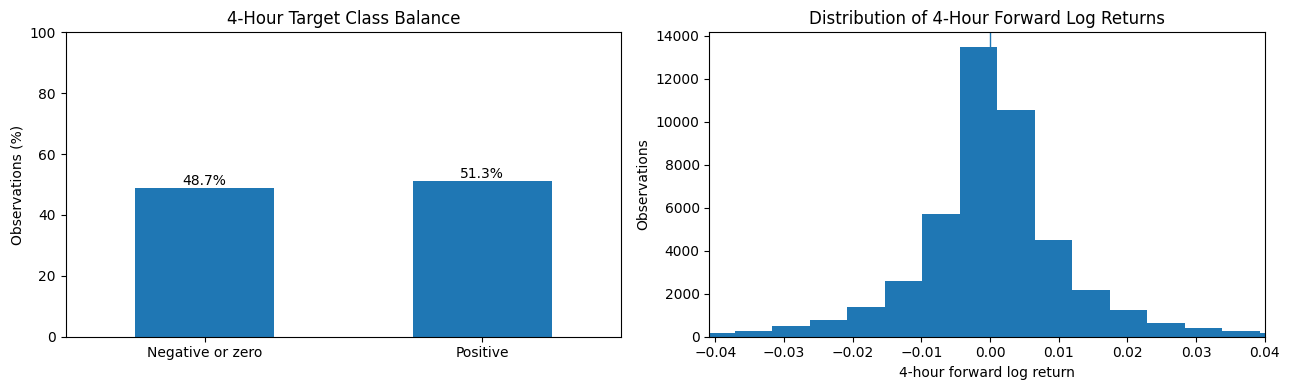

Observations: 45,537
Median return: 0.000199
Positive class: 51.27%


In [94]:
# d) Examine the 4-hour target distribution and class balance

fwd_ret_4h = targets_train["fwd_logret_4h"].reindex(X_train_engineered.index).dropna()
y_sign_4h = (fwd_ret_4h > 0).astype(int)

class_balance = y_sign_4h.value_counts(normalize=True).sort_index().mul(100)
class_balance.index = ["Negative or zero", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_balance.plot(kind="bar", ax=axes[0])
axes[0].set_title("4-Hour Target Class Balance")
axes[0].set_ylabel("Observations (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

for position, value in enumerate(class_balance):
    axes[0].text(position, value + 1, f"{value:.1f}%", ha="center")

axes[1].hist(fwd_ret_4h, bins=100)
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Distribution of 4-Hour Forward Log Returns")
axes[1].set_xlabel("4-hour forward log return")
axes[1].set_ylabel("Observations")
axes[1].set_xlim(fwd_ret_4h.quantile(0.01), fwd_ret_4h.quantile(0.99))

plt.tight_layout()
plt.show()

print(f"Observations: {len(fwd_ret_4h):,}")
print(f"Median return: {fwd_ret_4h.median():.6f}")
print(f"Positive class: {y_sign_4h.mean() * 100:.2f}%")

The 4-hour target is relatively balanced, suggesting that class imbalance is unlikely to be a major issue during model training. However, the return distribution contains a substantial concentration of observations close to zero, which may represent noise or economically negligible price movements.

The next step therefore examines whether a symmetric dead zone should be applied so that near-zero returns do not blur the distinction between meaningful positive and negative outcomes.

In [95]:
# Compare symmetric dead-zone thresholds for the selected 4-hour target
thresholds = [0.0000, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0030, 0.0040, 0.0050]
threshold_rows = []

for threshold in thresholds:
    keep = fwd_ret_4h.abs() > threshold
    y_threshold = (fwd_ret_4h[keep] > 0).astype(int)

    threshold_rows.append({
        "threshold_pct": threshold * 100,
        "rows_removed": (~keep).sum(),
        "rows_removed_pct": (~keep).mean() * 100,
        "rows_remaining": keep.sum(),
        "negative_count": (y_threshold == 0).sum(),
        "positive_count": (y_threshold == 1).sum(),
        "positive_pct": y_threshold.mean() * 100})

threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary.style.format({
    "threshold_pct": "{:.2f}%",
    "rows_removed_pct": "{:.2f}%",
    "positive_pct": "{:.2f}%"}))

,threshold_pct,rows_removed,rows_removed_pct,rows_remaining,negative_count,positive_count,positive_pct
0,0.00%,9,0.02%,45528,22181,23347,51.28%
1,0.05%,2899,6.37%,42638,20710,21928,51.43%
2,0.10%,5812,12.76%,39725,19262,20463,51.51%
3,0.15%,8601,18.89%,36936,17869,19067,51.62%
4,0.20%,11157,24.50%,34380,16614,17766,51.68%
5,0.25%,13487,29.62%,32050,15470,16580,51.73%
6,0.30%,15688,34.45%,29849,14382,15467,51.82%
7,0.40%,19667,43.19%,25870,12456,13414,51.85%
8,0.50%,22893,50.27%,22644,10913,11731,51.81%


A symmetric dead zone of ±0.05% is selected to remove the most ambiguous near-zero returns without materially reducing the sample available for model training and cross-validation. It excludes 6.37% of observations, retains 42,638 samples and preserves a balanced target with 51.43% positive observations.

### **e) Final Target Definition**

Let $F_t$ denote the hourly closing price of the Binance USD-margined BTCUSDT perpetual-futures contract. The selected target is the 4-hour forward log return:

$$
r_{t,t+4}^{\mathrm{perp}}
=
\log\left(\frac{F_{t+4}}{F_t}\right).
$$

A symmetric dead zone of $\tau=0.0005$, equivalent to $\pm0.05\%$, is applied. The binary target is:

$$
y_t=
\begin{cases}
1, & r_{t,t+4}^{\mathrm{perp}}>0.0005,\\
0, & r_{t,t+4}^{\mathrm{perp}}<-0.0005.
\end{cases}
$$

Observations satisfying

$$
\left|r_{t,t+4}^{\mathrm{perp}}\right|\leq0.0005
$$

are excluded.

The dead zone removes 2,899 observations, or 6.37%, while retaining 42,638 observations and a balanced target with 51.43% positive outcomes. The continuous `fwd_logret_4h` series is retained, while the binary label is created during model preparation.

In [96]:
# Save 4-hour target files for modelling
for split in ["train", "test"]:
    source_path = DATA_PATH / f"targets_{split}_1h.csv"
    output_path = DATA_PATH / f"targets_{split}_4h.csv"

    target_df = pd.read_csv(source_path)
    target_df[["timestamp", "fwd_logret_4h"]].to_csv(output_path, index=False)

    print(f"Saved: {output_path.name} | {target_df.shape[0]:,} rows")

Saved: targets_train_4h.csv | 45,537 rows
Saved: targets_test_4h.csv | 11,391 rows


## **(VI) Feature Selection**

Feature selection reduces the engineered predictor set to a smaller group of informative and non-redundant variables using training data only. Highly correlated or mechanically duplicated features are removed first, followed by a multicollinearity review using VIF.

Boruta then identifies features with useful nonlinear information, while SHAP and Elastic Net provide alternative importance and stability rankings. Candidate subsets are compared under the same chronological validation framework, and the strongest compact feature set is retained for model training.

In [97]:
# Load engineered training data

X_train_engineered = pd.read_csv(
    DATA_PATH / "X_train_engineered_1h.csv",
    index_col="timestamp",
    parse_dates=["timestamp"]).sort_index()

X_train_engineered.index = pd.to_datetime(X_train_engineered.index, utc=True)

print(f"Engineered training matrix: {X_train_engineered.shape}")
print(f"Period: {X_train_engineered.index.min()} to {X_train_engineered.index.max()}")

Engineered training matrix: (40497, 95)
Period: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


## **i) Simple feature to feature Pearson Correlation Heatmap**

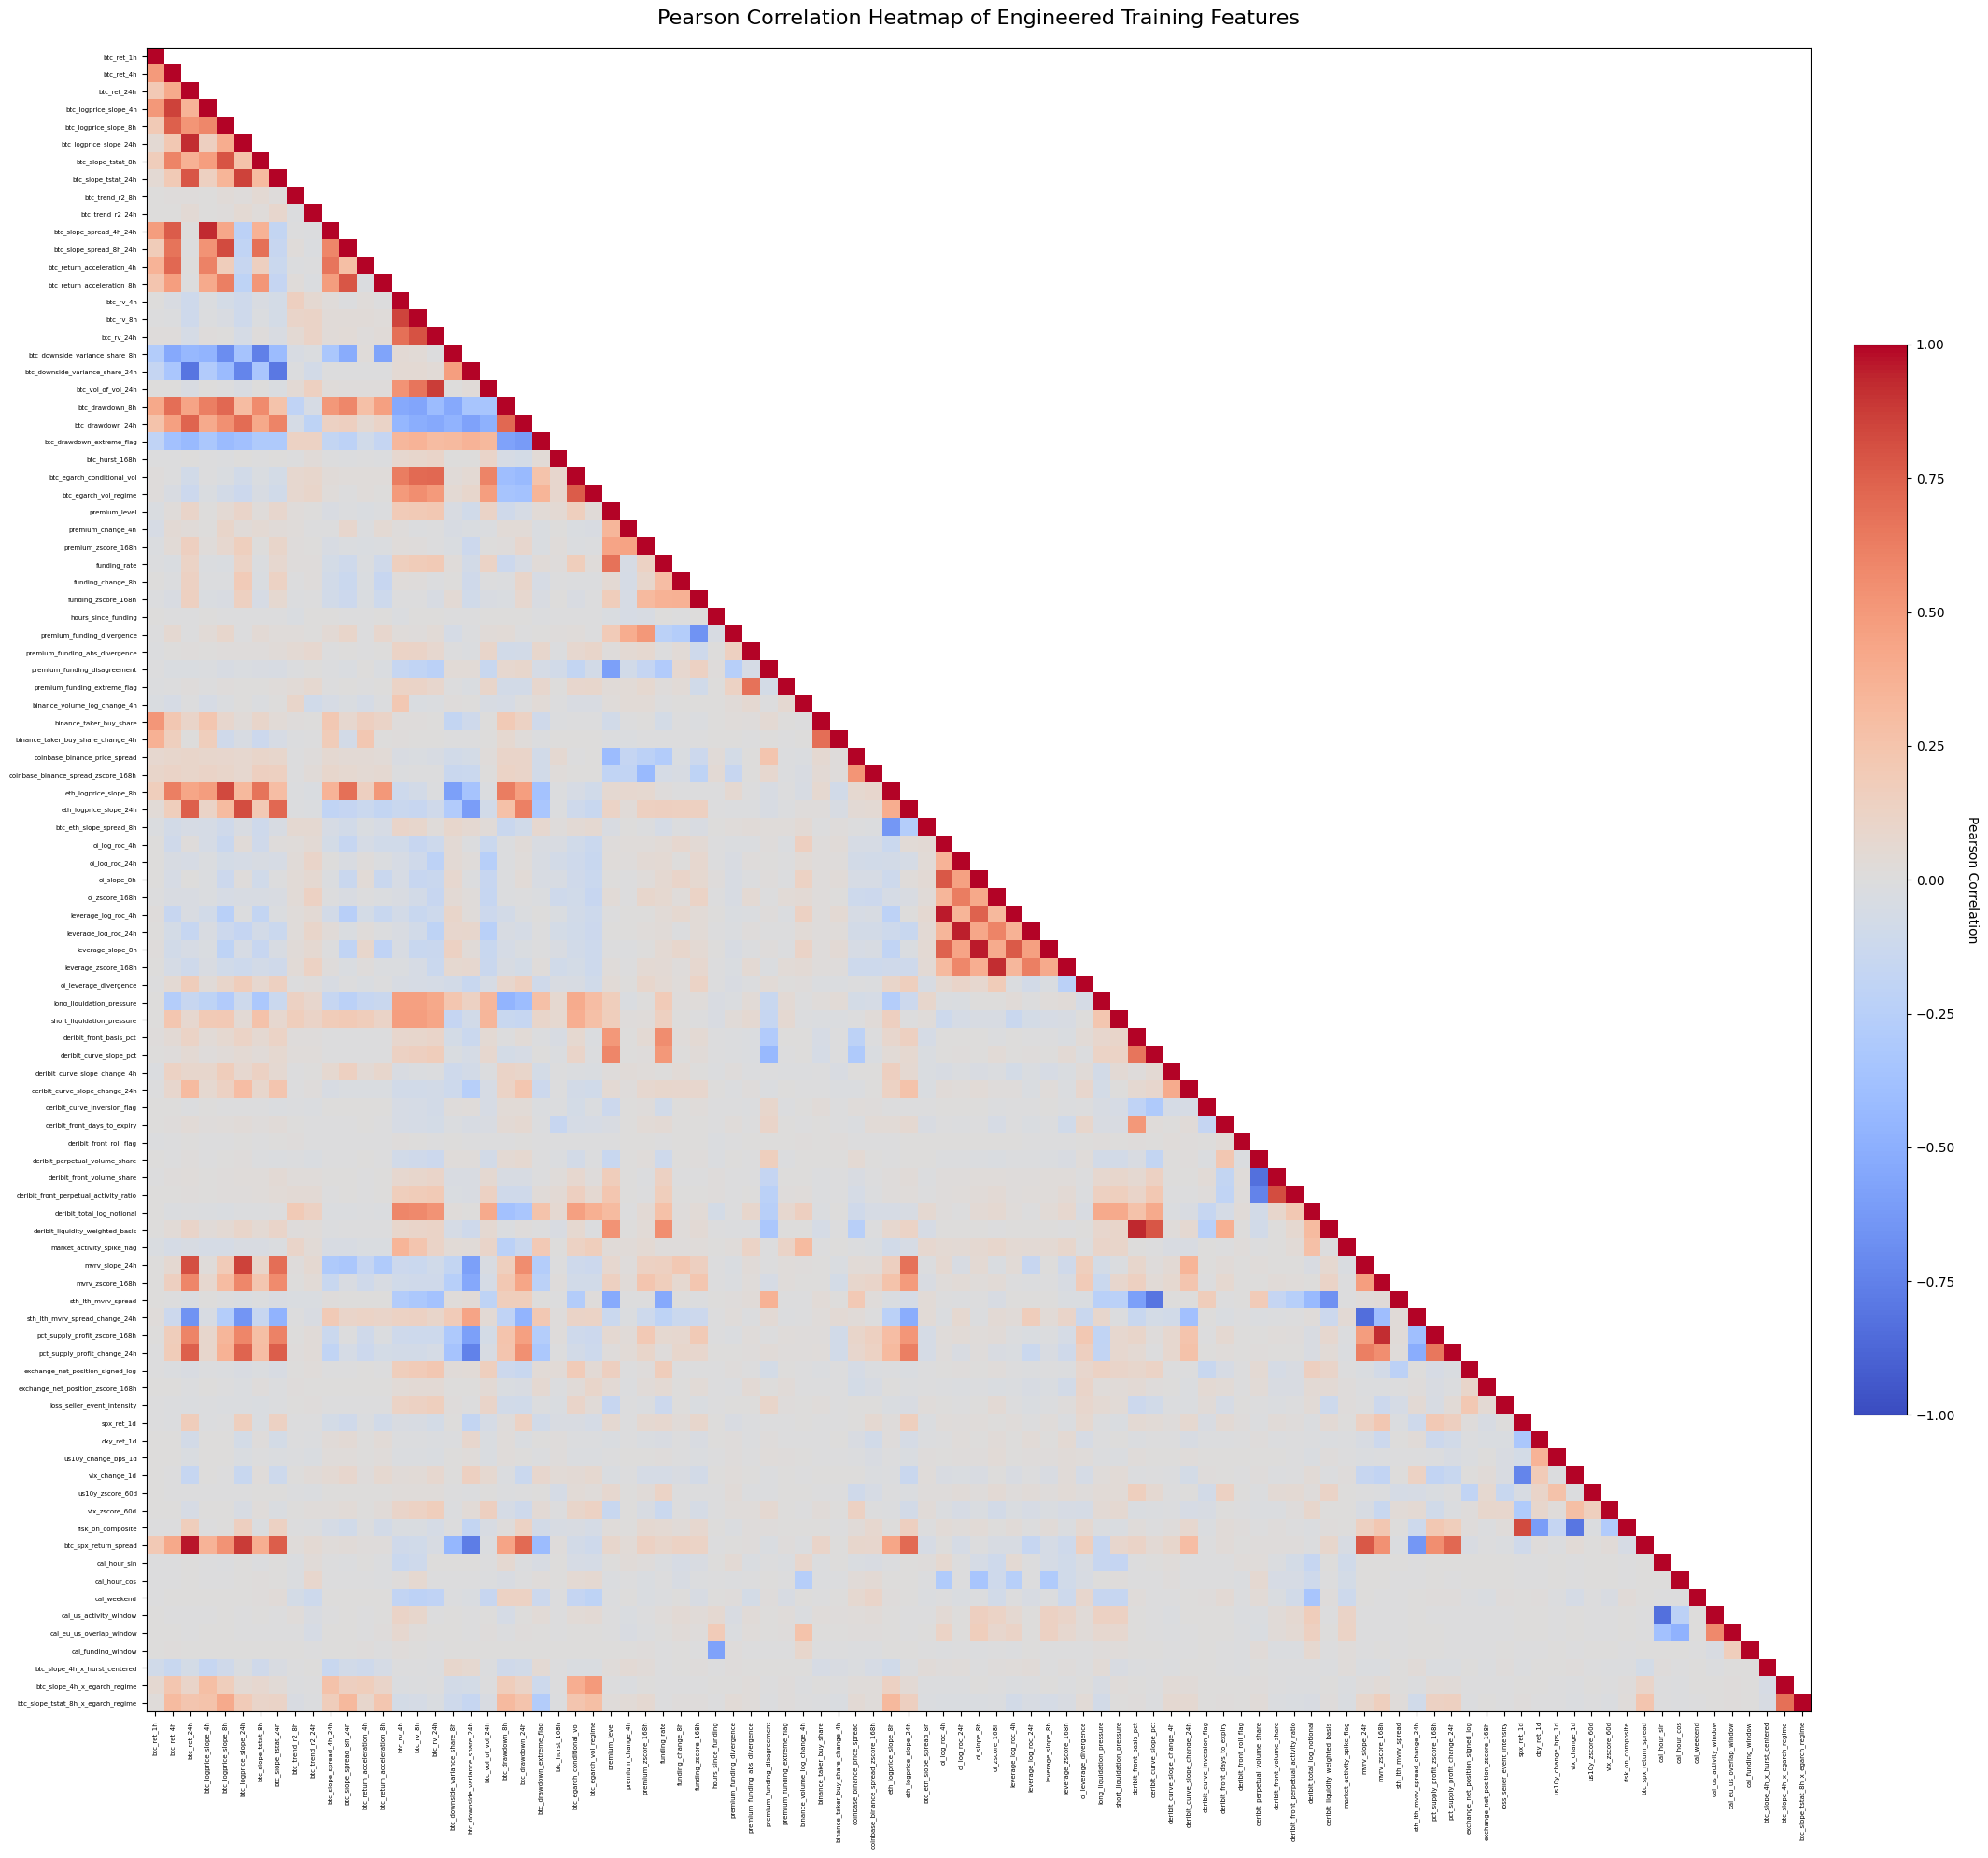

In [98]:
# Plot the complete feature-to-feature Pearson correlation heatmap
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
feature_corr_plot = np.ma.masked_where(upper_mask, feature_corr.to_numpy())

fig, ax = plt.subplots(figsize=(24, 20))
heatmap = ax.imshow(feature_corr_plot, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.index)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=5)
ax.set_yticklabels(feature_corr.index, fontsize=5)
ax.set_title("Pearson Correlation Heatmap of Engineered Training Features", fontsize=16, pad=18)

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

The heatmap shows that strong correlations are concentrated within related feature groups, particularly BTC trend, volatility, on-chain and term-structure measures. Most cross-family relationships remain weak to moderate, indicating that the feature set retains substantial complementary information.

### **Correlation Review and Structural Pruning**

The correlation matrix is used to identify strongly related feature pairs. Features are not removed mechanically from every highly correlated pair; pruning is limited to variables that are structurally redundant or largely replicate information already retained elsewhere.

In [100]:
# a) Correlation Review and Structural Pruning
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

high_corr_pairs = feature_corr.where(upper_mask).stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.90]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

correlation_drop_features = [
    "btc_spx_return_spread",
    "btc_slope_spread_4h_24h",
    "deribit_front_basis_pct"]

X_train_corr_trimmed = X_train_engineered.drop(columns=correlation_drop_features)

remaining_corr = X_train_corr_trimmed.corr(method="pearson")
upper_mask = np.triu(np.ones(remaining_corr.shape, dtype=bool), k=1)

remaining_pairs = remaining_corr.where(upper_mask).stack().reset_index()
remaining_pairs.columns = ["feature_1", "feature_2", "correlation"]
remaining_pairs["abs_correlation"] = remaining_pairs["correlation"].abs()
remaining_pairs = remaining_pairs[remaining_pairs["abs_correlation"] >= 0.90]
remaining_pairs = remaining_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print(f"Original features: {X_train_engineered.shape[1]}")
print(f"Highly correlated pairs before pruning: {len(high_corr_pairs)}")
print(f"Features removed: {correlation_drop_features}")
print(f"Remaining features: {X_train_corr_trimmed.shape[1]}")
print(f"Highly correlated pairs after pruning: {len(remaining_pairs)}")

display(high_corr_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))
print()
display(remaining_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Original features: 95
Highly correlated pairs before pruning: 9
Features removed: ['btc_spx_return_spread', 'btc_slope_spread_4h_24h', 'deribit_front_basis_pct']
Remaining features: 92
Highly correlated pairs after pruning: 6


,feature_1,feature_2,correlation,abs_correlation
0,btc_ret_24h,btc_spx_return_spread,0.9640,0.9640
1,oi_slope_8h,leverage_slope_8h,0.9587,0.9587
2,oi_log_roc_4h,leverage_log_roc_4h,0.9570,0.9570
3,oi_log_roc_24h,leverage_log_roc_24h,0.9475,0.9475
4,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9310,0.9310
5,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9287,0.9287
6,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
7,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148
8,oi_zscore_168h,leverage_zscore_168h,0.9146,0.9146


,feature_1,feature_2,correlation,abs_correlation
0,oi_slope_8h,leverage_slope_8h,0.9587,0.9587
1,oi_log_roc_4h,leverage_log_roc_4h,0.9570,0.9570
2,oi_log_roc_24h,leverage_log_roc_24h,0.9475,0.9475
3,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
4,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148
5,oi_zscore_168h,leverage_zscore_168h,0.9146,0.9146


Three constructed features are removed because they largely duplicate information retained in their underlying components or broader alternatives. The remaining correlated pairs are preserved for later VIF and model-based feature selection rather than removed solely on pairwise correlation.

## **ii) Variance Inflation Factor (VIF) Review**

VIF is used here to check whether a feature is largely explained by the another predictor. A threshold of 30 is used only to flag severe multicollinearity for review. Features are not removed automatically at this stage, as the later feature-selection methods will determine which variables to retain.

In [101]:
# ii) Review multicollinearity using VIF
corr_matrix = X_train_corr_trimmed.corr().to_numpy()
inverse_corr = np.linalg.pinv(corr_matrix)

vif_results = pd.DataFrame({
    "feature": X_train_corr_trimmed.columns,
    "VIF": np.diag(inverse_corr)}).sort_values("VIF", ascending=False).reset_index(drop=True)

high_vif_features = vif_results[vif_results["VIF"] > 30]

print(f"Features assessed: {len(vif_results)}")
print(f"Features with VIF > 30: {len(high_vif_features)}")
display(high_vif_features.style.format({"VIF": "{:.2f}"}))

Features assessed: 92
Features with VIF > 30: 6


,feature,VIF
0,btc_ret_4h,67.35
1,leverage_slope_8h,41.11
2,oi_slope_8h,40.69
3,leverage_log_roc_4h,34.64
4,oi_log_roc_4h,33.82
5,btc_return_acceleration_4h,30.17


Only btc_ret_4h exceeds the VIF threshold of 30. It is retained as an interpretable momentum measure, with final selection left to the subsequent feature-selection methods.

## **iIi) Boruta**

In [ ]:
# Run Boruta using the locked ±0.05% dead zone
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import time

RETURN_THRESHOLD = 0.0005
BORUTA_MATRIX_PATH = DATA_PATH / "X_train_boruta_inclusive_4h.csv"
BORUTA_TARGET_PATH = DATA_PATH / "y_train_boruta_4h.csv"

targets_train = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
targets_train.index = pd.to_datetime(targets_train.index, utc=True)
targets_train = targets_train.sort_index()

common_index = X_train_corr_trimmed.index.intersection(targets_train.index)
X_boruta = X_train_corr_trimmed.loc[common_index].copy()
fwd_ret_4h = targets_train.loc[common_index, "fwd_logret_4h"].copy()

keep_mask = fwd_ret_4h.abs() > RETURN_THRESHOLD
X_boruta = X_boruta.loc[keep_mask].copy()
y_boruta = (fwd_ret_4h.loc[keep_mask] > 0).astype(int).rename("target_4h")

assert X_boruta.index.equals(y_boruta.index), "Feature and target timestamps are not aligned."
assert X_boruta.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(X_boruta.to_numpy()).all(), "Infinite values detected."
assert y_boruta.nunique() == 2, "Target must contain both classes."

print("Boruta observations:", len(X_boruta))
print("Boruta features:", X_boruta.shape[1])
print("Positive-class proportion:", f"{y_boruta.mean() * 100:.2f}%")

rf = RandomForestClassifier(max_depth=5, min_samples_leaf=20, max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", max_iter=100, perc=100, alpha=0.05, two_step=True, random_state=42, verbose=2)

start_time = time.time()
boruta.fit(X_boruta.to_numpy(), y_boruta.to_numpy())
runtime_minutes = (time.time() - start_time) / 60

boruta_results = pd.DataFrame({
    "feature": X_boruta.columns,
    "confirmed": boruta.support_,
    "tentative": boruta.support_weak_,
    "ranking": boruta.ranking_
})

boruta_results = boruta_results.sort_values(["confirmed", "tentative", "ranking"], ascending=[False, False, True]).reset_index(drop=True)

confirmed_features = boruta_results.loc[boruta_results["confirmed"], "feature"].tolist()
tentative_features = boruta_results.loc[boruta_results["tentative"], "feature"].tolist()
rejected_features = boruta_results.loc[~boruta_results["confirmed"] & ~boruta_results["tentative"], "feature"].tolist()

inclusive_features = confirmed_features + tentative_features
X_train_boruta_inclusive = X_boruta[inclusive_features].copy()

X_train_boruta_inclusive.to_csv(BORUTA_MATRIX_PATH, index=True, index_label="timestamp")
y_boruta.to_frame().to_csv(BORUTA_TARGET_PATH, index=True, index_label="timestamp")

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Confirmed features:", len(confirmed_features))
print("Tentative features:", len(tentative_features))
print("Rejected features:", len(rejected_features))
print("Inclusive matrix shape:", X_train_boruta_inclusive.shape)

display(boruta_results)

Boruta observations: 37921
Boruta features: 92
Positive-class proportion: 51.28%
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	92
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	49
Tentative: 	24
Rejected: 	19
Iteration: 	9 / 100
Confirmed: 	49
Tentative: 	24
Rejected: 	19
Iteration: 	10 / 100
Confirmed: 	49
Tentative: 	24
Rejected: 	19
Iteration: 	11 / 100
Confirmed: 	49
Tentative: 	24
Rejected: 	19
Iteration: 	12 / 100
Confirmed: 	60
Tentative: 	13
Rejected: 	19
Iteration: 	13 / 100
Confirmed: 	60
Tentative: 	13
Rejected: 	19
Iteration: 	14 / 100
Confirmed: 	60
Tentative: 	11
Rejected: 	21
Iteration: 	15 / 100
Confirmed: 

,feature,confirmed,tentative,ranking
0,btc_ret_1h,True,False,1
1,btc_ret_4h,True,False,1
2,btc_ret_24h,True,False,1
3,btc_logprice_slope_4h,True,False,1
4,btc_logprice_slope_8h,True,False,1
...,...,...,...,...
87,cal_eu_us_overlap_window,False,False,22
88,premium_funding_extreme_flag,False,False,23
89,cal_funding_window,False,False,24
90,deribit_curve_inversion_flag,False,False,25


In [ ]:
# Train an internal XGBoost model for SHAP analysis
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

X_shap_all = X_train_boruta_inclusive.copy()
y_shap_all = y_boruta.loc[X_shap_all.index].copy()

split_index = int(len(X_shap_all) * 0.80)
purge_hours = 4

X_shap_train = X_shap_all.iloc[:split_index - purge_hours].copy()
X_shap_valid = X_shap_all.iloc[split_index:].copy()
y_shap_train = y_shap_all.iloc[:split_index - purge_hours].copy()
y_shap_valid = y_shap_all.iloc[split_index:].copy()

print("SHAP input features:", X_shap_all.shape[1])
print("Training shape:", X_shap_train.shape)
print("Validation shape:", X_shap_valid.shape)
print("Training range:", X_shap_train.index.min(), "to", X_shap_train.index.max())
print("Validation range:", X_shap_valid.index.min(), "to", X_shap_valid.index.max())

shap_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    tree_method="hist",
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
shap_model.fit(X_shap_train, y_shap_train, eval_set=[(X_shap_valid, y_shap_valid)], verbose=False)
runtime_minutes = (time.time() - start_time) / 60

valid_probability = shap_model.predict_proba(X_shap_valid)[:, 1]
valid_prediction = (valid_probability >= 0.50).astype(int)

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Best boosting round:", shap_model.best_iteration)
print("Validation accuracy:", f"{accuracy_score(y_shap_valid, valid_prediction):.4f}")
print("Validation balanced accuracy:", f"{balanced_accuracy_score(y_shap_valid, valid_prediction):.4f}")
print("Validation ROC-AUC:", f"{roc_auc_score(y_shap_valid, valid_probability):.4f}")

X_shap_sample = X_shap_valid.sample(n=min(5000, len(X_shap_valid)), random_state=42).sort_index()

print("Rows selected for SHAP:", len(X_shap_sample))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_shap_valid, valid_prediction), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

display(classification_report(y_shap_valid, valid_prediction, digits=4))

SHAP input features: 68
Training shape: (30332, 68)
Validation shape: (7585, 68)
Training range: 2020-07-29 00:00:00+00:00 to 2024-04-08 12:00:00+00:00
Validation range: 2024-04-08 21:00:00+00:00 to 2025-03-12 08:00:00+00:00
Runtime in minutes: 0.01
Best boosting round: 60
Validation accuracy: 0.5341
Validation balanced accuracy: 0.5320
Validation ROC-AUC: 0.5523
Rows selected for SHAP: 5000
Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,1681,2010
Actual 1,1524,2370


'              precision    recall  f1-score   support\n\n           0     0.5245    0.4554    0.4875      3691\n           1     0.5411    0.6086    0.5729      3894\n\n    accuracy                         0.5341      7585\n   macro avg     0.5328    0.5320    0.5302      7585\nweighted avg     0.5330    0.5341    0.5313      7585\n'

## **iv) SHAP Analysis and Ranking on Boruta Surviving Features**

In [ ]:
# Calculate SHAP values and rank the Boruta-surviving features
import shap

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_values = np.asarray(shap_values)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_ranking = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_ranking["rank"] = np.arange(1, len(shap_ranking) + 1)
shap_ranking["shap_share"] = shap_ranking["mean_abs_shap"] / shap_ranking["mean_abs_shap"].sum()
shap_ranking["cumulative_shap_share"] = shap_ranking["shap_share"].cumsum()

features_to_80pct = (shap_ranking["cumulative_shap_share"] < 0.80).sum() + 1
features_to_90pct = (shap_ranking["cumulative_shap_share"] < 0.90).sum() + 1

SHAP_RANKING_PATH = DATA_PATH / "shap_feature_ranking_4h.csv"
shap_ranking.to_csv(SHAP_RANKING_PATH, index=False)

print("SHAP input features:", len(shap_ranking))
print("Features required for 80% cumulative SHAP:", features_to_80pct)
print("Features required for 90% cumulative SHAP:", features_to_90pct)
print("Top 20 SHAP share:", f"{shap_ranking.head(20)['shap_share'].sum() * 100:.2f}%")
print("Top 30 SHAP share:", f"{shap_ranking.head(30)['shap_share'].sum() * 100:.2f}%")
print("Saved SHAP ranking to:", SHAP_RANKING_PATH)

display(shap_ranking.head(40).style.format({
    "mean_abs_shap": "{:.6f}",
    "shap_share": "{:.2%}",
    "cumulative_shap_share": "{:.2%}"
}))

SHAP input features: 68
Features required for 80% cumulative SHAP: 26
Features required for 90% cumulative SHAP: 37
Top 20 SHAP share: 74.39%
Top 30 SHAP share: 84.42%
Saved SHAP ranking to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/shap_feature_ranking_4h.csv


,feature,mean_abs_shap,rank,shap_share,cumulative_shap_share
0,btc_ret_4h,0.060813,1,12.31%,12.31%
1,btc_logprice_slope_4h,0.045633,2,9.24%,21.55%
2,btc_slope_tstat_8h,0.028783,3,5.83%,27.38%
3,btc_drawdown_8h,0.026426,4,5.35%,32.73%
4,coinbase_binance_spread_zscore_168h,0.025253,5,5.11%,37.84%
5,btc_drawdown_24h,0.023393,6,4.74%,42.58%
6,btc_ret_24h,0.023160,7,4.69%,47.27%
7,btc_downside_variance_share_24h,0.019966,8,4.04%,51.31%
8,cal_hour_cos,0.014825,9,3.00%,54.31%
9,eth_logprice_slope_8h,0.013947,10,2.82%,57.13%


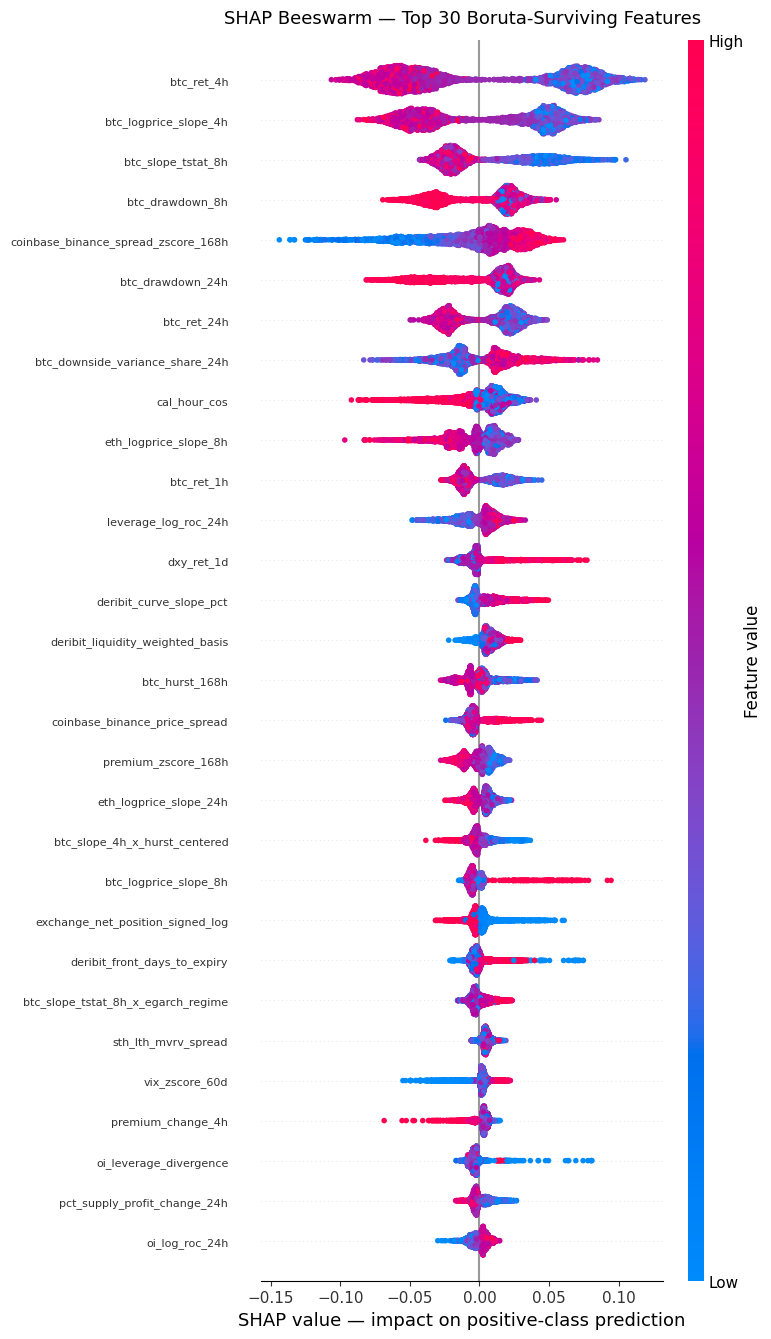

In [ ]:
# Plot the SHAP beeswarm summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="dot", max_display=30, show=False)

plt.title("SHAP Beeswarm — Top 30 Boruta-Surviving Features", fontsize=13, pad=12)
plt.xlabel("SHAP value — impact on positive-class prediction")
plt.gca().tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

The SHAP results show that predictive importance is concentrated in a manageable core of features while remaining diversified across price, risk, derivatives, cross-asset and on-chain information. Short-term BTC momentum remains dominant, but the model is not solely dependent on mechanically related price transformations.

## **v) Bourta Survived Features Tournament for Final Selection**

Boruta retained 68 features, but carrying all of them into modelling may still introduce unnecessary noise, unstable importance and greater overfitting risk. A feature-set tournament is therefore used to compare several defensible subsets under the same chronological validation framework and determine whether a more compact set performs as well as, or better than, the full Boruta set. Elastic Net is included because it combines L1 feature sparsity with L2 stability, making it well suited to selecting among correlated predictors while providing a linear alternative to the tree-based Boruta and SHAP rankings.

In [ ]:
# Rank features using Elastic Net stability across chronological folds
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

TARGET_FEATURES = 30
CS = [0.01, 0.05, 0.20, 1.00]
L1_RATIOS = [0.25, 0.50, 0.75]
MAX_ITER = 3000
ZERO_TOL = 1e-6

tuning_cv = TimeSeriesSplit(n_splits=3, gap=4)

elastic_net_cv = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=CS,
        cv=tuning_cv,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=L1_RATIOS,
        scoring="roc_auc",
        max_iter=MAX_ITER,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    ))

start_time = time.time()
elastic_net_cv.fit(X_shap_train, y_shap_train)
runtime_minutes = (time.time() - start_time) / 60

cv_model = elastic_net_cv.named_steps["logisticregressioncv"]
best_c = float(cv_model.C_[0])
best_l1_ratio = float(cv_model.l1_ratio_[0])

fold_coefficients = []

for fold, (train_idx, _) in enumerate(TimeSeriesSplit(n_splits=5, gap=4).split(X_shap_train), start=1):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_c,
            l1_ratio=best_l1_ratio,
            max_iter=MAX_ITER,
            tol=1e-3,
            random_state=42))

    model.fit(X_shap_train.iloc[train_idx], y_shap_train.iloc[train_idx])
    coefficients = model.named_steps["logisticregression"].coef_.ravel()
    fold_coefficients.append(pd.Series(coefficients, index=X_shap_train.columns, name=f"fold_{fold}"))

fold_coefficients = pd.concat(fold_coefficients, axis=1)
nonzero = fold_coefficients.abs() > ZERO_TOL

selection_frequency = nonzero.mean(axis=1)
median_abs_coefficient = fold_coefficients.abs().median(axis=1)

def sign_consistency(row):
    row = row[row.abs() > ZERO_TOL]
    return 0 if row.empty else max((row > 0).mean(), (row < 0).mean())

elastic_net_ranking = pd.DataFrame({
    "feature": X_shap_train.columns,
    "selection_frequency": selection_frequency,
    "sign_consistency": fold_coefficients.apply(sign_consistency, axis=1),
    "median_abs_coefficient": median_abs_coefficient
})

elastic_net_ranking = elastic_net_ranking.sort_values(
    ["selection_frequency", "sign_consistency", "median_abs_coefficient"],
    ascending=False
).reset_index(drop=True)

elastic_net_ranking["rank"] = np.arange(1, len(elastic_net_ranking) + 1)
elastic_net_features = elastic_net_ranking.head(TARGET_FEATURES)["feature"].tolist()

ELASTIC_NET_RANKING_PATH = DATA_PATH / "elastic_net_stability_ranking_4h.csv"
ELASTIC_NET_FEATURES_PATH = DATA_PATH / "elastic_net_selected_features_30_4h.csv"

elastic_net_ranking.to_csv(ELASTIC_NET_RANKING_PATH, index=False)
pd.DataFrame({"feature": elastic_net_features}).to_csv(ELASTIC_NET_FEATURES_PATH, index=False)

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Best C:", best_c)
print("Best L1 ratio:", best_l1_ratio)
print("Selected features:", len(elastic_net_features))

display(elastic_net_ranking.head(40).style.format({
    "selection_frequency": "{:.2f}",
    "sign_consistency": "{:.2f}",
    "median_abs_coefficient": "{:.6f}"}))

Runtime in minutes: 0.79
Best C: 0.05
Best L1 ratio: 0.75
Selected features: 30


,feature,selection_frequency,sign_consistency,median_abs_coefficient,rank
0,btc_logprice_slope_24h,1.00,1.00,0.343006,1
1,btc_slope_tstat_8h,1.00,1.00,0.223445,2
2,btc_logprice_slope_8h,1.00,1.00,0.183220,3
3,btc_ret_24h,1.00,1.00,0.148363,4
4,eth_logprice_slope_24h,1.00,1.00,0.090909,5
5,mvrv_zscore_168h,1.00,1.00,0.085143,6
6,oi_log_roc_24h,1.00,1.00,0.073464,7
7,cal_hour_cos,1.00,1.00,0.051283,8
8,btc_vol_of_vol_24h,1.00,1.00,0.050912,9
9,btc_return_acceleration_4h,1.00,1.00,0.048955,10


Elastic Net identified a stable 30-feature candidate set dominated by recent BTC trend, momentum and risk conditions, with complementary information from leverage, open interest, ETH, macro markets, derivatives and on-chain activity. This composition is consistent with the short four-hour forecast horizon, while still retaining broader market-state variables that may improve robustness beyond price-only signals.

In [ ]:
# Compare six candidate feature sets with the same chronological L2 logistic tournament
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_sets = {
    "SHAP top 20": shap_ranking.head(20)["feature"].tolist(),
    "SHAP 80%": shap_ranking.head(features_to_80pct)["feature"].tolist(),
    "Elastic Net top 30": elastic_net_features,
    "SHAP 90%": shap_ranking.head(features_to_90pct)["feature"].tolist(),
    "Boruta confirmed": confirmed_features,
    "Boruta inclusive": X_train_boruta_inclusive.columns.tolist()}

tournament_results = []
cv = TimeSeriesSplit(n_splits=5)

for set_name, features in feature_sets.items():
    fold_scores = []

    for train_idx, valid_idx in cv.split(X_boruta):
        valid_start = X_boruta.index[valid_idx[0]]
        train_idx = train_idx[X_boruta.index[train_idx] < valid_start - pd.Timedelta(hours=4)]

        X_train_fold = X_boruta.iloc[train_idx][features]
        X_valid_fold = X_boruta.iloc[valid_idx][features]
        y_train_fold = y_boruta.iloc[train_idx]
        y_valid_fold = y_boruta.iloc[valid_idx]

        model = make_pipeline(StandardScaler(), LogisticRegression(penalty="l2", C=1.0, max_iter=2000, random_state=42))
        model.fit(X_train_fold, y_train_fold)

        probability = model.predict_proba(X_valid_fold)[:, 1]
        prediction = (probability >= 0.50).astype(int)

        fold_scores.append({
            "roc_auc": roc_auc_score(y_valid_fold, probability),
            "balanced_accuracy": balanced_accuracy_score(y_valid_fold, prediction)})

    fold_scores = pd.DataFrame(fold_scores)

    tournament_results.append({
        "feature_set": set_name,
        "features": len(features),
        "mean_roc_auc": fold_scores["roc_auc"].mean(),
        "std_roc_auc": fold_scores["roc_auc"].std(),
        "mean_balanced_accuracy": fold_scores["balanced_accuracy"].mean(),
        "std_balanced_accuracy": fold_scores["balanced_accuracy"].std()})

tournament_results = pd.DataFrame(tournament_results)
tournament_results = tournament_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)

display(tournament_results.style.format({
    "mean_roc_auc": "{:.4f}",
    "std_roc_auc": "{:.4f}",
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}"}))

,feature_set,features,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,Elastic Net top 30,30,0.5583,0.0151,0.5404,0.0109
1,SHAP 80%,26,0.5536,0.0173,0.5371,0.0172
2,Boruta inclusive,68,0.5534,0.0178,0.5372,0.0147
3,Boruta confirmed,67,0.5533,0.0178,0.5367,0.0146
4,SHAP 90%,37,0.5532,0.0173,0.5377,0.0164
5,SHAP top 20,20,0.5501,0.0122,0.5329,0.0133


The feature-set tournament selected the 30-feature Elastic Net stability subset. It achieved the highest mean ROC-AUC and balanced accuracy while using substantially fewer predictors than the Boruta-inclusive alternatives. This indicates that the broader feature set contained useful but partly redundant or noisy information, and that a compact combination of stable trend, momentum, volatility, derivatives, cross-asset and on-chain factors provides a stronger modelling foundation.

## **(VII) Model Training**

### **Part I) Training Model Data Pre-Processing**


**Construct the Locked 30-Feature Training Dataset**

This block converts the final engineered training matrix into the canonical model-ready training files. It selects the locked 30 features, aligns them with the 4-hour forward return, applies the ±0.05% dead zone, creates the binary target, and saves both the classification labels and continuous returns for later model evaluation and backtesting.

In [ ]:
# Construct and save the locked 30-feature modelling dataset
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")
RETURN_THRESHOLD = 0.0005

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_model = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
targets = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])

X_model.index = pd.to_datetime(X_model.index, utc=True)
targets.index = pd.to_datetime(targets.index, utc=True)

X_model = X_model.sort_index()[selected_features]
targets = targets.sort_index()

fwd_return_model = targets["fwd_logret_4h"].reindex(X_model.index)
keep_mask = fwd_return_model.abs() > RETURN_THRESHOLD

X_model = X_model.loc[keep_mask].copy()
fwd_return_model = fwd_return_model.loc[keep_mask].rename("fwd_logret_4h")
y_model = (fwd_return_model > 0).astype(int).rename("target_4h")

X_model.reset_index().to_csv(DATA_PATH / "X_train_model_30_4h.csv", index=False)
y_model.reset_index().to_csv(DATA_PATH / "y_train_model_4h.csv", index=False)
fwd_return_model.reset_index().to_csv(DATA_PATH / "returns_train_model_4h.csv", index=False)

print("Final modelling observations:", f"{len(X_model):,}")
print("Final feature count:", X_model.shape[1])
print("Positive-class proportion:", f"{y_model.mean() * 100:.2f}%")
print("Date range:", X_model.index.min(), "to", X_model.index.max())

Final modelling observations: 37,921
Final feature count: 30
Positive-class proportion: 51.28%
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


### **Part II) Benchmark Model Comparison**

**Selection of Candidate Base-Model Families**

The benchmark comparison evaluates several structurally different classifiers before hyperparameter tuning. The objective is not simply to identify the strongest standalone model, but to determine which model families capture complementary aspects of the prediction problem and therefore provide suitable inputs to a heterogeneous ensemble.

The final dataset contains 30 engineered tabular predictors dominated by BTC trend, momentum and risk measures, with additional information from volatility regimes, leverage, open interest, derivatives, macro markets and on-chain activity. It therefore contains both approximately linear effects and potentially nonlinear interactions, thresholds and regime dependencies.

The candidate models are evaluated under the same chronological cross-validation procedure. Their untuned performance, stability and prediction disagreement will then be used to justify which models proceed to tuning and ensemble construction.


**Candidate Base Models and Preprocessing Design**

The benchmark stage compares structurally different classifiers under the same chronological validation framework. The objective is not only to identify the strongest standalone model, but also to retain model families that capture different forms of signal and may therefore contribute complementary predictions to a heterogeneous ensemble.

The modelling dataset contains 30 engineered predictors covering BTC trend, momentum, volatility, leverage, derivatives, macro-market and on-chain conditions. This supports testing models capable of representing linear effects, nonlinear interactions, threshold behaviour and temporal dependencies.

| Model | Role in the benchmark | Why it is included | Scaling treatment |
|---|---|---|---|
| L2 logistic regression | Linear benchmark | Provides a transparent and strongly regularised reference model for approximately linear relationships | Standard, robust and min-max scaling compared because coefficient estimation is scale-sensitive |
| Random Forest | Nonlinear tree benchmark | Captures nonlinear relationships and feature interactions without requiring a parametric functional form | No scaling required because tree splits are invariant to monotonic rescaling |
| XGBoost | Gradient-boosted tree benchmark | Tests whether sequential boosting improves the extraction of weak nonlinear and threshold-based effects | No scaling required |
| CatBoost | Regularised boosting candidate | Offers strong nonlinear modelling with ordered boosting and additional resistance to overfitting | No scaling required |
| RBF SVM | Nonlinear kernel candidate | Captures smooth nonlinear decision boundaries and may provide predictions distinct from tree and linear models | Standard, robust and min-max scaling compared because distances in feature space depend directly on scale |
| GRU | Sequential deep-learning candidate | Uses the preceding 24-hour feature sequence to capture temporal dependence not represented by static tabular models | Standard, robust and min-max scaling compared because neural-network optimisation is sensitive to input magnitude |

Scaler selection is therefore treated as a model-specific preprocessing decision rather than a universal transformation. Scaling is evaluated only for models whose optimisation or distance calculations depend materially on feature magnitude. Tree-based models are left unscaled because rescaling does not alter the ordering of observations or the candidate split structure.

The benchmark results, fold stability and prediction disagreement are subsequently used to determine which model families proceed to hyperparameter tuning and ensemble construction.

In [ ]:
# check if Colab is running on GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Load the locked model-ready training data
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_model = pd.read_csv(DATA_PATH / "X_train_model_30_4h.csv", index_col="timestamp", parse_dates=["timestamp"])
y_model = pd.read_csv(DATA_PATH / "y_train_model_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).iloc[:, 0]
fwd_return_model = pd.read_csv(DATA_PATH / "returns_train_model_4h.csv", index_col="timestamp", parse_dates=["timestamp"]).iloc[:, 0]

X_model.index = pd.to_datetime(X_model.index, utc=True)
y_model.index = pd.to_datetime(y_model.index, utc=True)
fwd_return_model.index = pd.to_datetime(fwd_return_model.index, utc=True)

X_model = X_model.sort_index()
y_model = y_model.reindex(X_model.index).astype(int).rename("target_4h")
fwd_return_model = fwd_return_model.reindex(X_model.index).rename("fwd_logret_4h")

print("Observations:", f"{len(X_model):,}")
print("Features:", X_model.shape[1])
print("Positive class:", f"{y_model.mean() * 100:.2f}%")
print("Date range:", X_model.index.min(), "to", X_model.index.max())

Observations: 37,921
Features: 30
Positive class: 51.28%
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


**i) L2 Logistics Regression**

In [ ]:
# Compare L2 logistic regression scalers on separate chronological tuning folds
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

N_TUNING_FOLDS = 5
PURGE_GAP = 4
BASELINE_C = 1.0

SCALERS = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "minmax": MinMaxScaler()}

L2_SCALER_PATH = DATA_PATH / "l2_scaler_benchmark_4h.csv"
tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
benchmark_rows = []

for scaler_name, scaler in SCALERS.items():
    print(f"\nRunning scaler: {scaler_name}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        model = Pipeline([
            ("scaler", scaler),
            ("model", LogisticRegression(penalty="l2", C=BASELINE_C, solver="lbfgs", max_iter=2000, random_state=42))
        ])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])
        valid_probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(valid_idx),
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc})

        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

l2_scaler_folds = pd.DataFrame(benchmark_rows)

l2_scaler_results = l2_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std"))

l2_scaler_results = l2_scaler_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

l2_scaler_results.to_csv(L2_SCALER_PATH, index=False)
best_l2_scaler = l2_scaler_results.loc[0, "scaler"]

print("\nL2 Logistic Regression Scaler Benchmark")
display(l2_scaler_results.round(4))
print("Best scaler at C=1.0:", best_l2_scaler)
print("Saved to:", L2_SCALER_PATH)


Running scaler: standard
Fold 1/5 | ROC-AUC=0.5526 | Bal acc=0.5331
Fold 2/5 | ROC-AUC=0.5559 | Bal acc=0.5390
Fold 3/5 | ROC-AUC=0.5580 | Bal acc=0.5406
Fold 4/5 | ROC-AUC=0.5742 | Bal acc=0.5548
Fold 5/5 | ROC-AUC=0.5579 | Bal acc=0.5418

Running scaler: robust
Fold 1/5 | ROC-AUC=0.5526 | Bal acc=0.5331
Fold 2/5 | ROC-AUC=0.5557 | Bal acc=0.5398
Fold 3/5 | ROC-AUC=0.5579 | Bal acc=0.5414
Fold 4/5 | ROC-AUC=0.5739 | Bal acc=0.5546
Fold 5/5 | ROC-AUC=0.5578 | Bal acc=0.5416

Running scaler: minmax
Fold 1/5 | ROC-AUC=0.5473 | Bal acc=0.5275
Fold 2/5 | ROC-AUC=0.5530 | Bal acc=0.5305
Fold 3/5 | ROC-AUC=0.5565 | Bal acc=0.5367
Fold 4/5 | ROC-AUC=0.5721 | Bal acc=0.5535
Fold 5/5 | ROC-AUC=0.5552 | Bal acc=0.5388

L2 Logistic Regression Scaler Benchmark


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,standard,0.5597,0.0084,0.5419,0.0080
1,robust,0.5596,0.0083,0.5421,0.0078
2,minmax,0.5568,0.0092,0.5374,0.0101


Best scaler at C=1.0: standard
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/l2_scaler_benchmark_4h.csv


Standard and robust scaling produced virtually identical validation performance. Standard scaling was retained for consistency with the original L2 specification and because it achieved the strongest balanced accuracy among the tied leading scalers.

**ii) Random Forest**

In [ ]:
# Evaluate the untuned Random Forest benchmark
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

rf_benchmark = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    n_jobs=-1,
    random_state=42)

rf_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    rf_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = rf_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    rf_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)})

rf_results = pd.DataFrame(rf_results)
print("Random Forest Results")
display(rf_results.round(4))

print("Mean ROC-AUC:", f"{rf_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{rf_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{rf_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{rf_results['balanced_accuracy'].std():.4f}")

Random Forest Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5513,0.5332
1,2,12637,6320,0.5354,0.5189
2,3,18957,6320,0.5563,0.5409
3,4,25277,6320,0.5696,0.5452
4,5,31597,6320,0.5339,0.5241


Mean ROC-AUC: 0.5493
ROC-AUC standard deviation: 0.0149
Mean balanced accuracy: 0.5324
Balanced accuracy standard deviation: 0.0110


**iii) XGBoost/ CatBoost**

In [ ]:
# Evaluate the untuned XGBoost benchmark
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

xgb_benchmark = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42)

xgb_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    xgb_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = xgb_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    xgb_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)})

xgb_results = pd.DataFrame(xgb_results)
print("XGBoost Results")
display(xgb_results.round(4))

print("Mean ROC-AUC:", f"{xgb_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{xgb_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{xgb_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{xgb_results['balanced_accuracy'].std():.4f}")

XGBoost Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5504,0.5322
1,2,12637,6320,0.5278,0.5237
2,3,18957,6320,0.5497,0.5329
3,4,25277,6320,0.5510,0.5356
4,5,31597,6320,0.5378,0.5248


Mean ROC-AUC: 0.5433
ROC-AUC standard deviation: 0.0103
Mean balanced accuracy: 0.5298
Balanced accuracy standard deviation: 0.0053


In [ ]:
# Evaluate the untuned CatBoost benchmark
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
PURGE_GAP = 4

cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP)

cat_benchmark = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_model), start=1):
    X_fold_train = X_model.iloc[train_idx]
    X_fold_valid = X_model.iloc[valid_idx]
    y_fold_train = y_model.iloc[train_idx]
    y_fold_valid = y_model.iloc[valid_idx]

    cat_benchmark.fit(X_fold_train, y_fold_train)

    valid_probability = cat_benchmark.predict_proba(X_fold_valid)[:, 1]
    valid_prediction = (valid_probability >= 0.5).astype(int)

    cat_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "roc_auc": roc_auc_score(y_fold_valid, valid_probability),
        "balanced_accuracy": balanced_accuracy_score(y_fold_valid, valid_prediction)
    })

cat_results = pd.DataFrame(cat_results)

print("CatBoost Results")
display(cat_results.round(4))

print("Mean ROC-AUC:", f"{cat_results['roc_auc'].mean():.4f}")
print("ROC-AUC standard deviation:", f"{cat_results['roc_auc'].std():.4f}")
print("Mean balanced accuracy:", f"{cat_results['balanced_accuracy'].mean():.4f}")
print("Balanced accuracy standard deviation:", f"{cat_results['balanced_accuracy'].std():.4f}")

CatBoost Results


,fold,train_rows,validation_rows,roc_auc,balanced_accuracy
0,1,6317,6320,0.5575,0.5437
1,2,12637,6320,0.5290,0.5155
2,3,18957,6320,0.5606,0.5432
3,4,25277,6320,0.5607,0.5508
4,5,31597,6320,0.5393,0.5247


Mean ROC-AUC: 0.5494
ROC-AUC standard deviation: 0.0145
Mean balanced accuracy: 0.5356
Balanced accuracy standard deviation: 0.0148


XGBoost was also evaluated as an alternative gradient-boosting model but achieved a lower untuned mean ROC-AUC of 0.5458, compared with 0.5522 for CatBoost.

Catboost was selected as the gradient-boosting model because it can capture nonlinear relationships, interaction effects and threshold behaviour within the engineered predictors. It was preferred to XGBoost because its ordered boosting framework is designed to reduce prediction shift and overfitting, which is particularly relevant for noisy and non-stationary financial data. This choice was also supported empirically: under the same chronological cross-validation procedure, CatBoost achieved higher mean ROC-AUC and balanced accuracy than XGBoost. Retaining CatBoost therefore provides a stronger representative of the gradient-boosting family without introducing two closely related boosting models into the ensemble.


**iv) RBF SVM**

In [ ]:
# Compare RBF SVM scalers on separate chronological tuning folds
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import SVC

N_TUNING_FOLDS = 5
PURGE_GAP = 4
BASELINE_C = 1.0
BASELINE_GAMMA = "scale"

SCALERS = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "minmax": MinMaxScaler()}

SVM_SCALER_PATH = DATA_PATH / "svm_scaler_benchmark_4h.csv"
tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
benchmark_rows = []

for scaler_name, scaler in SCALERS.items():
    print(f"\nRunning scaler: {scaler_name}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        model = Pipeline([
            ("scaler", scaler),
            ("model", SVC(kernel="rbf", C=BASELINE_C, gamma=BASELINE_GAMMA, probability=False))])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        valid_score = model.decision_function(X_model.iloc[valid_idx])
        valid_prediction = (valid_score >= 0).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_score)
        fold_bal_acc = balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(valid_idx),
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc})

        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

svm_scaler_folds = pd.DataFrame(benchmark_rows)

svm_scaler_results = svm_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std"))

svm_scaler_results = svm_scaler_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

svm_scaler_results.to_csv(SVM_SCALER_PATH, index=False)
best_svm_scaler = svm_scaler_results.loc[0, "scaler"]

print("\nRBF SVM Scaler Benchmark")
display(svm_scaler_results.round(4))
print("Best scaler at C=1.0 and gamma='scale':", best_svm_scaler)
print("Saved to:", SVM_SCALER_PATH)


Running scaler: standard
Fold 1/5 | ROC-AUC=0.5529 | Bal acc=0.5397
Fold 2/5 | ROC-AUC=0.5289 | Bal acc=0.5161
Fold 3/5 | ROC-AUC=0.5597 | Bal acc=0.5417
Fold 4/5 | ROC-AUC=0.5744 | Bal acc=0.5544
Fold 5/5 | ROC-AUC=0.5616 | Bal acc=0.5481

Running scaler: robust
Fold 1/5 | ROC-AUC=0.5565 | Bal acc=0.5373
Fold 2/5 | ROC-AUC=0.5417 | Bal acc=0.5254
Fold 3/5 | ROC-AUC=0.5637 | Bal acc=0.5420
Fold 4/5 | ROC-AUC=0.5769 | Bal acc=0.5564
Fold 5/5 | ROC-AUC=0.5648 | Bal acc=0.5484

Running scaler: minmax
Fold 1/5 | ROC-AUC=0.5378 | Bal acc=0.5202
Fold 2/5 | ROC-AUC=0.5315 | Bal acc=0.5188
Fold 3/5 | ROC-AUC=0.5499 | Bal acc=0.5312
Fold 4/5 | ROC-AUC=0.5853 | Bal acc=0.5621
Fold 5/5 | ROC-AUC=0.5601 | Bal acc=0.5416

RBF SVM Scaler Benchmark


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,robust,0.5608,0.0129,0.5419,0.0117
1,standard,0.5555,0.0168,0.5400,0.0146
2,minmax,0.5529,0.0212,0.5348,0.0178


Best scaler at C=1.0 and gamma='scale': robust
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/svm_scaler_benchmark_4h.csv


Robust scaling produced the strongest RBF SVM validation performance, improving mean ROC-AUC relative to standard scaling while maintaining similar balanced accuracy and fold stability. Min-max scaling was weaker and more variable. RobustScaler was therefore retained for the SVM benchmark and subsequent hyperparameter tuning.

**v) GRU (24 hour lookbark)**

In [ ]:
# Compare GRU scalers using a fixed 24-hour lookback and fixed epochs
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

N_TUNING_FOLDS = 5
PURGE_GAP = 4
LOOKBACK = 24
EPOCHS = 10
BATCH_SIZE = 256

SCALERS = {
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "minmax": MinMaxScaler()}

GRU_SCALER_PATH = DATA_PATH / "gru_scaler_benchmark_4h.csv"

np.random.seed(42)
tf.random.set_seed(42)

print("GPU devices:", tf.config.list_physical_devices("GPU"))

tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
benchmark_rows = []

def build_sequences(X_scaled, endpoints, lookback):
    return np.asarray([X_scaled[i - lookback + 1:i + 1] for i in endpoints], dtype=np.float32)

for scaler_name, scaler in SCALERS.items():
    print(f"\nRunning scaler: {scaler_name}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        scaler.fit(X_model.iloc[train_idx])
        X_scaled = scaler.transform(X_model.iloc[:valid_idx[-1] + 1]).astype("float32")

        train_endpoints = train_idx[train_idx >= LOOKBACK - 1]
        valid_endpoints = valid_idx[valid_idx >= LOOKBACK - 1]

        X_train_seq = build_sequences(X_scaled, train_endpoints, LOOKBACK)
        X_valid_seq = build_sequences(X_scaled, valid_endpoints, LOOKBACK)

        y_train_seq = y_model.iloc[train_endpoints].to_numpy(dtype=np.float32)
        y_valid_seq = y_model.iloc[valid_endpoints].to_numpy(dtype=np.float32)

        model = Sequential([
            Input(shape=(LOOKBACK, X_model.shape[1])),
            GRU(32),
            Dropout(0.20),
            Dense(1, activation="sigmoid")])

        model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy")
        model.fit(X_train_seq, y_train_seq, epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=False, verbose=0)

        valid_probability = model.predict(X_valid_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_valid_seq, valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_valid_seq, valid_prediction)

        benchmark_rows.append({
            "scaler": scaler_name,
            "fold": fold,
            "train_rows": len(X_train_seq),
            "validation_rows": len(X_valid_seq),
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc})

        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

        del model, X_scaled, X_train_seq, X_valid_seq
        gc.collect()

gru_scaler_folds = pd.DataFrame(benchmark_rows)

gru_scaler_results = gru_scaler_folds.groupby("scaler", as_index=False).agg(
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std"))

gru_scaler_results = gru_scaler_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False).reset_index(drop=True)

gru_scaler_results.to_csv(GRU_SCALER_PATH, index=False)
best_gru_scaler = gru_scaler_results.loc[0, "scaler"]

print("\nGRU 24-Hour Lookback Scaler Benchmark")
display(gru_scaler_results.round(4))
print("Best scaler at fixed baseline settings:", best_gru_scaler)
print("Saved to:", GRU_SCALER_PATH)

GPU devices: []

Running scaler: standard
Fold 1/5 | ROC-AUC=0.5493 | Bal acc=0.5254
Fold 2/5 | ROC-AUC=0.5448 | Bal acc=0.5261
Fold 3/5 | ROC-AUC=0.5623 | Bal acc=0.5405
Fold 4/5 | ROC-AUC=0.5753 | Bal acc=0.5494
Fold 5/5 | ROC-AUC=0.5552 | Bal acc=0.5388

Running scaler: robust
Fold 1/5 | ROC-AUC=0.5642 | Bal acc=0.5376
Fold 2/5 | ROC-AUC=0.5415 | Bal acc=0.5244
Fold 3/5 | ROC-AUC=0.5563 | Bal acc=0.5369
Fold 4/5 | ROC-AUC=0.5705 | Bal acc=0.5481
Fold 5/5 | ROC-AUC=0.5586 | Bal acc=0.5381

Running scaler: minmax
Fold 1/5 | ROC-AUC=0.5161 | Bal acc=0.4999
Fold 2/5 | ROC-AUC=0.5364 | Bal acc=0.5178
Fold 3/5 | ROC-AUC=0.5409 | Bal acc=0.5302
Fold 4/5 | ROC-AUC=0.5768 | Bal acc=0.5579
Fold 5/5 | ROC-AUC=0.5293 | Bal acc=0.5214

GRU 24-Hour Lookback Scaler Benchmark


,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,robust,0.5582,0.0108,0.5370,0.0084
1,standard,0.5574,0.0120,0.5360,0.0102
2,minmax,0.5399,0.0226,0.5254,0.0212


Best scaler at fixed baseline settings: robust
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/gru_scaler_benchmark_4h.csv


Standard scaling produced the strongest GRU validation performance, with the highest mean ROC-AUC and balanced accuracy. Robust scaling was slightly weaker, while min-max scaling underperformed more clearly. StandardScaler was therefore retained for the GRU specification and subsequent hyperparameter tuning.

In [ ]:
# Compare and save untuned base-model benchmark results
BENCHMARK_PATH = DATA_PATH / "untuned_base_model_benchmark_4h.csv"

l2_selected = l2_scaler_folds.query("scaler == 'standard'")
svm_selected = svm_scaler_folds.query("scaler == 'robust'")
gru_selected = gru_scaler_folds.query("scaler == 'standard'")

def summarise_model(model, family, scaler, results):
    return {
        "model": model,
        "family": family,
        "scaler": scaler,
        "mean_roc_auc": results["roc_auc"].mean(),
        "std_roc_auc": results["roc_auc"].std(),
        "mean_balanced_accuracy": results["balanced_accuracy"].mean(),
        "std_balanced_accuracy": results["balanced_accuracy"].std()}

benchmark_rows = [
    summarise_model("L2 Logistic Regression", "Linear", "StandardScaler", l2_selected),
    summarise_model("Random Forest", "Bagged Trees", "None", rf_results),
    summarise_model("XGBoost", "Gradient Boosting", "None", xgb_results),
    summarise_model("CatBoost", "Gradient Boosting", "None", cat_results),
    summarise_model("RBF SVM", "Kernel", "RobustScaler", svm_selected),
    summarise_model("GRU 24h", "Sequential Neural Network", "StandardScaler", gru_selected)]

benchmark_comparison = pd.DataFrame(benchmark_rows)
benchmark_comparison = benchmark_comparison.sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
benchmark_comparison.to_csv(BENCHMARK_PATH, index=False)

print("Untuned Base-Model Benchmark Comparison")
display(benchmark_comparison.round(4))
print("Saved to:", BENCHMARK_PATH)

Untuned Base-Model Benchmark Comparison


,model,family,scaler,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,RBF SVM,Kernel,RobustScaler,0.5608,0.0129,0.5419,0.0117
1,L2 Logistic Regression,Linear,StandardScaler,0.5597,0.0084,0.5419,0.0080
2,GRU 24h,Sequential Neural Network,StandardScaler,0.5574,0.0120,0.5360,0.0102
3,CatBoost,Gradient Boosting,None,0.5494,0.0145,0.5356,0.0148
4,Random Forest,Bagged Trees,None,0.5493,0.0149,0.5324,0.0110
5,XGBoost,Gradient Boosting,None,0.5433,0.0103,0.5298,0.0053


Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/untuned_base_model_benchmark_4h.csv


### **Part III: Hyperparameter Tuning of Shortlisted Base Learners**

Hyperparameter tuning and validation design will be conducted on separate chronological fold schemes. The tuning folds are used only to select and lock model settings, while the final OOF folds are subsequently used to generate comparable predictions for model assessment and ensemble construction. This separation reduces selection bias from reporting performance on the same validation folds used to choose the hyperparameters. All folds preserve temporal ordering and apply the four-hour purge gap to limit overlap between training observations and forward-return labels.

**a) Tune all short-listed Base Learners**

In [ ]:
# Tune L2 logistic regression on separate chronological tuning folds
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import time

N_TUNING_FOLDS = 5
PURGE_GAP = 4
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
L2_RESULTS_PATH = DATA_PATH / "l2_tuning_results_4h.csv"

tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
l2_rows = []

print(f"Tuning configurations: {len(C_GRID)}")
print(f"Chronological tuning folds: {len(tuning_splits)}")
print(f"Purge gap: {PURGE_GAP} hours")

for C in tqdm(C_GRID, desc="L2 tuning", unit="configuration"):
    start_time = time.time()
    fold_auc, fold_bal_acc = [], []

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=2000, random_state=42))
        ])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])
        valid_probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc.append(roc_auc_score(y_model.iloc[valid_idx], valid_probability))
        fold_bal_acc.append(balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction))

        print(f"C={C:g} | Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc[-1]:.4f} | Bal acc={fold_bal_acc[-1]:.4f}")

    l2_rows.append({
        "C": C,
        "mean_roc_auc": np.mean(fold_auc),
        "std_roc_auc": np.std(fold_auc, ddof=1),
        "mean_balanced_accuracy": np.mean(fold_bal_acc),
        "std_balanced_accuracy": np.std(fold_bal_acc, ddof=1),
        "runtime_seconds": time.time() - start_time
    })

l2_tuning_results = pd.DataFrame(l2_rows)
l2_tuning_results = l2_tuning_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)
l2_tuning_results.to_csv(L2_RESULTS_PATH, index=False)

best_l2_C = float(l2_tuning_results.loc[0, "C"])

print("\nL2 Logistic Regression Tuning Results")
display(l2_tuning_results.round(4))
print("Selected C:", best_l2_C)
print("Saved to:", L2_RESULTS_PATH)

Tuning configurations: 6
Chronological tuning folds: 5
Purge gap: 4 hours


L2 tuning:   0%|          | 0/6 [00:00<?, ?configuration/s]

C=0.001 | Fold 1/5 | ROC-AUC=0.5494 | Bal acc=0.5190
C=0.001 | Fold 2/5 | ROC-AUC=0.5492 | Bal acc=0.5241
C=0.001 | Fold 3/5 | ROC-AUC=0.5537 | Bal acc=0.5377
C=0.001 | Fold 4/5 | ROC-AUC=0.5714 | Bal acc=0.5564
C=0.001 | Fold 5/5 | ROC-AUC=0.5491 | Bal acc=0.5332
C=0.01 | Fold 1/5 | ROC-AUC=0.5502 | Bal acc=0.5319
C=0.01 | Fold 2/5 | ROC-AUC=0.5527 | Bal acc=0.5319
C=0.01 | Fold 3/5 | ROC-AUC=0.5571 | Bal acc=0.5376
C=0.01 | Fold 4/5 | ROC-AUC=0.5730 | Bal acc=0.5531
C=0.01 | Fold 5/5 | ROC-AUC=0.5557 | Bal acc=0.5371
C=0.1 | Fold 1/5 | ROC-AUC=0.5523 | Bal acc=0.5373
C=0.1 | Fold 2/5 | ROC-AUC=0.5554 | Bal acc=0.5385
C=0.1 | Fold 3/5 | ROC-AUC=0.5578 | Bal acc=0.5421
C=0.1 | Fold 4/5 | ROC-AUC=0.5741 | Bal acc=0.5546
C=0.1 | Fold 5/5 | ROC-AUC=0.5576 | Bal acc=0.5426
C=1 | Fold 1/5 | ROC-AUC=0.5526 | Bal acc=0.5331
C=1 | Fold 2/5 | ROC-AUC=0.5559 | Bal acc=0.5390
C=1 | Fold 3/5 | ROC-AUC=0.5580 | Bal acc=0.5406
C=1 | Fold 4/5 | ROC-AUC=0.5742 | Bal acc=0.5548
C=1 | Fold 5/5 | ROC-AUC

,C,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy,runtime_seconds
0,100.0000,0.5597,0.0084,0.5418,0.0081,2.0037
1,10.0000,0.5597,0.0084,0.5418,0.0081,1.5521
2,1.0000,0.5597,0.0084,0.5419,0.0080,1.3111
3,0.1000,0.5594,0.0085,0.5430,0.0069,1.7581
4,0.0100,0.5577,0.0090,0.5383,0.0087,1.3989
5,0.0010,0.5546,0.0096,0.5341,0.0145,0.8641


Selected C: 100.0
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/l2_tuning_results_4h.csv


In [ ]:
# Tune CatBoost on separate chronological tuning folds with GPU checkpoints
from itertools import product
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from tqdm.auto import tqdm

N_TUNING_FOLDS = 5
PURGE_GAP = 4
TUNING_SCHEME = "tscv6_first5"

DEPTH_GRID = [4, 6, 8]
LEARNING_RATE_GRID = [0.01, 0.03, 0.1]
L2_GRID = [3, 10]
ITERATIONS_GRID = [300, 600]

CAT_FOLD_PATH = DATA_PATH / "catboost_tuning_fold_checkpoint_4h.csv"
CAT_RESULTS_PATH = DATA_PATH / "catboost_tuning_results_4h.csv"

tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
parameter_grid = list(product(DEPTH_GRID, LEARNING_RATE_GRID, L2_GRID, ITERATIONS_GRID))
checkpoint_cols = ["scheme", "depth", "learning_rate", "l2_leaf_reg", "iterations", "fold", "roc_auc", "balanced_accuracy"]

cat_fold_results = pd.read_csv(CAT_FOLD_PATH) if CAT_FOLD_PATH.exists() else pd.DataFrame(columns=checkpoint_cols)
cat_fold_results = cat_fold_results.query("scheme == @TUNING_SCHEME").copy() if "scheme" in cat_fold_results else pd.DataFrame(columns=checkpoint_cols)

completed_folds = set(zip(
    cat_fold_results["depth"].astype(int),
    cat_fold_results["learning_rate"].astype(float),
    cat_fold_results["l2_leaf_reg"].astype(int),
    cat_fold_results["iterations"].astype(int),
    cat_fold_results["fold"].astype(int)
)) if not cat_fold_results.empty else set()

total_folds = len(parameter_grid) * N_TUNING_FOLDS
print(f"Configurations: {len(parameter_grid)}")
print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(total=total_folds, initial=len(completed_folds), desc="CatBoost tuning", unit="fold")

for config, (depth, learning_rate, l2_leaf_reg, iterations) in enumerate(parameter_grid, start=1):
    print(f"\nConfig {config}/{len(parameter_grid)} | depth={depth} | lr={learning_rate} | l2={l2_leaf_reg} | iterations={iterations}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        fold_key = (depth, float(learning_rate), l2_leaf_reg, iterations, fold)

        if fold_key in completed_folds:
            continue

        model = CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            loss_function="Logloss",
            eval_metric="AUC",
            task_type="GPU",
            devices="0",
            random_seed=42,
            verbose=False,
            allow_writing_files=False)

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])
        valid_probability = model.predict_proba(X_model.iloc[valid_idx])[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction)

        fold_result = pd.DataFrame([{
            "scheme": TUNING_SCHEME,
            "depth": depth,
            "learning_rate": learning_rate,
            "l2_leaf_reg": l2_leaf_reg,
            "iterations": iterations,
            "fold": fold,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc}])

        cat_fold_results = pd.concat([cat_fold_results, fold_result], ignore_index=True)
        key_cols = ["scheme", "depth", "learning_rate", "l2_leaf_reg", "iterations", "fold"]
        cat_fold_results = cat_fold_results.drop_duplicates(subset=key_cols, keep="last")
        cat_fold_results.to_csv(CAT_FOLD_PATH, index=False)

        completed_folds.add(fold_key)
        progress.update(1)
        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

progress.close()

group_cols = ["depth", "learning_rate", "l2_leaf_reg", "iterations"]
cat_tuning_results = cat_fold_results.groupby(group_cols, as_index=False).agg(
    completed_folds=("fold", "nunique"),
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std"))

cat_tuning_results = cat_tuning_results.query("completed_folds == @N_TUNING_FOLDS")
cat_tuning_results = cat_tuning_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)
cat_tuning_results.to_csv(CAT_RESULTS_PATH, index=False)

best_cat_params = cat_tuning_results.iloc[0].to_dict()

print("\nCatBoost Tuning Results")
display(cat_tuning_results.head(15).round(4))
print("Selected parameters:", best_cat_params)
print("Fold checkpoint:", CAT_FOLD_PATH)
print("Final results:", CAT_RESULTS_PATH)

Configurations: 36
Completed folds: 180/180
Remaining folds: 0


CatBoost tuning: 100%|##########| 180/180 [00:00<?, ?fold/s]


Config 1/36 | depth=4 | lr=0.01 | l2=3 | iterations=300

Config 2/36 | depth=4 | lr=0.01 | l2=3 | iterations=600

Config 3/36 | depth=4 | lr=0.01 | l2=10 | iterations=300

Config 4/36 | depth=4 | lr=0.01 | l2=10 | iterations=600

Config 5/36 | depth=4 | lr=0.03 | l2=3 | iterations=300

Config 6/36 | depth=4 | lr=0.03 | l2=3 | iterations=600

Config 7/36 | depth=4 | lr=0.03 | l2=10 | iterations=300

Config 8/36 | depth=4 | lr=0.03 | l2=10 | iterations=600

Config 9/36 | depth=4 | lr=0.1 | l2=3 | iterations=300

Config 10/36 | depth=4 | lr=0.1 | l2=3 | iterations=600

Config 11/36 | depth=4 | lr=0.1 | l2=10 | iterations=300

Config 12/36 | depth=4 | lr=0.1 | l2=10 | iterations=600

Config 13/36 | depth=6 | lr=0.01 | l2=3 | iterations=300

Config 14/36 | depth=6 | lr=0.01 | l2=3 | iterations=600

Config 15/36 | depth=6 | lr=0.01 | l2=10 | iterations=300

Config 16/36 | depth=6 | lr=0.01 | l2=10 | iterations=600

Config 17/36 | depth=6 | lr=0.03 | l2=3 | iterations=300

Config 18/36 | dep

,depth,learning_rate,l2_leaf_reg,iterations,completed_folds,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,4,0.0300,3,600,5,0.5622,0.0182,0.5413,0.0159
1,4,0.0300,10,300,5,0.5617,0.0166,0.5406,0.0151
2,4,0.0300,10,600,5,0.5615,0.0178,0.5428,0.0151
3,6,0.0100,10,600,5,0.5612,0.0178,0.5406,0.0157
4,8,0.0100,10,600,5,0.5608,0.0176,0.5412,0.0148
5,4,0.0300,3,300,5,0.5607,0.0177,0.5413,0.0161
6,4,0.0100,10,600,5,0.5605,0.0182,0.5413,0.0161
7,8,0.0300,3,600,5,0.5604,0.0173,0.5425,0.0135
8,6,0.0100,3,600,5,0.5604,0.0187,0.5416,0.0165
9,8,0.0300,10,300,5,0.5602,0.0205,0.5415,0.0157


Selected parameters: {'depth': 4.0, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'iterations': 600.0, 'completed_folds': 5.0, 'mean_roc_auc': 0.5621685214775269, 'std_roc_auc': 0.01817006451542824, 'mean_balanced_accuracy': 0.5412799853349944, 'std_balanced_accuracy': 0.015936624481154626}
Fold checkpoint: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/catboost_tuning_fold_checkpoint_4h.csv
Final results: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/catboost_tuning_results_4h.csv


In [ ]:
# Tune robust-scaled RBF SVM on separate chronological tuning folds
from itertools import product
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

N_TUNING_FOLDS = 5
PURGE_GAP = 4
TUNING_SCHEME = "tscv6_first5_robust"

C_GRID = [0.1, 1.0, 10.0, 100.0]
GAMMA_GRID = ["scale", 0.001, 0.01, 0.1]

SVM_FOLD_PATH = DATA_PATH / "svm_tuning_fold_checkpoint_4h.csv"
SVM_RESULTS_PATH = DATA_PATH / "svm_tuning_results_4h.csv"

tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(X_model))[:N_TUNING_FOLDS]
parameter_grid = list(product(C_GRID, GAMMA_GRID))
checkpoint_cols = ["scheme", "scaler", "C", "gamma", "fold", "roc_auc", "balanced_accuracy"]

svm_fold_results = pd.read_csv(SVM_FOLD_PATH) if SVM_FOLD_PATH.exists() else pd.DataFrame(columns=checkpoint_cols)

if "scheme" in svm_fold_results.columns:
    svm_fold_results = svm_fold_results.query("scheme == @TUNING_SCHEME").copy()
else:
    svm_fold_results = pd.DataFrame(columns=checkpoint_cols)

completed_folds = set(zip(
    svm_fold_results["C"].astype(float),
    svm_fold_results["gamma"].astype(str),
    svm_fold_results["fold"].astype(int)
)) if not svm_fold_results.empty else set()

total_folds = len(parameter_grid) * N_TUNING_FOLDS

print("Scaler: RobustScaler")
print(f"Configurations: {len(parameter_grid)}")
print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(total=total_folds, initial=len(completed_folds), desc="RBF SVM tuning", unit="fold")

for config, (C, gamma) in enumerate(parameter_grid, start=1):
    gamma_key = str(gamma)
    print(f"\nConfig {config}/{len(parameter_grid)} | C={C} | gamma={gamma}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        fold_key = (float(C), gamma_key, int(fold))

        if fold_key in completed_folds:
            continue

        model = Pipeline([
            ("scaler", RobustScaler()),
            ("model", SVC(kernel="rbf", C=C, gamma=gamma, probability=False))
        ])

        model.fit(X_model.iloc[train_idx], y_model.iloc[train_idx])

        valid_score = model.decision_function(X_model.iloc[valid_idx])
        valid_prediction = (valid_score >= 0).astype(int)

        fold_auc = roc_auc_score(y_model.iloc[valid_idx], valid_score)
        fold_bal_acc = balanced_accuracy_score(y_model.iloc[valid_idx], valid_prediction)

        fold_result = pd.DataFrame([{
            "scheme": TUNING_SCHEME,
            "scaler": "robust",
            "C": C,
            "gamma": gamma_key,
            "fold": fold,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc
        }])

        svm_fold_results = pd.concat([svm_fold_results, fold_result], ignore_index=True)

        key_cols = ["scheme", "scaler", "C", "gamma", "fold"]
        svm_fold_results = svm_fold_results.drop_duplicates(subset=key_cols, keep="last")
        svm_fold_results.to_csv(SVM_FOLD_PATH, index=False)

        completed_folds.add(fold_key)
        progress.update(1)

        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

progress.close()

group_cols = ["scaler", "C", "gamma"]

svm_tuning_results = svm_fold_results.groupby(group_cols, as_index=False).agg(
    completed_folds=("fold", "nunique"),
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")
)

svm_tuning_results = svm_tuning_results.query("completed_folds == @N_TUNING_FOLDS")
svm_tuning_results = svm_tuning_results.sort_values(
    ["mean_roc_auc", "mean_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

svm_tuning_results.to_csv(SVM_RESULTS_PATH, index=False)
best_svm_params = svm_tuning_results.iloc[0].to_dict()

print("\nRobust-Scaled RBF SVM Tuning Results")
display(svm_tuning_results.round(4))
print("Selected scaler:", best_svm_params["scaler"])
print("Selected C:", best_svm_params["C"])
print("Selected gamma:", best_svm_params["gamma"])
print("Fold checkpoint:", SVM_FOLD_PATH)
print("Final results:", SVM_RESULTS_PATH)

Scaler: RobustScaler
Configurations: 16
Completed folds: 80/80
Remaining folds: 0


RBF SVM tuning: 100%|##########| 80/80 [00:00<?, ?fold/s]


Config 1/16 | C=0.1 | gamma=scale

Config 2/16 | C=0.1 | gamma=0.001

Config 3/16 | C=0.1 | gamma=0.01

Config 4/16 | C=0.1 | gamma=0.1

Config 5/16 | C=1.0 | gamma=scale

Config 6/16 | C=1.0 | gamma=0.001

Config 7/16 | C=1.0 | gamma=0.01

Config 8/16 | C=1.0 | gamma=0.1

Config 9/16 | C=10.0 | gamma=scale

Config 10/16 | C=10.0 | gamma=0.001

Config 11/16 | C=10.0 | gamma=0.01

Config 12/16 | C=10.0 | gamma=0.1

Config 13/16 | C=100.0 | gamma=scale

Config 14/16 | C=100.0 | gamma=0.001

Config 15/16 | C=100.0 | gamma=0.01

Config 16/16 | C=100.0 | gamma=0.1

Robust-Scaled RBF SVM Tuning Results


,scaler,C,gamma,completed_folds,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,robust,1.0000,0.01,5,0.5630,0.0151,0.5418,0.0165
1,robust,0.1000,scale,5,0.5625,0.0152,0.5364,0.0209
2,robust,0.1000,0.1,5,0.5614,0.0136,0.5310,0.0210
3,robust,100.0000,0.001,5,0.5609,0.0168,0.5424,0.0161
4,robust,10.0000,0.001,5,0.5594,0.0148,0.5368,0.0153
5,robust,0.1000,0.01,5,0.5593,0.0153,0.5319,0.0239
6,robust,1.0000,scale,5,0.5579,0.0151,0.5399,0.0134
7,robust,1.0000,0.001,5,0.5562,0.0129,0.5305,0.0219
8,robust,10.0000,0.01,5,0.5554,0.0201,0.5393,0.0142
9,robust,0.1000,0.001,5,0.5530,0.0124,0.5099,0.0139


Selected scaler: robust
Selected C: 1.0
Selected gamma: 0.01
Fold checkpoint: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/svm_tuning_fold_checkpoint_4h.csv
Final results: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/svm_tuning_results_4h.csv


The robust-scaled RBF SVM selected C=1.0 and γ=0.01, achieving the strongest mean ROC-AUC within the predefined tuning grid. The selected configuration improved materially on the untuned benchmark while avoiding the weaker performance observed at larger C and γ values. This specification was therefore retained for the final OOF evaluation.

In [ ]:
# Tune the 24-hour GRU on separate chronological folds using fixed epochs
import gc
import tensorflow as tf

from itertools import product
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam
from tqdm.auto import tqdm

LOOKBACK = 24
N_TUNING_FOLDS = 5
PURGE_GAP = 4
BATCH_SIZE = 256
TUNING_SCHEME = "tscv6_first5_fixed_epochs"

UNITS_GRID = [16, 32, 64]
DROPOUT_GRID = [0.0, 0.2]
LEARNING_RATE_GRID = [0.001, 0.0003]
EPOCH_GRID = [6, 8, 10, 12, 15]

GRU_FOLD_PATH = DATA_PATH / "gru_tuning_fold_checkpoint_4h.csv"
GRU_RESULTS_PATH = DATA_PATH / "gru_tuning_results_4h.csv"

np.random.seed(42)
tf.random.set_seed(42)

print("GPU devices:", tf.config.list_physical_devices("GPU"))

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()

X_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", parse_dates=["timestamp"]).set_index("timestamp")[selected_features]
y_eligible = pd.read_csv(DATA_PATH / "y_train_model_4h.csv", parse_dates=["timestamp"]).set_index("timestamp").iloc[:, 0]

X_hourly.index = pd.to_datetime(X_hourly.index, utc=True)
y_eligible.index = pd.to_datetime(y_eligible.index, utc=True)

eligible_timestamps = X_hourly.index.intersection(y_eligible.index)
eligible_timestamps = eligible_timestamps[eligible_timestamps.isin(X_hourly.index[LOOKBACK - 1:])]

X_hourly = X_hourly.sort_index().astype("float32")
y_eligible = y_eligible.loc[eligible_timestamps].astype("float32")

tuning_splits = list(TimeSeriesSplit(n_splits=6, gap=PURGE_GAP).split(eligible_timestamps))[:N_TUNING_FOLDS]
parameter_grid = list(product(UNITS_GRID, DROPOUT_GRID, LEARNING_RATE_GRID, EPOCH_GRID))

checkpoint_cols = [
    "scheme", "units", "dropout", "learning_rate", "epochs",
    "fold", "roc_auc", "balanced_accuracy"
]

gru_fold_results = pd.read_csv(GRU_FOLD_PATH) if GRU_FOLD_PATH.exists() else pd.DataFrame(columns=checkpoint_cols)
gru_fold_results = gru_fold_results.query("scheme == @TUNING_SCHEME").copy() if "scheme" in gru_fold_results else pd.DataFrame(columns=checkpoint_cols)

completed_folds = set(zip(
    gru_fold_results["units"].astype(int),
    gru_fold_results["dropout"].astype(float),
    gru_fold_results["learning_rate"].astype(float),
    gru_fold_results["epochs"].astype(int),
    gru_fold_results["fold"].astype(int)
)) if not gru_fold_results.empty else set()

def build_sequences(X_scaled, hourly_index, endpoints, lookback):
    positions = pd.Series(np.arange(len(hourly_index)), index=hourly_index)
    return np.asarray([X_scaled[positions.loc[t] - lookback + 1:positions.loc[t] + 1] for t in endpoints], dtype=np.float32)

total_folds = len(parameter_grid) * N_TUNING_FOLDS

print(f"Configurations: {len(parameter_grid)}")
print(f"Completed folds: {len(completed_folds)}/{total_folds}")
print(f"Remaining folds: {total_folds - len(completed_folds)}")

progress = tqdm(total=total_folds, initial=len(completed_folds), desc="GRU tuning", unit="fold")

for config, (units, dropout, learning_rate, epochs) in enumerate(parameter_grid, start=1):
    print(f"\nConfig {config}/{len(parameter_grid)} | units={units} | dropout={dropout} | lr={learning_rate} | epochs={epochs}")

    for fold, (train_idx, valid_idx) in enumerate(tuning_splits, start=1):
        fold_key = (int(units), float(dropout), float(learning_rate), int(epochs), int(fold))

        if fold_key in completed_folds:
            continue

        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        train_timestamps = eligible_timestamps[train_idx]
        valid_timestamps = eligible_timestamps[valid_idx]
        train_end, valid_end = train_timestamps[-1], valid_timestamps[-1]

        scaler = StandardScaler()
        scaler.fit(X_hourly.loc[:train_end])

        hourly_window = X_hourly.loc[:valid_end]
        X_scaled = scaler.transform(hourly_window).astype("float32")

        X_train_seq = build_sequences(X_scaled, hourly_window.index, train_timestamps, LOOKBACK)
        X_valid_seq = build_sequences(X_scaled, hourly_window.index, valid_timestamps, LOOKBACK)

        y_train_seq = y_eligible.loc[train_timestamps].to_numpy()
        y_valid_seq = y_eligible.loc[valid_timestamps].to_numpy()

        model = Sequential([
            Input(shape=(LOOKBACK, len(selected_features))),
            GRU(units),
            Dropout(dropout),
            Dense(1, activation="sigmoid")
        ])

        model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy")
        model.fit(X_train_seq, y_train_seq, epochs=epochs, batch_size=BATCH_SIZE, shuffle=False, verbose=0)

        valid_probability = model.predict(X_valid_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
        valid_prediction = (valid_probability >= 0.5).astype(int)

        fold_auc = roc_auc_score(y_valid_seq, valid_probability)
        fold_bal_acc = balanced_accuracy_score(y_valid_seq, valid_prediction)

        fold_result = pd.DataFrame([{
            "scheme": TUNING_SCHEME,
            "units": units,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "epochs": epochs,
            "fold": fold,
            "roc_auc": fold_auc,
            "balanced_accuracy": fold_bal_acc
        }])

        gru_fold_results = pd.concat([gru_fold_results, fold_result], ignore_index=True)
        key_cols = ["scheme", "units", "dropout", "learning_rate", "epochs", "fold"]
        gru_fold_results = gru_fold_results.drop_duplicates(subset=key_cols, keep="last")
        gru_fold_results.to_csv(GRU_FOLD_PATH, index=False)

        completed_folds.add(fold_key)
        progress.update(1)

        print(f"Fold {fold}/{N_TUNING_FOLDS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

        del model, X_train_seq, X_valid_seq, X_scaled
        gc.collect()

progress.close()

group_cols = ["units", "dropout", "learning_rate", "epochs"]

gru_tuning_results = gru_fold_results.groupby(group_cols, as_index=False).agg(
    completed_folds=("fold", "nunique"),
    mean_roc_auc=("roc_auc", "mean"),
    std_roc_auc=("roc_auc", "std"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    std_balanced_accuracy=("balanced_accuracy", "std")
)

gru_tuning_results = gru_tuning_results.query("completed_folds == @N_TUNING_FOLDS")
gru_tuning_results = gru_tuning_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)
gru_tuning_results.to_csv(GRU_RESULTS_PATH, index=False)

best_gru_params = gru_tuning_results.iloc[0].to_dict()

print("\nGRU 24-Hour Lookback Tuning Results")
display(gru_tuning_results.head(20).round(4))
print("Selected parameters:", best_gru_params)
print("Fold checkpoint:", GRU_FOLD_PATH)
print("Final results:", GRU_RESULTS_PATH)

GPU devices: []
Configurations: 60
Completed folds: 300/300
Remaining folds: 0


GRU tuning: 100%|##########| 300/300 [00:00<?, ?fold/s]


Config 1/60 | units=16 | dropout=0.0 | lr=0.001 | epochs=6

Config 2/60 | units=16 | dropout=0.0 | lr=0.001 | epochs=8

Config 3/60 | units=16 | dropout=0.0 | lr=0.001 | epochs=10

Config 4/60 | units=16 | dropout=0.0 | lr=0.001 | epochs=12

Config 5/60 | units=16 | dropout=0.0 | lr=0.001 | epochs=15

Config 6/60 | units=16 | dropout=0.0 | lr=0.0003 | epochs=6

Config 7/60 | units=16 | dropout=0.0 | lr=0.0003 | epochs=8

Config 8/60 | units=16 | dropout=0.0 | lr=0.0003 | epochs=10

Config 9/60 | units=16 | dropout=0.0 | lr=0.0003 | epochs=12

Config 10/60 | units=16 | dropout=0.0 | lr=0.0003 | epochs=15

Config 11/60 | units=16 | dropout=0.2 | lr=0.001 | epochs=6

Config 12/60 | units=16 | dropout=0.2 | lr=0.001 | epochs=8

Config 13/60 | units=16 | dropout=0.2 | lr=0.001 | epochs=10

Config 14/60 | units=16 | dropout=0.2 | lr=0.001 | epochs=12

Config 15/60 | units=16 | dropout=0.2 | lr=0.001 | epochs=15

Config 16/60 | units=16 | dropout=0.2 | lr=0.0003 | epochs=6

Config 17/60 | un

,units,dropout,learning_rate,epochs,completed_folds,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,64,0.0000,0.0003,15,5,0.5584,0.0130,0.5394,0.0154
1,64,0.2000,0.0010,8,5,0.5570,0.0130,0.5360,0.0117
2,32,0.0000,0.0010,10,5,0.5568,0.0118,0.5382,0.0114
3,64,0.0000,0.0003,12,5,0.5563,0.0115,0.5383,0.0124
4,32,0.0000,0.0010,8,5,0.5561,0.0122,0.5371,0.0097
5,32,0.0000,0.0010,15,5,0.5557,0.0088,0.5386,0.0068
6,64,0.0000,0.0010,6,5,0.5555,0.0147,0.5349,0.0112
7,64,0.2000,0.0010,10,5,0.5555,0.0110,0.5381,0.0078
8,32,0.2000,0.0010,12,5,0.5551,0.0111,0.5384,0.0114
9,64,0.0000,0.0010,8,5,0.5551,0.0153,0.5382,0.0115


Selected parameters: {'units': 64.0, 'dropout': 0.0, 'learning_rate': 0.0003, 'epochs': 15.0, 'completed_folds': 5.0, 'mean_roc_auc': 0.5583955646348548, 'std_roc_auc': 0.013008380464946213, 'mean_balanced_accuracy': 0.5394004782528935, 'std_balanced_accuracy': 0.015396424130590584}
Fold checkpoint: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/gru_tuning_fold_checkpoint_4h.csv
Final results: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/gru_tuning_results_4h.csv


The selected GRU uses 64 units, no dropout, a learning rate of 0.0003 and 15 fixed training epochs. This configuration achieved the strongest mean ROC-AUC across the separate chronological tuning folds. Although several configurations produced similar results, the selected specification was retained as the highest-ranked model under the predefined tuning grid.

In [ ]:
# Build and save the master tuning summary across shortlisted models
MASTER_RESULTS_PATH = DATA_PATH / "tuned_model_summary_4h.csv"

l2_results = pd.read_csv(DATA_PATH / "l2_tuning_results_4h.csv")
cat_results = pd.read_csv(DATA_PATH / "catboost_tuning_results_4h.csv")
svm_results = pd.read_csv(DATA_PATH / "svm_tuning_results_4h.csv")
gru_results = pd.read_csv(DATA_PATH / "gru_tuning_results_4h.csv")

l2_best = l2_results.loc[np.isclose(l2_results["C"], 1.0)].iloc[0]
cat_best = cat_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]
svm_best = svm_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]
gru_best = gru_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

summary_rows = [
    {
        "model": "L2 Logistic Regression",
        "scaler": "StandardScaler",
        "selected_parameters": f"C={l2_best['C']:g}",
        "mean_roc_auc": l2_best["mean_roc_auc"],
        "std_roc_auc": l2_best["std_roc_auc"],
        "mean_balanced_accuracy": l2_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": l2_best["std_balanced_accuracy"]},
    {
        "model": "CatBoost",
        "scaler": "None",
        "selected_parameters": f"depth={int(cat_best['depth'])}, lr={cat_best['learning_rate']:g}, l2={int(cat_best['l2_leaf_reg'])}, iterations={int(cat_best['iterations'])}",
        "mean_roc_auc": cat_best["mean_roc_auc"],
        "std_roc_auc": cat_best["std_roc_auc"],
        "mean_balanced_accuracy": cat_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": cat_best["std_balanced_accuracy"]},
    {
        "model": "RBF SVM",
        "scaler": "RobustScaler",
        "selected_parameters": f"C={svm_best['C']:g}, gamma={svm_best['gamma']}",
        "mean_roc_auc": svm_best["mean_roc_auc"],
        "std_roc_auc": svm_best["std_roc_auc"],
        "mean_balanced_accuracy": svm_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": svm_best["std_balanced_accuracy"]},
    {
        "model": "GRU 24h",
        "scaler": "StandardScaler",
        "selected_parameters": f"units={int(gru_best['units'])}, dropout={gru_best['dropout']:g}, lr={gru_best['learning_rate']:g}, epochs={int(gru_best['epochs'])}",
        "mean_roc_auc": gru_best["mean_roc_auc"],
        "std_roc_auc": gru_best["std_roc_auc"],
        "mean_balanced_accuracy": gru_best["mean_balanced_accuracy"],
        "std_balanced_accuracy": gru_best["std_balanced_accuracy"]}]

tuned_model_summary = pd.DataFrame(summary_rows)
tuned_model_summary = tuned_model_summary.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).reset_index(drop=True)
tuned_model_summary.insert(0, "rank", np.arange(1, len(tuned_model_summary) + 1))
tuned_model_summary.to_csv(MASTER_RESULTS_PATH, index=False)

print("Master Tuned Model Summary")
display(tuned_model_summary.round(4))
print("Saved to:", MASTER_RESULTS_PATH)

Master Tuned Model Summary


,rank,model,scaler,selected_parameters,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,1,RBF SVM,RobustScaler,"C=1, gamma=0.01",0.5630,0.0151,0.5418,0.0165
1,2,CatBoost,None,"depth=4, lr=0.03, l2=3, iterations=600",0.5622,0.0182,0.5413,0.0159
2,3,L2 Logistic Regression,StandardScaler,C=1,0.5597,0.0084,0.5419,0.0080
3,4,GRU 24h,StandardScaler,"units=64, dropout=0, lr=0.0003, epochs=15",0.5584,0.0130,0.5394,0.0154


Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/tuned_model_summary_4h.csv


Scaling was assessed only for models sensitive to feature magnitude. StandardScaler was retained for L2 logistic regression and the GRU, while RobustScaler was selected for the RBF SVM. Tree-based models were left unscaled. Following hyperparameter tuning on separate chronological folds, the selected specifications were ranked by mean ROC-AUC, with balanced accuracy and fold variability used as secondary diagnostics. The tuned RBF SVM and CatBoost produced the strongest validation results, followed by L2 logistic regression and the GRU. These rankings are treated as provisional because the models were tuned on a separate fold scheme; the next stage therefore evaluates all locked specifications on a common set of final chronological OOF folds.

### **Part IV: Final Tuned Model Assessment**

**a) Final OOF configuration**

The final tuned models are now evaluated on a common set of five chronological out-of-fold splits within the training sample. Hyperparameters and preprocessing choices are locked before this stage and are not modified using the OOF results. A four-hour purge gap is maintained between each training and validation segment. The resulting aligned OOF predictions will provide the basis for final model comparison, prediction-correlation analysis and ensemble construction.

In [ ]:
# Final tuned OOF assessment setup
import gc
import tensorflow as tf

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.optimizers import Adam

N_SPLITS = 5
PURGE_GAP = 4
LOOKBACK = 24
BATCH_SIZE = 256
SEED = 42

L2_OOF_PATH = DATA_PATH / "oof_l2_4h.csv"
CAT_OOF_PATH = DATA_PATH / "oof_catboost_4h.csv"
SVM_OOF_PATH = DATA_PATH / "oof_svm_4h.csv"
GRU_OOF_PATH = DATA_PATH / "oof_gru_4h.csv"

OOF_WIDE_PATH = DATA_PATH / "tuned_model_oof_predictions_4h.csv"
OOF_FOLD_RESULTS_PATH = DATA_PATH / "tuned_model_oof_fold_results_4h.csv"
OOF_SUMMARY_PATH = DATA_PATH / "tuned_model_oof_summary_4h.csv"

l2_results = pd.read_csv(DATA_PATH / "l2_tuning_results_4h.csv")
cat_results = pd.read_csv(DATA_PATH / "catboost_tuning_results_4h.csv")
svm_results = pd.read_csv(DATA_PATH / "svm_tuning_results_4h.csv")
gru_results = pd.read_csv(DATA_PATH / "gru_tuning_results_4h.csv")

l2_best = l2_results.loc[np.isclose(l2_results["C"], 1.0)].iloc[0]
cat_best = cat_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]
svm_best = svm_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]
gru_best = gru_results.sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False).iloc[0]

L2_C = float(l2_best["C"])

CAT_DEPTH = int(cat_best["depth"])
CAT_LR = float(cat_best["learning_rate"])
CAT_L2 = float(cat_best["l2_leaf_reg"])
CAT_ITERATIONS = int(cat_best["iterations"])

SVM_C = float(svm_best["C"])
SVM_GAMMA = str(svm_best["gamma"])
SVM_GAMMA = SVM_GAMMA if SVM_GAMMA == "scale" else float(SVM_GAMMA)

GRU_UNITS = int(gru_best["units"])
GRU_DROPOUT = float(gru_best["dropout"])
GRU_LR = float(gru_best["learning_rate"])
GRU_EPOCHS = int(gru_best["epochs"])

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv").iloc[:, 0].tolist()

X_hourly = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", parse_dates=["timestamp"])
X_hourly["timestamp"] = pd.to_datetime(X_hourly["timestamp"], utc=True)
X_hourly = X_hourly.set_index("timestamp")[selected_features].sort_index().astype("float32")

common_index = X_model.index.intersection(y_model.index)
common_index = common_index[common_index.isin(X_hourly.index[LOOKBACK - 1:])]

X_oof = X_model.loc[common_index].copy()
y_oof = y_model.loc[common_index].copy()

oof_splits = list(TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP).split(X_oof))

def build_sequences(X_scaled, hourly_index, endpoints, lookback):
    positions = pd.Series(np.arange(len(hourly_index)), index=hourly_index)
    sequences = [X_scaled[positions.loc[t] - lookback + 1:positions.loc[t] + 1] for t in endpoints]
    return np.asarray(sequences, dtype=np.float32)

def save_oof_predictions(path, fold_outputs):
    results = pd.concat(fold_outputs, ignore_index=True)
    results = results.drop_duplicates(subset=["timestamp", "fold"], keep="last")
    results = results.sort_values(["fold", "timestamp"]).reset_index(drop=True)
    results.to_csv(path, index=False)
    return results

print("Final OOF setup complete")
print(f"Observations: {len(X_oof):,}")
print(f"Features: {X_oof.shape[1]}")
print(f"OOF folds: {len(oof_splits)}")
print(f"Purge gap: {PURGE_GAP} hours")
print(f"GRU lookback: {LOOKBACK} hours")
print(f"GRU fixed epochs: {GRU_EPOCHS}")
print(f"L2: StandardScaler, C={L2_C:g}")
print(f"SVM: RobustScaler, C={SVM_C:g}, gamma={SVM_GAMMA}")
print(f"CatBoost: depth={CAT_DEPTH}, lr={CAT_LR:g}, l2={CAT_L2:g}, iterations={CAT_ITERATIONS}")
print(f"GRU: units={GRU_UNITS}, dropout={GRU_DROPOUT:g}, lr={GRU_LR:g}")

Final OOF setup complete
Observations: 37,898
Features: 30
OOF folds: 5
Purge gap: 4 hours
GRU lookback: 24 hours
GRU fixed epochs: 15
L2: StandardScaler, C=1
SVM: RobustScaler, C=1, gamma=0.01
CatBoost: depth=4, lr=0.03, l2=3, iterations=600
GRU: units=64, dropout=0, lr=0.0003


**b) L2 OOF predictions**

In [ ]:
# Generate and save final OOF predictions for tuned L2 logistic regression
l2_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    X_train = X_oof.iloc[train_idx]
    X_valid = X_oof.iloc[valid_idx]
    y_train = y_oof.iloc[train_idx]
    y_valid = y_oof.iloc[valid_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=L2_C, penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED))])

    model.fit(X_train, y_train)

    score = model.predict_proba(X_valid)[:, 1]
    prediction = (score >= 0.5).astype(int)

    fold_output = pd.DataFrame({
        "timestamp": X_valid.index,
        "fold": fold,
        "target": y_valid.to_numpy(),
        "score": score,
        "prediction": prediction})

    l2_fold_outputs.append(fold_output)

    fold_auc = roc_auc_score(y_valid, score)
    fold_bal_acc = balanced_accuracy_score(y_valid, prediction)

    print(f"Fold {fold}/{N_SPLITS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

l2_oof = save_oof_predictions(L2_OOF_PATH, l2_fold_outputs)

print("\nL2 OOF predictions saved")
print("Rows:", len(l2_oof))
print("Path:", L2_OOF_PATH)

Fold 1/5 | ROC-AUC=0.5515 | Bal acc=0.5366
Fold 2/5 | ROC-AUC=0.5548 | Bal acc=0.5403
Fold 3/5 | ROC-AUC=0.5763 | Bal acc=0.5530
Fold 4/5 | ROC-AUC=0.5704 | Bal acc=0.5482
Fold 5/5 | ROC-AUC=0.5385 | Bal acc=0.5240

L2 OOF predictions saved
Rows: 31580
Path: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/oof_l2_4h.csv


**c) CatBoost OOF predictions**

In [ ]:
# Generate and save final OOF predictions for tuned CatBoost
cat_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    X_train = X_oof.iloc[train_idx]
    X_valid = X_oof.iloc[valid_idx]
    y_train = y_oof.iloc[train_idx]
    y_valid = y_oof.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=CAT_ITERATIONS,
        depth=CAT_DEPTH,
        learning_rate=CAT_LR,
        l2_leaf_reg=CAT_L2,
        loss_function="Logloss",
        eval_metric="AUC",
        task_type="GPU",
        devices="0",
        verbose=False,
        random_seed=SEED)

    model.fit(X_train, y_train)

    score = model.predict_proba(X_valid)[:, 1]
    prediction = (score >= 0.5).astype(int)

    fold_output = pd.DataFrame({
        "timestamp": X_valid.index,
        "fold": fold,
        "target": y_valid.to_numpy(),
        "score": score,
        "prediction": prediction})

    cat_fold_outputs.append(fold_output)

    fold_auc = roc_auc_score(y_valid, score)
    fold_bal_acc = balanced_accuracy_score(y_valid, prediction)

    print(f"Fold {fold}/{N_SPLITS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

cat_oof = save_oof_predictions(CAT_OOF_PATH, cat_fold_outputs)

print("\nCatBoost OOF predictions saved")
print("Rows:", len(cat_oof))
print("Path:", CAT_OOF_PATH)

CatBoostError: catboost/cuda/cuda_lib/cuda_base.h:265: CUDA error 35: CUDA driver version is insufficient for CUDA runtime version

**d) RBF SVM OOF predictions**

In [ ]:
# Generate and save final OOF predictions for tuned RBF SVM
svm_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    X_train = X_oof.iloc[train_idx]
    X_valid = X_oof.iloc[valid_idx]
    y_train = y_oof.iloc[train_idx]
    y_valid = y_oof.iloc[valid_idx]

    model = Pipeline([
        ("scaler", RobustScaler()),
        ("model", SVC(kernel="rbf", C=SVM_C, gamma=SVM_GAMMA, probability=False))])

    model.fit(X_train, y_train)

    score = model.decision_function(X_valid)
    prediction = (score >= 0).astype(int)

    fold_output = pd.DataFrame({
        "timestamp": X_valid.index,
        "fold": fold,
        "target": y_valid.to_numpy(),
        "score": score,
        "prediction": prediction})

    svm_fold_outputs.append(fold_output)

    fold_auc = roc_auc_score(y_valid, score)
    fold_bal_acc = balanced_accuracy_score(y_valid, prediction)

    print(f"Fold {fold}/{N_SPLITS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

svm_oof = save_oof_predictions(SVM_OOF_PATH, svm_fold_outputs)

print("\nRBF SVM OOF predictions saved")
print("Rows:", len(svm_oof))
print("Path:", SVM_OOF_PATH)

**e) GRU 24h OOF predictions**

In [ ]:
# Generate and save final OOF predictions for tuned GRU
gru_fold_outputs = []

for fold, (train_idx, valid_idx) in enumerate(oof_splits, start=1):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    X_train = X_oof.iloc[train_idx]
    X_valid = X_oof.iloc[valid_idx]
    y_train = y_oof.iloc[train_idx]
    y_valid = y_oof.iloc[valid_idx]

    train_timestamps = X_train.index
    valid_timestamps = X_valid.index
    train_end = train_timestamps[-1]
    valid_end = valid_timestamps[-1]

    scaler = StandardScaler()
    scaler.fit(X_hourly.loc[:train_end])

    X_scaled = scaler.transform(X_hourly.loc[:valid_end]).astype("float32")
    hourly_index = X_hourly.loc[:valid_end].index

    X_train_seq = build_sequences(X_scaled, hourly_index, train_timestamps, LOOKBACK)
    X_valid_seq = build_sequences(X_scaled, hourly_index, valid_timestamps, LOOKBACK)

    model = Sequential([
        Input(shape=(LOOKBACK, len(selected_features))),
        GRU(GRU_UNITS),
        Dropout(GRU_DROPOUT),
        Dense(1, activation="sigmoid")])

    model.compile(optimizer=Adam(learning_rate=GRU_LR), loss="binary_crossentropy")

    model.fit(
        X_train_seq,
        y_train.to_numpy(),
        epochs=GRU_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    score = model.predict(X_valid_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
    prediction = (score >= 0.5).astype(int)

    fold_output = pd.DataFrame({
        "timestamp": valid_timestamps,
        "fold": fold,
        "target": y_valid.to_numpy(),
        "score": score,
        "prediction": prediction})

    gru_fold_outputs.append(fold_output)

    fold_auc = roc_auc_score(y_valid, score)
    fold_bal_acc = balanced_accuracy_score(y_valid, prediction)

    print(f"Fold {fold}/{N_SPLITS} | ROC-AUC={fold_auc:.4f} | Bal acc={fold_bal_acc:.4f}")

    del X_scaled, X_train_seq, X_valid_seq, model
    tf.keras.backend.clear_session()
    gc.collect()

gru_oof = save_oof_predictions(GRU_OOF_PATH, gru_fold_outputs)

print("\nGRU OOF predictions saved")
print("Rows:", len(gru_oof))
print("Path:", GRU_OOF_PATH)

**f) Consolidate final OOF results**

In [ ]:
# Consolidate and save aligned final OOF predictions and model results
oof_files = {
    "l2": L2_OOF_PATH,
    "catboost": CAT_OOF_PATH,
    "svm": SVM_OOF_PATH,
    "gru": GRU_OOF_PATH}

oof_frames = []

for model_name, path in oof_files.items():
    model_oof = pd.read_csv(path, parse_dates=["timestamp"])
    model_oof["timestamp"] = pd.to_datetime(model_oof["timestamp"], utc=True)
    model_oof["model"] = model_name
    oof_frames.append(model_oof)

oof_long = pd.concat(oof_frames, ignore_index=True)
oof_long = oof_long.sort_values(["model", "fold", "timestamp"]).reset_index(drop=True)

expected_rows = len(oof_splits[0][1]) * N_SPLITS

for model_name in oof_files:
    model_rows = oof_long.query("model == @model_name")
    assert len(model_rows) == expected_rows, f"{model_name}: unexpected OOF row count"
    assert model_rows[["timestamp", "fold"]].duplicated().sum() == 0, f"{model_name}: duplicate OOF rows"

alignment_check = oof_long.groupby(["timestamp", "fold"])["target"].nunique()
assert alignment_check.max() == 1, "Target mismatch across model OOF files"

fold_results = (
    oof_long.groupby(["model", "fold"])
    .apply(lambda x: pd.Series({
        "observations": len(x),
        "roc_auc": roc_auc_score(x["target"], x["score"]),
        "balanced_accuracy": balanced_accuracy_score(x["target"], x["prediction"])
    }), include_groups=False).reset_index())

model_summary = (
    fold_results.groupby("model", as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")
    )
    .sort_values(["mean_roc_auc", "mean_balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

model_summary.insert(0, "rank", np.arange(1, len(model_summary) + 1))

oof_wide = (
    oof_long.pivot(index=["timestamp", "fold", "target"], columns="model", values="score")
    .reset_index()
    .rename(columns={"l2": "p_l2", "catboost": "p_catboost", "svm": "score_svm", "gru": "p_gru"}))

oof_wide.columns.name = None
oof_wide = oof_wide.sort_values(["fold", "timestamp"]).reset_index(drop=True)

assert oof_wide[["p_l2", "p_catboost", "score_svm", "p_gru"]].notna().all().all(), "Missing aligned OOF predictions"

fold_results.to_csv(OOF_FOLD_RESULTS_PATH, index=False)
model_summary.to_csv(OOF_SUMMARY_PATH, index=False)
oof_wide.to_csv(OOF_WIDE_PATH, index=False)

print("Final Tuned Model OOF Summary")
display(model_summary.round(4))

print("\nFold-by-Fold OOF Results")
display(fold_results.round(4))

print("\nAligned OOF observations:", len(oof_wide))
print("Fold results saved to:", OOF_FOLD_RESULTS_PATH)
print("Model summary saved to:", OOF_SUMMARY_PATH)
print("Aligned predictions saved to:", OOF_WIDE_PATH)

The GRU produced the weakest final OOF performance among the four tuned models and is therefore not retained on standalone predictive strength. Its inclusion in the final ensemble will be considered only if its predictions provide sufficient diversification and improve combined OOF performance.

**g) Model complementarity and ensemble assessment**

The shortlisted models already form a heterogeneous base-learner set, comprising linear, kernel-based, tree-boosting and sequential neural-network specifications. The ensemble assessment therefore examines whether these structurally different models capture complementary relationships in the feature set and produce sufficiently diverse prediction errors to improve the final ensemble.

i) Raw Pearson and Spearman Correlation Score

In [ ]:
# Measure Pearson and Spearman correlation across aligned OOF predictions
CORRELATION_PATH = DATA_PATH / "tuned_model_oof_correlations_4h.csv"

score_cols = ["p_l2", "p_catboost", "score_svm", "p_gru"]
model_names = ["l2", "catboost", "svm", "gru"]

oof_scores = oof_wide[score_cols].copy()
oof_scores.columns = model_names

pearson_inputs = oof_scores.rank(pct=True)
pearson_corr = pearson_inputs.corr(method="pearson")
spearman_corr = oof_scores.corr(method="spearman")

correlation_rows = []

for model_1 in model_names:
    for model_2 in model_names:
        correlation_rows.append({
            "model_1": model_1,
            "model_2": model_2,
            "pearson_rank_correlation": pearson_corr.loc[model_1, model_2],
            "spearman_correlation": spearman_corr.loc[model_1, model_2]})

correlation_results = pd.DataFrame(correlation_rows)
correlation_results.to_csv(CORRELATION_PATH, index=False)

print("Pearson Correlation of Percentile-Ranked OOF Scores")
display(pearson_corr.round(3))

print("\nSpearman Correlation of Raw OOF Scores")
display(spearman_corr.round(3))

print("Saved to:", CORRELATION_PATH)

The percentile-ranked OOF predictions show moderate to high dependence across all four models, indicating that they capture a common directional signal while retaining some structural differences. L2 and the RBF SVM are the most similar pair, with a correlation of 0.837, suggesting substantial redundancy between the linear and kernel specifications. CatBoost is less correlated with L2 and the SVM, while the GRU is the most differentiated model, particularly relative to CatBoost, with a correlation of 0.603. The GRU therefore offers the greatest potential diversification, although its inclusion should depend on whether this lower correlation translates into an improvement in OOF ensemble performance.

ii) Hard Prediction Disagreement Score

In [ ]:
# Measure and save pairwise hard-prediction disagreement
DISAGREEMENT_PATH = DATA_PATH / "tuned_model_oof_disagreement_4h.csv"

prediction_files = {
    "l2": L2_OOF_PATH,
    "catboost": CAT_OOF_PATH,
    "svm": SVM_OOF_PATH,
    "gru": GRU_OOF_PATH}

prediction_frames = []

for model_name, path in prediction_files.items():
    model_predictions = pd.read_csv(path, parse_dates=["timestamp"])
    model_predictions["timestamp"] = pd.to_datetime(model_predictions["timestamp"], utc=True)
    model_predictions = model_predictions[["timestamp", "fold", "target", "prediction"]]
    model_predictions = model_predictions.rename(columns={"prediction": model_name})
    prediction_frames.append(model_predictions)

hard_predictions = prediction_frames[0]

for model_predictions in prediction_frames[1:]:
    hard_predictions = hard_predictions.merge(model_predictions, on=["timestamp", "fold", "target"], how="inner")

model_names = list(prediction_files)
disagreement_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for model_1 in model_names:
    for model_2 in model_names:
        disagreement_matrix.loc[model_1, model_2] = (hard_predictions[model_1] != hard_predictions[model_2]).mean()

disagreement_rows = []

for i, model_1 in enumerate(model_names):
    for model_2 in model_names[i + 1:]:
        disagreement_rows.append({
            "model_1": model_1,
            "model_2": model_2,
            "disagreement_rate": disagreement_matrix.loc[model_1, model_2],
            "agreement_rate": 1 - disagreement_matrix.loc[model_1, model_2]})

disagreement_results = pd.DataFrame(disagreement_rows)
disagreement_results = disagreement_results.sort_values("disagreement_rate", ascending=False).reset_index(drop=True)
disagreement_results.to_csv(DISAGREEMENT_PATH, index=False)

print("Pairwise Hard-Prediction Disagreement")
display(disagreement_matrix.round(3))

print("\nRanked Model-Pair Disagreement")
display(disagreement_results.round(4))

print("Aligned observations:", len(hard_predictions))
print("Saved to:", DISAGREEMENT_PATH)

iii) OOF Ensembles With and Without GRU

In [ ]:
# Compare equal-weight OOF ensembles with and without GRU
ENSEMBLE_PATH = DATA_PATH / "oof_ensemble_comparison_4h.csv"

ensemble_scores = oof_wide[["p_l2", "p_catboost", "score_svm", "p_gru"]].rank(pct=True)
ensemble_scores.columns = ["l2", "catboost", "svm", "gru"]

ensemble_data = pd.concat(
    [oof_wide[["timestamp", "fold", "target"]].reset_index(drop=True), ensemble_scores.reset_index(drop=True)], axis=1)

ensemble_specs = {
    "l2_catboost_svm": ["l2", "catboost", "svm"],
    "l2_catboost_svm_gru": ["l2", "catboost", "svm", "gru"],
    "catboost_svm": ["catboost", "svm"],
    "catboost_svm_gru": ["catboost", "svm", "gru"],
    "l2_catboost": ["l2", "catboost"],
    "l2_catboost_gru": ["l2", "catboost", "gru"]}

ensemble_fold_rows = []

for ensemble_name, members in ensemble_specs.items():
    score_col = f"score_{ensemble_name}"
    ensemble_data[score_col] = ensemble_data[members].mean(axis=1)

    for fold in sorted(ensemble_data["fold"].unique()):
        fold_data = ensemble_data.query("fold == @fold")
        fold_score = fold_data[score_col]
        fold_prediction = (fold_score >= 0.5).astype(int)

        ensemble_fold_rows.append({
            "ensemble": ensemble_name,
            "members": ", ".join(members),
            "includes_gru": "gru" in members,
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], fold_score),
            "balanced_accuracy": balanced_accuracy_score(fold_data["target"], fold_prediction)})

ensemble_fold_results = pd.DataFrame(ensemble_fold_rows)

ensemble_summary = (
    ensemble_fold_results.groupby(["ensemble", "members", "includes_gru"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"))
    .sort_values(["mean_balanced_accuracy", "mean_roc_auc"], ascending=[False, False])
    .reset_index(drop=True))

ensemble_summary.insert(0, "rank", np.arange(1, len(ensemble_summary) + 1))
ensemble_summary.to_csv(ENSEMBLE_PATH, index=False)

print("OOF Ensemble Comparison Ranked by Balanced Accuracy")
display(ensemble_summary.round(4))

print("\nFold-by-Fold Ensemble Results")
display(ensemble_fold_results.round(4))

print("Saved to:", ENSEMBLE_PATH)

The result supports keeping GRU in the ensemble candidate set, but not because it is a strong standalone model. It helps through diversification. Retain GRU for the next ensemble stage, because it produces a small but consistent improvement in mean OOF ROC-AUC when added to the three-model blend. However, the gain is economically modest and does not improve balanced accuracy. The final decision should therefore be made after threshold assessment and, if used, chronological stacking rather than from equal-weight blending alone.

iv) Assess Incremental OOF Value of GRU

In [ ]:
# Assess whether adding GRU improves matched OOF ensembles
GRU_VALUE_PATH = DATA_PATH / "gru_incremental_oof_value_4h.csv"

matched_ensembles = {
    "l2_catboost": "l2_catboost_gru",
    "catboost_svm": "catboost_svm_gru",
    "l2_catboost_svm": "l2_catboost_svm_gru"}

gru_value_rows = []

for base_ensemble, gru_ensemble in matched_ensembles.items():
    base_folds = ensemble_fold_results.query("ensemble == @base_ensemble").set_index("fold")
    gru_folds = ensemble_fold_results.query("ensemble == @gru_ensemble").set_index("fold")

    for fold in base_folds.index:
        gru_value_rows.append({
            "base_ensemble": base_ensemble,
            "gru_ensemble": gru_ensemble,
            "fold": fold,
            "delta_roc_auc": gru_folds.loc[fold, "roc_auc"] - base_folds.loc[fold, "roc_auc"],
            "delta_balanced_accuracy": gru_folds.loc[fold, "balanced_accuracy"] - base_folds.loc[fold, "balanced_accuracy"]})

gru_value_results = pd.DataFrame(gru_value_rows)

gru_value_summary = (
    gru_value_results.groupby(["base_ensemble", "gru_ensemble"], as_index=False)
    .agg(
        mean_delta_roc_auc=("delta_roc_auc", "mean"),
        positive_auc_folds=("delta_roc_auc", lambda x: int((x > 0).sum())),
        mean_delta_balanced_accuracy=("delta_balanced_accuracy", "mean"),
        positive_balanced_accuracy_folds=("delta_balanced_accuracy", lambda x: int((x > 0).sum()))))

gru_value_summary["retain_gru"] = (
    (gru_value_summary["mean_delta_roc_auc"] > 0) &
    (gru_value_summary["mean_delta_balanced_accuracy"] > 0))

gru_value_summary.to_csv(GRU_VALUE_PATH, index=False)

print("Incremental OOF Value from Adding GRU")
display(gru_value_summary.round(4))

print("\nFold-by-Fold GRU Contribution")
display(gru_value_results.round(4))

print("Saved to:", GRU_VALUE_PATH)

Although the GRU contributed modest improvements in mean ROC-AUC, its inclusion reduced mean balanced accuracy across all matched ensemble comparisons. The incremental ranking benefit was therefore insufficient to offset the deterioration in threshold-based classification performance and the additional model complexity. The GRU was consequently excluded from the principal ensemble, leaving L2 logistic regression, CatBoost and the RBF SVM as the retained base learners.

### **Part V: Final Ensemble Weighting and Consensus Design**

Following the exclusion of the GRU, the final ensemble assessment focuses on L2 logistic regression, CatBoost and the RBF SVM. Equal-weight combinations provide the baseline, after which a constrained weight search is used to determine whether one model should carry the principal signal while the remaining models provide confirmation. Ensemble selection is based on OOF balanced accuracy, ROC-AUC and fold-level stability, with all weights locked before threshold selection and final test evaluation.

In [ ]:
# Reload retained OOF predictions and prepare common ensemble inputs
OOF_WIDE_PATH = DATA_PATH / "tuned_model_oof_predictions_4h.csv"
EQUAL_WEIGHT_PATH = DATA_PATH / "retained_equal_weight_ensembles_4h.csv"
EQUAL_WEIGHT_FOLD_PATH = DATA_PATH / "retained_equal_weight_folds_4h.csv"

oof_wide = pd.read_csv(OOF_WIDE_PATH, parse_dates=["timestamp"])
oof_wide["timestamp"] = pd.to_datetime(oof_wide["timestamp"], utc=True)
oof_wide = oof_wide.sort_values(["fold", "timestamp"]).reset_index(drop=True)

required_cols = ["timestamp", "fold", "target", "p_l2", "p_catboost", "score_svm"]
assert set(required_cols).issubset(oof_wide.columns), "Missing retained-model OOF columns"
assert oof_wide[required_cols].isna().sum().sum() == 0, "Missing retained-model OOF values"
assert oof_wide[["timestamp", "fold"]].duplicated().sum() == 0, "Duplicate OOF observations"

retained_scores = oof_wide[["p_l2", "p_catboost", "score_svm"]].rank(pct=True)
retained_scores.columns = ["l2", "catboost", "svm"]

ensemble_data = pd.concat([oof_wide[["timestamp", "fold", "target"]].reset_index(drop=True), retained_scores], axis=1)

print("Retained OOF ensemble data loaded")
print(f"Observations: {len(ensemble_data):,}")
print(f"Folds: {ensemble_data['fold'].nunique()}")
print("Models: L2, CatBoost, RBF SVM")
print("Score treatment: global OOF percentile ranks")

a) Equal-Weight Ensemble Benchmark

In [ ]:
# Compare and save retained equal-weight OOF ensemble baselines
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

equal_weight_specs = {
    "l2_catboost": ["l2", "catboost"],
    "catboost_svm": ["catboost", "svm"],
    "l2_svm": ["l2", "svm"],
    "l2_catboost_svm": ["l2", "catboost", "svm"]}

equal_weight_rows = []

for ensemble, members in equal_weight_specs.items():
    ensemble_data[ensemble] = ensemble_data[members].mean(axis=1)

    for fold, fold_data in ensemble_data.groupby("fold"):
        score = fold_data[ensemble]
        prediction = (score >= 0.5).astype(int)

        equal_weight_rows.append({
            "ensemble": ensemble,
            "members": ", ".join(members),
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], score),
            "balanced_accuracy": balanced_accuracy_score(fold_data["target"], prediction)})

equal_weight_folds = pd.DataFrame(equal_weight_rows)

equal_weight_summary = (
    equal_weight_folds.groupby(["ensemble", "members"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"))
    .sort_values(["mean_balanced_accuracy", "mean_roc_auc"], ascending=[False, False])
    .reset_index(drop=True))

equal_weight_summary.insert(0, "rank", np.arange(1, len(equal_weight_summary) + 1))
equal_weight_folds.to_csv(EQUAL_WEIGHT_FOLD_PATH, index=False)
equal_weight_summary.to_csv(EQUAL_WEIGHT_PATH, index=False)

print("Retained Equal-Weight OOF Ensemble Baseline")
display(equal_weight_summary.round(4))

print("\nFold-by-Fold Equal-Weight Results")
display(equal_weight_folds.round(4))

print("Summary saved to:", EQUAL_WEIGHT_PATH)
print("Fold results saved to:", EQUAL_WEIGHT_FOLD_PATH)

b) Coarse Grid Search across Final Models

In [ ]:
# Run and save a coarse constrained OOF weight search
WEIGHT_GRID_PATH = DATA_PATH / "retained_weight_grid_results_4h.csv"
WEIGHT_GRID_FOLD_PATH = DATA_PATH / "retained_weight_grid_folds_4h.csv"

WEIGHT_STEP = 0.1
weight_values = np.round(np.arange(0, 1 + WEIGHT_STEP, WEIGHT_STEP), 10)

weight_configs = [
    (w_l2, w_cat, w_svm)
    for w_l2 in weight_values
    for w_cat in weight_values
    for w_svm in weight_values
    if np.isclose(w_l2 + w_cat + w_svm, 1.0)]

grid_fold_rows = []

for config_id, (w_l2, w_cat, w_svm) in enumerate(weight_configs, start=1):
    ensemble_name = f"w_l2_{w_l2:.1f}_cat_{w_cat:.1f}_svm_{w_svm:.1f}"
    score = w_l2 * ensemble_data["l2"] + w_cat * ensemble_data["catboost"] + w_svm * ensemble_data["svm"]

    for fold, fold_data in ensemble_data.assign(score=score).groupby("fold"):
        fold_score = fold_data["score"]
        fold_prediction = (fold_score >= 0.5).astype(int)

        grid_fold_rows.append({
            "config_id": config_id,
            "ensemble": ensemble_name,
            "w_l2": w_l2,
            "w_catboost": w_cat,
            "w_svm": w_svm,
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], fold_score),
            "balanced_accuracy": balanced_accuracy_score(fold_data["target"], fold_prediction)})

weight_grid_folds = pd.DataFrame(grid_fold_rows)

weight_grid_summary = (
    weight_grid_folds.groupby(["config_id", "ensemble", "w_l2", "w_catboost", "w_svm"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"))
    .sort_values(
        ["mean_balanced_accuracy", "mean_roc_auc", "std_balanced_accuracy"],
        ascending=[False, False, True])
    .reset_index(drop=True))

weight_grid_summary.insert(0, "rank", np.arange(1, len(weight_grid_summary) + 1))
weight_grid_folds.to_csv(WEIGHT_GRID_FOLD_PATH, index=False)
weight_grid_summary.to_csv(WEIGHT_GRID_PATH, index=False)

print("Coarse OOF Weight Grid Search")
display(weight_grid_summary.head(20).round(4))

print("\nBest Weight Configuration")
display(weight_grid_summary.head(1).round(4))

print(f"Configurations tested: {len(weight_configs)}")
print("Summary saved to:", WEIGHT_GRID_PATH)
print("Fold results saved to:", WEIGHT_GRID_FOLD_PATH)

CatBoost is the most differentiated of the three retained models, which helps explain why the coarse grid consistently assigns it the largest weight.

The results suggest that CatBoost provides the principal classification signal, while a smaller allocation to either the RBF SVM or L2 logistic regression improves threshold-based performance. The two strongest balanced-accuracy configurations were almost indistinguishable:

- 80% CatBoost + 20% SVM: 0.5448
- 80% CatBoost + 20% L2: 0.5446

The main conclusion is therefore not that one secondary model clearly dominates, but that CatBoost should carry the largest weight while the remaining model provides a modest consensus contribution.

| Configuration | Mean balanced accuracy | Mean ROC-AUC |
|---|---:|---:|
| 80% CatBoost, 20% SVM | **0.5448** | 0.5615 |
| 20% L2, 50% CatBoost, 30% SVM | 0.5436 | 0.5638 |
| Equal-weight L2, CatBoost and SVM | 0.5414 | **0.5639** |

This also highlights a trade-off: CatBoost-heavy weights produce the strongest balanced accuracy at the fixed 0.5 threshold, while more evenly distributed weights retain slightly stronger ranking performance.

c) Compare the Final Ensemble Shortlist

In [ ]:
# Compare and save the final shortlisted ensemble weight structures
SHORTLIST_PATH = DATA_PATH / "final_ensemble_shortlist_4h.csv"
SHORTLIST_FOLD_PATH = DATA_PATH / "final_ensemble_shortlist_folds_4h.csv"

shortlist_specs = {
    "cat80_svm20": {"l2": 0.0, "catboost": 0.8, "svm": 0.2},
    "cat80_l220": {"l2": 0.2, "catboost": 0.8, "svm": 0.0},
    "cat70_svm20_l210": {"l2": 0.1, "catboost": 0.7, "svm": 0.2},
    "cat50_svm50": {"l2": 0.0, "catboost": 0.5, "svm": 0.5},
    "equal_three_model": {"l2": 1 / 3, "catboost": 1 / 3, "svm": 1 / 3}
}

shortlist_fold_rows = []

for ensemble, weights in shortlist_specs.items():
    score = (
        weights["l2"] * ensemble_data["l2"] +
        weights["catboost"] * ensemble_data["catboost"] +
        weights["svm"] * ensemble_data["svm"]
    )

    fold_source = ensemble_data.assign(score=score)

    for fold, fold_data in fold_source.groupby("fold"):
        fold_score = fold_data["score"]
        fold_prediction = (fold_score >= 0.5).astype(int)

        shortlist_fold_rows.append({
            "ensemble": ensemble,
            "w_l2": weights["l2"],
            "w_catboost": weights["catboost"],
            "w_svm": weights["svm"],
            "fold": fold,
            "observations": len(fold_data),
            "roc_auc": roc_auc_score(fold_data["target"], fold_score),
            "balanced_accuracy": balanced_accuracy_score(fold_data["target"], fold_prediction)
        })

shortlist_folds = pd.DataFrame(shortlist_fold_rows)

shortlist_summary = (
    shortlist_folds.groupby(["ensemble", "w_l2", "w_catboost", "w_svm"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"))
    .sort_values(
        ["mean_balanced_accuracy", "std_balanced_accuracy", "mean_roc_auc"],
        ascending=[False, True, False])
    .reset_index(drop=True)
)

shortlist_summary.insert(0, "rank", np.arange(1, len(shortlist_summary) + 1))

display_cols = [
    "rank",
    "ensemble",
    "w_l2",
    "w_catboost",
    "w_svm",
    "mean_balanced_accuracy",
    "std_balanced_accuracy",
    "mean_roc_auc",
    "std_roc_auc"
]

print("Final Ensemble Shortlist Ranked by Balanced Accuracy and Stability")
display(shortlist_summary[display_cols].round(4))

d) Fold Stability of Final Ensemble Candidates

In [ ]:
# Compare and save fold stability across final ensemble candidates
FOLD_STABILITY_PATH = DATA_PATH / "final_ensemble_fold_stability_4h.csv"

fold_stability = (
    shortlist_folds.groupby(["ensemble", "w_l2", "w_catboost", "w_svm"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"),
        max_balanced_accuracy=("balanced_accuracy", "max"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        min_roc_auc=("roc_auc", "min"),
        max_roc_auc=("roc_auc", "max"))
)

fold_stability["balanced_accuracy_range"] = fold_stability["max_balanced_accuracy"] - fold_stability["min_balanced_accuracy"]
fold_stability["roc_auc_range"] = fold_stability["max_roc_auc"] - fold_stability["min_roc_auc"]

sort_cols = ["min_balanced_accuracy", "mean_balanced_accuracy", "std_balanced_accuracy", "min_roc_auc", "mean_roc_auc"]
sort_order = [False, False, True, False, False]

fold_stability = fold_stability.sort_values(sort_cols, ascending=sort_order).reset_index(drop=True)
fold_stability.insert(0, "rank", np.arange(1, len(fold_stability) + 1))
fold_stability.to_csv(FOLD_STABILITY_PATH, index=False)

display_cols = [
    "rank", "ensemble", "w_l2", "w_catboost", "w_svm",
    "min_balanced_accuracy", "mean_balanced_accuracy", "std_balanced_accuracy", "balanced_accuracy_range",
    "min_roc_auc", "mean_roc_auc", "std_roc_auc", "roc_auc_range"]

balanced_accuracy_by_fold = shortlist_folds.pivot(index="ensemble", columns="fold", values="balanced_accuracy")
roc_auc_by_fold = shortlist_folds.pivot(index="ensemble", columns="fold", values="roc_auc")

ensemble_order = fold_stability["ensemble"].tolist()
balanced_accuracy_by_fold = balanced_accuracy_by_fold.loc[ensemble_order]
roc_auc_by_fold = roc_auc_by_fold.loc[ensemble_order]

print("Final Ensemble Fold Stability Ranked by Worst-Fold Balanced Accuracy")
display(fold_stability[display_cols].round(4))

print("\nBalanced Accuracy by Fold")
display(balanced_accuracy_by_fold.round(4))

print("\nROC-AUC by Fold")
display(roc_auc_by_fold.round(4))

print("Saved to:", FOLD_STABILITY_PATH)

Fold-level stability confirms the CatBoost-dominant two-model ensembles as the strongest candidates. The 80% CatBoost and 20% RBF SVM blend achieved the highest mean and minimum balanced accuracy, while the corresponding CatBoost–L2 blend offered slightly lower variability and comparable ROC-AUC. The three-model and equal-weight ensembles were less resilient in the weakest fold. The CatBoost–SVM blend is therefore retained as the leading statistical specification, with CatBoost–L2 maintained as a pragmatic operational alternative before threshold selection.

e) Threshold Assessment for the Two Final Ensemble Candidates.

In [ ]:
# Assess and save thresholds for the two final ensemble candidates
THRESHOLD_RESULTS_PATH = DATA_PATH / "final_ensemble_threshold_results_4h.csv"
THRESHOLD_SUMMARY_PATH = DATA_PATH / "final_ensemble_threshold_summary_4h.csv"

threshold_specs = {
    "cat80_svm20": {"l2": 0.0, "catboost": 0.8, "svm": 0.2},
    "cat80_l220": {"l2": 0.2, "catboost": 0.8, "svm": 0.0}}

threshold_grid = np.round(np.arange(0.40, 0.601, 0.01), 2)
threshold_rows = []

for ensemble, weights in threshold_specs.items():
    score = weights["l2"] * ensemble_data["l2"] + weights["catboost"] * ensemble_data["catboost"] + weights["svm"] * ensemble_data["svm"]
    fold_source = ensemble_data.assign(score=score)

    for threshold in threshold_grid:
        for fold, fold_data in fold_source.groupby("fold"):
            prediction = (fold_data["score"] >= threshold).astype(int)

            threshold_rows.append({
                "ensemble": ensemble,
                "w_l2": weights["l2"],
                "w_catboost": weights["catboost"],
                "w_svm": weights["svm"],
                "threshold": threshold,
                "fold": fold,
                "observations": len(fold_data),
                "roc_auc": roc_auc_score(fold_data["target"], fold_data["score"]),
                "balanced_accuracy": balanced_accuracy_score(fold_data["target"], prediction)})

threshold_results = pd.DataFrame(threshold_rows)

threshold_summary = (
    threshold_results.groupby(["ensemble", "w_l2", "w_catboost", "w_svm", "threshold"], as_index=False)
    .agg(
        completed_folds=("fold", "nunique"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"))
    .sort_values(
        ["mean_balanced_accuracy", "min_balanced_accuracy", "std_balanced_accuracy", "mean_roc_auc"],
        ascending=[False, False, True, False])
    .reset_index(drop=True))

threshold_summary.insert(0, "rank", np.arange(1, len(threshold_summary) + 1))

best_by_ensemble = (
    threshold_summary.sort_values(
        ["ensemble", "mean_balanced_accuracy", "min_balanced_accuracy", "std_balanced_accuracy"],
        ascending=[True, False, False, True])
    .groupby("ensemble", as_index=False)
    .first()
    .sort_values(
        ["mean_balanced_accuracy", "min_balanced_accuracy", "std_balanced_accuracy"],
        ascending=[False, False, True])
    .reset_index(drop=True))

best_by_ensemble.insert(0, "ensemble_rank", np.arange(1, len(best_by_ensemble) + 1))

threshold_results.to_csv(THRESHOLD_RESULTS_PATH, index=False)
best_by_ensemble.to_csv(THRESHOLD_SUMMARY_PATH, index=False)

display_cols = [
    "ensemble_rank", "ensemble", "w_l2", "w_catboost", "w_svm", "threshold",
    "mean_balanced_accuracy", "std_balanced_accuracy", "min_balanced_accuracy",
    "mean_roc_auc", "std_roc_auc"]

print("Best Threshold by Final Ensemble Candidate")
display(best_by_ensemble[display_cols].round(4))

print("\nTop Threshold Configurations Overall")
display(threshold_summary.head(20).round(4))

print("Full threshold results saved to:", THRESHOLD_RESULTS_PATH)
print("Best-threshold summary saved to:", THRESHOLD_SUMMARY_PATH)

Threshold assessment confirms the 80% CatBoost and 20% RBF SVM ensemble as the preferred final specification. A threshold of 0.49 produced the highest mean balanced accuracy and the strongest worst-fold balanced accuracy across the shortlisted candidates, while maintaining comparable fold stability. The final ensemble weights and decision threshold are therefore locked before evaluation on the untouched test set.

f) Lock Final Ensemble Specification

In [ ]:
# Lock and save the final ensemble specification and OOF score references
import json

FINAL_SPEC_PATH = DATA_PATH / "final_ensemble_specification_4h.json"
SCORE_REFERENCE_PATH = DATA_PATH / "final_ensemble_score_reference_4h.csv"

final_spec = {
    "target": "4h BTC direction with ±0.0005 dead zone",
    "catboost_weight": 0.8,
    "svm_weight": 0.2,
    "decision_threshold": 0.49,
    "score_normalisation": "empirical percentile against training OOF scores",
    "catboost": {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 3, "iterations": 600},
    "svm": {"scaler": "RobustScaler", "kernel": "rbf", "C": 1.0, "gamma": 0.01}
}

with open(FINAL_SPEC_PATH, "w") as file:
    json.dump(final_spec, file, indent=2)

score_reference = pd.DataFrame({
    "catboost_reference": np.sort(oof_wide["p_catboost"].to_numpy()),
    "svm_reference": np.sort(oof_wide["score_svm"].to_numpy())
})

score_reference.to_csv(SCORE_REFERENCE_PATH, index=False)

print("Final ensemble locked: 80% CatBoost + 20% RBF SVM")
print("Decision threshold: 0.49")
print("Specification saved to:", FINAL_SPEC_PATH)
print("OOF score reference saved to:", SCORE_REFERENCE_PATH)

g) Re-fit final Catboost and RBF-SVM Model

In [ ]:
# Refit tuned CatBoost on the complete training sample
from catboost import CatBoostClassifier

CATBOOST_MODEL_PATH = DATA_PATH / "final_catboost_model_4h.cbm"

final_catboost = CatBoostClassifier(
    iterations=600, depth=4, learning_rate=0.03, l2_leaf_reg=3,
    loss_function="Logloss", task_type="GPU", devices="0",
    verbose=False, random_seed=SEED
)

final_catboost.fit(X_model, y_model)
final_catboost.save_model(str(CATBOOST_MODEL_PATH))

print("Final CatBoost refitted on:", f"{len(X_model):,}", "training observations")
print("Saved to:", CATBOOST_MODEL_PATH)

In [ ]:
# Refit tuned robust-scaled RBF SVM on the complete training sample
import joblib

SVM_MODEL_PATH = DATA_PATH / "final_svm_model_4h.joblib"

final_svm = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma=0.01, probability=False))
])

final_svm.fit(X_model, y_model)
joblib.dump(final_svm, SVM_MODEL_PATH)

print("Final RBF SVM refitted on:", f"{len(X_model):,}", "training observations")
print("Saved to:", SVM_MODEL_PATH)

The final ensemble design was developed using aligned chronological OOF predictions from the retained L2 logistic regression, CatBoost and RBF SVM models. Equal-weight blends confirmed that combining heterogeneous learners improved on the individual models, while a constrained weight search identified CatBoost as the principal signal. Fold-level stability and threshold assessment supported an ensemble of 80% CatBoost and 20% RBF SVM, with a decision threshold of 0.49. The GRU was excluded because its modest ROC-AUC contribution did not translate into improved balanced accuracy and added unnecessary implementation complexity. The final weights, threshold and preprocessing rules were locked before any use of the untouched test set.

## **(VIII) Model Testing**

Two approaches are available for constructing the engineered test matrix:

* **Isolated test construction** – features are calculated using only observations within the test period. Based on the current feature set, this would require removing the initial bars needed for rolling-feature warm-up.
* **Historical-context construction** – a pre-test history window is temporarily added so that all features are available from the first test timestamp. Only the original test timestamps are retained for evaluation.

The final methodology will be selected after re-examining the locked 30 features. Their formulas, rolling windows, lag direction and normalisation rules will be audited to ensure that the chosen approach does not introduce data leakage or test-informed bias.

**a) Loading Test Data, Audit and Test Pipeline Construction**

i) Load Test Data

In [ ]:
# Load the data and locked artifacts required for construction of the test pipeline
from catboost import CatBoostClassifier

DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train_raw = pd.read_csv(DATA_PATH / "X_train_1h.csv", parse_dates=["timestamp"]).set_index("timestamp")
X_test_raw = pd.read_csv(DATA_PATH / "X_test_1h.csv", parse_dates=["timestamp"]).set_index("timestamp")
X_train_engineered = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", parse_dates=["timestamp"]).set_index("timestamp")
targets_test = pd.read_csv(DATA_PATH / "targets_test_1h.csv", parse_dates=["timestamp"]).set_index("timestamp")

selected_features = pd.read_csv(DATA_PATH / "elastic_net_selected_features_30_4h.csv")["feature"].tolist()
score_reference = pd.read_csv(DATA_PATH / "final_ensemble_score_reference_4h.csv")

with open(DATA_PATH / "final_ensemble_specification_4h.json") as file:
    final_spec = json.load(file)

final_catboost = CatBoostClassifier()
final_catboost.load_model(str(DATA_PATH / "final_catboost_model_4h.cbm"))
final_svm = joblib.load(DATA_PATH / "final_svm_model_4h.joblib")

for df in [X_train_raw, X_test_raw, X_train_engineered, targets_test]:
    df.index = pd.to_datetime(df.index, utc=True)
    df.sort_index(inplace=True)

print("Raw training data:", X_train_raw.shape)
print("Raw test data:", X_test_raw.shape)
print("Engineered training reference:", X_train_engineered.shape)
print("Test targets:", targets_test.shape)
print("Locked features:", len(selected_features))
print("Final ensemble:", final_spec["catboost_weight"], "CatBoost +", final_spec["svm_weight"], "SVM")

ii) Audit Feature Construction and Determine Test Construction Methodology

All retained features use only the current observation and trailing historical observations. No centred windows, negative shifts, forward returns or target-derived inputs are used.

All source series were made point-in-time aware before merging and before the chronological train-test split. Any historical warm-up used for test construction will therefore rely only on already PIT-adjusted observations available before each test timestamp.

| Feature | Construction family | Lookback bars required | Required raw data | Required source |
|---|---|---:|---|---|
| `btc_logprice_slope_24h` | BTC trend | 24 | `btc_close` | Binance |
| `btc_slope_tstat_8h` | BTC trend | 8 | `btc_close` | Binance |
| `btc_logprice_slope_8h` | BTC trend | 8 | `btc_close` | Binance |
| `btc_ret_24h` | BTC trend | 24 | `btc_close` | Binance |
| `btc_drawdown_24h` | BTC volatility | 24 | `btc_close` | Binance |
| `eth_logprice_slope_24h` | ETH trend | 24 | `eth_close` | Binance |
| `leverage_log_roc_24h` | Positioning | 24 | `leverage_ratio` | Glassnode |
| `btc_vol_of_vol_24h` | BTC volatility | 27 | `btc_close` | Binance |
| `cal_hour_cos` | Calendar | 0 | `timestamp` | Calendar |
| `btc_return_acceleration_4h` | BTC trend | 8 | `btc_close` | Binance |
| `btc_downside_variance_share_8h` | BTC volatility | 8 | `btc_close` | Binance |
| `btc_slope_4h_x_hurst_centered` | Regime interaction | 168 | `btc_close` | Binance |
| `btc_slope_tstat_8h_x_egarch_regime` | Regime interaction | 5,040 | `btc_close` | Binance |
| `oi_log_roc_4h` | Positioning | 4 | `oi_perp` | Glassnode |
| `deribit_front_days_to_expiry` | Deribit term structure | 0 | Deribit contract expiry metadata | Deribit |
| `leverage_slope_8h` | Positioning | 8 | `leverage_ratio` | Glassnode |
| `pct_supply_profit_change_24h` | On-chain | 24 | `pct_supply_profit` | Glassnode |
| `btc_trend_r2_8h` | BTC trend | 8 | `btc_close` | Binance |
| `btc_trend_r2_24h` | BTC trend | 24 | `btc_close` | Binance |
| `premium_zscore_168h` | CEX derivatives | 168 | `btc_perp_premium_close` | Binance |
| `dxy_ret_1d` | Macro | 24 | `dxy` | Yahoo Finance |
| `us10y_change_bps_1d` | Macro | 24 | `us10y` | Yahoo Finance |
| `exchange_net_position_signed_log` | On-chain | 0 | `exchange_net_position_change` | Glassnode |
| `btc_slope_tstat_24h` | BTC trend | 24 | `btc_close` | Binance |
| `coinbase_binance_spread_zscore_168h` | Cross-exchange | 168 | `coinbase_btc_close`, `btc_close` | Coinbase, Binance |
| `mvrv_zscore_168h` | On-chain | 168 | `mvrv_z` | Glassnode |
| `btc_rv_24h` | BTC volatility | 24 | `btc_close` | Binance |
| `deribit_total_log_notional` | Deribit activity | 0 | Deribit contract cost | Deribit |
| `deribit_curve_slope_pct` | Deribit term structure | 0 | Deribit futures prices, `btc_close` | Deribit, Binance |
| `btc_logprice_slope_4h` | BTC trend | 4 | `btc_close` | Binance |

The maximum historical requirement is 5,040 hourly bars, driven by the EGARCH regime interaction feature.

The feature audit supports historical-context construction, subject to a final code-level parity and boundary check.

iii) Creating Historic Context Aware Test Data

In [ ]:
# Build the historical-context raw frame for test feature construction
warmup_bars = 5100
test_start = X_test_raw.index.min()

X_test_context = pd.concat([X_train_raw.tail(warmup_bars), X_test_raw]).sort_index()
X_test_context = X_test_context[~X_test_context.index.duplicated(keep="last")]

print("Context rows:", len(X_test_context))
print("Warm-up rows:", (X_test_context.index < test_start).sum())
print("Test rows:", (X_test_context.index >= test_start).sum())
print("Context start:", X_test_context.index.min())
print("Test start:", test_start)
print("Duplicate timestamps:", X_test_context.index.duplicated().sum())

In [ ]:
# Load continuous PIT-aware history, including the purged boundary rows
RAW_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data")
merged_path = RAW_PATH / "df_merged_1h_pit_aligned.csv"
deribit_path = RAW_PATH / "deribit_btc_futures_pit_aligned.csv"

test_start = X_test_raw.index.min()
test_end = X_test_raw.index.max()
context_start = test_start - pd.Timedelta(hours=5100)

X_test_context = pd.read_csv(merged_path, parse_dates=["timestamp"]).set_index("timestamp")
X_test_context.index = pd.to_datetime(X_test_context.index, utc=True)
X_test_context = X_test_context.loc[context_start:test_end, X_test_raw.columns].sort_index()

deribit_test_context = pd.read_csv(deribit_path, parse_dates=["timestamp", "expiration_timestamp"])
deribit_test_context["timestamp"] = pd.to_datetime(deribit_test_context["timestamp"], utc=True)
deribit_test_context["expiration_timestamp"] = pd.to_datetime(deribit_test_context["expiration_timestamp"], utc=True, errors="coerce")
deribit_test_context = deribit_test_context[deribit_test_context["timestamp"].between(context_start, test_end)]
deribit_test_context = deribit_test_context.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

expected_index = pd.date_range(context_start, test_end, freq="h", tz="UTC")

print("Context rows:", len(X_test_context))
print("Expected rows:", len(expected_index))
print("Missing hours:", len(expected_index.difference(X_test_context.index)))
print("Duplicate timestamps:", X_test_context.index.duplicated().sum())
print("Context start:", X_test_context.index.min())
print("Test start:", test_start)

In [ ]:
# Define reusable functions for constructing the locked 30 features
from arch import arch_model

def rolling_logprice_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)

    sum_y = log_price.rolling(window, min_periods=window).sum()
    sum_y2 = log_price.pow(2).rolling(window, min_periods=window).sum()
    sum_xy = log_price.rolling(window, min_periods=window).apply(lambda y: np.dot(y, x), raw=True)

    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt((residual_ss / (window - 2)) / sxx)
    slope_tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)

    return slope, slope_tstat, r2


def build_btc_trend_features(X):
    features = pd.DataFrame(index=X.index)
    btc_close = pd.to_numeric(X["btc_close"], errors="coerce")
    btc_log_price = np.log(btc_close)

    btc_ret_4h = btc_log_price.diff(4)
    slope_4h, _, _ = rolling_logprice_regression(btc_log_price, 4)
    slope_8h, tstat_8h, r2_8h = rolling_logprice_regression(btc_log_price, 8)
    slope_24h, tstat_24h, r2_24h = rolling_logprice_regression(btc_log_price, 24)

    features["btc_logprice_slope_24h"] = slope_24h
    features["btc_slope_tstat_8h"] = tstat_8h
    features["btc_logprice_slope_8h"] = slope_8h
    features["btc_ret_24h"] = btc_log_price.diff(24)
    features["btc_return_acceleration_4h"] = btc_ret_4h - btc_ret_4h.shift(4)
    features["btc_trend_r2_8h"] = r2_8h
    features["btc_trend_r2_24h"] = r2_24h
    features["btc_slope_tstat_24h"] = tstat_24h
    features["btc_logprice_slope_4h"] = slope_4h

    return features.replace([np.inf, -np.inf], np.nan)


def estimate_hurst(return_window):
    scales = np.array([1, 2, 4, 8, 12, 24])
    log_scales = []
    log_variances = []

    for scale in scales:
        usable_length = len(return_window) // scale * scale

        if usable_length < scale * 5:
            continue

        aggregated = return_window[-usable_length:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated, ddof=1)

        if np.isfinite(variance) and variance > 0:
            log_scales.append(np.log(scale))
            log_variances.append(np.log(variance))

    if len(log_scales) < 3:
        return np.nan

    return np.polyfit(log_scales, log_variances, 1)[0] / 2


def build_btc_volatility_features(X):
    features = pd.DataFrame(index=X.index)
    btc_close = pd.to_numeric(X["btc_close"], errors="coerce")
    btc_ret_1h = np.log(btc_close).diff(1)

    squared_return = btc_ret_1h.pow(2)
    downside_squared_return = btc_ret_1h.clip(upper=0).pow(2)

    btc_rv_4h = np.sqrt(squared_return.rolling(4, min_periods=4).sum())
    downside_8h = downside_squared_return.rolling(8, min_periods=8).sum()
    total_8h = squared_return.rolling(8, min_periods=8).sum()

    features["btc_drawdown_24h"] = btc_close / btc_close.rolling(24, min_periods=24).max() - 1
    features["btc_vol_of_vol_24h"] = btc_rv_4h.rolling(24, min_periods=24).std()
    features["btc_downside_variance_share_8h"] = (downside_8h / total_8h.replace(0, np.nan)).clip(0, 1)
    features["btc_rv_24h"] = np.sqrt(squared_return.rolling(24, min_periods=24).sum())

    hurst_window = 168
    hurst_update_frequency = 24
    btc_hurst = pd.Series(np.nan, index=X.index, dtype=float)

    for position in range(hurst_window, len(X), hurst_update_frequency):
        return_window = btc_ret_1h.iloc[position - hurst_window + 1:position + 1]

        if return_window.notna().sum() == hurst_window:
            btc_hurst.iloc[position] = estimate_hurst(return_window.to_numpy())

    features["btc_hurst_168h"] = btc_hurst.ffill()

    egarch_window = 4320
    egarch_refit_frequency = 24
    egarch_returns = 100 * btc_ret_1h
    egarch_vol = pd.Series(np.nan, index=X.index, dtype=float)

    for position in range(egarch_window, len(X), egarch_refit_frequency):
        estimation_start = position - egarch_window + 1
        segment_end = min(position + egarch_refit_frequency, len(X))

        estimation_sample = egarch_returns.iloc[estimation_start:position + 1].dropna()
        filtering_sample = egarch_returns.iloc[estimation_start:segment_end].dropna()

        if len(estimation_sample) != egarch_window:
            continue

        model = arch_model(estimation_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
        fitted_model = model.fit(disp="off", show_warning=False)

        filtering_model = arch_model(filtering_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
        filtered_model = filtering_model.fix(fitted_model.params)

        segment_index = X.index[position:segment_end]
        segment_volatility = filtered_model.conditional_volatility.reindex(segment_index) / 100
        egarch_vol.loc[segment_index] = segment_volatility

    regime_mean = egarch_vol.rolling(720, min_periods=720).mean().shift(1)
    regime_std = egarch_vol.rolling(720, min_periods=720).std().shift(1)

    features["btc_egarch_vol_regime"] = (egarch_vol - regime_mean) / regime_std.replace(0, np.nan)

    return features.replace([np.inf, -np.inf], np.nan)


def build_eth_features(X):
    features = pd.DataFrame(index=X.index)
    eth_close = pd.to_numeric(X["eth_close"], errors="coerce")
    eth_log_price = np.log(eth_close.where(eth_close > 0))

    eth_slope_24h, _, _ = rolling_logprice_regression(eth_log_price, 24)
    features["eth_logprice_slope_24h"] = eth_slope_24h

    return features.replace([np.inf, -np.inf], np.nan)


def build_positioning_features(X):
    features = pd.DataFrame(index=X.index)

    open_interest = pd.to_numeric(X["oi_perp"], errors="coerce")
    leverage_ratio = pd.to_numeric(X["leverage_ratio"], errors="coerce")

    open_interest_log = np.log(open_interest.where(open_interest > 0))
    leverage_log = np.log(leverage_ratio.where(leverage_ratio > 0))

    leverage_slope_8h, _, _ = rolling_logprice_regression(leverage_log, 8)

    features["leverage_log_roc_24h"] = leverage_log.diff(24)
    features["oi_log_roc_4h"] = open_interest_log.diff(4)
    features["leverage_slope_8h"] = leverage_slope_8h

    return features.replace([np.inf, -np.inf], np.nan)


def build_cex_features(X):
    features = pd.DataFrame(index=X.index)

    premium = pd.to_numeric(X["btc_perp_premium_close"], errors="coerce")
    coinbase_close = pd.to_numeric(X["coinbase_btc_close"], errors="coerce")
    btc_close = pd.to_numeric(X["btc_close"], errors="coerce")

    premium_mean = premium.rolling(168, min_periods=168).mean()
    premium_std = premium.rolling(168, min_periods=168).std()
    premium_zscore = (premium - premium_mean) / premium_std
    premium_zscore = premium_zscore.mask(premium_std.eq(0), 0)

    spread = coinbase_close / btc_close - 1
    spread_mean = spread.rolling(168, min_periods=168).mean()
    spread_std = spread.rolling(168, min_periods=168).std()
    spread_zscore = (spread - spread_mean) / spread_std
    spread_zscore = spread_zscore.mask(spread_std.eq(0), 0)

    features["premium_zscore_168h"] = premium_zscore
    features["coinbase_binance_spread_zscore_168h"] = spread_zscore

    return features.replace([np.inf, -np.inf], np.nan)


def build_onchain_features(X):
    features = pd.DataFrame(index=X.index)

    exchange_col = "exchange_net_position_change"
    if exchange_col not in X.columns and "exch_net_pos_chg" in X.columns:
        exchange_col = "exch_net_pos_chg"

    mvrv = pd.to_numeric(X["mvrv_z"], errors="coerce").ffill()
    supply_profit = pd.to_numeric(X["pct_supply_profit"], errors="coerce").ffill()
    exchange_position = pd.to_numeric(X[exchange_col], errors="coerce").fillna(0)

    mvrv_mean = mvrv.rolling(168, min_periods=168).mean()
    mvrv_std = mvrv.rolling(168, min_periods=168).std()
    mvrv_zscore = (mvrv - mvrv_mean) / mvrv_std
    mvrv_zscore = mvrv_zscore.mask(mvrv_std.eq(0), 0)

    exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())

    features["pct_supply_profit_change_24h"] = supply_profit.diff(24)
    features["exchange_net_position_signed_log"] = exchange_signed_log
    features["mvrv_zscore_168h"] = mvrv_zscore

    return features.replace([np.inf, -np.inf], np.nan)


def build_macro_features(X):
    features = pd.DataFrame(index=X.index)

    dxy = pd.to_numeric(X["dxy"], errors="coerce").ffill()
    us10y = pd.to_numeric(X["us10y"], errors="coerce").ffill()

    features["dxy_ret_1d"] = np.log(dxy.where(dxy > 0)).diff(24)
    features["us10y_change_bps_1d"] = us10y.diff(24) * 10

    return features.replace([np.inf, -np.inf], np.nan)


def build_calendar_features(X):
    features = pd.DataFrame(index=X.index)
    utc_hour = X.index.hour
    features["cal_hour_cos"] = np.cos(2 * np.pi * utc_hour / 24)
    return features


def build_deribit_features(X, deribit_panel):
    required_cols = ["timestamp", "instrument_name", "expiration_timestamp", "close", "volume", "cost"]
    missing_cols = [col for col in required_cols if col not in deribit_panel.columns]

    if missing_cols:
        raise KeyError(f"Missing required Deribit columns: {missing_cols}")

    btc_close = pd.to_numeric(X["btc_close"], errors="coerce")
    deribit = deribit_panel.copy()

    deribit["timestamp"] = pd.to_datetime(deribit["timestamp"], utc=True)
    deribit["expiration_timestamp"] = pd.to_datetime(deribit["expiration_timestamp"], utc=True, errors="coerce")
    deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)

    deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
    deribit["volume"] = pd.to_numeric(deribit["volume"], errors="coerce").fillna(0).clip(lower=0)
    deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)

    deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
    deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400

    deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
    deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

    dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
    dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])
    dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

    front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X.index)
    second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X.index)

    hourly_notional = deribit.groupby("timestamp")["cost"].sum().reindex(X.index).fillna(0)

    features = pd.DataFrame(index=X.index)
    features["deribit_front_days_to_expiry"] = front["days_to_expiry"]
    features["deribit_total_log_notional"] = np.log1p(hourly_notional)
    features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]

    return features.replace([np.inf, -np.inf], np.nan)


def build_regime_interactions(trend_features, volatility_features):
    features = pd.DataFrame(index=trend_features.index)

    features["btc_slope_4h_x_hurst_centered"] = (
        trend_features["btc_logprice_slope_4h"] * (volatility_features["btc_hurst_168h"] - 0.5)
    )

    features["btc_slope_tstat_8h_x_egarch_regime"] = (
        trend_features["btc_slope_tstat_8h"] * volatility_features["btc_egarch_vol_regime"]
    )

    return features.replace([np.inf, -np.inf], np.nan)


def build_locked_30_features(X, deribit_panel, selected_features):
    trend = build_btc_trend_features(X)
    volatility = build_btc_volatility_features(X)
    eth = build_eth_features(X)
    positioning = build_positioning_features(X)
    cex = build_cex_features(X)
    onchain = build_onchain_features(X)
    macro = build_macro_features(X)
    calendar = build_calendar_features(X)
    deribit = build_deribit_features(X, deribit_panel)
    interactions = build_regime_interactions(trend, volatility)

    features = pd.concat(
        [trend, volatility, eth, positioning, cex, onchain, macro, calendar, deribit, interactions],
        axis=1)

    missing_features = [feature for feature in selected_features if feature not in features.columns]

    if missing_features:
        raise KeyError(f"Locked features not constructed: {missing_features}")

    return features[selected_features].replace([np.inf, -np.inf], np.nan)

In [ ]:
# Construct, trim and save the historical-context-aware test feature matrix
X_test_features_context = build_locked_30_features(X_test_context, deribit_test_context, selected_features)
X_test_engineered = X_test_features_context.reindex(X_test_raw.index).copy()

missing_by_feature = X_test_engineered.isna().sum()
infinite_values = np.isinf(X_test_engineered.to_numpy()).sum()

print("Context feature matrix:", X_test_features_context.shape)
print("Final test feature matrix:", X_test_engineered.shape)
print("Expected test rows:", len(X_test_raw))
print("Locked features:", len(selected_features))
print("Timestamp alignment:", X_test_engineered.index.equals(X_test_raw.index))
print("Feature order correct:", X_test_engineered.columns.tolist() == selected_features)
print("Features with missing values:", int(missing_by_feature.gt(0).sum()))
print("Total missing values:", int(missing_by_feature.sum()))
print("Infinite values:", int(infinite_values))

if missing_by_feature.gt(0).any():
    display(missing_by_feature[missing_by_feature.gt(0)].sort_values(ascending=False).to_frame("missing_rows"))

X_test_engineered.reset_index().to_csv(DATA_PATH / "X_test_engineered_30_4h.csv", index=False)

In [ ]:
# Rebuild the locked features on training data and compare them with the saved engineered matrix
train_start = X_train_raw.index.min()
train_end = X_train_raw.index.max()

deribit_train_context = pd.read_csv(deribit_path, parse_dates=["timestamp", "expiration_timestamp"])
deribit_train_context["timestamp"] = pd.to_datetime(deribit_train_context["timestamp"], utc=True)
deribit_train_context["expiration_timestamp"] = pd.to_datetime(deribit_train_context["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_context = deribit_train_context[deribit_train_context["timestamp"].between(train_start, train_end + pd.Timedelta(hours=1))]

X_train_rebuilt = build_locked_30_features(X_train_raw, deribit_train_context, selected_features)
common_index = X_train_engineered.index.intersection(X_train_rebuilt.index)

saved = X_train_engineered.loc[common_index, selected_features]
rebuilt = X_train_rebuilt.loc[common_index, selected_features]

parity = pd.DataFrame(index=selected_features)
parity["rows_compared"] = saved.notna().mul(rebuilt.notna()).sum()
parity["max_abs_diff"] = (saved - rebuilt).abs().max()
parity["mean_abs_diff"] = (saved - rebuilt).abs().mean()
parity["correlation"] = [saved[col].corr(rebuilt[col]) for col in selected_features]
parity["exact_match"] = parity["max_abs_diff"].fillna(np.inf).lt(1e-10)

print("Common timestamps:", len(common_index))
print("Features compared:", len(selected_features))
print("Exact matches:", int(parity["exact_match"].sum()), "of", len(selected_features))
print("Maximum absolute difference:", parity["max_abs_diff"].max())

display(parity.sort_values(["exact_match", "max_abs_diff"], ascending=[True, False]))

In [ ]:
# Prepare and save the aligned 4-hour classification test sample
return_col = "fwd_logret_4h"
dead_zone = 0.0005

test_base = X_test_engineered.join(targets_test[[return_col]], how="inner")
test_base = test_base.dropna(subset=[return_col]).copy()

test_classification = test_base[test_base[return_col].abs() > dead_zone].copy()
test_classification["target_4h"] = (test_classification[return_col] > 0).astype(int)

X_test_classification = test_classification[selected_features].copy()
y_test_classification = test_classification["target_4h"].copy()

test_base.reset_index().to_csv(DATA_PATH / "X_test_aligned_30_4h.csv", index=False)
test_classification.reset_index().to_csv(DATA_PATH / "X_test_classification_30_4h.csv", index=False)

print("Engineered test rows:", len(X_test_engineered))
print("Aligned test rows:", len(test_base))
print("Dead-zone rows removed:", len(test_base) - len(test_classification))
print("Classification rows:", len(test_classification))
print("Positive class rate:", y_test_classification.mean())
print("Feature order correct:", X_test_classification.columns.tolist() == selected_features)
print("Timestamp alignment:", X_test_classification.index.equals(y_test_classification.index))

**b) Test Classification Performance**

In [ ]:
# Evaluate the locked CatBoost-SVM ensemble on the dead-zone-filtered test sample
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

cat_test_score = final_catboost.predict_proba(X_test_classification)[:, 1]
svm_test_score = final_svm.decision_function(X_test_classification)

cat_reference = score_reference["catboost_reference"].dropna().to_numpy()
svm_reference = score_reference["svm_reference"].dropna().to_numpy()

cat_test_rank = empirical_percentile(cat_test_score, cat_reference)
svm_test_rank = empirical_percentile(svm_test_score, svm_reference)

ensemble_test_score = 0.8 * cat_test_rank + 0.2 * svm_test_rank
ensemble_test_pred = (ensemble_test_score >= 0.49).astype(int)

test_results = test_classification[["fwd_logret_4h", "target_4h"]].copy()
test_results["catboost_score"] = cat_test_score
test_results["svm_score"] = svm_test_score
test_results["catboost_percentile"] = cat_test_rank
test_results["svm_percentile"] = svm_test_rank
test_results["ensemble_score"] = ensemble_test_score
test_results["ensemble_prediction"] = ensemble_test_pred

test_metrics = pd.DataFrame([{
    "observations": len(test_results),
    "roc_auc": roc_auc_score(y_test_classification, ensemble_test_score),
    "balanced_accuracy": balanced_accuracy_score(y_test_classification, ensemble_test_pred),
    "accuracy": accuracy_score(y_test_classification, ensemble_test_pred),
    "precision": precision_score(y_test_classification, ensemble_test_pred),
    "recall": recall_score(y_test_classification, ensemble_test_pred),
    "f1": f1_score(y_test_classification, ensemble_test_pred),
    "actual_positive_rate": y_test_classification.mean(),
    "predicted_positive_rate": ensemble_test_pred.mean()
}])

confusion = pd.DataFrame(
    confusion_matrix(y_test_classification, ensemble_test_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

test_results.reset_index().to_csv(DATA_PATH / "final_test_classification_predictions_4h.csv", index=False)
test_metrics.to_csv(DATA_PATH / "final_test_classification_metrics_4h.csv", index=False)
confusion.to_csv(DATA_PATH / "final_test_confusion_matrix_4h.csv")

display(test_metrics.round(4))
display(confusion)

The locked ensemble achieved a test ROC-AUC of 0.5319 and balanced accuracy of 0.5217 across 10,563 dead-zone-filtered observations. Both measures remain above the random benchmark of 0.50, although performance is weaker than the training OOF assessment.

The actual positive-class rate was approximately balanced at 50.28%, while the ensemble predicted the positive class on only 40.83% of observations. The lower recall of 42.99% therefore reflects a conservative tendency toward negative predictions during the test period.

The holdout results indicate moderate out-of-sample deterioration rather than complete signal failure. No model weights, threshold or parameters are revised in response to the test results.

**c) OOF and Test Comparison**

In [ ]:
# Compare the locked ensemble's OOF and untouched test performance
oof_metrics = {
    "sample": "Training OOF",
    "observations": 31580,
    "roc_auc": 0.5615,
    "balanced_accuracy": 0.5449
}

test_comparison = {
    "sample": "Untouched test",
    "observations": int(test_metrics.loc[0, "observations"]),
    "roc_auc": test_metrics.loc[0, "roc_auc"],
    "balanced_accuracy": test_metrics.loc[0, "balanced_accuracy"]
}

oof_test_comparison = pd.DataFrame([oof_metrics, test_comparison])
oof_test_comparison["roc_auc_change_vs_oof"] = oof_test_comparison["roc_auc"] - oof_metrics["roc_auc"]
oof_test_comparison["balanced_accuracy_change_vs_oof"] = (
    oof_test_comparison["balanced_accuracy"] - oof_metrics["balanced_accuracy"]
)

oof_test_comparison.to_csv(DATA_PATH / "final_oof_test_comparison_4h.csv", index=False)
display(oof_test_comparison.round(4))

**d) Performance Stability**

i) Feature Distribution Stability

In [ ]:
# Compare locked-feature distributions between training and test
train_features = X_train_engineered[selected_features].copy()
test_features = X_test_engineered[selected_features].copy()

feature_stability = pd.DataFrame(index=selected_features)
feature_stability["train_mean"] = train_features.mean()
feature_stability["test_mean"] = test_features.mean()
feature_stability["train_std"] = train_features.std()
feature_stability["test_std"] = test_features.std()
feature_stability["mean_shift_std"] = (
    (feature_stability["test_mean"] - feature_stability["train_mean"])
    / feature_stability["train_std"].replace(0, np.nan)
)
feature_stability["std_ratio"] = (
    feature_stability["test_std"]
    / feature_stability["train_std"].replace(0, np.nan)
)
feature_stability["train_median"] = train_features.median()
feature_stability["test_median"] = test_features.median()
feature_stability["abs_mean_shift_std"] = feature_stability["mean_shift_std"].abs()

feature_stability = feature_stability.sort_values("abs_mean_shift_std", ascending=False)
feature_stability.to_csv(DATA_PATH / "final_feature_stability_4h.csv")

display(feature_stability.round(4))

ii) Test Performance Through Time

In [ ]:
# Measure quarterly stability of the locked ensemble over the test period
quarterly_results = test_results.copy()
quarterly_results["quarter"] = quarterly_results.index.to_period("Q").astype(str)

rows = []

for quarter, group in quarterly_results.groupby("quarter"):
    y_true = group["target_4h"].astype(int)
    y_pred = group["ensemble_prediction"].astype(int)
    y_score = group["ensemble_score"]

    rows.append({
        "quarter": quarter,
        "observations": len(group),
        "roc_auc": roc_auc_score(y_true, y_score) if y_true.nunique() == 2 else np.nan,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "actual_positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean()
    })

quarterly_stability = pd.DataFrame(rows)
quarterly_stability.to_csv(DATA_PATH / "final_test_quarterly_stability_4h.csv", index=False)

display(quarterly_stability.round(4))

The model generalizes, but the signal is not temporally constant. The declining test performance coincides with:

- lower realized volatility
- narrower trend and return-feature distributions
- reduced Deribit curve variation
- a change in exchange net-position behaviour

The feature stack remained broadly stable, with no evidence of severe distributional breakdown. However, the test period exhibited lower volatility and reduced dispersion across several trend and derivatives features. Ensemble performance was strongest in mid-2025 and weakened progressively into 2026, indicating that the predictive relationship was regime-dependent rather than fully stationary.

**e) Model Testing Conclusions**

The locked CatBoost–SVM ensemble was evaluated on the untouched chronological test period using a test feature pipeline that reproduced all 30 training features to numerical precision. Historical context was used only to initialise trailing feature calculations, while all pre-test timestamps were excluded from evaluation. No feature selection, scaling, model fitting, ensemble weighting or threshold choice was revised after the test set was opened.

The ensemble achieved a test ROC-AUC of 0.5319 and balanced accuracy of 0.5217 across 10,563 dead-zone-filtered observations. These results were below the corresponding OOF values of 0.5615 and 0.5449, indicating moderate out-of-sample deterioration, but both remained above the random benchmark of 0.50.

Feature-distribution analysis showed no evidence of severe breakdown. The main differences were lower realised volatility, reduced dispersion in trend features and a narrower Deribit curve slope during the test period. Performance was strongest during mid-2025 and weakened progressively into 2026, suggesting that the predictive relationship was regime-sensitive rather than fully stationary.

Overall, the locked model retained a weak but persistent out-of-sample classification signal. The next stage evaluates whether this statistical signal translates into economically meaningful performance after trading rules, overlapping forecast horizons, turnover and transaction costs are considered.

## **(IX) P&L Simulation and Backtesting**

In [ ]:
# Compare BTC buy-and-hold with long-flat and long-short confidence gates
import matplotlib.pyplot as plt

TC_BPS = 5
tc_rate = TC_BPS / 10_000
periods_per_year = 6 * 365
gates = [0.49, 0.55, 0.60, 0.65, 0.70]

backtest = test_predictions.set_index("timestamp")[["ensemble_score"]].copy()
backtest = backtest.join(targets_test[["fwd_logret_4h"]], how="inner")
backtest = backtest[backtest.index.hour % 4 == 0].dropna().copy()
backtest["btc_return_4h"] = np.expm1(backtest["fwd_logret_4h"])

def compute_backtest_metrics(period_return, signal):
    period_return = pd.Series(period_return, index=signal.index).dropna()
    signal = signal.reindex(period_return.index)

    wealth = (1 + period_return).cumprod()
    years = len(period_return) / periods_per_year
    annual_return = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    annual_volatility = period_return.std() * np.sqrt(periods_per_year)
    sharpe = period_return.mean() / period_return.std() * np.sqrt(periods_per_year) if period_return.std() > 0 else np.nan

    drawdown = wealth / wealth.cummax() - 1
    maximum_drawdown = drawdown.min()
    calmar = annual_return / abs(maximum_drawdown) if maximum_drawdown < 0 else np.nan

    turnover_sides = signal.diff().abs()
    turnover_sides.iloc[0] = abs(signal.iloc[0])
    trades_per_year = turnover_sides.sum() / years if years > 0 else np.nan

    return {
        "periods": len(period_return),
        "exposure": signal.abs().mean(),
        "final_wealth": wealth.iloc[-1],
        "total_return": wealth.iloc[-1] - 1,
        "annualised_return": annual_return,
        "annualised_volatility": annual_volatility,
        "sharpe_ratio": sharpe,
        "calmar_ratio": calmar,
        "maximum_drawdown": maximum_drawdown,
        "turnover_sides": turnover_sides.sum(),
        "trades_per_year": trades_per_year,
        "win_rate": period_return[signal.ne(0)].gt(0).mean()
    }

# BTC buy-and-hold benchmark
benchmark_signal = pd.Series(1.0, index=backtest.index)
benchmark_metrics = compute_backtest_metrics(backtest["btc_return_4h"], benchmark_signal)

benchmark_table = pd.DataFrame([{
    "benchmark": "BTC Buy and Hold",
    **benchmark_metrics
}])

# Strategy variants
strategy_rows = []

for gate in gates:
    long_flat_signal = (backtest["ensemble_score"] >= gate).astype(float)
    long_flat_turnover = long_flat_signal.diff().abs()
    long_flat_turnover.iloc[0] = abs(long_flat_signal.iloc[0])

    long_flat_gross = long_flat_signal * backtest["btc_return_4h"]
    long_flat_net = long_flat_gross - long_flat_turnover * tc_rate
    long_flat_metrics = compute_backtest_metrics(long_flat_net, long_flat_signal)

    strategy_rows.append({
        "strategy": "Long-Flat",
        "gate": gate,
        **long_flat_metrics
    })

    short_gate = 1 - gate
    long_short_signal = pd.Series(0.0, index=backtest.index)
    long_short_signal[backtest["ensemble_score"] >= gate] = 1
    long_short_signal[backtest["ensemble_score"] <= short_gate] = -1

    long_short_turnover = long_short_signal.diff().abs()
    long_short_turnover.iloc[0] = abs(long_short_signal.iloc[0])

    long_short_gross = long_short_signal * backtest["btc_return_4h"]
    long_short_net = long_short_gross - long_short_turnover * tc_rate
    long_short_metrics = compute_backtest_metrics(long_short_net, long_short_signal)

    strategy_rows.append({
        "strategy": "Long-Short",
        "gate": gate,
        **long_short_metrics
    })

strategy_table = pd.DataFrame(strategy_rows)
strategy_table = strategy_table.sort_values(
    ["sharpe_ratio", "annualised_return"],
    ascending=False
).reset_index(drop=True)

benchmark_table.to_csv(DATA_PATH / "final_backtest_btc_buy_hold_4h.csv", index=False)
strategy_table.to_csv(DATA_PATH / "final_backtest_strategy_gates_4h.csv", index=False)

print("BTC Buy and Hold Benchmark")
display(benchmark_table.round(4))
print(); print()
print("Strategy Results — sorted by Sharpe ratio, then annualised return")
display(strategy_table.round(4))

In [ ]:
# Three-panel chart for Long-Flat 0.65 using cumulative P&L
gate = 0.65
tc_rate =  5/ 10_000

chart_data = backtest[["ensemble_score", "btc_return_4h"]].copy()
chart_data["signal"] = (chart_data["ensemble_score"] >= gate).astype(float)

chart_data["turnover_sides"] = chart_data["signal"].diff().abs()
chart_data.loc[chart_data.index[0], "turnover_sides"] = abs(chart_data["signal"].iloc[0])

chart_data["strategy_return_gross"] = chart_data["signal"] * chart_data["btc_return_4h"]
chart_data["transaction_cost"] = chart_data["turnover_sides"] * tc_rate
chart_data["strategy_return_net"] = chart_data["strategy_return_gross"] - chart_data["transaction_cost"]

chart_data["strategy_wealth"] = (1 + chart_data["strategy_return_net"]).cumprod()
chart_data["benchmark_wealth"] = (1 + chart_data["btc_return_4h"]).cumprod()

chart_data["strategy_cumulative_pnl"] = chart_data["strategy_wealth"] - 1
chart_data["benchmark_cumulative_pnl"] = chart_data["benchmark_wealth"] - 1

strategy_metrics = compute_backtest_metrics(
    chart_data["strategy_return_net"],
    chart_data["signal"]
)

benchmark_signal = pd.Series(1.0, index=chart_data.index)
benchmark_metrics = compute_backtest_metrics(
    chart_data["btc_return_4h"],
    benchmark_signal
)

strategy_dd = chart_data["strategy_wealth"] / chart_data["strategy_wealth"].cummax() - 1
benchmark_dd = chart_data["benchmark_wealth"] / chart_data["benchmark_wealth"].cummax() - 1

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 8),
    gridspec_kw={"height_ratios": [4, 1, 1.2]},
    sharex=True
)

axes[0].plot(
    chart_data.index,
    chart_data["strategy_cumulative_pnl"],
    linewidth=1.5,
    label=f"Long-Flat 0.65 (SR={strategy_metrics['sharpe_ratio']:.2f}, "
          f"CR={strategy_metrics['calmar_ratio']:.2f})"
)

axes[0].plot(
    chart_data.index,
    chart_data["benchmark_cumulative_pnl"],
    linewidth=1.0,
    linestyle="--",
    label=f"BTC B&H (SR={benchmark_metrics['sharpe_ratio']:.2f}, "
          f"CR={benchmark_metrics['calmar_ratio']:.2f})"
)

axes[0].axhline(0, linewidth=0.8)
axes[0].set_ylabel("Cumulative P&L")
axes[0].set_ylim(-1, 1)
axes[0].set_yticks([-1, -0.5, 0, 0.5, 1])
axes[0].set_yticklabels(["-100%", "-50%", "0%", "50%", "100%"])
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(
    chart_data.index,
    0,
    chart_data["signal"],
    step="post",
    alpha=0.5,
    label="Long Exposure"
)

axes[1].set_ylabel("Exposure")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Flat", "Long"])
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(
    strategy_dd.index,
    strategy_dd,
    0,
    alpha=0.4,
    label="Strategy DD"
)

axes[2].plot(
    benchmark_dd.index,
    benchmark_dd,
    linewidth=0.8,
    linestyle="--",
    label="BTC B&H DD"
)

axes[2].set_ylabel("Drawdown")
axes[2].set_xlabel("Date")
axes[2].legend(loc="lower left")
axes[2].grid(True, alpha=0.3)

title = [
    "CatBoost-SVM BTC Ensemble — Long/Flat | Gate=0.65 | TC=5bps/side",
    f"Test Period: {chart_data.index.min().date()} to {chart_data.index.max().date()} "
    f"({len(chart_data)} four-hour periods)",
    "─" * 82,
    f"Strategy: SR={strategy_metrics['sharpe_ratio']:.2f}, "
    f"CR={strategy_metrics['calmar_ratio']:.2f}, "
    f"MDD={strategy_metrics['maximum_drawdown']:.1%}, "
    f"AR={strategy_metrics['annualised_return']:.1%}, "
    f"Trades/Yr={strategy_metrics['trades_per_year']:.0f}",
    f"BTC B&H:  SR={benchmark_metrics['sharpe_ratio']:.2f}, "
    f"CR={benchmark_metrics['calmar_ratio']:.2f}, "
    f"MDD={benchmark_metrics['maximum_drawdown']:.1%}, "
    f"AR={benchmark_metrics['annualised_return']:.1%}"
]

fig.suptitle(
    "\n".join(title),
    fontsize=9,
    fontfamily="monospace",
    ha="left",
    x=0.06,
    y=1.01,
    va="bottom"
)

plt.tight_layout()
plt.subplots_adjust(top=0.84, hspace=0.08)
plt.show()

The strategy was unprofitable under the conservative 5 bps per-side execution assumption, despite materially reducing drawdown relative to buy-and-hold. Under a 2 bps maker-cost sensitivity case, the long-short 0.60 strategy achieved positive returns and a positive Sharpe ratio. This demonstrates that the statistical signal has potential economic value, but its profitability is highly sensitive to turnover and execution quality.

## **(X) Post-Hoc Robustness Extension**

**a) Expanding-Window Refit Simulation**

In [ ]:
# Prepare the locked 30-feature dataset for the post-hoc expanding-window simulation
dead_zone = 0.0005
return_col = "fwd_logret_4h"

targets_train = pd.read_csv(
    DATA_PATH / "targets_train_1h.csv",
    parse_dates=["timestamp"]
).set_index("timestamp")

targets_train.index = pd.to_datetime(targets_train.index, utc=True)

X_expand_train = X_train_engineered[selected_features].copy()
X_expand_test = X_test_engineered[selected_features].copy()

train_expand = X_expand_train.join(targets_train[[return_col]], how="inner")
test_expand = X_expand_test.join(targets_test[[return_col]], how="inner")

train_expand = train_expand.dropna(subset=[return_col]).copy()
test_expand = test_expand.dropna(subset=[return_col]).copy()

train_expand = train_expand[train_expand[return_col].abs() > dead_zone].copy()
test_expand = test_expand[test_expand[return_col].abs() > dead_zone].copy()

train_expand["target_4h"] = (train_expand[return_col] > 0).astype(int)
test_expand["target_4h"] = (test_expand[return_col] > 0).astype(int)

quarter_starts = test_expand.groupby(test_expand.index.to_period("Q")).apply(
    lambda group: group.index.min(),
    include_groups=False
).tolist()

quarter_ends = test_expand.groupby(test_expand.index.to_period("Q")).apply(
    lambda group: group.index.max(),
    include_groups=False
).tolist()

expanding_schedule = pd.DataFrame({
    "refit_date": quarter_starts,
    "prediction_end": quarter_ends
})

print("Initial training rows:", len(train_expand))
print("Post-hoc test rows:", len(test_expand))
print("Locked features:", len(selected_features))
print("Quarterly refits:", len(expanding_schedule))

display(expanding_schedule)

In [ ]:
# Refit the locked CatBoost-SVM ensemble on an expanding window each quarter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from catboost import CatBoostClassifier

all_labelled = pd.concat([train_expand, test_expand]).sort_index()
test_quarters = X_expand_test.index.tz_localize(None).to_period("Q")
quarter_labels = test_quarters.unique().sort_values()

expanding_predictions = []
expanding_refits = []

for quarter in quarter_labels:
    quarter_mask = test_quarters == quarter
    X_quarter = X_expand_test.loc[quarter_mask]
    refit_date = X_quarter.index.min()
    label_cutoff = refit_date - pd.Timedelta(hours=4)

    train_block = all_labelled.loc[all_labelled.index <= label_cutoff].copy()
    X_fit = train_block[selected_features]
    y_fit = train_block["target_4h"].astype(int)

    cat_model = CatBoostClassifier(
        iterations=600,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=3,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    svm_model = Pipeline([
        ("scaler", RobustScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma=0.01, probability=False))
    ])

    cat_model.fit(X_fit, y_fit)
    svm_model.fit(X_fit, y_fit)

    cat_fit_score = cat_model.predict_proba(X_fit)[:, 1]
    svm_fit_score = svm_model.decision_function(X_fit)

    cat_score = cat_model.predict_proba(X_quarter)[:, 1]
    svm_score = svm_model.decision_function(X_quarter)

    cat_rank = empirical_percentile(cat_score, cat_fit_score)
    svm_rank = empirical_percentile(svm_score, svm_fit_score)
    ensemble_score = 0.8 * cat_rank + 0.2 * svm_rank

    quarter_result = pd.DataFrame({
        "catboost_score": cat_score,
        "svm_score": svm_score,
        "catboost_percentile": cat_rank,
        "svm_percentile": svm_rank,
        "ensemble_score": ensemble_score,
        "ensemble_prediction": (ensemble_score >= 0.49).astype(int),
        "refit_date": refit_date,
        "training_rows": len(X_fit)
    }, index=X_quarter.index)

    expanding_predictions.append(quarter_result)

    expanding_refits.append({
        "quarter": str(quarter),
        "refit_date": refit_date,
        "label_cutoff": label_cutoff,
        "training_rows": len(X_fit),
        "prediction_rows": len(X_quarter)
    })

    print(str(quarter), "| train:", len(X_fit), "| predict:", len(X_quarter))

expanding_test_predictions = pd.concat(expanding_predictions).sort_index()
expanding_refit_summary = pd.DataFrame(expanding_refits)

expanding_test_predictions.reset_index().to_csv(
    DATA_PATH / "posthoc_expanding_test_predictions_4h.csv",
    index=False
)

expanding_refit_summary.to_csv(
    DATA_PATH / "posthoc_expanding_refit_schedule_4h.csv",
    index=False
)

print("Expanding predictions:", len(expanding_test_predictions))
print("Expected test rows:", len(X_expand_test))
print("Timestamp alignment:", expanding_test_predictions.index.equals(X_expand_test.index))

display(expanding_refit_summary)

In [ ]:
# Evaluate expanding-window predictions on the same dead-zone-filtered test sample
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

expanding_eval = expanding_test_predictions.join(test_expand[["target_4h"]], how="inner")
y_true = expanding_eval["target_4h"].astype(int)
y_score = expanding_eval["ensemble_score"]
y_pred = expanding_eval["ensemble_prediction"].astype(int)

expanding_metrics = pd.DataFrame([{
    "model": "Quarterly Expanding Window",
    "observations": len(expanding_eval),
    "roc_auc": roc_auc_score(y_true, y_score),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "actual_positive_rate": y_true.mean(),
    "predicted_positive_rate": y_pred.mean()
}])

quarter_labels_eval = expanding_eval.index.tz_localize(None).to_period("Q")
quarterly_expanding_metrics = []

for quarter in quarter_labels_eval.unique().sort_values():
    q = expanding_eval.loc[quarter_labels_eval == quarter]
    q_true = q["target_4h"].astype(int)
    q_score = q["ensemble_score"]
    q_pred = q["ensemble_prediction"].astype(int)

    quarterly_expanding_metrics.append({
        "quarter": str(quarter),
        "observations": len(q),
        "roc_auc": roc_auc_score(q_true, q_score),
        "balanced_accuracy": balanced_accuracy_score(q_true, q_pred),
        "accuracy": accuracy_score(q_true, q_pred),
        "positive_rate": q_true.mean(),
        "predicted_positive_rate": q_pred.mean()
    })

quarterly_expanding_metrics = pd.DataFrame(quarterly_expanding_metrics)

display(expanding_metrics.round(4))
display(quarterly_expanding_metrics.round(4))

**Sliding-Window Refit Simulation**

In [ ]:
# Refit the locked CatBoost-SVM ensemble on a trailing three-year window each quarter
window_years = 3
sliding_predictions = []
sliding_refits = []

all_labelled = pd.concat([train_expand, test_expand]).sort_index()
test_quarters = X_expand_test.index.tz_localize(None).to_period("Q")
quarter_labels = test_quarters.unique().sort_values()

for quarter in quarter_labels:
    quarter_mask = test_quarters == quarter
    X_quarter = X_expand_test.loc[quarter_mask]

    refit_date = X_quarter.index.min()
    label_cutoff = refit_date - pd.Timedelta(hours=4)
    window_start = label_cutoff - pd.DateOffset(years=window_years)

    train_block = all_labelled.loc[
        (all_labelled.index >= window_start) &
        (all_labelled.index <= label_cutoff)
    ].copy()

    X_fit = train_block[selected_features]
    y_fit = train_block["target_4h"].astype(int)

    cat_model = CatBoostClassifier(
        iterations=600,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=3,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    svm_model = Pipeline([
        ("scaler", RobustScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma=0.01,
            probability=False
        ))
    ])

    cat_model.fit(X_fit, y_fit)
    svm_model.fit(X_fit, y_fit)

    cat_fit_score = cat_model.predict_proba(X_fit)[:, 1]
    svm_fit_score = svm_model.decision_function(X_fit)

    cat_score = cat_model.predict_proba(X_quarter)[:, 1]
    svm_score = svm_model.decision_function(X_quarter)

    cat_rank = empirical_percentile(cat_score, cat_fit_score)
    svm_rank = empirical_percentile(svm_score, svm_fit_score)
    ensemble_score = 0.8 * cat_rank + 0.2 * svm_rank

    quarter_result = pd.DataFrame({
        "catboost_score": cat_score,
        "svm_score": svm_score,
        "catboost_percentile": cat_rank,
        "svm_percentile": svm_rank,
        "ensemble_score": ensemble_score,
        "ensemble_prediction": (ensemble_score >= 0.49).astype(int),
        "refit_date": refit_date,
        "window_start": window_start,
        "training_rows": len(X_fit)
    }, index=X_quarter.index)

    sliding_predictions.append(quarter_result)

    sliding_refits.append({
        "quarter": str(quarter),
        "refit_date": refit_date,
        "window_start": window_start,
        "label_cutoff": label_cutoff,
        "training_rows": len(X_fit),
        "prediction_rows": len(X_quarter)
    })

    print(
        str(quarter),
        "| window:", window_start.date(), "to", label_cutoff.date(),
        "| train:", len(X_fit),
        "| predict:", len(X_quarter)
    )

sliding_test_predictions = pd.concat(sliding_predictions).sort_index()
sliding_refit_summary = pd.DataFrame(sliding_refits)

sliding_test_predictions.reset_index().to_csv(
    DATA_PATH / "posthoc_sliding_3y_test_predictions_4h.csv",
    index=False
)

sliding_refit_summary.to_csv(
    DATA_PATH / "posthoc_sliding_3y_refit_schedule_4h.csv",
    index=False
)

print("\nSliding predictions:", len(sliding_test_predictions))
print("Expected test rows:", len(X_expand_test))
print("Timestamp alignment:", sliding_test_predictions.index.equals(X_expand_test.index))

display(sliding_refit_summary)

In [ ]:
# Evaluate sliding-window predictions on the same dead-zone-filtered test sample
sliding_eval = sliding_test_predictions.join(test_expand[["target_4h"]], how="inner")

y_true = sliding_eval["target_4h"].astype(int)
y_score = sliding_eval["ensemble_score"]
y_pred = sliding_eval["ensemble_prediction"].astype(int)

sliding_metrics = pd.DataFrame([{
    "model": "Quarterly Sliding Window (3Y)",
    "observations": len(sliding_eval),
    "roc_auc": roc_auc_score(y_true, y_score),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "actual_positive_rate": y_true.mean(),
    "predicted_positive_rate": y_pred.mean()
}])

quarter_labels_eval = sliding_eval.index.tz_localize(None).to_period("Q")
quarterly_sliding_metrics = []

for quarter in quarter_labels_eval.unique().sort_values():
    q = sliding_eval.loc[quarter_labels_eval == quarter]
    q_true = q["target_4h"].astype(int)
    q_score = q["ensemble_score"]
    q_pred = q["ensemble_prediction"].astype(int)

    quarterly_sliding_metrics.append({
        "quarter": str(quarter),
        "observations": len(q),
        "roc_auc": roc_auc_score(q_true, q_score),
        "balanced_accuracy": balanced_accuracy_score(q_true, q_pred),
        "accuracy": accuracy_score(q_true, q_pred),
        "positive_rate": q_true.mean(),
        "predicted_positive_rate": q_pred.mean()
    })

quarterly_sliding_metrics = pd.DataFrame(quarterly_sliding_metrics)

display(sliding_metrics.round(4))
display(quarterly_sliding_metrics.round(4))

In [ ]:
# Backtest the quarterly 3-year sliding-window predictions at 5 bps per side
tc_rate = 5 / 10_000
execution_hours = [0, 4, 8, 12, 16, 20]

sliding_backtest = sliding_test_predictions[["ensemble_score"]].join(
    targets_test[[return_col]],
    how="inner"
)

sliding_backtest = sliding_backtest[
    sliding_backtest.index.hour.isin(execution_hours)
].copy()

sliding_backtest["btc_return_4h"] = np.expm1(sliding_backtest[return_col])

sliding_results = []

for strategy, gate in [
    ("Long-Flat", 0.49),
    ("Long-Flat", 0.55),
    ("Long-Flat", 0.60),
    ("Long-Flat", 0.65),
    ("Long-Flat", 0.70),
    ("Long-Short", 0.49),
    ("Long-Short", 0.55),
    ("Long-Short", 0.60),
    ("Long-Short", 0.65),
    ("Long-Short", 0.70)
]:
    score = sliding_backtest["ensemble_score"]

    if strategy == "Long-Flat":
        signal = (score >= gate).astype(float)
    else:
        signal = pd.Series(0.0, index=score.index)
        signal.loc[score >= gate] = 1.0
        signal.loc[score <= 1 - gate] = -1.0

    turnover = signal.diff().abs()
    turnover.iloc[0] = abs(signal.iloc[0])

    gross_return = signal * sliding_backtest["btc_return_4h"]
    net_return = gross_return - turnover * tc_rate

    metrics = compute_backtest_metrics(net_return, signal)
    metrics.update({"strategy": strategy, "gate": gate})

    sliding_results.append(metrics)

sliding_strategy_results = pd.DataFrame(sliding_results)

column_order = [
    "strategy", "gate", "periods", "exposure", "final_wealth", "total_return",
    "annualised_return", "annualised_volatility", "sharpe_ratio", "calmar_ratio",
    "maximum_drawdown", "turnover_sides", "trades_per_year", "win_rate"
]

sliding_strategy_results = sliding_strategy_results[column_order]
sliding_strategy_results = sliding_strategy_results.sort_values(
    ["sharpe_ratio", "annualised_return"],
    ascending=False
).reset_index(drop=True)

print("Sliding-Window Strategy Results — 5 bps per side")
display(sliding_strategy_results.round(4))

A three-year sliding-window refit was evaluated as a post-hoc robustness extension to account for possible market-regime change. The rolling approach improved ROC-AUC from 0.5319 to 0.5382 and balanced accuracy from 0.5217 to 0.5303. However, the improvement did not translate into stronger net economic performance under the conservative 5 bps per-side cost assumption. The result suggests that recent observations are more relevant for prediction, while the remaining edge is insufficient to overcome turnover and execution costs.

# **Appendix — Post-Exam Tradability Research**

The following analysis treats the completed CQF model as a locked baseline. All new objects use the `trd_` prefix, and the existing feature pipeline, models, predictions and backtests remain unchanged.

## **A) Economic Information in the Existing Ensemble Score**

The first stage tests whether progressively stronger ensemble scores correspond to progressively stronger realised returns. The analysis uses the same non-overlapping four-hour execution sample as the original backtest and compares the fixed and three-year sliding-window predictions.

In [ ]:
# Create protected tradability-research copies of the fixed and sliding backtests
trd_fixed = backtest[["ensemble_score", "btc_return_4h"]].copy()
trd_sliding = sliding_backtest[["ensemble_score", "btc_return_4h"]].copy()

trd_fixed["model"] = "Fixed"
trd_sliding["model"] = "Sliding 3Y"

trd_base = pd.concat([trd_fixed, trd_sliding]).sort_index()
trd_base.index.name = "timestamp"

print("Fixed observations:", len(trd_fixed))
print("Sliding observations:", len(trd_sliding))
print("Fixed period:", trd_fixed.index.min(), "to", trd_fixed.index.max())
print("Sliding period:", trd_sliding.index.min(), "to", trd_sliding.index.max())
print("Missing values:", trd_base.isna().sum().sum())

In [ ]:
# Measure realised four-hour returns across ensemble-score deciles
def trd_decile_summary(data):
    frame = data.copy()
    frame["score_decile"] = pd.qcut(
        frame["ensemble_score"].rank(method="first"),
        10,
        labels=False
    ) + 1

    summary = frame.groupby("score_decile", observed=True).agg(
        observations=("btc_return_4h", "size"),
        score_min=("ensemble_score", "min"),
        score_mean=("ensemble_score", "mean"),
        score_max=("ensemble_score", "max"),
        mean_return=("btc_return_4h", "mean"),
        median_return=("btc_return_4h", "median"),
        mean_abs_return=("btc_return_4h", lambda x: x.abs().mean()),
        positive_rate=("btc_return_4h", lambda x: x.gt(0).mean()),
        return_std=("btc_return_4h", "std")
    ).reset_index()

    summary["mean_return_bps"] = summary["mean_return"] * 10_000
    summary["median_return_bps"] = summary["median_return"] * 10_000
    summary["mean_abs_return_bps"] = summary["mean_abs_return"] * 10_000
    summary["standard_error_bps"] = (
        summary["return_std"] / np.sqrt(summary["observations"]) * 10_000
    )

    return summary.drop(columns=["return_std"])

trd_fixed_deciles = trd_decile_summary(trd_fixed)
trd_sliding_deciles = trd_decile_summary(trd_sliding)

print("Fixed Model — Score-Decile Economics")
display(trd_fixed_deciles.round(4))

print("\nSliding 3Y Model — Score-Decile Economics")
display(trd_sliding_deciles.round(4))

In [ ]:
# Compare the bottom tail, middle scores and top tail
def trd_tail_summary(data):
    frame = data.copy()
    rank = frame["ensemble_score"].rank(pct=True, method="average")

    frame["score_region"] = np.select(
        [rank <= 0.20, rank >= 0.80],
        ["Bottom 20%", "Top 20%"],
        default="Middle 60%"
    )

    order = ["Bottom 20%", "Middle 60%", "Top 20%"]
    frame["score_region"] = pd.Categorical(
        frame["score_region"],
        categories=order,
        ordered=True
    )

    summary = frame.groupby("score_region", observed=True).agg(
        observations=("btc_return_4h", "size"),
        mean_score=("ensemble_score", "mean"),
        mean_return=("btc_return_4h", "mean"),
        median_return=("btc_return_4h", "median"),
        mean_abs_return=("btc_return_4h", lambda x: x.abs().mean()),
        positive_rate=("btc_return_4h", lambda x: x.gt(0).mean()),
        return_std=("btc_return_4h", "std")
    ).reset_index()

    summary["mean_return_bps"] = summary["mean_return"] * 10_000
    summary["median_return_bps"] = summary["median_return"] * 10_000
    summary["mean_abs_return_bps"] = summary["mean_abs_return"] * 10_000
    summary["standard_error_bps"] = (
        summary["return_std"] / np.sqrt(summary["observations"]) * 10_000
    )

    return summary.drop(columns=["return_std"])

trd_fixed_tails = trd_tail_summary(trd_fixed)
trd_sliding_tails = trd_tail_summary(trd_sliding)

print("Fixed Model — Score Regions")
display(trd_fixed_tails.round(4))

print("\nSliding 3Y Model — Score Regions")
display(trd_sliding_tails.round(4))

In [ ]:
# Retain only observations with a fully observed four-hour return
trd_fixed = trd_fixed.dropna(subset=["ensemble_score", "btc_return_4h"]).copy()
trd_sliding = trd_sliding.dropna(subset=["ensemble_score", "btc_return_4h"]).copy()

print("Fixed observations:", len(trd_fixed))
print("Sliding observations:", len(trd_sliding))
print("Missing values:", trd_fixed.isna().sum().sum() + trd_sliding.isna().sum().sum())

In [ ]:
# Diagnose top- and bottom-tail trading economics under alternative costs
def trd_tail_backtest(data, tail=0.20, costs_bps=(2, 3, 5)):
    frame = data.dropna(subset=["ensemble_score", "btc_return_4h"]).copy()
    low_cut = frame["ensemble_score"].quantile(tail)
    high_cut = frame["ensemble_score"].quantile(1 - tail)

    positions = {
        "Long top tail": np.where(frame["ensemble_score"] >= high_cut, 1, 0),
        "Short bottom tail": np.where(frame["ensemble_score"] <= low_cut, -1, 0),
        "Long-short tails": np.select(
            [
                frame["ensemble_score"] >= high_cut,
                frame["ensemble_score"] <= low_cut
            ],
            [1, -1],
            default=0
        )
    }

    rows = []

    for strategy, position in positions.items():
        position = pd.Series(position, index=frame.index, dtype=float)
        turnover = position.diff().abs()
        turnover.iloc[0] = abs(position.iloc[0])
        gross_return = position * frame["btc_return_4h"]

        base = {
            "strategy": strategy,
            "low_cut": low_cut,
            "high_cut": high_cut,
            "exposure": position.abs().mean(),
            "long_exposure": position.eq(1).mean(),
            "short_exposure": position.eq(-1).mean(),
            "gross_return_bps": gross_return.mean() * 10_000,
            "turnover_sides": turnover.sum(),
            "gross_bps_per_side": (
                gross_return.sum() * 10_000 / turnover.sum()
                if turnover.sum() > 0 else np.nan
            ),
            "direct_reversals": position.diff().abs().eq(2).sum()
        }

        for cost in costs_bps:
            net_return = gross_return - turnover * cost / 10_000
            wealth = (1 + net_return).cumprod()

            base[f"net_mean_{cost}bps"] = net_return.mean() * 10_000
            base[f"total_return_{cost}bps"] = wealth.iloc[-1] - 1

        rows.append(base)

    return pd.DataFrame(rows)

trd_fixed_tail_bt = trd_tail_backtest(trd_fixed)
trd_sliding_tail_bt = trd_tail_backtest(trd_sliding)

print("Fixed Model — Tail Trading Diagnostics")
display(trd_fixed_tail_bt.round(4))

print("\nSliding 3Y Model — Tail Trading Diagnostics")
display(trd_sliding_tail_bt.round(4))

In [ ]:
# Summarise completed position episodes and holding durations
def trd_holding_summary(data, tail=0.20):
    frame = data.dropna(subset=["ensemble_score", "btc_return_4h"]).copy()
    low_cut = frame["ensemble_score"].quantile(tail)
    high_cut = frame["ensemble_score"].quantile(1 - tail)

    frame["position"] = np.select(
        [
            frame["ensemble_score"] >= high_cut,
            frame["ensemble_score"] <= low_cut
        ],
        [1, -1],
        default=0
    )

    frame["episode"] = frame["position"].ne(frame["position"].shift()).cumsum()
    active = frame[frame["position"].ne(0)].copy()

    episodes = active.groupby("episode").agg(
        position=("position", "first"),
        periods=("position", "size"),
        gross_return=("btc_return_4h", lambda x: np.nan)
    )

    episode_returns = active.groupby("episode").apply(
        lambda x: (x["position"] * x["btc_return_4h"]).sum(),
        include_groups=False
    )

    episodes["gross_return"] = episode_returns
    episodes["holding_hours"] = episodes["periods"] * 4
    episodes["gross_return_bps"] = episodes["gross_return"] * 10_000
    episodes["side"] = episodes["position"].map({1: "Long", -1: "Short"})

    summary = episodes.groupby("side").agg(
        episodes=("position", "size"),
        mean_holding_hours=("holding_hours", "mean"),
        median_holding_hours=("holding_hours", "median"),
        mean_episode_return_bps=("gross_return_bps", "mean"),
        median_episode_return_bps=("gross_return_bps", "median"),
        profitable_episode_rate=("gross_return", lambda x: x.gt(0).mean())
    ).reset_index()

    return summary, episodes

trd_sliding_holdings, trd_sliding_episodes = trd_holding_summary(trd_sliding)

print("Sliding 3Y Model — Tail Holding Episodes")
display(trd_sliding_holdings.round(4))

## **B) Turnover Control Through Hysteresis**

The score-tail diagnostics show that the three-year sliding model contains economically useful information on both the long and short sides, but median holding duration is only four hours. Hysteresis is therefore introduced to reduce repeated entry and exit around the tail boundaries.

Entry requires an extreme ensemble score, while exit uses a less restrictive threshold. All thresholds are diagnostic quantiles calculated on the inspected research period and are not presented as independently validated trading parameters.

In [ ]:
# Apply asymmetric entry and exit thresholds to reduce position turnover
def trd_hysteresis_positions(scores, long_entry, long_exit, short_entry, short_exit):
    position = np.zeros(len(scores), dtype=float)
    current = 0.0

    for i, score in enumerate(scores):
        if current == 0:
            if score >= long_entry:
                current = 1.0
            elif score <= short_entry:
                current = -1.0

        elif current == 1:
            if score <= short_entry:
                current = -1.0
            elif score < long_exit:
                current = 0.0

        else:
            if score >= long_entry:
                current = 1.0
            elif score > short_exit:
                current = 0.0

        position[i] = current

    return position

In [ ]:
# Evaluate a compact set of hysteresis bands on the sliding-model score
def trd_evaluate_position(frame, position, strategy, cost_bps):
    position = pd.Series(position, index=frame.index, dtype=float)
    turnover = position.diff().abs()
    turnover.iloc[0] = abs(position.iloc[0])

    gross_return = position * frame["btc_return_4h"]
    net_return = gross_return - turnover * cost_bps / 10_000
    wealth = (1 + net_return).cumprod()
    drawdown = wealth / wealth.cummax() - 1

    active = position.ne(0)
    changes = position.ne(position.shift())
    episode_id = changes.cumsum()

    episodes = pd.DataFrame({
        "position": position,
        "gross_return": gross_return,
        "episode": episode_id
    })

    episodes = episodes[episodes["position"].ne(0)].groupby("episode").agg(
        side=("position", "first"),
        periods=("position", "size"),
        gross_return=("gross_return", "sum")
    )

    return {
        "strategy": strategy,
        "cost_bps": cost_bps,
        "exposure": active.mean(),
        "long_exposure": position.eq(1).mean(),
        "short_exposure": position.eq(-1).mean(),
        "turnover_sides": turnover.sum(),
        "direct_reversals": position.diff().abs().eq(2).sum(),
        "episodes": len(episodes),
        "mean_hold_hours": episodes["periods"].mean() * 4,
        "median_hold_hours": episodes["periods"].median() * 4,
        "gross_bps_per_side": (
            gross_return.sum() * 10_000 / turnover.sum()
            if turnover.sum() > 0 else np.nan
        ),
        "net_mean_bps": net_return.mean() * 10_000,
        "total_return": wealth.iloc[-1] - 1,
        "max_drawdown": drawdown.min()
    }

trd_hyst_frame = trd_sliding.dropna(
    subset=["ensemble_score", "btc_return_4h"]
).copy()

trd_hyst_specs = [
    {
        "name": "Entry 20 / Exit 30",
        "long_entry_q": 0.80,
        "long_exit_q": 0.70,
        "short_entry_q": 0.20,
        "short_exit_q": 0.30
    },
    {
        "name": "Entry 20 / Exit 40",
        "long_entry_q": 0.80,
        "long_exit_q": 0.60,
        "short_entry_q": 0.20,
        "short_exit_q": 0.40
    },
    {
        "name": "Entry 10 / Exit 30",
        "long_entry_q": 0.90,
        "long_exit_q": 0.70,
        "short_entry_q": 0.10,
        "short_exit_q": 0.30
    },
    {
        "name": "Entry 10 / Exit 40",
        "long_entry_q": 0.90,
        "long_exit_q": 0.60,
        "short_entry_q": 0.10,
        "short_exit_q": 0.40
    }
]

trd_hyst_rows = []

for spec in trd_hyst_specs:
    long_entry = trd_hyst_frame["ensemble_score"].quantile(spec["long_entry_q"])
    long_exit = trd_hyst_frame["ensemble_score"].quantile(spec["long_exit_q"])
    short_entry = trd_hyst_frame["ensemble_score"].quantile(spec["short_entry_q"])
    short_exit = trd_hyst_frame["ensemble_score"].quantile(spec["short_exit_q"])

    position = trd_hysteresis_positions(
        trd_hyst_frame["ensemble_score"].to_numpy(),
        long_entry,
        long_exit,
        short_entry,
        short_exit
    )

    for cost in [2, 3, 5]:
        row = trd_evaluate_position(
            trd_hyst_frame,
            position,
            spec["name"],
            cost
        )

        row.update({
            "long_entry": long_entry,
            "long_exit": long_exit,
            "short_entry": short_entry,
            "short_exit": short_exit
        })

        trd_hyst_rows.append(row)

trd_hysteresis_results = pd.DataFrame(trd_hyst_rows)

display(
    trd_hysteresis_results[
        [
            "strategy",
            "cost_bps",
            "exposure",
            "turnover_sides",
            "direct_reversals",
            "episodes",
            "mean_hold_hours",
            "median_hold_hours",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].round(4)
)

## **C) Removing Immediate Position Reversals**

The best hysteresis specification materially increased holding duration and gross return per turnover side. However, it still generated direct long-to-short and short-to-long reversals, each of which incurs two transaction-cost sides.

The following experiment requires the strategy to move through a flat state before entering the opposite position. This tests whether avoiding abrupt reversals improves net economics without materially weakening the underlying signal.

In [ ]:
# Apply hysteresis while requiring one flat interval before reversing direction
def trd_hysteresis_no_flip(scores, long_entry, long_exit, short_entry, short_exit):
    position = np.zeros(len(scores), dtype=float)
    current = 0.0
    blocked_side = 0.0

    for i, score in enumerate(scores):
        if current == 0:
            if blocked_side == 1 and score >= long_entry:
                blocked_side = 0.0
            elif blocked_side == -1 and score <= short_entry:
                blocked_side = 0.0
            elif score >= long_entry:
                current = 1.0
            elif score <= short_entry:
                current = -1.0

        elif current == 1:
            if score <= short_entry:
                current = 0.0
                blocked_side = -1.0
            elif score < long_exit:
                current = 0.0

        else:
            if score >= long_entry:
                current = 0.0
                blocked_side = 1.0
            elif score > short_exit:
                current = 0.0

        position[i] = current

    return position

In [ ]:
# Compare the best hysteresis rule with and without immediate reversals
trd_best_frame = trd_sliding.dropna(
    subset=["ensemble_score", "btc_return_4h"]
).copy()

trd_long_entry = trd_best_frame["ensemble_score"].quantile(0.80)
trd_long_exit = trd_best_frame["ensemble_score"].quantile(0.70)
trd_short_entry = trd_best_frame["ensemble_score"].quantile(0.20)
trd_short_exit = trd_best_frame["ensemble_score"].quantile(0.30)

trd_pos_flip = trd_hysteresis_positions(
    trd_best_frame["ensemble_score"].to_numpy(),
    trd_long_entry,
    trd_long_exit,
    trd_short_entry,
    trd_short_exit
)

trd_pos_no_flip = trd_hysteresis_no_flip(
    trd_best_frame["ensemble_score"].to_numpy(),
    trd_long_entry,
    trd_long_exit,
    trd_short_entry,
    trd_short_exit
)

trd_flip_rows = []

for cost in [2, 3, 5]:
    trd_flip_rows.append(
        trd_evaluate_position(
            trd_best_frame,
            trd_pos_flip,
            "Entry 20 / Exit 30",
            cost
        )
    )

    trd_flip_rows.append(
        trd_evaluate_position(
            trd_best_frame,
            trd_pos_no_flip,
            "Entry 20 / Exit 30 / No flip",
            cost
        )
    )

trd_no_flip_results = pd.DataFrame(trd_flip_rows)

display(
    trd_no_flip_results[
        [
            "strategy",
            "cost_bps",
            "exposure",
            "turnover_sides",
            "direct_reversals",
            "episodes",
            "mean_hold_hours",
            "median_hold_hours",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].round(4)
)

## **D) Minimum Holding-Period Experiment**

The no-direct-reversal rule reduced turnover and drawdown but also removed economically useful opposing signals. The original Entry 20 / Exit 30 hysteresis specification is therefore retained as the working benchmark.

The following experiment tests whether enforcing a minimum holding period can reduce short-lived positions without permanently suppressing valid reversals. Minimum holds of 4, 8, 12 and 16 hours are compared under the same score thresholds and transaction-cost assumptions.

In [ ]:
# Apply hysteresis with a minimum number of four-hour holding periods
def trd_hysteresis_min_hold(
    scores,
    long_entry,
    long_exit,
    short_entry,
    short_exit,
    min_periods
):
    position = np.zeros(len(scores), dtype=float)
    current = 0.0
    held = 0

    for i, score in enumerate(scores):
        if current == 0:
            held = 0

            if score >= long_entry:
                current = 1.0
                held = 1
            elif score <= short_entry:
                current = -1.0
                held = 1

        elif current == 1:
            if held < min_periods:
                held += 1
            elif score <= short_entry:
                current = -1.0
                held = 1
            elif score < long_exit:
                current = 0.0
                held = 0
            else:
                held += 1

        else:
            if held < min_periods:
                held += 1
            elif score >= long_entry:
                current = 1.0
                held = 1
            elif score > short_exit:
                current = 0.0
                held = 0
            else:
                held += 1

        position[i] = current

    return position

In [ ]:
# Compare compact minimum-hold alternatives using the best hysteresis thresholds
trd_min_hold_rows = []

for min_hours in [4, 8, 12, 16]:
    min_periods = max(1, min_hours // 4)

    position = trd_hysteresis_min_hold(
        trd_best_frame["ensemble_score"].to_numpy(),
        trd_long_entry,
        trd_long_exit,
        trd_short_entry,
        trd_short_exit,
        min_periods
    )

    for cost in [2, 3, 5]:
        row = trd_evaluate_position(
            trd_best_frame,
            position,
            f"Minimum hold {min_hours}h",
            cost
        )

        row["min_hold_hours"] = min_hours
        trd_min_hold_rows.append(row)

trd_min_hold_results = pd.DataFrame(trd_min_hold_rows)

display(
    trd_min_hold_results[
        [
            "strategy",
            "cost_bps",
            "exposure",
            "turnover_sides",
            "direct_reversals",
            "episodes",
            "mean_hold_hours",
            "median_hold_hours",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].round(4)
)

## **E) Signal Decay and Forward-Return Path**

Minimum holding periods produced a non-monotonic result. The four-hour and twelve-hour implementations retained economic value, whereas eight-hour and sixteen-hour holds performed poorly.

The following diagnostic measures cumulative realised BTC returns after each long and short entry over multiple horizons. The objective is to estimate the useful life and path of the ensemble signal before selecting any holding-period rule.

In [ ]:
# Measure cumulative forward returns after fresh hysteresis entries
def trd_signal_decay(frame, position, horizons=(1, 2, 3, 4, 6)):
    position = pd.Series(position, index=frame.index, dtype=float)
    entry = position.ne(0) & position.ne(position.shift())
    rows = []

    for side, side_name in [(1, "Long"), (-1, "Short")]:
        entry_times = position.index[entry & position.eq(side)]

        for horizon in horizons:
            returns = []

            for timestamp in entry_times:
                loc = frame.index.get_loc(timestamp)
                end = loc + horizon

                if end <= len(frame):
                    path = frame["btc_return_4h"].iloc[loc:end]
                    strategy_return = side * ((1 + path).prod() - 1)
                    returns.append(strategy_return)

            returns = pd.Series(returns, dtype=float)

            rows.append({
                "side": side_name,
                "horizon_hours": horizon * 4,
                "entries": len(returns),
                "mean_return_bps": returns.mean() * 10_000,
                "median_return_bps": returns.median() * 10_000,
                "positive_rate": returns.gt(0).mean(),
                "standard_error_bps": (
                    returns.std() / np.sqrt(len(returns)) * 10_000
                    if len(returns) > 1 else np.nan
                )
            })

    return pd.DataFrame(rows)

trd_decay_position = trd_hysteresis_positions(
    trd_best_frame["ensemble_score"].to_numpy(),
    trd_long_entry,
    trd_long_exit,
    trd_short_entry,
    trd_short_exit
)

trd_signal_decay_results = trd_signal_decay(
    trd_best_frame,
    trd_decay_position,
    horizons=(1, 2, 3, 4, 6)
)

display(trd_signal_decay_results.round(4))

## **F) Hourly Signal Monitoring**

The original economic backtest evaluates one non-overlapping four-hour sleeve at six UTC execution times per day. However, the sliding-window model produces predictions at every hourly timestamp.

The following analysis first examines hourly signal behaviour and then implements four staggered non-overlapping sleeves. This permits hourly decision-making without counting the same capital allocation repeatedly.

In [ ]:
# Build a protected hourly prediction and realised-return frame
trd_hourly = sliding_test_predictions[["ensemble_score"]].join(
    targets_test[[return_col]],
    how="inner"
).copy()

trd_hourly["btc_return_4h"] = np.expm1(trd_hourly[return_col])
trd_hourly = trd_hourly.dropna(
    subset=["ensemble_score", "btc_return_4h"]
).copy()

print("Hourly observations:", len(trd_hourly))
print("Period:", trd_hourly.index.min(), "to", trd_hourly.index.max())
print("Missing values:", trd_hourly.isna().sum().sum())

In [ ]:
# Diagnose score economics using every hourly prediction
trd_hourly_deciles = trd_decile_summary(trd_hourly)
trd_hourly_tails = trd_tail_summary(trd_hourly)

print("Hourly Sliding Model — Score Deciles")
display(trd_hourly_deciles.round(4))

print("\nHourly Sliding Model — Score Regions")
display(trd_hourly_tails.round(4))

In [ ]:
# Backtest hourly monitoring through four independent non-overlapping sleeves
def trd_hourly_sleeve_backtest(
    frame,
    entry_tail=0.20,
    exit_tail=0.30,
    cost_bps=5
):
    frame = frame.dropna(
        subset=["ensemble_score", "btc_return_4h"]
    ).copy()

    long_entry = frame["ensemble_score"].quantile(1 - entry_tail)
    long_exit = frame["ensemble_score"].quantile(1 - exit_tail)
    short_entry = frame["ensemble_score"].quantile(entry_tail)
    short_exit = frame["ensemble_score"].quantile(exit_tail)

    sleeve_returns = []
    sleeve_positions = []
    sleeve_rows = []

    for sleeve in range(4):
        sleeve_frame = frame[
            frame.index.hour % 4 == sleeve
        ].copy()

        position = trd_hysteresis_positions(
            sleeve_frame["ensemble_score"].to_numpy(),
            long_entry,
            long_exit,
            short_entry,
            short_exit
        )

        position = pd.Series(
            position,
            index=sleeve_frame.index,
            dtype=float
        )

        turnover = position.diff().abs()
        turnover.iloc[0] = abs(position.iloc[0])

        gross_return = position * sleeve_frame["btc_return_4h"]
        net_return = gross_return - turnover * cost_bps / 10_000

        sleeve_return = net_return.reindex(frame.index)
        sleeve_position = position.reindex(frame.index)

        sleeve_returns.append(sleeve_return)
        sleeve_positions.append(sleeve_position)

        gross_bps_per_side = (
            gross_return.sum() * 10_000 / turnover.sum()
            if turnover.sum() > 0 else np.nan
        )

        sleeve_rows.append({
            "sleeve": sleeve,
            "observations": len(sleeve_frame),
            "exposure": position.abs().mean(),
            "turnover_sides": turnover.sum(),
            "gross_bps_per_side": gross_bps_per_side,
            "total_return": (1 + net_return).prod() - 1
        })

    sleeve_return_df = pd.concat(sleeve_returns, axis=1)
    sleeve_return_df.columns = [f"sleeve_{i}" for i in range(4)]

    sleeve_position_df = pd.concat(sleeve_positions, axis=1)
    sleeve_position_df.columns = [f"sleeve_{i}" for i in range(4)]

    portfolio_return = sleeve_return_df.fillna(0).sum(axis=1) / 4
    portfolio_wealth = (1 + portfolio_return).cumprod()
    portfolio_drawdown = portfolio_wealth / portfolio_wealth.cummax() - 1

    mean_exposure = np.mean([row["exposure"] for row in sleeve_rows])

    portfolio_summary = pd.DataFrame([{
        "cost_bps": cost_bps,
        "mean_exposure": mean_exposure.mean(),
        "final_wealth": portfolio_wealth.iloc[-1],
        "total_return": portfolio_wealth.iloc[-1] - 1,
        "maximum_drawdown": portfolio_drawdown.min(),
        "mean_hourly_return_bps": portfolio_return.mean() * 10_000,
        "annualised_volatility": (
            portfolio_return.std() * np.sqrt(24 * 365)
        )
    }])

    return (
        portfolio_summary,
        pd.DataFrame(sleeve_rows),
        portfolio_return,
        sleeve_position_df
    )

In [ ]:
# Evaluate the four-sleeve hourly strategy under alternative cost assumptions
trd_hourly_portfolio_rows = []
trd_hourly_sleeve_tables = {}

for cost in [2, 3, 5]:
    summary, sleeve_table, portfolio_return, positions = (
        trd_hourly_sleeve_backtest(
            trd_hourly,
            entry_tail=0.20,
            exit_tail=0.30,
            cost_bps=cost
        )
    )

    trd_hourly_portfolio_rows.append(summary)
    trd_hourly_sleeve_tables[cost] = sleeve_table

trd_hourly_portfolio_results = pd.concat(
    trd_hourly_portfolio_rows,
    ignore_index=True
)

display(trd_hourly_portfolio_results.round(4))

print("Sleeve Detail — 5 bps")
display(trd_hourly_sleeve_tables[5].round(4))

The model is not producing a continuously actionable hourly signal. Its economic value depends partly on where the four-hour measurement window begins.

## **G) UTC Execution-Hour Analysis**

The staggered-sleeve experiment shows that the ensemble signal is strongly dependent on the starting phase of the four-hour return window. The original 00/04/08/12/16/20 UTC sleeve materially outperformed the three alternative hourly offsets.

The following analysis decomposes the original sleeve by exact UTC execution hour to determine whether the economic signal is broadly distributed or concentrated in particular trading sessions.

In [ ]:
# Measure score-tail economics separately for every UTC execution hour
def trd_utc_hour_summary(frame, position):
    data = frame.copy()
    data["position"] = pd.Series(position, index=data.index)
    data["gross_return"] = data["position"] * data["btc_return_4h"]
    data["turnover"] = data["position"].diff().abs()
    data.iloc[0, data.columns.get_loc("turnover")] = abs(
        data["position"].iloc[0]
    )
    data["utc_hour"] = data.index.hour

    rows = []

    for hour, group in data.groupby("utc_hour"):
        gross = group["gross_return"]
        turnover = group["turnover"].sum()

        rows.append({
            "utc_hour": hour,
            "observations": len(group),
            "exposure": group["position"].abs().mean(),
            "long_exposure": group["position"].eq(1).mean(),
            "short_exposure": group["position"].eq(-1).mean(),
            "mean_gross_return_bps": gross.mean() * 10_000,
            "gross_return_bps": gross.sum() * 10_000,
            "turnover_sides": turnover,
            "gross_bps_per_side": (
                gross.sum() * 10_000 / turnover
                if turnover > 0 else np.nan
            ),
            "positive_active_rate": (
                gross[group["position"].ne(0)].gt(0).mean()
            )
        })

    return pd.DataFrame(rows).sort_values("utc_hour")

trd_utc_results = trd_utc_hour_summary(
    trd_best_frame,
    trd_pos_flip
)

display(trd_utc_results.round(4))

In [ ]:
# Calculate each UTC hour's contribution under alternative costs
trd_utc_cost_rows = []

for _, row in trd_utc_results.iterrows():
    for cost in [2, 3, 5]:
        net_total_bps = (
            row["gross_return_bps"]
            - row["turnover_sides"] * cost
        )

        trd_utc_cost_rows.append({
            "utc_hour": int(row["utc_hour"]),
            "cost_bps": cost,
            "observations": int(row["observations"]),
            "exposure": row["exposure"],
            "turnover_sides": row["turnover_sides"],
            "gross_return_bps": row["gross_return_bps"],
            "net_total_bps": net_total_bps,
            "net_mean_bps": net_total_bps / row["observations"]
        })

trd_utc_cost_results = pd.DataFrame(trd_utc_cost_rows)

display(
    trd_utc_cost_results.pivot(
        index="utc_hour",
        columns="cost_bps",
        values="net_total_bps"
    ).round(2)
)

## **I) CatBoost Feature-Family Effects by UTC Session**

The trading diagnostics show sharply different economic performance at 12:00,
16:00 and 20:00 UTC. The following exploratory analysis refits the locked
CatBoost model within each original three-year quarterly sliding window and
calculates out-of-sample SHAP values for these three execution hours.

SHAP values explain the CatBoost component only. They do not directly explain
the SVM component or the empirical-percentile ensemble transformation.

In [ ]:
# Inspect the locked feature names before assigning feature families
trd_feature_list = pd.DataFrame({
    "feature": selected_features
})

display(trd_feature_list)

In [ ]:
# Calculate out-of-sample CatBoost SHAP values for 12, 16 and 20 UTC
from catboost import CatBoostClassifier, Pool

trd_shap_hours = [12, 16, 20]
trd_shap_parts = []

all_labelled = pd.concat([train_expand, test_expand]).sort_index()
test_quarters = X_expand_test.index.tz_localize(None).to_period("Q")
quarter_labels = test_quarters.unique().sort_values()

for quarter in quarter_labels:
    quarter_mask = test_quarters == quarter
    X_quarter = X_expand_test.loc[quarter_mask, selected_features]
    X_shap = X_quarter[X_quarter.index.hour.isin(trd_shap_hours)].copy()

    if X_shap.empty:
        continue

    refit_date = X_quarter.index.min()
    label_cutoff = refit_date - pd.Timedelta(hours=4)
    window_start = label_cutoff - pd.DateOffset(years=3)

    train_block = all_labelled.loc[
        (all_labelled.index >= window_start) &
        (all_labelled.index <= label_cutoff)
    ].copy()

    X_fit = train_block[selected_features]
    y_fit = train_block["target_4h"].astype(int)

    trd_shap_model = CatBoostClassifier(
        iterations=600,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=3,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    trd_shap_model.fit(X_fit, y_fit)

    shap_array = trd_shap_model.get_feature_importance(
        Pool(X_shap),
        type="ShapValues"
    )

    shap_values = pd.DataFrame(
        shap_array[:, :-1],
        index=X_shap.index,
        columns=selected_features
    )

    shap_values["quarter"] = str(quarter)
    shap_values["utc_hour"] = shap_values.index.hour
    trd_shap_parts.append(shap_values)

    print(
        str(quarter),
        "| train:", len(X_fit),
        "| SHAP observations:", len(X_shap)
    )

trd_shap_values = pd.concat(trd_shap_parts).sort_index()

print("\nSHAP observations:", len(trd_shap_values))
print("Hours:", sorted(trd_shap_values["utc_hour"].unique()))
print("Missing values:", trd_shap_values.isna().sum().sum())

In [ ]:
# Compare CatBoost feature influence across the three UTC sessions
trd_shap_feature_rows = []

for hour in trd_shap_hours:
    hour_values = trd_shap_values[
        trd_shap_values["utc_hour"] == hour
    ][selected_features]

    for feature in selected_features:
        trd_shap_feature_rows.append({
            "utc_hour": hour,
            "feature": feature,
            "observations": len(hour_values),
            "mean_abs_shap": hour_values[feature].abs().mean(),
            "mean_signed_shap": hour_values[feature].mean()
        })

trd_shap_feature_summary = pd.DataFrame(trd_shap_feature_rows)

for hour in trd_shap_hours:
    print(f"\nTop CatBoost Features — {hour:02d}:00 UTC")

    display(
        trd_shap_feature_summary[
            trd_shap_feature_summary["utc_hour"] == hour
        ].sort_values(
            "mean_abs_shap",
            ascending=False
        ).head(15).round(6)
    )

In [ ]:
# Assign the locked features to broad economic families
def trd_feature_family(feature):
    name = feature.lower()

    family_patterns = {
        "Glassnode / On-chain": [
            "mvrv", "supply_profit", "pct_supply", "inv_loss",
            "exchange_net", "sth_", "lth_", "seller"
        ],
        "Derivatives / Funding": [
            "funding", "premium", "basis", "open_interest", "oi_",
            "liq_", "liquidation"
        ],
        "Deribit Options / Curve": [
            "deribit", "curve_", "term_", "skew", "atm_iv", "iv_"
        ],
        "BTC Trend / Momentum": [
            "btc_", "return", "momentum", "trend", "rsi", "macd",
            "ema", "sma"
        ],
        "Volatility / Regime": [
            "vol", "egarch", "garch", "hurst", "regime"
        ],
        "Cross-asset / Macro": [
            "eth_", "dxy", "spx", "vix", "us10y", "fred",
            "macro"
        ],
        "Calendar / Session": [
            "hour_", "weekday", "weekend", "calendar", "month_",
            "sin", "cos"
        ]
    }

    for family, patterns in family_patterns.items():
        if any(pattern in name for pattern in patterns):
            return family

    return "Other"

trd_feature_families = pd.DataFrame({
    "feature": selected_features
})

trd_feature_families["family"] = (
    trd_feature_families["feature"].map(trd_feature_family)
)

display(
    trd_feature_families.sort_values(
        ["family", "feature"]
    ).reset_index(drop=True)
)

In [ ]:
# Optional manual corrections after reviewing the family table
trd_family_overrides = {
    # "exact_feature_name": "Glassnode / On-chain",
}

trd_feature_families["family"] = trd_feature_families.apply(
    lambda row: trd_family_overrides.get(
        row["feature"],
        row["family"]
    ),
    axis=1
)

In [ ]:
# Aggregate absolute and signed CatBoost SHAP effects by feature family
trd_shap_long = trd_shap_values.reset_index().melt(
    id_vars=["timestamp", "quarter", "utc_hour"],
    value_vars=selected_features,
    var_name="feature",
    value_name="shap_value"
)

trd_shap_long = trd_shap_long.merge(
    trd_feature_families,
    on="feature",
    how="left"
)

trd_shap_family_summary = (
    trd_shap_long.groupby(
        ["utc_hour", "family"],
        observed=True
    ).agg(
        observations=("shap_value", "size"),
        mean_abs_shap=("shap_value", lambda x: x.abs().mean()),
        total_abs_shap=("shap_value", lambda x: x.abs().sum()),
        mean_signed_shap=("shap_value", "mean")
    ).reset_index()
)

trd_family_totals = (
    trd_shap_family_summary.groupby("utc_hour")["total_abs_shap"]
    .transform("sum")
)

trd_shap_family_summary["importance_share"] = (
    trd_shap_family_summary["total_abs_shap"] / trd_family_totals
)

display(
    trd_shap_family_summary.sort_values(
        ["utc_hour", "importance_share"],
        ascending=[True, False]
    ).round(6)
)

In [ ]:
# Compare feature-family importance shares across UTC sessions
trd_family_share_pivot = trd_shap_family_summary.pivot(
    index="family",
    columns="utc_hour",
    values="importance_share"
)

trd_family_share_pivot.columns = [
    f"{hour:02d}_UTC" for hour in trd_family_share_pivot.columns
]

trd_family_share_pivot["16_minus_12"] = (
    trd_family_share_pivot.get("16_UTC", 0)
    - trd_family_share_pivot.get("12_UTC", 0)
)

trd_family_share_pivot["16_minus_20"] = (
    trd_family_share_pivot.get("16_UTC", 0)
    - trd_family_share_pivot.get("20_UTC", 0)
)

display(
    trd_family_share_pivot.sort_values(
        "16_minus_12",
        ascending=False
    ).round(4)
)

In [ ]:
# Compare CatBoost SHAP effects for winning and losing 16:00 UTC positions
trd_shap_16 = trd_shap_values[
    trd_shap_values["utc_hour"] == 16
].copy()

trd_outcomes_16 = trd_best_frame.loc[
    trd_best_frame.index.hour == 16,
    ["btc_return_4h"]
].copy()

trd_outcomes_16["position"] = pd.Series(
    trd_pos_flip,
    index=trd_best_frame.index
).reindex(trd_outcomes_16.index)

trd_outcomes_16["strategy_return"] = (
    trd_outcomes_16["position"]
    * trd_outcomes_16["btc_return_4h"]
)

trd_shap_16 = trd_shap_16.join(
    trd_outcomes_16[["position", "strategy_return"]],
    how="inner"
)

trd_shap_16 = trd_shap_16[
    trd_shap_16["position"].ne(0)
].copy()

worst_cut = trd_shap_16["strategy_return"].quantile(0.10)

trd_shap_16["outcome_group"] = np.select(
    [
        trd_shap_16["strategy_return"] <= worst_cut,
        trd_shap_16["strategy_return"] > 0
    ],
    ["Worst 10%", "Profitable"],
    default="Other losses"
)

trd_shap_16_rows = []

for group, group_data in trd_shap_16.groupby("outcome_group"):
    for feature in selected_features:
        trd_shap_16_rows.append({
            "outcome_group": group,
            "feature": feature,
            "observations": len(group_data),
            "mean_abs_shap": group_data[feature].abs().mean(),
            "mean_signed_shap": group_data[feature].mean()
        })

trd_shap_16_outcomes = pd.DataFrame(trd_shap_16_rows)

trd_shap_16_compare = trd_shap_16_outcomes.pivot(
    index="feature",
    columns="outcome_group",
    values="mean_abs_shap"
)

trd_shap_16_compare["worst_minus_profitable"] = (
    trd_shap_16_compare["Worst 10%"]
    - trd_shap_16_compare["Profitable"]
)

display(
    trd_shap_16_compare.sort_values(
        "worst_minus_profitable",
        ascending=False
    ).head(15).round(6)
)

In [ ]:
trd_shap_16_signed = trd_shap_16_outcomes.pivot(
    index="feature",
    columns="outcome_group",
    values="mean_signed_shap"
)

display(
    trd_shap_16_signed.loc[
        trd_shap_16_compare.sort_values(
            "worst_minus_profitable",
            ascending=False
        ).head(15).index
    ].round(6)
)

In [ ]:
# Diagnose the worst 16:00 trades separately for long and short positions
trd_worst_16 = trd_shap_16[
    trd_shap_16["outcome_group"] == "Worst 10%"
].copy()

trd_worst_16["side"] = trd_worst_16["position"].map({
    1: "Long",
    -1: "Short"
})

trd_worst_16_side_summary = trd_worst_16.groupby("side").agg(
    observations=("strategy_return", "size"),
    mean_strategy_return_bps=(
        "strategy_return",
        lambda x: x.mean() * 10_000
    ),
    median_strategy_return_bps=(
        "strategy_return",
        lambda x: x.median() * 10_000
    ),
    worst_strategy_return_bps=(
        "strategy_return",
        lambda x: x.min() * 10_000
    )
).reset_index()

display(trd_worst_16_side_summary.round(4))

In [ ]:
# Compare SHAP direction for the worst long and short 16:00 trades
trd_suspect_features = [
    "us10y_change_bps_1d",
    "dxy_ret_1d",
    "btc_drawdown_24h",
    "premium_zscore_168h",
    "leverage_log_roc_24h",
    "btc_slope_4h_x_hurst_centered"
]

trd_worst_16_side_shap = trd_worst_16.groupby("side")[
    trd_suspect_features
].agg(["mean", lambda x: x.abs().mean()])

trd_worst_16_side_shap.columns = [
    f"{feature}_{metric}"
    for feature, metric in trd_worst_16_side_shap.columns
]

display(trd_worst_16_side_shap.T.round(6))

## **J) 16:00 UTC Decision Veto**

The feature-attribution analysis indicates that the poor 16:00 UTC performance is
not explained by a single data source or feature family. Instead, the model appears
vulnerable to unstable trend-versus-mean-reversion behaviour during the active US
cash session.

The following experiment therefore applies a simple decision veto at 16:00 UTC.
Existing positions are carried through the period, but the strategy may not enter,
exit or reverse at 16:00 UTC. Normal hysteresis decisions resume at the next
eligible execution time.

This remains an exploratory rule evaluated on the inspected research period and is
not treated as an independently validated trading specification.

In [ ]:
# Apply hysteresis while carrying the position through vetoed decision hours
def trd_hysteresis_decision_veto(
    scores,
    timestamps,
    long_entry,
    long_exit,
    short_entry,
    short_exit,
    veto_hours
):
    position = np.zeros(len(scores), dtype=float)
    current = 0.0
    veto_hours = set(veto_hours)

    for i, (score, timestamp) in enumerate(zip(scores, timestamps)):
        if timestamp.hour in veto_hours:
            position[i] = current
            continue

        if current == 0:
            if score >= long_entry:
                current = 1.0
            elif score <= short_entry:
                current = -1.0

        elif current == 1:
            if score <= short_entry:
                current = -1.0
            elif score < long_exit:
                current = 0.0

        else:
            if score >= long_entry:
                current = 1.0
            elif score > short_exit:
                current = 0.0

        position[i] = current

    return position


# Compare the working hysteresis benchmark with selected decision vetoes
trd_veto_specs = {
    "No veto": [],
    "Veto 16 UTC": [16],
    "Veto 08 and 16 UTC": [8, 16]
}

trd_veto_rows = []
trd_veto_positions = {}

for name, veto_hours in trd_veto_specs.items():
    position = trd_hysteresis_decision_veto(
        trd_best_frame["ensemble_score"].to_numpy(),
        trd_best_frame.index,
        trd_long_entry,
        trd_long_exit,
        trd_short_entry,
        trd_short_exit,
        veto_hours
    )

    trd_veto_positions[name] = pd.Series(
        position,
        index=trd_best_frame.index,
        dtype=float
    )

    for cost in [2, 3, 5]:
        row = trd_evaluate_position(
            trd_best_frame,
            position,
            name,
            cost
        )

        row["veto_hours"] = (
            ",".join(f"{hour:02d}" for hour in veto_hours)
            if veto_hours else "None"
        )

        trd_veto_rows.append(row)

trd_decision_veto_results = pd.DataFrame(trd_veto_rows)

display(
    trd_decision_veto_results[
        [
            "strategy",
            "veto_hours",
            "cost_bps",
            "exposure",
            "long_exposure",
            "short_exposure",
            "turnover_sides",
            "direct_reversals",
            "episodes",
            "mean_hold_hours",
            "median_hold_hours",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].round(4)
)

In [ ]:
# Inspect decisions suppressed by the 16:00 UTC veto
trd_no_veto_pos = trd_veto_positions["No veto"]
trd_veto_16_pos = trd_veto_positions["Veto 16 UTC"]

trd_veto_change = trd_best_frame[
    ["ensemble_score", "btc_return_4h"]
].copy()

trd_veto_change["position_no_veto"] = trd_no_veto_pos
trd_veto_change["position_veto_16"] = trd_veto_16_pos
trd_veto_change["decision_changed"] = (
    trd_veto_change["position_no_veto"]
    != trd_veto_change["position_veto_16"]
)
trd_veto_change["utc_hour"] = trd_veto_change.index.hour

trd_changed = trd_veto_change[
    trd_veto_change["decision_changed"]
].copy()

trd_changed["gross_return_no_veto"] = (
    trd_changed["position_no_veto"]
    * trd_changed["btc_return_4h"]
)

trd_changed["gross_return_veto_16"] = (
    trd_changed["position_veto_16"]
    * trd_changed["btc_return_4h"]
)

trd_veto_change_summary = pd.DataFrame([{
    "changed_observations": len(trd_changed),
    "changed_at_16_utc": trd_changed["utc_hour"].eq(16).sum(),
    "changed_after_16_utc": trd_changed["utc_hour"].ne(16).sum(),
    "no_veto_gross_return_bps": (
        trd_changed["gross_return_no_veto"].sum() * 10_000
    ),
    "veto_16_gross_return_bps": (
        trd_changed["gross_return_veto_16"].sum() * 10_000
    ),
    "gross_improvement_bps": (
        (
            trd_changed["gross_return_veto_16"]
            - trd_changed["gross_return_no_veto"]
        ).sum() * 10_000
    )
}])

display(trd_veto_change_summary.round(4))

## **K) Stability of the 16:00 UTC Decision Veto**

The 16:00 UTC decision veto materially improved turnover efficiency, net return
and drawdown on the inspected research period. However, the rule was discovered
after examining the same period and must therefore be tested for stability.

The following analysis compares the working hysteresis strategy with and without
the 16:00 UTC decision veto across calendar quarters and years. The objective is
to determine whether the improvement is broadly distributed or driven by one
isolated subperiod.

In [ ]:
# Compare the 16:00 UTC veto with the no-veto benchmark by quarter and year
def trd_period_stability(frame, positions, cost_bps=5):
    rows = []

    for strategy, position in positions.items():
        data = frame.copy()
        data["position"] = position.reindex(data.index).astype(float)
        data["turnover"] = data["position"].diff().abs()
        data.iloc[0, data.columns.get_loc("turnover")] = abs(
            data["position"].iloc[0]
        )

        data["gross_return"] = (
            data["position"] * data["btc_return_4h"]
        )

        data["net_return"] = (
            data["gross_return"]
            - data["turnover"] * cost_bps / 10_000
        )

        period_specs = {
            "Quarter": data.index.tz_localize(None).to_period("Q").astype(str),
            "Year": data.index.year.astype(str)
        }

        for period_type, labels in period_specs.items():
            grouped = data.assign(period=labels).groupby("period")

            for period, group in grouped:
                wealth = (1 + group["net_return"]).cumprod()
                drawdown = wealth / wealth.cummax() - 1
                turnover = group["turnover"].sum()

                rows.append({
                    "strategy": strategy,
                    "period_type": period_type,
                    "period": period,
                    "observations": len(group),
                    "exposure": group["position"].abs().mean(),
                    "gross_return_bps": (
                        group["gross_return"].sum() * 10_000
                    ),
                    "turnover_sides": turnover,
                    "gross_bps_per_side": (
                        group["gross_return"].sum() * 10_000 / turnover
                        if turnover > 0 else np.nan
                    ),
                    "net_mean_bps": (
                        group["net_return"].mean() * 10_000
                    ),
                    "total_return": wealth.iloc[-1] - 1,
                    "max_drawdown": drawdown.min()
                })

    return pd.DataFrame(rows)


trd_stability_positions = {
    "No veto": trd_veto_positions["No veto"],
    "Veto 16 UTC": trd_veto_positions["Veto 16 UTC"]
}

trd_veto_stability = trd_period_stability(
    trd_best_frame,
    trd_stability_positions,
    cost_bps=5
)

print("Quarterly Stability — 5 bps")
display(
    trd_veto_stability[
        trd_veto_stability["period_type"] == "Quarter"
    ][
        [
            "period",
            "strategy",
            "observations",
            "exposure",
            "turnover_sides",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].sort_values(
        ["period", "strategy"]
    ).round(4)
)

print("\nYearly Stability — 5 bps")
display(
    trd_veto_stability[
        trd_veto_stability["period_type"] == "Year"
    ][
        [
            "period",
            "strategy",
            "observations",
            "exposure",
            "turnover_sides",
            "gross_bps_per_side",
            "net_mean_bps",
            "total_return",
            "max_drawdown"
        ]
    ].sort_values(
        ["period", "strategy"]
    ).round(4)
)

In [ ]:
# Calculate the incremental effect of the 16:00 UTC veto by subperiod
trd_veto_compare = trd_veto_stability.pivot(
    index=["period_type", "period"],
    columns="strategy",
    values=[
        "gross_bps_per_side",
        "net_mean_bps",
        "total_return",
        "max_drawdown",
        "turnover_sides"
    ]
)

trd_veto_improvement = pd.DataFrame({
    "gross_bps_per_side_change": (
        trd_veto_compare["gross_bps_per_side"]["Veto 16 UTC"]
        - trd_veto_compare["gross_bps_per_side"]["No veto"]
    ),
    "net_mean_bps_change": (
        trd_veto_compare["net_mean_bps"]["Veto 16 UTC"]
        - trd_veto_compare["net_mean_bps"]["No veto"]
    ),
    "total_return_change": (
        trd_veto_compare["total_return"]["Veto 16 UTC"]
        - trd_veto_compare["total_return"]["No veto"]
    ),
    "max_drawdown_change": (
        trd_veto_compare["max_drawdown"]["Veto 16 UTC"]
        - trd_veto_compare["max_drawdown"]["No veto"]
    ),
    "turnover_sides_change": (
        trd_veto_compare["turnover_sides"]["Veto 16 UTC"]
        - trd_veto_compare["turnover_sides"]["No veto"]
    )
}).reset_index()

display(
    trd_veto_improvement.sort_values(
        ["period_type", "period"]
    ).round(4)
)

### Binance Volume and Taker-Flow Mechanics

The leading strategy identifies downside exhaustion using hourly close location and open-interest contraction.

This subsection tests whether Binance trading activity can further distinguish:

- temporary forced selling that is likely to reverse;
- ordinary low-conviction weakness;
- continuing aggressive sell pressure.

The analysis focuses on:

- abnormal traded volume;
- taker-buy and taker-sell shares;
- signed taker imbalance;
- sell-side quote volume;
- volume relative to bar range;
- cumulative flow over 4-hour and 12-hour windows.

The objective is to identify filters that raise gross efficiency above 5 basis points per turnover side without reducing the strategy to an unstable number of trades.

#### Add Binance Volume and Taker-Flow Source Columns

The required Binance activity fields are loaded directly from the copied point-in-time raw CSV.

This avoids relying on earlier temporary dataframe names and keeps the cell safe to rerun.

In [ ]:
# Cell 177 — Reload and align Binance flow source data safely

flow_source_cols = [
    "btc_quote_volume",
    "btc_num_trades",
    "btc_taker_buy_volume",
    "btc_taker_buy_quote_volume",
]

required_runtime_objects = [
    "file_paths",
    "factor_df",
    "event_base",
]

missing_objects = [
    name for name in required_runtime_objects
    if name not in globals()
]

assert not missing_objects, (
    f"Missing runtime objects: {missing_objects}. "
    "Run the notebook through the event-strategy section first."
)

raw_path = file_paths["raw"]
assert raw_path.exists(), f"Missing raw file: {raw_path}"

flow_source = pd.read_csv(
    raw_path,
    usecols=["timestamp", *flow_source_cols],
)

flow_source["timestamp"] = pd.to_datetime(
    flow_source["timestamp"],
    utc=True,
    errors="coerce",
)

assert flow_source["timestamp"].notna().all()
assert not flow_source["timestamp"].duplicated().any()

flow_source = flow_source[
    flow_source["timestamp"].between(
        factor_df["timestamp"].min(),
        factor_df["timestamp"].max(),
    )
].copy()

existing_cols = [
    col for col in flow_source_cols
    if col in factor_df.columns
]

if existing_cols:
    factor_df.drop(columns=existing_cols, inplace=True)

factor_df = factor_df.merge(
    flow_source,
    on="timestamp",
    how="left",
    validate="one_to_one",
)

source_audit = pd.DataFrame(
    {
        "column": flow_source_cols,
        "missing": [
            factor_df[col].isna().sum()
            for col in flow_source_cols
        ],
        "min": [
            factor_df[col].min()
            for col in flow_source_cols
        ],
    }
)

display(source_audit)

assert factor_df[flow_source_cols].notna().all().all()
assert factor_df[flow_source_cols].ge(0).all().all()

In [ ]:
# Cell 178 — Build one-hour flow measures

factor_df["btc_taker_sell_volume"] = (
    factor_df["btc_volume"]
    - factor_df["btc_taker_buy_volume"]
)

factor_df["btc_taker_sell_quote_volume"] = (
    factor_df["btc_quote_volume"]
    - factor_df["btc_taker_buy_quote_volume"]
)

factor_df["btc_taker_buy_ratio"] = (
    factor_df["btc_taker_buy_volume"]
    / factor_df["btc_volume"].replace(0, np.nan)
)

factor_df["btc_taker_sell_ratio"] = (
    factor_df["btc_taker_sell_volume"]
    / factor_df["btc_volume"].replace(0, np.nan)
)

factor_df["btc_taker_imbalance"] = (
    factor_df["btc_taker_buy_volume"]
    - factor_df["btc_taker_sell_volume"]
) / factor_df["btc_volume"].replace(0, np.nan)

factor_df["btc_quote_taker_imbalance"] = (
    factor_df["btc_taker_buy_quote_volume"]
    - factor_df["btc_taker_sell_quote_volume"]
) / factor_df["btc_quote_volume"].replace(0, np.nan)

display(
    factor_df[
        [
            "timestamp",
            "btc_taker_buy_ratio",
            "btc_taker_sell_ratio",
            "btc_taker_imbalance",
            "btc_quote_taker_imbalance",
        ]
    ].tail()
)

In [ ]:
# Cell 179 — Build abnormal volume and trade-count factors

factor_df["btc_quote_volume_log"] = np.log1p(
    factor_df["btc_quote_volume"]
)

factor_df["btc_num_trades_log"] = np.log1p(
    factor_df["btc_num_trades"]
)

factor_df["btc_quote_volume_zscore_168h"] = rolling_zscore(
    factor_df["btc_quote_volume_log"],
    168,
)

factor_df["btc_num_trades_zscore_168h"] = rolling_zscore(
    factor_df["btc_num_trades_log"],
    168,
)

factor_df["btc_taker_sell_quote_log"] = np.log1p(
    factor_df["btc_taker_sell_quote_volume"]
)

factor_df["btc_taker_sell_quote_zscore_168h"] = rolling_zscore(
    factor_df["btc_taker_sell_quote_log"],
    168,
)

factor_df["btc_taker_imbalance_zscore_168h"] = rolling_zscore(
    factor_df["btc_taker_imbalance"],
    168,
)

In [ ]:
# Cell 180 — Build price-impact and absorption factors

range_safe = factor_df["btc_range_1h"].replace(0, np.nan)
abs_return_safe = factor_df["btc_logret_1h"].abs().replace(0, np.nan)

factor_df["sell_quote_per_range"] = (
    factor_df["btc_taker_sell_quote_volume"]
    / range_safe
)

factor_df["sell_quote_per_abs_return"] = (
    factor_df["btc_taker_sell_quote_volume"]
    / abs_return_safe
)

factor_df["sell_quote_per_range_log"] = np.log1p(
    factor_df["sell_quote_per_range"]
)

factor_df["sell_quote_per_abs_return_log"] = np.log1p(
    factor_df["sell_quote_per_abs_return"]
)

factor_df["sell_quote_per_range_z168"] = rolling_zscore(
    factor_df["sell_quote_per_range_log"],
    168,
)

factor_df["sell_quote_per_abs_return_z168"] = rolling_zscore(
    factor_df["sell_quote_per_abs_return_log"],
    168,
)